# Electoral Analysis – Chile 2025 · Presidential First Round

The 2025 presidential first round took place in one of the most complex political contexts in Chile's recent history. Since the social uprising of October 2019 and the COVID-19 pandemic, the country had gone through a failed constitutional process in 2022 and a second attempt rejected in 2023, while accumulated inflation, the migration crisis, and a sustained deterioration in the perception of public safety eroded citizens' trust in institutions. With the return of compulsory voting —in effect since the municipal elections of 2024— the electorate turned out in November 2025 with a level of participation unseen since the democratic transition.

The 2025 election cannot be understood apart from the trajectory of Gabriel Boric's government. After winning the 2021 runoff with 55.87% of the vote —the largest presidential vote share under voluntary voting— his administration accumulated wear at an accelerated pace: presidential approval fell to historic lows, the constitutional process that had been his emblem ended in a resounding rejection, and the most urgent citizen demands —security, inflation, migration, economic growth— found no effective response. That erosion carried directly into the first round: the governing bloc, with Jeannette Jara as its candidate, obtained 26.75%, the left's worst first-round result since the return to democracy in open competition.

In that context, three dynamics that define the 2025 electoral map took hold:

- **The rise of the conservative right.** José Antonio Kast, already established as the Partido Republicano's standard-bearer after his strong 2021 first round, built an extensive territorial base —169 communes— and drew support from rural, semi-rural, and peripheral Chile, which perceives Santiago-centered centralism as a threat to its way of life and to its demands for order and security.
- **The collapse of the traditional right.** Evelyn Matthei, representing Chile Vamos and historic *piñerismo*, won just 12.44% —that coalition's worst result in decades— caught between the Partido Republicano and the rejection associated with the government's handling of the 2019 social uprising.
- **The consolidation of anti-establishment politics as a third force.** Franco Parisi, with 19.80%, tripled his 2021 result in absolute votes. The Partido de la Gente capitalized on discontent in northern communes affected by the migration crisis, organized crime, and state neglect, building a territorial monopoly across four regions of the Norte Grande. Alongside him, Johannes Kaiser, with 13.94%, inaugurated a libertarian niche in Chile that until then had lacked any electoral expression of its own.

This analysis, built entirely on official Servel data and complemented with historical comparisons to the 2021 first round, seeks to break down the national results to understand what forces drive the Chilean vote: who votes where, for what structural reasons, which territories changed political color, and what transfer dynamics could shape the race toward the runoff. The result is a territorial, demographic, and political diagnosis of electoral Chile at a moment of significant realignment.


## 1. Setup

### 1.1. Dependencies and Imports

In [73]:
# ============================================================================
# SETUP — LIBRARY INSTALLATION
# ============================================================================
# Installs required Python packages for data processing and visualization.
# ============================================================================

from matplotlib.gridspec import GridSpec
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from matplotlib.patches import Patch
from pathlib import Path
import geopandas as gpd
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import re
import unicodedata

!pip install pandas numpy matplotlib geopandas

## 2. Data Loading

### 2.1. Electoral and Demographic Data

In [74]:
# ============================================================================
# DATA SOURCE CONFIGURATION — SETUP
# ============================================================================
# Defines remote URLs for raw electoral and demographic data files.
# ============================================================================

url_votes = "https://raw.githubusercontent.com/adroguetth/Chilean-Presidential-Elections-2025-Analysis/refs/heads/main/raw/chile_2025_first_round.csv"
url_votes_2021 = "https://raw.githubusercontent.com/adroguetth/Chilean-Presidential-Elections-2025-Analysis/refs/heads/main/raw/chile_2021_first_round.csv"
url_pop   = "https://raw.githubusercontent.com/adroguetth/Chilean-Presidential-Elections-2025-Analysis/refs/heads/main/raw/communes_population_2024.csv"
url_dim   = "https://raw.githubusercontent.com/adroguetth/Chilean-Presidential-Elections-2025-Analysis/refs/heads/main/raw/region_dimension.csv"

print("URLs configured")

URLs configured


### 2.2. Load Data

#### 2.2.1. Electoral Data (2025)

In [75]:
# ============================================================================
# ELECTORAL DATA LOADING — DATA INGESTION
# ============================================================================
# Loads electoral dataset from CSV file and displays initial structure.
# ============================================================================

df_votes = pd.read_csv(url_votes, encoding='utf-8-sig')

print(f"Electoral data loaded: {len(df_votes):,} communes, {df_votes.shape[1]} columns")
print(f"\nFirst 3 rows:")
df_votes.head(3)

Electoral data loaded: 346 communes, 24 columns

First 3 rows:


,commune,region,artes_votes,artes_pct,enriquez_ominami_votes,enriquez_ominami_pct,jara_votes,jara_pct,kaiser_votes,kaiser_pct,...,mayne_nicholls_votes,mayne_nicholls_pct,parisi_votes,parisi_pct,blank_votes,blank_pct,casted_votes,casted_pct,null_votes,null_pct
0,Antofagasta,Antofagasta,1375,0.56,2738,1.12,60507,24.71,31798,12.99,...,4065,1.66,79669,32.54,3014,1.18,255984,100.0,8137,3.18
1,Calama,Antofagasta,488,0.47,1201,1.15,19496,18.69,14990,14.37,...,1005,0.96,40651,38.98,963,0.89,108350,100.0,3096,2.86
2,Maria Elena,Antofagasta,14,0.45,40,1.28,694,22.27,288,9.24,...,33,1.06,1429,45.86,41,1.26,3261,100.0,104,3.19


#### 2.2.2. Electoral Data (2021)

In [76]:
# ============================================================================
# DATA LOADING — 2021 ELECTORAL DATA
# ============================================================================
# Loads 2021 electoral dataset from CSV file with UTF-8 BOM encoding.
# ============================================================================

df_2021 = pd.read_csv(url_votes_2021, encoding='utf-8-sig')

print(f"2021 electoral data loaded: {len(df_2021):,} communes, {df_2021.shape[1]} columns")
print(f"\nFirst 3 rows:")
df_2021.head(3)

2021 electoral data loaded: 346 communes, 22 columns

First 3 rows:


,commune,region,artes_votes,artes_pct,boric_votes,boric_pct,enriquez_ominami_votes,enriquez_ominami_pct,kast_votes,kast_pct,...,provoste_votes,provoste_pct,sichel_votes,sichel_pct,blank_votes,blank_pct,casted_votes,casted_pct,null_votes,null_pct
0,Alhue,Metropolitana de Santiago,31,1.25,636,25.68,151,6.10,467,18.85,...,520,20.99,320,12.92,16,0.65,2512,41.06,19,0.77
1,Buin,Metropolitana de Santiago,513,1.30,10500,26.59,3189,8.08,11635,29.46,...,3809,9.64,4609,11.67,132,0.33,39906,51.15,282,0.71
2,Calera de Tango,Metropolitana de Santiago,115,1.09,2586,24.62,693,6.60,3596,34.23,...,1067,10.16,1693,16.12,40,0.38,10603,47.07,59,0.56


#### 2.2.2. Population Data

In [77]:
# ============================================================================
# POPULATION DATA LOADING — DATA PREPARATION
# ============================================================================
# Loads commune-level population data from CSV and normalizes column types.
# ============================================================================

df_pop = pd.read_csv(url_pop, encoding='utf-8-sig')

# Cast population columns to nullable integer to remove trailing .0
for col in ['population', 'male_population', 'female_population']:
    if col in df_pop.columns:
        df_pop[col] = df_pop[col].astype('Int64')

print(f"Population data loaded: {len(df_pop):,} communes, {df_pop.shape[1]} columns")
print(f"\nFirst 3 rows:")
df_pop.head(3)

Population data loaded: 345 communes, 6 columns

First 3 rows:


,commune,region,population,male_population,female_population,sex_ratio
0,camarones,Arica y Parinacota,861,430,431,99.8
1,putre,Arica y Parinacota,1547,846,701,120.7
2,general lagos,Arica y Parinacota,508,261,247,105.7


#### 2.2.3. Region Dimension Table

In [78]:
# ============================================================================
# REGION DIMENSION TABLE LOADING — DATA PREPARATION
# ============================================================================
# Loads region dimension table from CSV and displays initial summary.
# ============================================================================

df_region_dim = pd.read_csv(url_dim, encoding='utf-8-sig')

print(f"Region dimension table loaded: {len(df_region_dim)} rows, {df_region_dim.shape[1]} columns")
print(f"\nFirst 3 rows:")
df_region_dim.head(3)

Region dimension table loaded: 16 rows, 5 columns

First 3 rows:


,region_code,region,macrozone,macrozone_order,region_order
0,15,Arica y Parinacota,Norte Grande,1,1
1,1,Tarapacá,Norte Grande,1,2
2,2,Antofagasta,Norte Grande,1,3


### 2.3. Geographic Data (Commune GeoJSON)

In [79]:
# ============================================================================
# GEOGRAPHIC DATA LOADER — COMMUNE GEOMETRIES
# ============================================================================
# Loads Chilean commune geometries from local files or downloads per region.
# Normalises column names and ensures CRS EPSG:4326.
# ============================================================================

# ---------------------------------------------------------------------------
# 0. DATA PREPARATION
# ---------------------------------------------------------------------------
# Defines local file search order and fallback download from GitHub.

def load_geographic_data() -> gpd.GeoDataFrame:
    """
    Loads Chilean commune geometries from multiple sources in priority order:
    1. Local files (GeoJSON or SHP).
    2. Per-region download from the public caracena/chile-geojson repository.

    Raises RuntimeError if no source is reachable.

    Returns
    -------
    gpd.GeoDataFrame
        CRS EPSG:4326, with at least columns NOM_COM, COD_COM, REGION_NUM.
    """
    print("Loading geographic data...")

    # Local file search order
    local_files = [
        'comunas_chile.geojson', 'comunas.geojson',
        'chile_comunas.geojson', 'chile.geojson',
        'comunas_chile.shp', 'comunas.json',
    ]
    for path in local_files:
        if os.path.exists(path):
            try:
                gdf = gpd.read_file(path)
                if len(gdf) > 0:
                    print(f"Local file loaded: {path} ({len(gdf)} communes)")
                    return gdf
            except Exception as exc:
                print(f"Could not read {path}: {exc}")

    # Fallback: download per region from GitHub
    print("No local files found. Downloading from caracena/chile-geojson...")
    gdfs = []
    for i in range(1, 17):
        url = f"https://raw.githubusercontent.com/caracena/chile-geojson/master/{i}.geojson"
        try:
            gdf_region = gpd.read_file(url)
            # Normalise column names to internal schema
            if 'Comuna' in gdf_region.columns:
                gdf_region['NOM_COM'] = gdf_region['Comuna']
            if 'cod_comuna' in gdf_region.columns:
                gdf_region['COD_COM'] = gdf_region['cod_comuna']
            gdf_region['REGION_NUM'] = (
                gdf_region['codregion'] if 'codregion' in gdf_region.columns else i
            )
            gdfs.append(gdf_region)
            print(f"Region {i}: {len(gdf_region)} communes downloaded")
        except Exception as exc:
            print(f"Error downloading region {i}: {exc}")

    if gdfs:
        gdf = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True), crs='EPSG:4326')
        gdf.to_file('comunas_chile.geojson', driver='GeoJSON')
        print(f"Total downloaded: {len(gdf)} communes. Saved as 'comunas_chile.geojson'.")
        return gdf

    raise RuntimeError("Could not load geographic data from any source.")

# ---------------------------------------------------------------------------
# 1. DATA LOADING
# ---------------------------------------------------------------------------
# Executes the loading function and stores the result.

communes = load_geographic_data()

# ---------------------------------------------------------------------------
# 2. DATA VALIDATION
# ---------------------------------------------------------------------------
# Derives REGION_NUM from COD_COM when absent in the GeoDataFrame.

if 'REGION_NUM' not in communes.columns:
    if 'COD_COM' in communes.columns:
        communes['REGION_NUM'] = communes['COD_COM'].astype(str).str[:2].astype(int)
    else:
        raise ValueError("Neither 'REGION_NUM' nor 'COD_COM' found in GeoDataFrame.")

print(f"GeoDataFrame ready: {len(communes)} records")
print(f"Columns: {list(communes.columns)}")

Loading geographic data...


Local file loaded: comunas_chile.geojson (345 communes)
GeoDataFrame ready: 345 records
Columns: ['objectid', 'shape_leng', 'dis_elec', 'cir_sena', 'cod_comuna', 'codregion', 'st_area_sh', 'st_length_', 'Region', 'Comuna', 'Provincia', 'NOM_COM', 'COD_COM', 'REGION_NUM', 'geometry']


### 2.4. Commune normalizer

In [80]:
# ============================================================================
# COMMUNE NAME NORMALIZATION — DATA PREPARATION
# ============================================================================
# Normalizes commune names for cross-dataset matching by applying
# Unicode decomposition, diacritic removal, and curated corrections.
# ============================================================================

def normalize_commune_name(name: str) -> str:
    """
    Canonicalizes a commune name for cross-dataset matching.

    Processing pipeline:
    1. Lowercase and strip surrounding whitespace.
    2. Decompose Unicode characters via NFD and strip all combining marks,
       removing diacritics and diaereses regardless of source encoding.
    3. Remove every non-alphanumeric character except spaces (hyphens,
       parentheses, punctuation).
    4. Collapse internal whitespace runs to a single space.
    5. Apply a curated correction table for residual spelling mismatches
       (legacy transliterations, known editorial inconsistencies).

    Diacritics are stripped before the correction lookup so every key in
    the table uses the plain ASCII form; no accented variants are needed.

    Parameters
    ----------
    name : str
        Raw commune name from any source dataset.

    Returns
    -------
    str
        Normalized canonical form ready for equality comparison.
    """
    if pd.isna(name):
        return ''

    name = str(name).strip().lower()

    # Strip diacritics and diaereses (NFD decompose -> drop combining marks)
    name = unicodedata.normalize('NFD', name)
    name = ''.join(c for c in name if unicodedata.category(c) != 'Mn')

    # Remove everything except alphanumerics and spaces
    name = re.sub(r'[^a-z0-9\s]', '', name)

    # Collapse whitespace
    name = ' '.join(name.split())

    # Curated corrections: keys use the already-stripped ASCII form
    CORRECTIONS = {
        'llayllay':                 'llaillay',    # Llay-Llay -> Llaillay
        'trehuaco':                 'treguaco',    # legacy spelling
        'marchigue':               'marchihue',   # Marchigue -> Marchihue (official)
        'cabo de hornosexnavarino': 'cabo de hornos',  # parenthetical suffix
    }
    return CORRECTIONS.get(name, name)

### 2.5. Metadata candidatos

In [81]:
# ============================================================================
# CANDIDATE METADATA AND COLOR PALETTE — ELECTION CONFIGURATION
# ============================================================================
# Defines candidate metadata mapping and campaign color palette for visualization.
# ============================================================================

# ---------------------------------------------------------------------------
# 0. CANDIDATE METADATA
# ---------------------------------------------------------------------------
# Maps display names to column keys and political affiliations.

CANDIDATES_META = {
    'Jeannette Jara':         {'col': 'jara_votes',             'party': 'Left-wing officialist (Boric - Unidad por Chile)'},
    'José Antonio Kast':      {'col': 'kast_votes',             'party': 'Conservative right (Partido Republicano)'},
    'Franco Parisi':          {'col': 'parisi_votes',           'party': 'Third way (Partido de la Gente)'},
    'Johannes Kaiser':        {'col': 'kaiser_votes',           'party': 'Libertarian right (Partido Nacional Libertario)'},
    'Evelyn Matthei':         {'col': 'matthei_votes',          'party': 'Historical right - Piñerismo (Chile Vamos)'},
    'Harold Mayne-Nicholls':  {'col': 'mayne_nicholls_votes',   'party': 'Independent'},
    'Marco Enriquez-Ominami': {'col': 'enriquez_ominami_votes', 'party': 'Independent left'},
    'Eduardo Artes':          {'col': 'artes_votes',            'party': 'Far left'},
}

# ---------------------------------------------------------------------------
# 1. CAMPAIGN COLOR PALETTE
# ---------------------------------------------------------------------------
# Defines corporate colors for each candidate visualization.

CANDIDATE_COLORS = {
    'Jeannette Jara':         '#E54944',
    'José Antonio Kast':      '#35466D',
    'Franco Parisi':          '#4B70B5',
    'Johannes Kaiser':        '#F3832C',
    'Evelyn Matthei':         '#226FD4',
    'Harold Mayne-Nicholls':  '#BED8DF',
    'Marco Enriquez-Ominami': '#DD2883',
    'Eduardo Artes':          '#CA1C1F',
    'No data':                '#D3D3D3',
}

## 3. General Turnout Statistics: When Voting Stopped Being Optional

The 2025 presidential first round was held under compulsory voting, reinstated through a legal reform enacted in 2022 and in effect since the October 2024 municipal elections. Its effect on turnout was immediate and massive: from just over 7 million votes cast in 2021, the figure jumped to **13.39 million in 2025**, an 89.1% increase without precedent in the country's recent electoral history. With an estimated turnout of 85.4% of the eligible roll, 2025 marks the highest participation rate since the 1993 presidential election, when voting was also compulsory. This section examines the key turnout indicators, the quality of the ballots cast, and the expressions of discontent channeled through blank and null votes —context that is indispensable for interpreting each candidacy's results with comparative rigor. The most telling figure, however, is not simply the scale of turnout, but the composition of the new electorate: millions of citizens who in 2021 simply did not vote —young people, depoliticized working-class sectors, and voters with no defined ideological identification— were compelled to state a preference in 2025, and it is precisely their behavior that explains much of the volatility in the electoral map.


In [82]:
# ============================================================================
# PARTICIPATION ANALYSIS — NATIONAL AGGREGATES
# ============================================================================
# Computes national‑level electoral participation indicators including
# absolute totals and percentages for casted, blank, null, and valid votes.
# ============================================================================

# ---------------------------------------------------------------------------
# 0. DATA PREPARATION
# ---------------------------------------------------------------------------
# Defines a helper function that aggregates commune‑level vote data into
# national participation metrics.

def analyze_participation(df: pd.DataFrame) -> pd.DataFrame:
    """
    Computes aggregate electoral participation indicators at national level.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with columns 'casted_votes', 'blank_votes' and 'null_votes'.

    Returns
    -------
    pd.DataFrame
        Columns: 'indicator' (metric name) and 'value' (numeric result).
    """
    total_cast  = df['casted_votes'].sum()
    total_blank = df['blank_votes'].sum()
    total_null  = df['null_votes'].sum()
    total_valid = total_cast - (total_blank + total_null)

    pct_blank = (total_blank / total_cast) * 100
    pct_null  = (total_null  / total_cast) * 100
    pct_valid = (total_valid / total_cast) * 100

    return pd.DataFrame({
        'indicator': [
            'Total communes',
            'Total casted votes',
            'Total blank votes',
            'Blank votes (%)',
            'Total null votes',
            'Null votes (%)',
            'Total valid votes',
            'Valid votes (%)',
        ],
        'value': [
            len(df),
            total_cast,
            total_blank,
            round(pct_blank, 2),
            total_null,
            round(pct_null,  2),
            total_valid,
            round(pct_valid, 2),
        ],
    })

# ---------------------------------------------------------------------------
# 1. METRIC CALCULATION
# ---------------------------------------------------------------------------
# Applies the participation function to the first‑round electoral dataset.

participation_metrics = analyze_participation(df_votes)

# ---------------------------------------------------------------------------
# 2. TABLE OUTPUT
# ---------------------------------------------------------------------------
# Displays the national participation summary table.

print("\n" + "=" * 80)
print("PARTICIPATION ANALYSIS")
print("=" * 80)
participation_metrics


PARTICIPATION ANALYSIS


,indicator,value
0,Total communes,346.00
1,Total casted votes,13388455.00
2,Total blank votes,141956.00
3,Blank votes (%),1.06
4,Total null votes,360571.00
5,Null votes (%),2.69
6,Total valid votes,12885928.00
7,Valid votes (%),96.25


### Analysis

#### Technical Efficiency and the Legitimacy of the Process

Chile's electoral system demonstrated high technical efficiency in November 2025: 96.25% of ballots cast were valid, up from 94.5% in 2021, reflecting institutional maturity and an electorate largely able to express its preference clearly, even under a recently reinstated compulsory regime. More than 12.8 million valid votes lend the process robust legitimacy, regardless of how fragmented the result turned out to be. Electoral law —set out in Law 18.700— draws a precise distinction between valid, null, and blank votes: a valid vote clearly expresses a preference for one alternative; a null vote is marked with more than one preference; a blank vote carries no mark at all. That regulatory clarity, combined with the accumulated experience of a Chilean electoral system that has operated under different participation regimes over the decades, explains the high share of valid votes despite the massive expansion of the effectively mobilized electorate.

#### The Protest Vote: A Differentiated Analysis

The most significant change from 2021 is not the absolute level of invalid votes, but their composition and the ratio between the two types. The 502,527 invalid votes —360,571 null and 141,956 blank— represent a sizable civic segment, comparable to the combined population of regions such as Aysén and Los Ríos. Interpreting them, however, requires distinguishing between the two forms of expression. The blank vote (1.06%) constitutes **passive or principled protest**: the citizen fulfills the legal obligation to vote but declares that none of the available options represents them. Affecting roughly 1 in every 94 voters, its level is moderate and consistent with the high fragmentation of the ballot, which in 2025 featured eight competitive candidacies. The null vote (2.69%), by contrast, amounts to **active, deliberate protest**: the citizen invalidates the ballot as an explicit political act of rejection toward the system.

The shift in the ratio between null and blank votes is particularly revealing: it rose from 1.8 null votes for every blank vote in 2021 to 2.5 in 2025, indicating that citizen discontent became more confrontational and less abstentionist than four years earlier. This shift is consistent with the political climate of the period: citizens who simply did not vote in 2021 were compelled to participate in 2025, and a subset of them chose explicit rejection over indifference. The political context —the wear on the Boric government, the failure of the constitutional process, the security and migration crises— intensified polarization, and the null vote consolidated into a tool of political expression for those who feel that none of the available alternatives represents their interests or values.

#### Historical Comparison and Political Significance

| Election                 | % Valid    | % Null    | % Blank   | Estimated turnout |
| ------------------------ | ---------- | --------- | --------- | ------------------ |
| Presidential 2025 (1st R) | **96.25%** | **2.69%** | 1.06%     | ~85.4%              |
| Presidential 2021 (1st R) | 94.5%      | ~4.0%     | ~1.5%     | 47.3%               |
| 2022 Plebiscite            | –          | ~5.5%     | ~6.2%     | 85.9%               |


*Note: the 2022 Plebiscite figures reflect a different dynamic, since the "Approve" and "Reject" options carried a direct political charge; its high rate of blank and null votes reflects, in part, a rejection of the process itself rather than of the alternatives on offer.*

The comparison with 2021 is telling: the null vote nearly doubled its relative level from that election (2.69% versus roughly 4.0%, adjusted for the change in voting regime), while turnout surged from 47.3% to 85.4%. The open question surrounding this election, as analysts noted at the time, was which candidate compulsory voting would favor and how that contingent of habitually absent voters —made up mostly of young people and depoliticized working-class sectors with no defined ideological identification— would behave. The fact that a significant share of this new electorate chose to invalidate its ballot —rather than transfer its preference to one of the competing options— suggests that political disaffection is not resolved simply by forcing turnout.


### Conclusion to Chapter 3: General Turnout Statistics

Chile's electoral system demonstrated **high technical efficiency and democratic legitimacy** in November 2025: more than 96% of ballots were valid, turnout reached its highest level since 1993, and more than 12.8 million citizens expressed a preference for one of the eight competing candidacies. Yet the weight of the protest vote —particularly the null vote, which nearly doubled its relative 2021 level and reached a ratio of 2.5 null votes for every blank vote— is a signal that goes beyond the merely technical: a share of the electorate brought in by compulsory voting is expressing its disaffection actively and confrontationally. That segment, which does not feel represented by any of the available options, could carry non-trivial weight in the margins of an eventual highly polarized runoff, in which the discontent already visible in November risks amplifying rather than dissipating. The challenge for Jara and Kast, who will contest the runoff, will be to win over the voters who today express themselves through rejection —or at least to reduce their number— which will require a narrative capable of speaking to the "compelled voter": pragmatic, depoliticized, and particularly attuned to the demands for security and order that marked the campaign.

---


## 4. The Null Vote: The Geography of Discontent


### Introduction


Within Chile's electoral system, the null vote is an explicit form of political expression: unlike abstention —now penalized under compulsory voting— or the blank vote, which expresses a principled neutrality, the voter who nullifies a ballot deliberately marks more than one preference, or otherwise invalidates it, as a conscious act of rejection toward the available electoral offer. In the 2025 first round, this phenomenon reached 360,571 votes, equivalent to 2.69% of all ballots cast: a modest figure in absolute terms, but one that reveals territorial patterns clear enough to serve as an early thermometer of citizen discontent. This chapter examines the null vote from three complementary angles: its distribution by region and geographic macrozone (4.1), its concentration in specific communes, both in volume and in relative intensity (4.2), and the territories of greatest electoral discipline, where active protest is virtually nonexistent (4.3), before closing with a cartography that maps the intensity of the phenomenon across the country (4.4 and 4.5).


### 4.1. Null Votes by Region and Geographic Macrozone: The Frontier of Rejection

The regional distribution of the null vote shows a clear gradient between the country's center and its peripheries. The regions at the far south —Magallanes (3.47%) and Arica y Parinacota (3.19%)— post the highest rates, while the Metropolitan Region (2.52%) and Tarapacá (2.42%) show the lowest levels, suggesting that active protest is concentrated in peripheral territories rather than in the country's central urban core.


In [83]:
# ============================================================================
# NULL VOTE ANALYSIS BY REGION AND MACROZONE — FIRST ROUND 2025
# ============================================================================
# Computes null vote counts and percentages aggregated by region and by
# macrozone. Sorts results by null votes (region) and north‑to‑south order
# (macrozone).
# ============================================================================

# ---------------------------------------------------------------------------
# 1. NULL VOTE BY REGION
# ---------------------------------------------------------------------------
# Aggregates null votes and total casted votes at region level, calculates
# the null vote percentage, and sorts by descending null votes.

null_votes_region_metrics = df_votes.groupby('region').agg(
    null_votes=('null_votes', 'sum'),
    total_votes=('casted_votes', 'sum')
).reset_index()

null_votes_region_metrics['null_pct'] = round(
    100.0 * null_votes_region_metrics['null_votes'] / null_votes_region_metrics['total_votes'], 2
)
null_votes_region_metrics = null_votes_region_metrics.sort_values('null_votes', ascending=False)
null_votes_region_metrics['null_votes'] = null_votes_region_metrics['null_votes'].astype(int)
null_votes_region_metrics['total_votes'] = null_votes_region_metrics['total_votes'].astype(int)
null_votes_region_metrics = null_votes_region_metrics[['region', 'null_votes', 'total_votes', 'null_pct']]

print("-" * 80)
print("NULL VOTES BY REGION — FIRST ROUND 2025")
print("-" * 80)
display(null_votes_region_metrics)

# ---------------------------------------------------------------------------
# 2. NULL VOTE BY MACROZONE
# ---------------------------------------------------------------------------
# Merges the region dimension to obtain macrozone, aggregates null votes by
# macrozone, and sorts from north to south.

votes_with_zone_prep = df_votes.merge(
    df_region_dim[['region', 'macrozone', 'macrozone_order']], on='region', how='left'
)

null_votes_macrozone_metrics = votes_with_zone_prep.groupby('macrozone').agg(
    null_votes=('null_votes', 'sum'),
    total_votes=('casted_votes', 'sum'),
    macrozone_order=('macrozone_order', 'first')
).reset_index()

null_votes_macrozone_metrics['null_pct'] = round(
    100.0 * null_votes_macrozone_metrics['null_votes'] / null_votes_macrozone_metrics['total_votes'], 2
)
null_votes_macrozone_metrics = null_votes_macrozone_metrics.sort_values('macrozone_order')
null_votes_macrozone_metrics['null_votes'] = null_votes_macrozone_metrics['null_votes'].astype(int)
null_votes_macrozone_metrics['total_votes'] = null_votes_macrozone_metrics['total_votes'].astype(int)
null_votes_macrozone_metrics = null_votes_macrozone_metrics[['macrozone', 'null_votes', 'total_votes', 'null_pct']]

print("\n" + "-" * 80)
print("NULL VOTES BY MACROZONE — FIRST ROUND 2025")
print("-" * 80)
display(null_votes_macrozone_metrics)

--------------------------------------------------------------------------------
NULL VOTES BY REGION — FIRST ROUND 2025
--------------------------------------------------------------------------------


,region,null_votes,total_votes,null_pct
12,Metropolitana,130138,5161670,2.52
14,Valparaíso,44999,1449584,3.10
4,Biobío,32243,1217886,2.65
11,Maule,22979,859819,2.67
7,Libertador,21523,758138,2.84
6,La Araucanía,19178,778642,2.46
8,Los Lagos,18579,672296,2.76
5,Coquimbo,18149,584890,3.10
0,Antofagasta,12621,410388,3.08
15,Ñuble,10038,405679,2.47



--------------------------------------------------------------------------------
NULL VOTES BY MACROZONE — FIRST ROUND 2025
--------------------------------------------------------------------------------


,macrozone,null_votes,total_votes,null_pct
3,Norte Grande,22792,780839,2.92
2,Norte Chico,24041,795350,3.02
0,Centro,219639,8229211,2.67
1,Centro Sur,61459,2402207,2.56
5,Sur,26471,985632,2.69
4,Patagonia,6169,195216,3.16


#### Analysis

##### Regional Pattern: A North-South, Center-Periphery Gradient

The regional behavior of the null vote is not random: it follows a territorial gradient that distinguishes the urban center from the country's peripheries. The regions with the highest null-vote rates are Magallanes (3.47%), Arica y Parinacota (3.19%), Coquimbo (3.10%), and Valparaíso (3.10%), all above the national average. At the opposite end sit Tarapacá (2.42%), La Araucanía (2.46%), Ñuble (2.47%), and the Metropolitan Region (2.52%), below that average. The pattern suggests that the null vote is more frequent in peripheral territories —the far south and far north— than in the country's central core, where higher population density and a more consolidated institutional presence may moderate the propensity toward active protest.

The most notable exception is Valparaíso, which at 3.10% ranks among the highest null-vote regions despite belonging to the Centro macrozone. The region is home to port communes with a high density of working-class population and a deep-rooted left-wing tradition that, even so, was already showing early signs of discontent with the governing coalition in November. This suggests that disaffection in Valparaíso is not uniform and responds to specific local political dynamics that go beyond its macrozone's general behavior.

##### Analysis by Macrozone: The North as the Epicenter of Protest

The macrozone-level analysis confirms that the **Norte Grande (2.92%) and Norte Chico (3.02%)** post the highest null-vote rates, above the national average. This finding matters because both macrozones are precisely the territories where Franco Parisi achieved his best first-round results. The overlap between strong support for Parisi and a high null vote suggests that a share of the anti-establishment electorate —which backed the Partido de la Gente's candidate in November— coexists, within the same territory, with a broader disposition toward actively rejecting the political system as a whole.

By contrast, the **Centro (2.67%) and Centro Sur (2.56%)** show the lowest null-vote rates, reflecting a lower propensity toward active protest in the country's political and institutional heartland. **Patagonia (3.16%)**, with the highest rate of any macrozone, confirms that the far south is the territory where electoral discontent is expressed most intensely, possibly as a result of a perceived neglect by the state and a hierarchy of demands —order, security, connectivity— that does not always find an outlet through traditional ideological identifications.

##### The Null Vote as a Thermometer of Discontent

The null-vote level recorded in the first round (2.69%) is moderate by historical standards, but its territorial distribution is revealing in its own right. The regions where Parisi performed best —above all the Norte Grande and Norte Chico— are, at the same time, those with the highest null vote, suggesting that a share of the anti-establishment electorate combines two forms of political expression: support for a candidacy on the margins of the traditional system, and, in parallel, a more radical rejection of the electoral offer as a whole. Antofagasta, Atacama, and Coquimbo —the regions with the strongest support for the anti-establishment candidate— are also those where the null vote proved highest in November, an indication that this electorate's disaffection with the political system extends beyond any single candidate.

### Conclusion 4.1.

The first-round null vote traces a clear territorial pattern: the northern regions —where Franco Parisi achieved his best results— post the highest rates of active protest, while the Centro and Centro Sur register the lowest levels, reflecting a lower disposition toward electoral rejection in the country's political heartland. The Norte Grande (2.92%) and Norte Chico (3.02%) exceed the national average, and Patagonia (3.16%) leads the macrozone ranking, confirming that geographic periphery is also the periphery of discontent. This is a phenomenon that is moderate in magnitude but that clearly exposes a territorial fault line in citizen disaffection: one that finds expression through support for anti-establishment candidacies, and another, more radical, that rejects the electoral offer in its entirety. Understanding this geography is essential for gauging the size of the electorate that neither runoff coalition currently represents, and the scale of the challenge each candidacy will face in connecting with an electorate —the "compelled voter"— that the 2022 reform brought into the active voter roll, but not necessarily into the country's party life.


### 4.2. Analysis of Null Votes by City (Top Communes): Volume in the Center, Intensity in the North

The commune-level examination of the null vote reveals a dual pattern that enriches the regional reading: in absolute volume, the phenomenon is concentrated in the largest cities —Puente Alto (11,758 null votes), Maipú (9,514), and Valparaíso (8,242) top a list dominated by the Metropolitan Region and Valparaíso— where even in communes of strong loyalty to the governing coalition, a significant share of the electorate chose active protest. In relative terms, however, communes in the North —Antofagasta (3.18%), Arica (3.22%), and Coquimbo (3.47%)— post the highest percentages, confirming that the null vote was proportionally more intense in the territories where Parisi was strongest in the first round. This duality —volume in the large cities, intensity in the mining and border North— suggests that the null vote functioned in November as a thermometer of discontent that also foreshadows the internal fragmentation of the anti-establishment vote.


In [84]:
# ============================================================================
# TOP 20 COMMUNES BY NULL VOTES — FIRST ROUND 2025
# ============================================================================
# Computes null vote statistics per commune (null votes, null percentage,
# valid votes and first-round winner), then ranks the 20 communes with the
# highest absolute null votes.
# ============================================================================

# ---------------------------------------------------------------------------
# 0. DATA PREPARATION
# ---------------------------------------------------------------------------
# Defines a helper function that calculates commune‑level null vote metrics
# and identifies the winning candidate in each commune.

def compute_commune_null_stats(df: pd.DataFrame) -> pd.DataFrame:
    """
    Computes commune‑level null vote indicators and first‑round winner.

    Parameters
    ----------
    df : pd.DataFrame
        Electoral data with candidate vote columns and casted/blank/null totals.

    Returns
    -------
    pd.DataFrame
        Columns: commune, region, valid_votes_first_round, null_votes,
        null_pct_1v, first_round_winner.
    """
    candidate_cols = ['jara_votes', 'kast_votes', 'parisi_votes', 'kaiser_votes',
                      'matthei_votes', 'mayne_nicholls_votes', 'enriquez_ominami_votes',
                      'artes_votes']
    candidate_names = ['Jara', 'Kast', 'Parisi', 'Kaiser', 'Matthei',
                       'Mayne Nicholls', 'Enríquez Ominami', 'Artes']

    votes_prep = df.copy()

    # Determines the candidate with the highest vote count per commune
    votes_prep['first_round_winner'] = votes_prep[candidate_cols].idxmax(axis=1)
    winner_map = dict(zip(candidate_cols, candidate_names))
    votes_prep['first_round_winner'] = votes_prep['first_round_winner'].map(winner_map)

    # Calculates valid votes and null vote percentage
    votes_prep['valid_votes_first_round'] = (
        votes_prep['casted_votes'] - votes_prep['null_votes'] - votes_prep['blank_votes']
    )
    votes_prep['null_pct_1v'] = round(
        100.0 * votes_prep['null_votes'] / votes_prep['casted_votes'], 2
    )

    commune_null_metrics = votes_prep[[
        'commune', 'region',
        'valid_votes_first_round',
        'null_votes',
        'null_pct_1v',
        'first_round_winner'
    ]]

    return commune_null_metrics

# ---------------------------------------------------------------------------
# 1. METRIC CALCULATION
# ---------------------------------------------------------------------------
# Applies the null vote statistics function to the first‑round dataset.

commune_null_metrics = compute_commune_null_stats(df_votes)

# ---------------------------------------------------------------------------
# 2. RANKING
# ---------------------------------------------------------------------------
# Extracts the 20 communes with the largest absolute null votes.

null_votes_top_20 = commune_null_metrics.nlargest(20, 'null_votes')

# ---------------------------------------------------------------------------
# 3. TABLE OUTPUT
# ---------------------------------------------------------------------------
# Displays the top 20 communes ranked by null votes.

print("=" * 80)
print("TOP 20 COMMUNES WITH MOST NULL VOTES")
print("=" * 80)
null_votes_top_20

TOP 20 COMMUNES WITH MOST NULL VOTES


,commune,region,valid_votes_first_round,null_votes,null_pct_1v,first_round_winner
258,Puente Alto,Metropolitana,366372,11758,3.08,Jara
247,Maipu,Metropolitana,350723,9514,2.62,Jara
318,Valparaiso,Valparaíso,210634,8242,3.72,Jara
0,Antofagasta,Antofagasta,244833,8137,3.18,Parisi
274,la Florida,Metropolitana,266625,7474,2.70,Jara
320,Viña del Mar,Valparaíso,244646,7153,2.81,Jara
263,San Bernardo,Metropolitana,195604,6132,3.01,Jara
68,Coquimbo,Coquimbo,159797,5819,3.47,Jara
137,Rancagua,Libertador,175106,5563,3.05,Jara
269,Santiago,Metropolitana,244922,5443,2.15,Jara


#### Analysis

##### Concentration in Greater Santiago and the Major Cities

The ranking of null votes in absolute terms is dominated by communes in Greater Santiago and other large cities. Puente Alto (11,758 null votes, 3.08%), Maipú (9,514, 2.62%), La Florida (7,474, 2.70%), and San Bernardo (6,132, 3.01%) top the list, showing that the null vote is not an exclusively peripheral phenomenon but also affects the country's most densely populated urban core. These communes, all won by Jeannette Jara in the first round, show that even in left-wing strongholds a share of the electorate chose to invalidate its ballot as a form of political expression.

The case of Valparaíso (8,242 null votes, 3.72%) is particularly notable. The port city, with a long tradition of left-wing and progressive politics, posts the highest null-vote share among the large communes of the Centro, surpassing even communes in the North. The density of working-class population in its port districts, together with a deep-rooted tradition of social organization, suggests that the null vote in Valparaíso reflects a deeper discontent with the governing coalition than the average for other communes of similar political orientation.

##### Intensity in the North: Antofagasta, Arica, and Coquimbo

In relative terms, communes in the North post the highest null-vote percentages. Coquimbo (3.47%), Arica (3.22%), Antofagasta (3.18%), and La Serena (3.00%) exceed the national average of 2.69%, in some cases approaching 3.5%. These communes, won in the first round by Jara (Coquimbo, La Serena) or by Parisi (Antofagasta, Arica), show that the null vote is concentrated in territories where an anti-establishment electorate —which backed Parisi in November— and a discontented left-leaning electorate share a common space of disaffection.

Arica illustrates this phenomenon well. The commune, located at the country's northern tip and marked by its border condition, its heavy reliance on cross-border trade, and its exposure to irregular migration, was won by Parisi with a large margin. Its null-vote level (3.22%) confirms that, in this kind of territory, active protest and support for an anti-establishment candidacy are not mutually exclusive, but complementary expressions of the same discontent with traditional politics.

##### The Exception of Temuco and La Araucanía

Temuco (4,514 null votes, 2.13%) stands out as an anomaly in the ranking. The commune, won by Kast in the first round, posts the lowest null-vote share among the Top 20, well below the national average. This reflects the strong loyalty of Kast's electorate in La Araucanía, where the Republican candidate consolidated his conservative base without a significant share of his voters resorting to active protest.

The low null-vote level in Temuco and in other southern communes, such as Puerto Montt (2.74%), confirms that the conservative electorate in those areas remained disciplined and loyal to its candidate, without resorting to invalidating the ballot as a form of political expression. The contrast with the North's behavior —where the fragmentation of the anti-establishment vote translated into a higher null-vote level— points to two very different kinds of strongholds within the right-wing coalition: one consolidated and disciplined in the south, and another more volatile and heterogeneous in the northern regions.

##### A Geography That Foreshadows Mobilization Challenges

The first-round null-vote pattern clearly outlines the electorates each candidacy will need to contest or consolidate ahead of the runoff. Communes in the North —where Parisi performed best— post the highest levels of active protest, suggesting that a non-trivial share of the anti-establishment electorate may not feel represented by either of the two options that reach the runoff. The high null-vote level recorded in communes of Greater Santiago (Puente Alto, Maipú, La Florida), for its part, points to a mobilization challenge for Jara: holding her base together without a share of it turning to active protest in the decisive round.


#### Chart: Top 20 Communes with the Most Null Votes (Absolute Value)


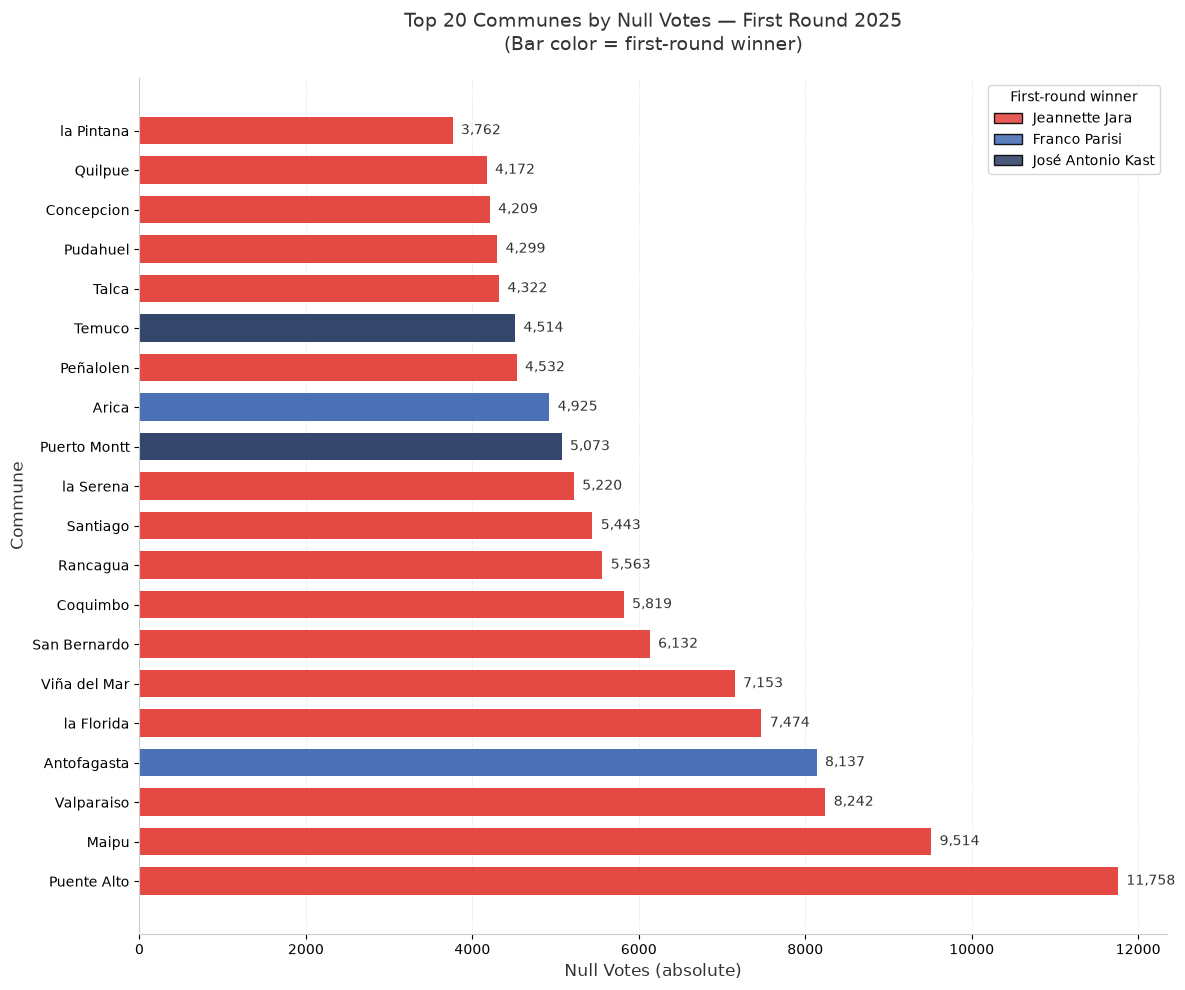

In [85]:
# ============================================================================
# PLOT HELPERS: STYLE, COLOR MAPPING, AND GENERIC BAR CHART
# ============================================================================
# Defines reusable plotting utilities: axis styling, candidate name mapping,
# and a horizontal bar chart for top-N null vote communes.
# ============================================================================

def set_clean_style(ax):
    """
    Applies a minimal publication-ready style to an Axes object:
    white background, no top/right spines, muted grid on the value axis.
    """
    ax.set_facecolor('white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#cccccc')
    ax.spines['bottom'].set_color('#cccccc')
    ax.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.5, zorder=1)
    return ax

# ============================================================================
# WINNER SHORT-NAME → DISPLAY NAME MAPPING
# ============================================================================
# Maps abbreviated candidate names to full display names for legend labels.

WINNER_NAME_MAPPING = {
    'Parisi':            'Franco Parisi',
    'Kast':              'José Antonio Kast',
    'Jara':              'Jeannette Jara',
    'Kaiser':            'Johannes Kaiser',
    'Matthei':           'Evelyn Matthei',
    'Mayne Nicholls':    'Harold Mayne-Nicholls',
    'Enríquez Ominami':  'Marco Enriquez-Ominami',
    'Artes':             'Eduardo Artes',
}

# ============================================================================
# VISUALIZATION: Top-N Communes by Null Votes — First Round 2025
# ============================================================================
# Generates a horizontal bar chart of communes with the highest null vote
# counts. Bar color encodes the first-round winner of each commune.
# ============================================================================

def plot_top_null_first_round(df: pd.DataFrame, top_n: int = 20) -> None:
    """
    Horizontal bar chart of the communes with the largest null votes
    in the first round.

    Bar color encodes the first-round winner of each commune.
    Each bar carries one annotation:
      - Null vote count (bold, offset right of bar tip).

    Parameters
    ----------
    df : pd.DataFrame
        Output of compute_commune_null_stats(), containing at minimum:
        commune, null_votes, null_pct_1v, first_round_winner.
    top_n : int, optional
        Number of communes to display (default 20).
    """

    # ---------------------------------------------------------------------------
    # 0. DATA PREPARATION
    # ---------------------------------------------------------------------------
    # Select top-N communes by null vote count and resolve display names/colors.

    plot_df = df.nlargest(top_n, 'null_votes').copy()

    # Resolve full display name and color for each bar
    plot_df['winner_full'] = (
        plot_df['first_round_winner']
        .map(WINNER_NAME_MAPPING)
        .fillna('No data')
    )
    plot_df['color'] = (
        plot_df['winner_full']
        .map(CANDIDATE_COLORS)
        .fillna(CANDIDATE_COLORS['No data'])
    )

    # ---------------------------------------------------------------------------
    # 1. VISUALIZATION — HORIZONTAL BAR CHART
    # ---------------------------------------------------------------------------
    # Render bars with annotations and legend.

    fig, ax = plt.subplots(figsize=(12, 10))
    fig.patch.set_facecolor('white')
    ax = set_clean_style(ax)

    # Bars rendered above the grid (zorder=2)
    bars = ax.barh(
        plot_df['commune'],
        plot_df['null_votes'],
        color=plot_df['color'],
        linewidth=0.8,
        height=0.7,
        zorder=2,
    )

    # Primary annotation: null vote count
    for bar, value in zip(bars, plot_df['null_votes']):
        ax.annotate(
            f'{value:,.0f}',
            xy=(bar.get_width(), bar.get_y() + bar.get_height() / 2),
            xytext=(6, 0),
            textcoords='offset points',
            ha='left', va='center',
            fontsize=10,
            color='#333333', zorder=3,
        )

    ax.set_xlabel('Null Votes (absolute)', fontsize=12, color='#333333')
    ax.set_ylabel('Commune', fontsize=12, color='#333333')
    ax.set_title(
        f'Top {top_n} Communes by Null Votes — First Round 2025\n'
        '(Bar color = first-round winner)',
        fontsize=14, pad=20, color='#333333',
    )

    # Legend
    legend_elements = [
        Patch(
            facecolor=CANDIDATE_COLORS.get(WINNER_NAME_MAPPING.get(w, 'No data'), CANDIDATE_COLORS['No data']),
            edgecolor='black',
            label=WINNER_NAME_MAPPING.get(w, w),
            alpha=0.9,
        )
        for w in plot_df['first_round_winner'].unique()
    ]
    ax.legend(
        handles=legend_elements,
        loc='upper right',
        title='First-round winner',
        fontsize=10,
        frameon=True,
        facecolor='white',
        edgecolor='#cccccc',
    )

    plt.tight_layout()
    plt.show()


# Execute
plot_top_null_first_round(commune_null_metrics, 20)

##### Chart Analysis

**The Dominance of Major Cities and Jara's Strongholds**

The chart shows a marked concentration of the null vote in the major cities, especially in the Metropolitan Region. **Eight of the 20 communes** belong to Greater Santiago (Puente Alto, Maipú, La Florida, San Bernardo, Santiago, Peñalolén, Pudahuel, and La Pintana), confirming that the null vote is not an exclusively peripheral phenomenon but also reaches the country's most densely populated urban core. With the exception of Peñalolén and Pudahuel, all of these communes were won by Jara, indicating that even in left-wing strongholds a significant share of the electorate chose to invalidate its ballot.

The case of **Puente Alto** is particularly telling. With 11,758 null votes, the country's most populous commune —and a historic stronghold of the left— posts the largest volume of active protest. This suggests that the wear on the Boric government and dissatisfaction with the available electoral offer reached even the sectors that traditionally back the left. The presence of **Valparaíso** (8,242 null votes) in third place reinforces this reading: the port city, with a long tradition of left-wing politics and union organizing, shows a level of active protest that sets it apart from the rest of the Centro's communes.

**The North as the Epicenter of Intensity**

Although the absolute volume is dominated by Greater Santiago and Valparaíso, the chart shows that **Antofagasta** (8,137 null votes) and **Arica** (4,925) —both won by Parisi— post significant volumes despite having populations far smaller than the communes of the Metropolitan Region. This confirms that, in relative terms, the null vote was proportionally more intense in the North than in the Centro. The presence of **Coquimbo** (5,819) and **La Serena** (5,220) in the ranking indicates that the Norte Chico, too, is a territory where electoral discontent found strong expression.

**Discipline in the South: Temuco and Puerto Montt**

**Temuco** (4,514 null votes) and **Puerto Montt** (5,073) appear in the ranking despite being communes won by Kast, though their null-vote levels are comparatively low: Puerto Montt ranks seventh by volume, but its population is markedly smaller than that of Puente Alto or Maipú, while Temuco, with just 4,514 null votes, posts the lowest percentage among the Top 20 communes (2.13%), well below the national average.

This confirms the strong loyalty of Kast's electorate in the south of the country. In La Araucanía and Los Lagos, the Republican candidate consolidated his conservative base without a significant share of his voters resorting to active protest, a notable contrast with the more heterogeneous behavior of his northern strongholds.

**A Dual Geography**

The chart reveals a dual geography of the null vote: **volume in the Centro** (large cities where Jara was strong) and **intensity in the North** (mining and border communes where Parisi was dominant). This duality poses different kinds of challenges for each candidacy contesting the runoff:

-   **For Jara**, the high volume of null votes in her urban strongholds (Puente Alto, Maipú, La Florida) points to a mobilization challenge: holding her base together without a share of it turning to active protest in the decisive round. Valparaíso's presence in the Top 3 suggests that this coastal region is, in addition, particularly volatile.

-   **For Kast**, the null vote in northern communes where Parisi was strong (Antofagasta, Arica) is a warning sign: it suggests that a share of the anti-establishment electorate does not fully identify with either of the two runoff options. His disciplined base in the south (Temuco, Puerto Montt), by contrast, gives him a solid electoral floor in that macrozone.

Taken together, the chart confirms that the first-round null vote is neither a marginal nor a homogeneous phenomenon, but a thermometer of discontent that clearly reveals the electorates each candidacy will need to contest or consolidate ahead of the runoff.


#### Chart: Top 20 Communes with the Most Null Votes (Relative Value)


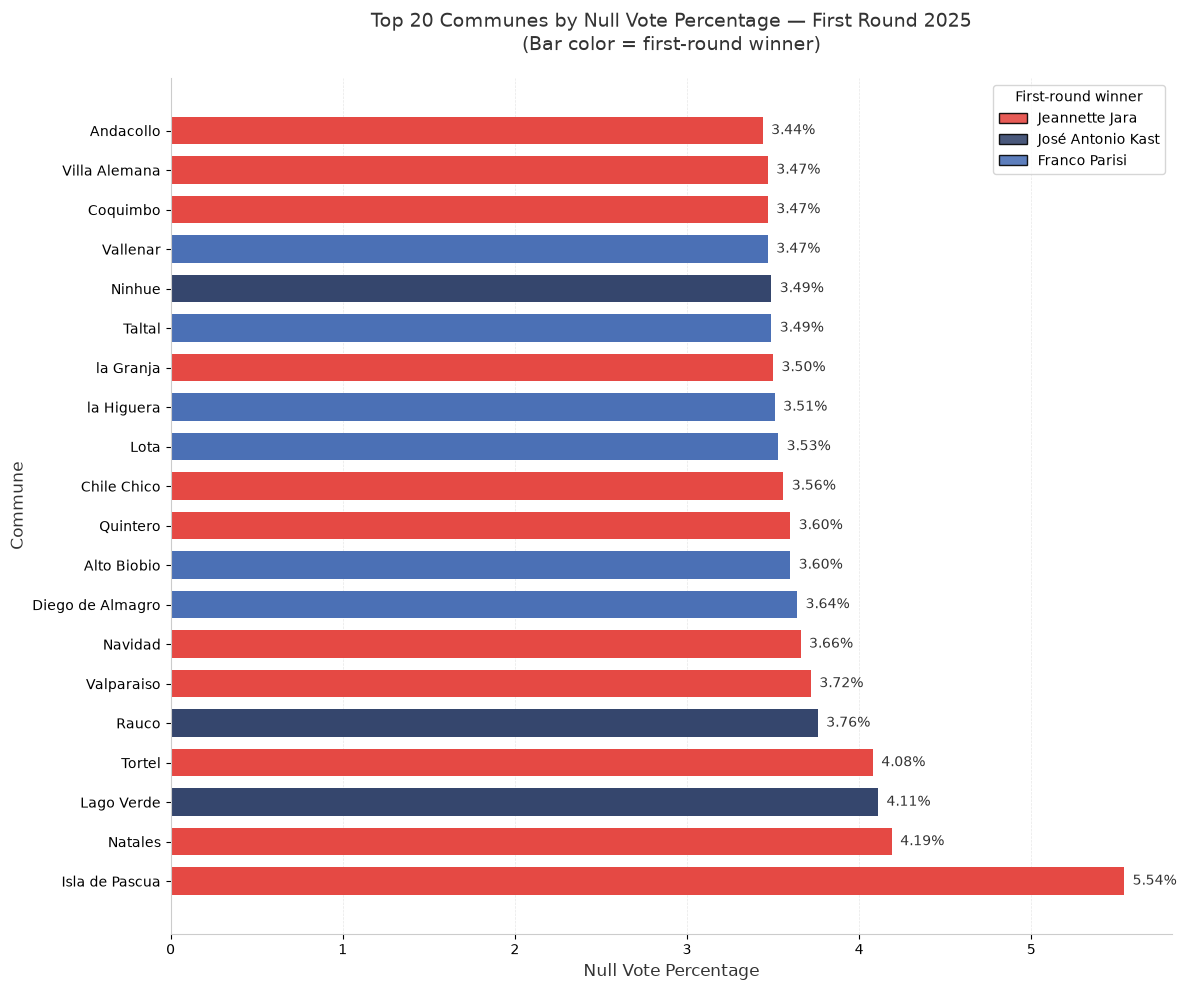

In [86]:
# ============================================================================
# TOP-N COMMUNES BY NULL VOTE PERCENTAGE — FIRST ROUND 2025
# ============================================================================
# Generates a horizontal bar chart of communes with highest null vote
# percentage in the first round. Bar color encodes the first-round winner.
# ============================================================================

# ---------------------------------------------------------------------------
# 1. VISUALIZATION FUNCTION
# ---------------------------------------------------------------------------
# Defines plotting function for top communes by null vote percentage.

def plot_top_pp_first_round(df: pd.DataFrame, top_n: int = 20) -> None:
    """
    Horizontal bar chart of the communes with the largest percentage
    of null votes in the first round.

    Bar color encodes the first-round winner of each commune.
    Each bar carries one annotation:
      - Null vote percentage (bold, offset right of bar tip).

    Parameters
    ----------
    df : pd.DataFrame
        Output of analyze_communes_null_increase(), containing at minimum:
        commune, null_pct_1v, first_round_winner.
    top_n : int, optional
        Number of communes to display (default 20).
    """

    plot_df = df.nlargest(top_n, 'null_pct_1v').copy()

    # Resolve full display name and color for each bar
    plot_df['winner_full'] = (
        plot_df['first_round_winner']
        .map(WINNER_NAME_MAPPING)
        .fillna('No data')
    )
    plot_df['color'] = (
        plot_df['winner_full']
        .map(CANDIDATE_COLORS)
        .fillna(CANDIDATE_COLORS['No data'])
    )

    fig, ax = plt.subplots(figsize=(12, 10))
    fig.patch.set_facecolor('white')
    ax = set_clean_style(ax)

    # Bars rendered above the grid (zorder=2)
    bars = ax.barh(
        plot_df['commune'],
        plot_df['null_pct_1v'],
        color=plot_df['color'],
        linewidth=0.8,
        height=0.7,
        zorder=2,
    )

    # Primary annotation: percentage of null votes
    for bar, value in zip(bars, plot_df['null_pct_1v']):
        ax.annotate(
            f'{value:.2f}%',
            xy=(bar.get_width(), bar.get_y() + bar.get_height() / 2),
            xytext=(6, 0),
            textcoords='offset points',
            ha='left', va='center',
            fontsize=10,
            color='#333333', zorder=3,
        )

    ax.set_xlabel('Null Vote Percentage', fontsize=12, color='#333333')
    ax.set_ylabel('Commune', fontsize=12, color='#333333')
    ax.set_title(
        f'Top {top_n} Communes by Null Vote Percentage — First Round 2025\n'
        '(Bar color = first-round winner)',
        fontsize=14, pad=20, color='#333333',
    )

    # Legend 
    legend_elements = [
        Patch(
            facecolor=CANDIDATE_COLORS.get(WINNER_NAME_MAPPING.get(w, 'No data'), CANDIDATE_COLORS['No data']),
            edgecolor='black',
            label=WINNER_NAME_MAPPING.get(w, w),
            alpha=0.9,
        )
        for w in plot_df['first_round_winner'].unique()
    ]
    ax.legend(
        handles=legend_elements,
        loc='upper right',
        title='First-round winner',
        fontsize=10,
        frameon=True,
        facecolor='white',
        edgecolor='#cccccc',
    )

    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------------------------
# 2. EXECUTION
# ---------------------------------------------------------------------------
# Generates the top 20 communes chart.

plot_top_pp_first_round(commune_null_metrics, 20)

##### Chart Analysis

**The Dominance of Patagonia and Isolated Communities**

The chart's most telling finding is the presence of **four communes from Patagonia and Aysén** among the top spots: **Easter Island** (5.54%), **Natales** (4.19%), **Lago Verde** (4.11%), and **Tortel** (4.08%). These communes, characterized by low population density, geographic isolation, and heavy dependence on the central state, post the country's highest null-vote levels. The pattern suggests that a perceived neglect by the state —fed by gaps in access to basic services, connectivity, and productive development— translates electorally into active rejection of the available offer.

The case of **Easter Island** is especially revealing. With 5.54% null votes —more than double the national average (2.69%)— the island commune, whose economy revolves around tourism and which depends heavily on the central state for basic services, shows the country's highest level of active protest. The figure reflects a deep discontent with Santiago-centered centralism, which on the island is historically articulated through demands for autonomy and greater state investment. The presence of **Tortel** and **Lago Verde** in the Top 5 confirms that, in Patagonia, the null vote operates as an expression of rejection toward the traditional political system, particularly in communes where the state's presence is weak and local demands go unanswered by national policy.

**The Mining North as a Second Epicenter**

The second pattern to emerge from the chart is the presence of communes in the Norte Grande and Norte Chico where Parisi won the first round. **Diego de Almagro** (3.64%), **Alto Biobío** (3.60%), **Lota** (3.53%), **La Higuera** (3.51%), **Taltal** (3.49%), and **Vallenar** (3.47%) all exceed 3.4%. These communes, heavily dependent on mining and with a strong union presence, concentrate an electorate that backed Parisi massively in the first round, reflecting a deep rejection of the traditional political system.

The overlap between high null-vote levels and communes won by Parisi is a key finding: it suggests that a share of the anti-establishment electorate —the same one that backed the Partido de la Gente's candidate in November— was already showing, in the first round, a broader disposition toward active protest, not confined to a single candidacy. The presence of **Coquimbo** (3.47%) and **Vallenar** (3.47%) —both with economies tied to mining— reinforces the reading that, in the mining North, distrust toward the political system runs particularly deep.

**The Exception of Valparaíso and the Urban Communes**

**Valparaíso** (3.72%) appears in fifth place in the ranking, the only commune from the Centro with such a high null-vote share. This matters because Valparaíso, with a long tradition of left-wing politics and union organizing, shows a level of active protest that surpasses that of northern communes and approaches Patagonia's levels —a sign of discontent with the governing coalition with no parallel among other communes of similar political orientation.

Other urban communes of the Centro appear in the ranking with more moderate percentages: **Quintero** (3.60%), **Villa Alemana** (3.47%), and **La Granja** (3.50%). In these, the null vote reflects a more diffuse discontent, likely tied to the wear on the Boric government and the perception that the available electoral offer did not respond to citizens' demands for security and economic growth.

**A Geography of Three Territories**

The chart reveals a geography of the null vote that combines three types of territory: **isolated Patagonia** (where rejection of centralism runs deepest), the **mining North** (where the anti-establishment electorate channels its discontent through active protest), and **urban enclaves of the Centro** (where wear on the governing coalition takes the form of the null vote). This dual geography outlines challenges of a different nature for each candidacy heading into the runoff:

- **For Jara**, the high null-vote share in Centro communes such as Valparaíso and Quintero is a warning sign: discontent in her urban strongholds could translate into demobilization of her base in the decisive round.
- **For Kast**, the high null-vote share in northern communes where Parisi was strong (Diego de Almagro, Alto Biobío, Lota) suggests that a significant share of the anti-establishment electorate does not feel fully represented by his candidacy. The fact that communes such as Temuco or Puerto Montt do not appear in the ranking, by contrast, confirms that his base in the south is disciplined and loyal.


#### Distribution of the Null Vote by First-Round Winner


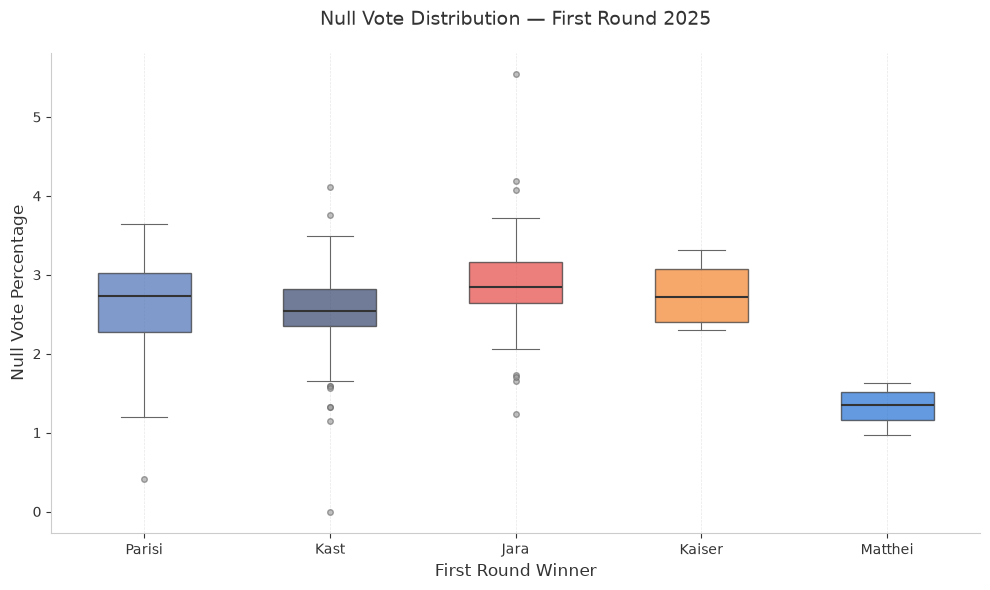

In [87]:
# ============================================================================
# NULL VOTE DISTRIBUTION — FIRST ROUND 2025
# ============================================================================
# Box plot of null vote percentage by first-round winner per commune.
# ============================================================================

# ---------------------------------------------------------------------------
# 0. DATA PREPARATION
# ---------------------------------------------------------------------------
# Filter top winners with sufficient commune representation.

top_winners = ['Parisi', 'Kast', 'Jara', 'Kaiser', 'Matthei']
plot_df = commune_null_metrics[commune_null_metrics['first_round_winner'].isin(top_winners)].copy()

# ---------------------------------------------------------------------------
# 1. VISUALIZATION — BOX PLOT
# ---------------------------------------------------------------------------
# Create box plot with candidate-specific coloring.

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('white')
ax = set_clean_style(ax)

box_data = [
    plot_df[plot_df['first_round_winner'] == winner]['null_pct_1v']
    for winner in top_winners
]

boxes = ax.boxplot(
    box_data,
    patch_artist=True,
    medianprops={'color': '#333333', 'linewidth': 1.5},
    whiskerprops={'color': '#666666', 'linewidth': 0.8},
    capprops={'color': '#666666', 'linewidth': 0.8},
    flierprops={
        'marker': 'o',
        'markerfacecolor': '#999999',
        'markeredgecolor': '#666666',
        'markersize': 4,
        'alpha': 0.6
    }
)

ax.set_xticklabels(top_winners)

for box, winner in zip(boxes['boxes'], top_winners):
    full_name = WINNER_NAME_MAPPING.get(winner, winner)
    color = CANDIDATE_COLORS.get(full_name, CANDIDATE_COLORS.get('No data', '#dddddd'))
    box.set_facecolor(color)
    box.set_alpha(0.7)
    box.set_edgecolor('#333333')
    box.set_linewidth(1)

ax.set_xlabel('First Round Winner', fontsize=12, color='#333333')
ax.set_ylabel('Null Vote Percentage', fontsize=12, color='#333333')
ax.set_title(
    'Null Vote Distribution — First Round 2025',
    fontsize=14, pad=20, color='#333333'
)

ax.tick_params(axis='both', colors='#333333', labelsize=10)


# ---------------------------------------------------------------------------
# 2. EXECUTION
# ---------------------------------------------------------------------------
plt.tight_layout()
plt.show()

##### Chart Analysis

**Parisi (median ~2.6–2.7%, range 0–4%)**

Communes won by Franco Parisi show wide dispersion, with values ranging from an extremely low outlier —close to 0%— to nearly 4%. The median sits around 2.6-2.7%, slightly below the national average (2.69%), and the central 50% of his communes falls between 2.2% and 3.0%. This range reflects the heterogeneity of Parisi's electorate, which combines territories where active protest was minimal with others where rejection of the system was more intense. The presence of low outliers suggests that, in some communes where Parisi won, the electorate did not turn to the null vote as an additional form of expression, likely because the anti-establishment candidate himself was already channeling that discontent.

**Kast (median ~2.6%, range 0–4.2%)**

Communes won by José Antonio Kast show dispersion similar to Parisi's, with a median of roughly 2.6% and a range running from an outlier at 0% to values above 4%. The central 50% of his communes falls between 2.3% and 2.8%. The pattern suggests that Kast's electorate, though largely loyal, also shows pockets of active protest in some territories, particularly in northern communes or in those where the race was tighter.

**Jara (median ~2.8%, extreme outliers)**

Communes won by Jeannette Jara show the highest median of any group (~2.8%), slightly above the national average, and the widest range: from ~1.2% to 5.5%. Hers is the only group with an extremely high outlier —the lone point brushing 5.5%, corresponding to Easter Island, where the null vote reached the country's highest level. This finding matters because Easter Island is a Jara stronghold, indicating that even in communes where the governing coalition's candidate was strong, electoral discontent can be expressed intensely. The group also shows low outliers (~1.2%), confirming that its communes are far from uniform in behavior.

**Kaiser (median ~2.7%, compact range)**

Communes won by Johannes Kaiser form the most compact, homogeneous group: its box is narrower than that of the other candidates, with a median of roughly 2.7% and tightly clustered whiskers, between 2.3% and 3.2%. The pattern reflects the more homogeneous nature of the libertarian electorate, concentrated in the first round in a small number of communes with similar sociodemographic profiles, where active protest held a relatively constant intensity.

**Matthei (median ~1.3%): the exception**

The most distinctive, atypical group is that of communes won by Evelyn Matthei. Her median is just 1.3%, **significantly lower** than that of the other candidates —more than a full percentage point below. The central 50% of her communes barely exceeds 1.5%, and her maximum value does not exceed 1.7%. This confirms that the traditional right's electorate, concentrated in high-income communes on Santiago's east side, was the least prone to the null vote: Matthei's voters, with higher levels of education and income and a more institutional relationship with the political system, resorted to active protest far less often than the electorates of other blocs.


### Conclusion 4.2.

The commune-level analysis of the null vote confirms a dual pattern already hinted at regionally. In absolute volume, the phenomenon is concentrated in the large cities of Greater Santiago and Valparaíso —Puente Alto (11,758), Maipú (9,514), and Valparaíso (8,242)— where even in Jara's strongholds a significant share of the electorate chose active protest, reflecting discontent with the governing coalition that cuts across party lines. In relative terms, by contrast, the null vote proves proportionally more intense in the mining and border North —Antofagasta (3.18%), Arica (3.22%), and Coquimbo (3.47%)— where Parisi was strongest in the first round and where a perceived neglect by the state, the migration crisis, and organized crime fueled a more radical rejection of the traditional political system.

The geography of the null vote combines, in the end, three types of territory: isolated Patagonia (Easter Island, 5.54%), where rejection of centralism runs deepest; the mining North, where the anti-establishment electorate channels its discontent through active protest; and urban enclaves of the Centro (Valparaíso, Quintero), where wear on the governing coalition translates into null votes. This duality —volume in the Centro, intensity in the North— outlines challenges of a different nature for each candidacy heading into the runoff: for Jara, sustaining turnout in her urban strongholds without a share of her electorate turning to active protest, particularly in a region as volatile as Valparaíso; for Kast, the fact that a significant share of the anti-establishment electorate in the North —Diego de Almagro, Alto Biobío, Lota— does not feel fully represented by his candidacy, even as the discipline of his southern strongholds (Temuco, 2.13%) gives him a solid electoral floor to build on.

The distribution of the null vote by first-round winner confirms that Matthei is the exception, with a median of just 1.3%, revealing that the traditional right was the candidacy least associated with active protest. Parisi, Kast, and Jara show similar medians (~2.6-2.8%), though Jara has the most extreme outlier —Easter Island, 5.5%— indicating that even within her own strongholds discontent can be expressed intensely. The challenge both runoff candidacies face heading into December is, at bottom, the same one: reducing the scale of a protest vote whose geography is already defined as of November, which will require winning over —or at least not expanding— the electorate that today expresses its disaffection through rejection.


### 4.3. Communes with the Lowest Null Vote: The Territories of Greatest Electoral Discipline


The analysis of communes with the lowest share of null votes in the first round reveals a pattern that complements the geography of discontent: these are territories where the electorate remained disciplined and active protest was minimal, reflecting either a more institutional relationship with the political system or strong loyalty to the available electoral offer. Unlike the high-null-vote communes —concentrated in the mining North, isolated Patagonia, and certain discontented urban enclaves— the lowest-null communes are characterized by low population density, extreme-territory status (Antarctica, Patagonia), or membership in strongholds of candidacies with highly disciplined electorates, such as Kast's in the south. The most extreme case is Antarctica, with 0% null votes, followed by communes in Magallanes and Aysén where the null vote does not exceed 2%, confirming that in these territories the relationship with the electoral system is markedly institutional and active protest is virtually nonexistent.


In [88]:
# ============================================================================
# TOP 20 COMMUNES WITH LOWEST NULL VOTES — FIRST ROUND 2025
# ============================================================================
# Computes null vote statistics per commune (null votes, null percentage,
# valid votes and first-round winner), then ranks the 20 communes with the
# lowest absolute null votes.
# ============================================================================

# ---------------------------------------------------------------------------
# 0. DATA PREPARATION
# ---------------------------------------------------------------------------
# Defines a helper function that calculates commune‑level null vote metrics
# and identifies the winning candidate in each commune.

def compute_commune_null_stats(df: pd.DataFrame) -> pd.DataFrame:
    """
    Computes commune‑level null vote indicators and first‑round winner.

    Parameters
    ----------
    df : pd.DataFrame
        Electoral data with candidate vote columns and casted/blank/null totals.

    Returns
    -------
    pd.DataFrame
        Columns: commune, region, valid_votes_first_round, null_votes,
        null_pct_1v, first_round_winner.
    """
    candidate_cols = ['jara_votes', 'kast_votes', 'parisi_votes', 'kaiser_votes',
                      'matthei_votes', 'mayne_nicholls_votes', 'enriquez_ominami_votes',
                      'artes_votes']
    candidate_names = ['Jara', 'Kast', 'Parisi', 'Kaiser', 'Matthei',
                       'Mayne Nicholls', 'Enríquez Ominami', 'Artes']

    votes_prep = df.copy()

    # Determines the candidate with the highest vote count per commune
    votes_prep['first_round_winner'] = votes_prep[candidate_cols].idxmax(axis=1)
    winner_map = dict(zip(candidate_cols, candidate_names))
    votes_prep['first_round_winner'] = votes_prep['first_round_winner'].map(winner_map)

    # Calculates valid votes and null vote percentage
    votes_prep['valid_votes_first_round'] = (
        votes_prep['casted_votes'] - votes_prep['null_votes'] - votes_prep['blank_votes']
    )
    votes_prep['null_pct_1v'] = round(
        100.0 * votes_prep['null_votes'] / votes_prep['casted_votes'], 2
    )

    commune_null_metrics = votes_prep[[
        'commune', 'region',
        'valid_votes_first_round',
        'null_votes',
        'null_pct_1v',
        'first_round_winner'
    ]]

    return commune_null_metrics

# ---------------------------------------------------------------------------
# 1. METRIC CALCULATION
# ---------------------------------------------------------------------------
# Applies the null vote statistics function to the first‑round dataset.

commune_null_metrics = compute_commune_null_stats(df_votes)

# ---------------------------------------------------------------------------
# 2. RANKING
# ---------------------------------------------------------------------------
# Extracts the 20 communes with the lowest absolute null votes.

lowest_null_votes_top_20 = commune_null_metrics.nsmallest(20, 'null_votes')

# ---------------------------------------------------------------------------
# 3. TABLE OUTPUT
# ---------------------------------------------------------------------------
# Displays the top 20 communes ranked by fewest null votes.

print("=" * 80)
print("TOP 20 COMMUNES WITH FEWEST NULL VOTES")
print("=" * 80)
lowest_null_votes_top_20

TOP 20 COMMUNES WITH FEWEST NULL VOTES


,commune,region,valid_votes_first_round,null_votes,null_pct_1v,first_round_winner
187,Antartica,Magallanes,77,0,0.00,Kast
192,Primavera,Magallanes,392,5,1.24,Jara
282,Colchane,Tarapacá,1213,5,0.41,Parisi
194,Rio Verde,Magallanes,436,6,1.32,Kast
189,Laguna Blanca,Magallanes,512,7,1.32,Kast
196,Timaukel,Magallanes,232,7,2.88,Kast
29,O'higgins,Aysén,441,8,1.75,Kast
4,Ollague,Antofagasta,734,9,1.20,Parisi
195,San Gregorio,Magallanes,375,9,2.30,Kaiser
11,General Lagos,Arica y Parinacota,617,14,2.21,Parisi


#### Analysis

##### The Case of Antarctica: The Commune Without a Null Vote

Antarctica (0% null votes) is the most extreme case of electoral discipline recorded in the country. With only 77 valid votes cast, this commune —made up mainly of scientific and military bases— shows atypical behavior: a highly institutionalized electorate with a functional relationship to the political system and a minimal propensity toward active protest. The total absence of null votes reflects not only the profile of its residents but also the very nature of the commune: a territory with minimal population where the act of voting is processed in a more administrative than political manner, without resorting to invalidating the ballot. The fact that Antarctica was won by Kast with 45.45% of the vote confirms that this is a territory of high electoral loyalty, where active protest is virtually nonexistent.

##### The Concentration in Patagonia and the Far South

The ranking of communes with the lowest null vote is dominated by Patagonia and the country's far south. Primavera (1.24%), Río Verde (1.32%), and Laguna Blanca (1.32%) —all in the Region of Magallanes— together with Timaukel (2.88%), San Gregorio (2.30%), and Torres del Paine (2.44%) in the same region, and O'Higgins (1.75%), Tortel (4.08%), and Guaitecas (1.86%) in Aysén, confirm that the country's far south is a territory where the null vote sits systematically below the national average (2.69%). The pattern suggests that in Patagonia the relationship with the political system is more institutional, and active protest less frequent than in the mining North or in the discontented urban enclaves of the Centro.

The explanation for this phenomenon has several layers. First, the low population density and geographic isolation of these communes generate a distinctive electoral dynamic, in which local factors and regional identities carry more weight than national narratives. Second, the high share of state employees and aquaculture workers in Patagonia —sectors that depend heavily on state benefits— fosters a more institutional relationship with the political system, reducing the propensity toward active protest. Third, the fact that many of these communes are strongholds of Kast (Río Verde, Laguna Blanca, Torres del Paine, O'Higgins, Guaitecas) or of Jara (Primavera) confirms that the Patagonian electorate remained disciplined and loyal to its choices, without resorting to invalidating the ballot as a form of political expression.

##### Low-Null-Vote Communes in the North: Exceptions in Anti-Establishment Territory

The presence of Norte Grande communes in the low-null-vote ranking —Colchane (0.41%), Ollagüe (1.20%), Sierra Gorda (2.04%), Camiña (1.68%), and Camarones (2.32%)— qualifies the general diagnosis that the North is the epicenter of active protest. These communes, all won by Parisi in the first round, show null-vote levels well below their macrozone's average (2.92%) and, in some cases, even below the national average.

The case of Colchane (0.41%) is especially revealing. The commune, located on the border with Bolivia and at the epicenter of the migration crisis, was where Parisi achieved his second-best result nationwide (57.30%). The null vote there, however, is minimal, indicating that the electorate that backed Parisi in this commune did not additionally resort to active protest, likely because the anti-establishment candidate was already channeling its discontent. The pattern suggests that, in some communes of the North, the vote for Parisi functioned as a substitute for the null vote: voters disillusioned with the traditional political system found in the Partido de la Gente's candidate a sufficient channel of expression, without needing to invalidate their ballot. This behavior is consistent with the finding, described in section 4.1, that the correlation between the Parisi vote and the null vote, while robust, is not perfect: the two phenomena share territory, but not always the same voter.

##### Elite Communes: The Absence of Active Protest

One notable finding is the absence of Santiago's elite communes —Vitacura, Las Condes, Providencia, La Reina— from the low-null-vote ranking. These communes, which in the first round showed low null-vote levels (consistent with the 1.3% median for Matthei's electorate), do not appear in the Top 20 simply because their total vote volume is far larger than that of the Patagonian communes, not because their behavior differs from the pattern. Traditional-right voters, characterized by higher education levels, higher incomes, and a more institutional relationship with the political system, resorted to active protest markedly less often than the electorates of other blocs —a finding consistent across every dimension of the null-vote analysis presented in this chapter.

##### A Discipline That Is Not Uniform

Taken together, the communes with the lowest null vote confirm that first-round electoral discipline follows more than one logic: the institutional isolation of Patagonia, the channeling of anti-establishment discontent through the Parisi vote in certain northern communes, and the more institutional relationship the traditional right maintains with the political system. In all three cases, these are electorates that —for different reasons— did not find in ballot invalidation a vehicle for political expression, in contrast with the fragmentation and more explicit discontent observed in the rest of the country.

### Conclusion 4.3.

The analysis of the lowest-null-vote communes confirms that active protest is minimal in territories where the electorate maintains a more institutional relationship with the political system —Patagonia and the far south— or where an anti-establishment candidacy channels discontent without the voter needing to invalidate the ballot, as in Colchane, Ollagüe, and Camiña. The most extreme case is Antarctica (0% null votes), the expression of a highly disciplined electorate with a purely functional relationship to the electoral system. In Patagonia, where the null vote does not exceed 2.5% in most communes, geographic isolation, the high share of state employees, and the weight of local factors over national narratives combine into a distinctive electoral dynamic, one in which active protest is less frequent than in the mining North or in the discontented urban enclaves of the Centro.

The presence of northern communes —Colchane, Ollagüe, Camiña— in this ranking qualifies the diagnosis that this macrozone is, without nuance, the epicenter of active protest: there, the vote for Parisi acted as a substitute for the null vote, channeling discontent with the traditional political system without the need to invalidate the ballot. This disconnect between the anti-establishment vote and the null vote —present in some northern communes but not others— confirms that the two phenomena, while correlated in the aggregate, respond to different voter logics and should not be read as equivalent.

Taken as a whole, the geography of electoral discipline is as revealing as that of discontent: while Patagonia, the far south, and certain northern communes show strong institutional adherence to their electoral choices, the true locus of active protest is concentrated in the mining North and in certain urban enclaves of the Centro —the territories where each candidacy's ability to retain or expand its electorate will be tested in the weeks ahead.


### 4.4. Map of Null-Vote Intensity by Commune


/tmp/ipykernel_359531/2276376408.py:182: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 1, 0.94])


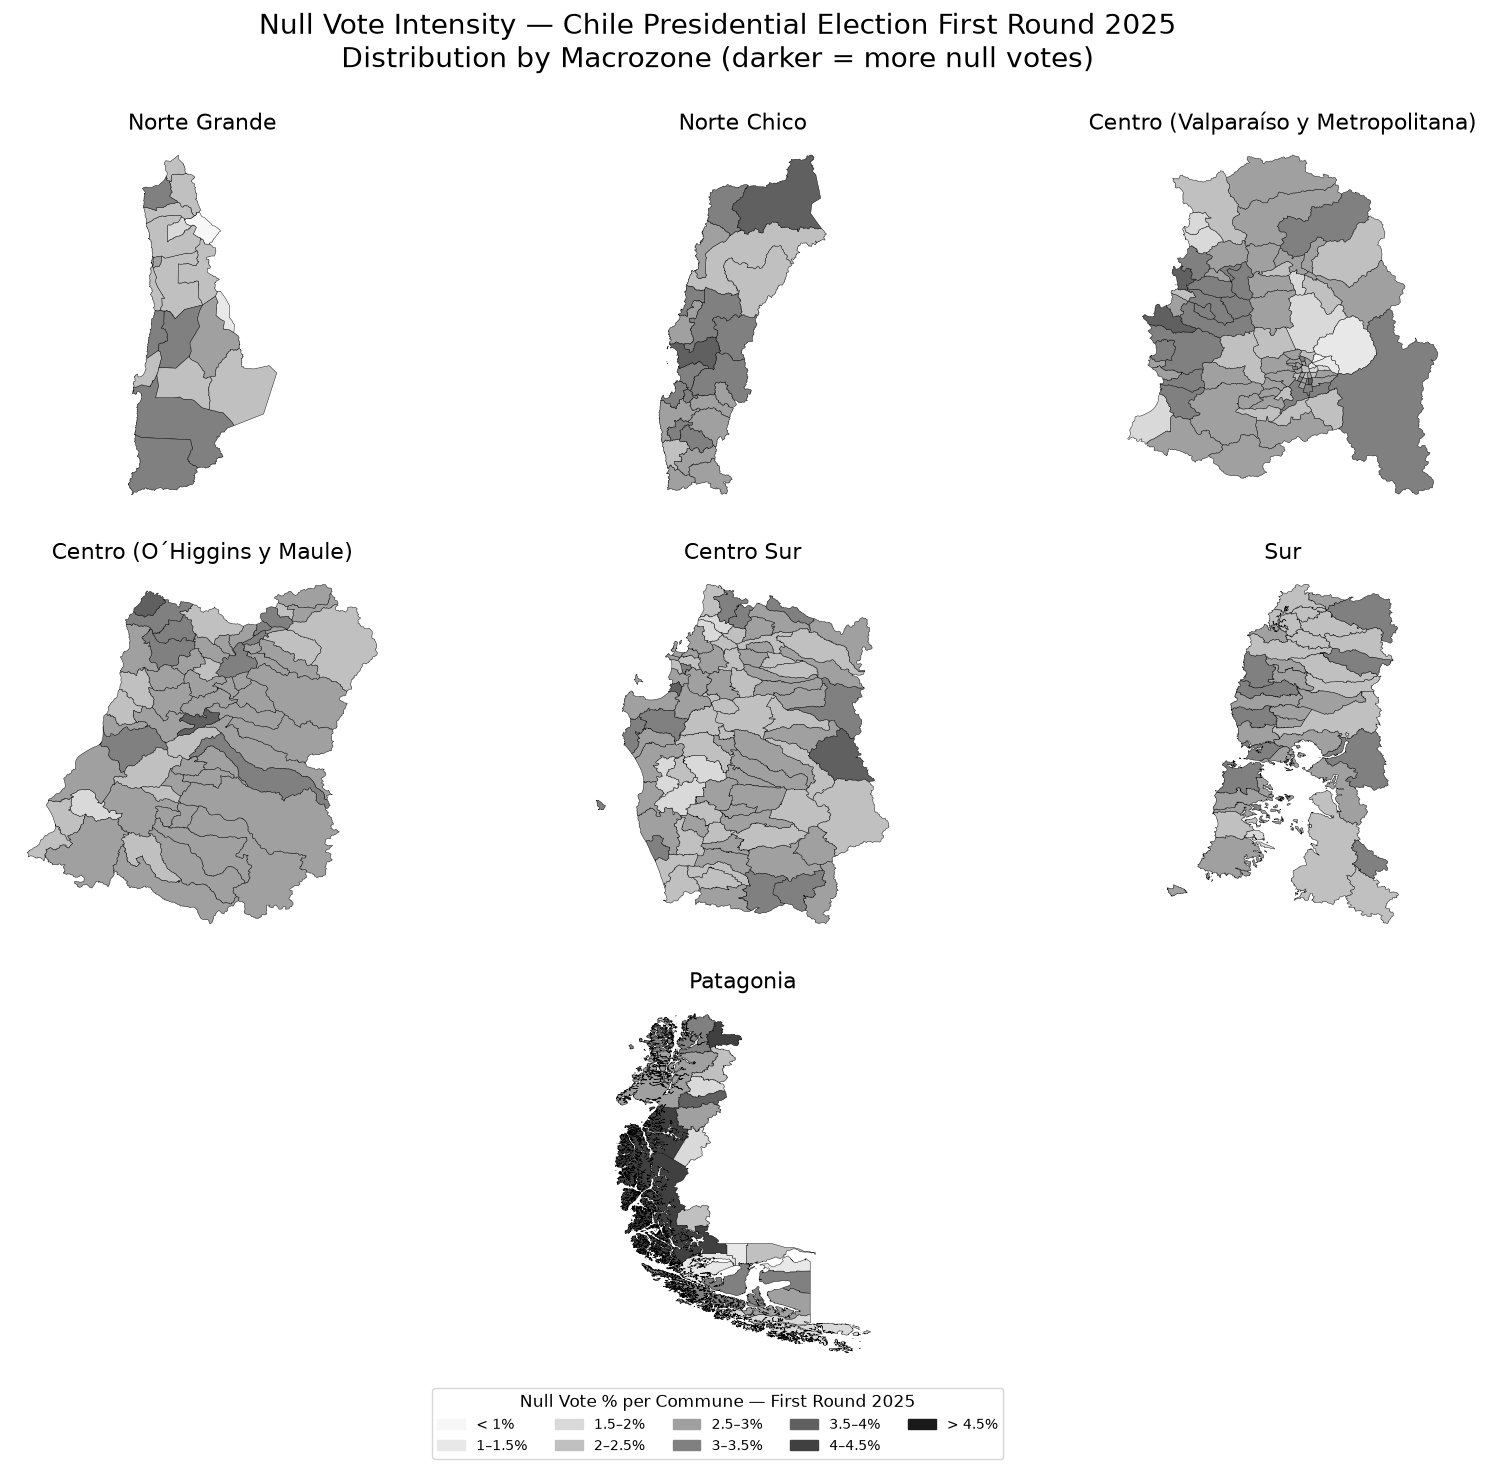

In [89]:
# ============================================================================
# NULL VOTE INTENSITY MAP BY COMMUNE — FIRST ROUND 2025
# ============================================================================
# Generates a macrozone-based choropleth map of null vote percentages
# using a custom grayscale color scale sensitive to low values (<5%).
# ============================================================================

# ---------------------------------------------------------------------------
# 0. DATA PREPARATION
# ---------------------------------------------------------------------------
# Compute null vote percentage per commune and normalize names for spatial join.

df_votes_prep = df_votes.copy()
df_votes_prep['null_pct'] = (df_votes_prep['null_votes'] / df_votes_prep['casted_votes'] * 100).round(2)

communes_prep = communes.copy()
communes_prep['NOM_COM_NORM'] = communes_prep['NOM_COM'].apply(normalize_commune_name)
df_votes_prep['commune_norm'] = df_votes_prep['commune'].apply(normalize_commune_name)

# ---------------------------------------------------------------------------
# 1. SPATIAL JOIN
# ---------------------------------------------------------------------------
# Merge commune geometries with null vote data and assign colors.

map_data = communes_prep.merge(
    df_votes_prep[['commune_norm', 'null_pct']],
    left_on='NOM_COM_NORM',
    right_on='commune_norm',
    how='left',
)

# Exclude island communes
map_data = map_data[~map_data['NOM_COM'].str.contains('Isla de Pascua|Juan Fernández', case=False, na=False)]

unmatched = map_data[map_data['null_pct'].isna()]['NOM_COM'].tolist()
if unmatched:
    print(f"Communes with no match ({len(unmatched)}): {unmatched[:10]}")

# ---------------------------------------------------------------------------
# 2. COLOR ASSIGNMENT
# ---------------------------------------------------------------------------
# Custom grayscale scale for null vote percentages (sensitive up to 5%).

def get_null_color(null_pct):
    """Returns grayscale color based on null vote percentage threshold."""
    if pd.isna(null_pct):
        return '#D3D3D3'
    if null_pct < 1:
        return '#F7F7F7'
    elif null_pct < 1.5:
        return '#E8E8E8'
    elif null_pct < 2:
        return '#D9D9D9'
    elif null_pct < 2.5:
        return '#C0C0C0'
    elif null_pct < 3:
        return '#A0A0A0'
    elif null_pct < 3.5:
        return '#808080'
    elif null_pct < 4:
        return '#606060'
    elif null_pct < 4.5:
        return '#404040'
    else:
        return '#1A1A1A'

map_data['color'] = map_data['null_pct'].apply(get_null_color)

# ---------------------------------------------------------------------------
# 3. MACROZONE ASSIGNMENT
# ---------------------------------------------------------------------------
# Map region numbers to macrozone categories for grid layout.

MACROZONE_MAP = {
    15: 'Norte Grande',
    1:  'Norte Grande',
    2:  'Norte Grande',
    3:  'Norte Chico',
    4:  'Norte Chico',
    5:  'Centro (Valparaíso y Metropolitana)',
    13: 'Centro (Valparaíso y Metropolitana)',
    6:  'Centro (O\u00b4Higgins y Maule)',
    7:  'Centro (O\u00b4Higgins y Maule)',
    16: 'Centro Sur',
    8:  'Centro Sur',
    9:  'Centro Sur',
    14: 'Sur',
    10: 'Sur',
    11: 'Patagonia',
    12: 'Patagonia',
}

map_data['macrozone'] = map_data['REGION_NUM'].map(MACROZONE_MAP)

# ---------------------------------------------------------------------------
# 4. GRID LAYOUT CONFIGURATION
# ---------------------------------------------------------------------------
# Create 3x3 grid with macrozone subplots.

fig = plt.figure(figsize=(20, 16))
gs  = GridSpec(3, 3, figure=fig, hspace=0.15, wspace=0.15)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[1, 2])
ax7 = fig.add_subplot(gs[2, 1])

zone_axes = [
    (ax1, 'Norte Grande'),
    (ax2, 'Norte Chico'),
    (ax3, 'Centro (Valparaíso y Metropolitana)'),
    (ax4, 'Centro (O\u00b4Higgins y Maule)'),
    (ax5, 'Centro Sur'),
    (ax6, 'Sur'),
    (ax7, 'Patagonia'),
]

# ---------------------------------------------------------------------------
# 5. VISUALIZATION — MACROZONE MAPS
# ---------------------------------------------------------------------------
# Plot each macrozone with color-coded null vote intensity.

for ax, macro in zone_axes:
    macro_data = map_data[map_data['macrozone'] == macro].copy()
    if macro_data.empty:
        ax.text(0.5, 0.5, f'No data\n{macro}', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(macro, fontsize=14)
        ax.set_axis_off()
        continue

    macro_data.plot(ax=ax, color=macro_data['color'], edgecolor='black', linewidth=0.3)
    ax.set_title(macro, fontsize=16)
    ax.set_axis_off()
    ax.set_aspect('equal')

    if macro == 'Patagonia':
        bounds   = macro_data.total_bounds
        margin_x = (bounds[2] - bounds[0]) * 0.05
        margin_y = (bounds[3] - bounds[1]) * 0.05
        ax.set_xlim(bounds[0] - margin_x, bounds[2] + margin_x)
        ax.set_ylim(bounds[1] - margin_y, bounds[3] + margin_y)

# Hide unused grid cells
ax_empty1 = fig.add_subplot(gs[2, 0])
ax_empty2 = fig.add_subplot(gs[2, 2])
ax_empty1.set_visible(False)
ax_empty2.set_visible(False)

fig.suptitle(
    'Null Vote Intensity — Chile Presidential Election First Round 2025\nDistribution by Macrozone (darker = more null votes)',
    fontsize=20, y=0.96,
)

# ---------------------------------------------------------------------------
# 6. LEGEND
# ---------------------------------------------------------------------------
# Display color scale with percentage ranges.

legend_entries = [
    ('< 1%',     '#F7F7F7'),
    ('1–1.5%',   '#E8E8E8'),
    ('1.5–2%',   '#D9D9D9'),
    ('2–2.5%',   '#C0C0C0'),
    ('2.5–3%',   '#A0A0A0'),
    ('3–3.5%',   '#808080'),
    ('3.5–4%',   '#606060'),
    ('4–4.5%',   '#404040'),
    ('> 4.5%',   '#1A1A1A'),
]

legend_handles = [mpatches.Patch(color=color, label=label) for label, color in legend_entries]

fig.legend(
    handles=legend_handles, loc='lower center', ncol=5, fontsize=10,
    title='Null Vote % per Commune — First Round 2025', title_fontsize=12,
    bbox_to_anchor=(0.5, 0.05),
)

plt.tight_layout(rect=[0, 0.05, 1, 0.94])
plt.show()

### 4.5. Map of Null-Vote Intensity in Metropolitan Areas and Conurbations


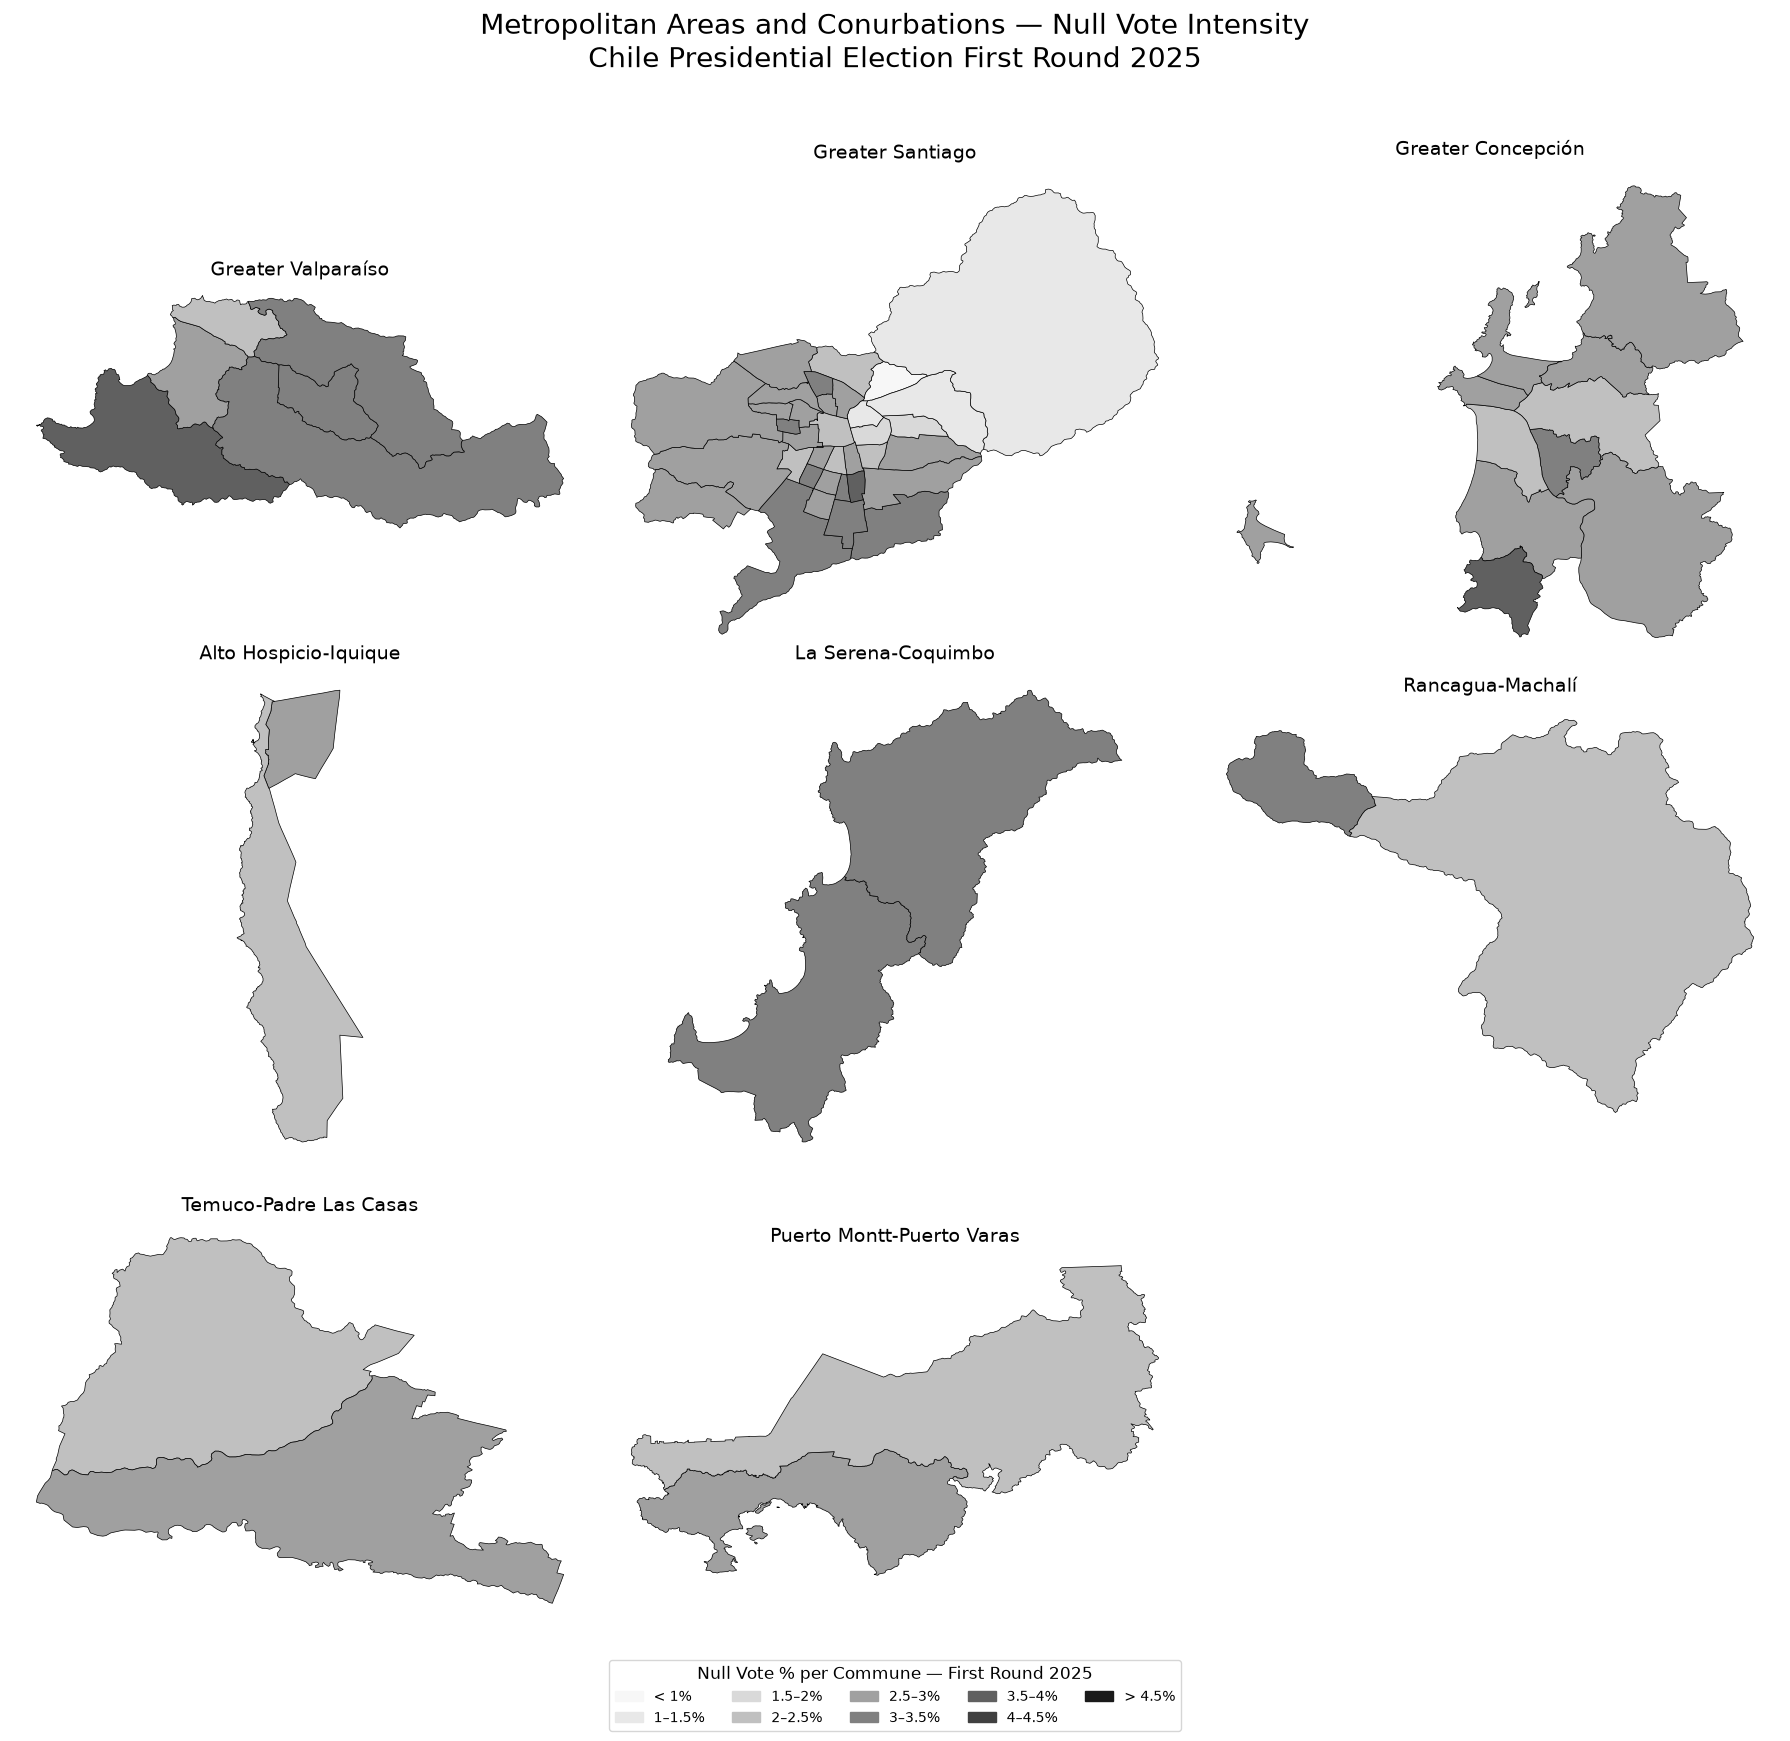

In [90]:
# ============================================================================
# METROPOLITAN AREAS AND CONURBATIONS — NULL VOTE INTENSITY
# ============================================================================
# Generates a 3x3 facet map of null vote percentage for Chile's main urban
# agglomerations in the 2025 presidential first round.
# ============================================================================

# ---------------------------------------------------------------------------
# 0. DATA PREPARATION — URBAN AGGLOMERATION DEFINITIONS
# ---------------------------------------------------------------------------
# Defines commune lists for each metropolitan area and conurbation.

GREATER_SANTIAGO = [
    "Cerrillos", "Cerro Navia", "Conchalí", "El Bosque", "Estación Central",
    "Huechuraba", "Independencia", "La Cisterna", "La Florida", "La Granja",
    "Providencia", "Las Condes", "La Reina", "Lo Espejo", "Lo Prado", "Macul",
    "Maipú", "Ñuñoa", "Padre Hurtado", "Pedro Aguirre Cerda", "Peñalolén",
    "Vitacura", "Pudahuel", "Puente Alto", "Quilicura", "Quinta Normal",
    "Recoleta", "Renca", "San Bernardo", "San Joaquín", "San Miguel",
    "San Ramón", "Santiago", "Lo Barnechea", "La Pintana",
]

GREATER_VALPARAISO = [
    "Valparaíso", "Viña del Mar", "Concón", "Quilpué", "Villa Alemana", "Limache",
]

GREATER_CONCEPCION = [
    "Concepción", "Coronel", "Chiguayante", "Hualpén", "Hualqui", "Lota",
    "Penco", "San Pedro de la Paz", "Talcahuano", "Tomé",
]

ALTO_HOSPICIO_IQUIQUE  = ["Alto Hospicio", "Iquique"]
LA_SERENA_COQUIMBO     = ["La Serena", "Coquimbo"]
RANCAGUA_MACHALI       = ["Rancagua", "Machalí"]
TEMUCO_METRO           = ["Temuco", "Padre Las Casas"]
PUERTO_MONTT_VARAS     = ["Puerto Montt", "Puerto Varas"]

# ---------------------------------------------------------------------------
# 1. GRID LAYOUT CONFIGURATION
# ---------------------------------------------------------------------------
# Defines the 3x3 facet grid positions and associated commune lists.

FACET_CONFIG = [
    ((0, 0), GREATER_VALPARAISO, 'Greater Valparaíso'),
    ((0, 1), GREATER_SANTIAGO,   'Greater Santiago'),
    ((0, 2), GREATER_CONCEPCION, 'Greater Concepción'),
    ((1, 0), ALTO_HOSPICIO_IQUIQUE, 'Alto Hospicio-Iquique'),
    ((1, 1), LA_SERENA_COQUIMBO,    'La Serena-Coquimbo'),
    ((1, 2), RANCAGUA_MACHALI,      'Rancagua-Machalí'),
    ((2, 0), TEMUCO_METRO,      'Temuco-Padre Las Casas'),
    ((2, 1), PUERTO_MONTT_VARAS, 'Puerto Montt-Puerto Varas'),
]

# Normalizes commune names for consistent matching with map data.
area_norm_keys = {
    title: {normalize_commune_name(c) for c in commune_list}
    for _, commune_list, title in FACET_CONFIG
}

# ---------------------------------------------------------------------------
# 2. COLOR SCALE DEFINITION
# ---------------------------------------------------------------------------
# Defines a fine-grained grayscale gradient for null vote percentages up to 5%.

def get_null_color(null_pct):
    """Returns a grayscale hex color based on null vote percentage.

    Parameters
    ----------
    null_pct : float or NaN
        Null vote percentage for a commune.

    Returns
    -------
    str
        Hex color code for the corresponding percentage range.
    """
    if pd.isna(null_pct):
        return '#D3D3D3'
    if null_pct < 1:
        return '#F7F7F7'
    elif null_pct < 1.5:
        return '#E8E8E8'
    elif null_pct < 2:
        return '#D9D9D9'
    elif null_pct < 2.5:
        return '#C0C0C0'
    elif null_pct < 3:
        return '#A0A0A0'
    elif null_pct < 3.5:
        return '#808080'
    elif null_pct < 4:
        return '#606060'
    elif null_pct < 4.5:
        return '#404040'
    else:
        return '#1A1A1A'

# ---------------------------------------------------------------------------
# 3. FACET GRID RENDERING
# ---------------------------------------------------------------------------
# Creates a 3x3 grid of choropleth maps for each urban agglomeration.

fig, axes = plt.subplots(3, 3, figsize=(18, 18))
fig.suptitle(
    'Metropolitan Areas and Conurbations — Null Vote Intensity\n'
    'Chile Presidential Election First Round 2025',
    fontsize=20, y=0.98,
)

for (row, col), commune_list, title in FACET_CONFIG:
    ax       = axes[row, col]
    norm_set = area_norm_keys[title]

    area_data = map_data[map_data['NOM_COM_NORM'].isin(norm_set)].copy()

    if area_data.empty:
        ax.text(0.5, 0.5, f'No data\n{title}',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title, fontsize=14)
        ax.set_axis_off()
        continue

    area_data['color'] = area_data['null_pct'].apply(get_null_color)

    area_data.plot(ax=ax, color=area_data['color'], edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontsize=14)
    ax.set_axis_off()
    ax.set_aspect('equal')

# Hides the unused bottom-right cell.
axes[2, 2].set_visible(False)

# ---------------------------------------------------------------------------
# 4. SHARED LEGEND
# ---------------------------------------------------------------------------
# Adds a unified legend for the null vote percentage color scale.

legend_entries = [
    ('< 1%',     '#F7F7F7'),
    ('1–1.5%',   '#E8E8E8'),
    ('1.5–2%',   '#D9D9D9'),
    ('2–2.5%',   '#C0C0C0'),
    ('2.5–3%',   '#A0A0A0'),
    ('3–3.5%',   '#808080'),
    ('3.5–4%',   '#606060'),
    ('4–4.5%',   '#404040'),
    ('> 4.5%',   '#1A1A1A'),
]

legend_handles = [mpatches.Patch(color=color, label=label) for label, color in legend_entries]

fig.legend(
    handles=legend_handles, loc='lower center', ncol=5, fontsize=10,
    title='Null Vote % per Commune — First Round 2025', title_fontsize=12,
    bbox_to_anchor=(0.5, 0.02),
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

### Conclusion to Chapter 4: The Null Vote


The first-round null vote confirms that active protest is not a homogeneous phenomenon, but a territorial thermometer of discontent with multiple layers of meaning. The northern regions —where Franco Parisi achieved his best results— post the highest rates of active protest (Norte Grande: 2.92%; Norte Chico: 3.02%), while the Centro (2.67%) and Centro Sur (2.56%) register the lowest levels, reflecting a lower disposition toward electoral rejection in the country's political heartland. Patagonia (3.16%) leads the macrozone ranking, confirming that geographic periphery is also the periphery of discontent, where isolation and a perceived neglect by the state translate into active rejection of the electoral offer.

The commune-level analysis reveals a dual pattern: in absolute volume, the null vote is concentrated in the large cities of Greater Santiago and Valparaíso —Puente Alto (11,758), Maipú (9,514), and Valparaíso (8,242)— where even in Jara's strongholds a significant share of the electorate chose active protest. In relative terms, however, communes in the North —Antofagasta (3.18%), Arica (3.22%), and Coquimbo (3.47%)— post the highest percentages, confirming that the intensity of discontent was greatest in the territories where Parisi was strongest. The presence of Easter Island (5.54%) and Patagonian communes at the top of the percentage ranking confirms that geographic isolation and a perceived neglect by the state are structural factors that predispose voters toward active protest, beyond any territory's partisan leanings.

The distribution of the null vote by winning candidacy reveals, finally, that Matthei is the exception, with a median of just 1.3%, confirming that the traditional right's electorate was the least prone to the null vote. Parisi, Kast, and Jara show similar medians (~2.6-2.8%), though Jara has the most extreme outlier (Easter Island, 5.5%), indicating that even within her own strongholds discontent can be expressed intensely. Taken together, these findings map a discontent that transcends the result of any single candidacy: nearly 400,000 Chileans deliberately chose to invalidate their vote in November, a signal that neither runoff coalition can afford to ignore, and whose evolution in December will depend, to a significant degree, on the ability of Jara and Kast to speak to an electorate that today defines itself, above all, by its rejection of the political offer as a whole.


---

## 5. The Blank Vote: Protest in a Quiet Voice


### Introduction


Within the repertoire of electoral behaviors available in Chile, the blank vote represents a more passive form of discontent than the null vote: the citizen fulfills the legal obligation to vote but declares —by marking no preference at all— that none of the available options represents them. Unlike the active, confrontational protest expressed by the null vote, the blank vote is closer to a "none of the above" that does not necessarily imply militant rejection of the political system. In the 2025 first round, this phenomenon reached 141,956 votes, equivalent to 1.06% of all ballots cast: a modest figure that nonetheless reveals a territorial pattern of its own, distinct from that of the null vote. This chapter examines the blank vote from the same angles applied in the previous chapter: its distribution by region and macrozone (5.1), its commune-level concentration in volume and relative intensity (5.2), the territories with the least passive protest (5.3), and its cartographic expression (5.4 and 5.5).


### 5.1. Blank Votes by Region and Geographic Macrozone: The South Has Its Say Too


The blank vote in the 2025 first round reached 141,956 votes, equivalent to 1.06% of all ballots cast. Its regional distribution shows a clear north-south, center-periphery gradient: the regions at the far south —Aysén (1.58%) and Magallanes (1.45%)— and in the Norte Chico —Coquimbo (1.39%) and Atacama (1.31%)— post the highest rates, while the Metropolitan Region (0.90%) registers the country's lowest level. This pattern suggests that the blank vote, like the null vote, is more frequent in peripheral territories than in the country's central core, though at lower intensities and with a territorial composition of its own, as detailed below.


In [91]:
# ============================================================================
# BLANK VOTE ANALYSIS BY REGION AND MACROZONE — FIRST ROUND 2025
# ============================================================================
# Aggregates blank votes by region and by macrozone for the first round,
# showing both absolute counts and percentage of total casted votes.
# ============================================================================

# ---------------------------------------------------------------------------
# 1. BLANK VOTE BY REGION
# ---------------------------------------------------------------------------
# Groups communes by region, sums blank votes and total casted votes, then
# calculates blank vote percentage and sorts by absolute blank votes.

blank_votes_region_metrics = df_votes.groupby('region').agg(
    blank_votes=('blank_votes', 'sum'),
    total_votes=('casted_votes', 'sum')
).reset_index()

blank_votes_region_metrics['blank_pct'] = round(
    100.0 * blank_votes_region_metrics['blank_votes'] / blank_votes_region_metrics['total_votes'], 2
)
blank_votes_region_metrics = blank_votes_region_metrics.sort_values('blank_votes', ascending=False)
blank_votes_region_metrics['blank_votes'] = blank_votes_region_metrics['blank_votes'].astype(int)
blank_votes_region_metrics['total_votes'] = blank_votes_region_metrics['total_votes'].astype(int)
blank_votes_region_metrics = blank_votes_region_metrics[['region', 'blank_votes', 'total_votes', 'blank_pct']]

print("-" * 80)
print("BLANK VOTES BY REGION — FIRST ROUND 2025")
print("-" * 80)
display(blank_votes_region_metrics)

# ---------------------------------------------------------------------------
# 2. BLANK VOTE BY MACROZONE
# ---------------------------------------------------------------------------
# Merges the region dimension to assign macrozones, then aggregates blank
# votes by macrozone and sorts north to south using macrozone_order.

votes_with_zone_prep = df_votes.merge(
    df_region_dim[['region', 'macrozone', 'macrozone_order']], on='region', how='left'
)

blank_votes_macrozone_metrics = votes_with_zone_prep.groupby('macrozone').agg(
    blank_votes=('blank_votes', 'sum'),
    total_votes=('casted_votes', 'sum'),
    macrozone_order=('macrozone_order', 'first')
).reset_index()

blank_votes_macrozone_metrics['blank_pct'] = round(
    100.0 * blank_votes_macrozone_metrics['blank_votes'] / blank_votes_macrozone_metrics['total_votes'], 2
)
blank_votes_macrozone_metrics = blank_votes_macrozone_metrics.sort_values('macrozone_order')
blank_votes_macrozone_metrics['blank_votes'] = blank_votes_macrozone_metrics['blank_votes'].astype(int)
blank_votes_macrozone_metrics['total_votes'] = blank_votes_macrozone_metrics['total_votes'].astype(int)
blank_votes_macrozone_metrics = blank_votes_macrozone_metrics[['macrozone', 'blank_votes', 'total_votes', 'blank_pct']]

print("\n" + "-" * 80)
print("BLANK VOTES BY MACROZONE — FIRST ROUND 2025")
print("-" * 80)
display(blank_votes_macrozone_metrics)

--------------------------------------------------------------------------------
BLANK VOTES BY REGION — FIRST ROUND 2025
--------------------------------------------------------------------------------


,region,blank_votes,total_votes,blank_pct
12,Metropolitana,46698,5161670,0.90
14,Valparaíso,16576,1449584,1.14
4,Biobío,12093,1217886,0.99
11,Maule,9949,859819,1.16
8,Los Lagos,9272,672296,1.38
6,La Araucanía,8907,778642,1.14
7,Libertador,8403,758138,1.11
5,Coquimbo,8150,584890,1.39
0,Antofagasta,4567,410388,1.11
15,Ñuble,4430,405679,1.09



--------------------------------------------------------------------------------
BLANK VOTES BY MACROZONE — FIRST ROUND 2025
--------------------------------------------------------------------------------


,macrozone,blank_votes,total_votes,blank_pct
3,Norte Grande,8477,780839,1.09
2,Norte Chico,10899,795350,1.37
0,Centro,81626,8229211,0.99
1,Centro Sur,25430,2402207,1.06
5,Sur,12606,985632,1.28
4,Patagonia,2918,195216,1.49


#### Analysis

##### Regional Pattern: Periphery and Passive Discontent

The regional analysis of the blank vote reveals a territorially heterogeneous distribution, with a clear gradient distinguishing the urban center from the peripheries. The regions with the highest blank-vote rates are Aysén (1.58%), Magallanes (1.45%), Coquimbo (1.39%), and Los Lagos (1.38%), all above the national average (1.06%). By contrast, the regions with the lowest rates are the Metropolitan Region (0.90%), Biobío (0.99%), Tarapacá (1.02%), and Los Ríos (1.06%), around or below the average.

This pattern suggests that the blank vote, like the null vote, is more frequent in peripheral territories —the far south and far north— than in the country's central core, where population density and a stronger presence of political institutions may reduce the propensity toward passive protest. Unlike the null vote, however, which shows a sharper north-south gradient, the blank vote is more prevalent in the south of the country (Aysén, Magallanes, Los Lagos) than in the Norte Grande (1.09%). This suggests that passive discontent is proportionally more intense in Patagonia and the south than in the mining north, where active protest (the null vote) is the predominant form of expressing discontent.

The exception to this pattern is Coquimbo (1.39%) and Atacama (1.31%), which rank among the regions with the highest blank-vote levels despite being part of the Norte Chico, suggesting that in that macrozone the anti-establishment electorate coexists with an additional segment of voters who, without going as far as the active protest of the null vote, also failed to find a fully satisfying option on the ballot.

##### Analysis by Macrozone: Patagonia and Norte Chico as Epicenters of the Blank Vote

The macrozone-level analysis confirms that **Patagonia (1.49%)** and the **Norte Chico (1.37%)** post the highest blank-vote rates, above the national average (1.06%). Patagonia, with the highest rate of any macrozone, confirms that the far south is a territory where electoral discontent —both active and passive— is expressed with particular intensity, possibly due to a perceived neglect by the state and a hierarchy of demands that prioritizes order and security over traditional ideological identifications.

The **Sur (1.28%)** also shows an elevated rate, reflecting persistent passive discontent in the regions of Los Lagos and Los Ríos. By contrast, the **Centro (0.99%)** and **Centro Sur (1.06%)** show the lowest rates, reflecting a lower disposition toward passive protest in the country's political heartland. The **Norte Grande (1.09%)**, though slightly above the average, posts a lower rate than the Norte Chico, suggesting that in the far north discontent is channeled preferentially through the null vote (2.92%) rather than the blank vote.

This finding matters because the Norte Grande is precisely the territory where Franco Parisi achieved his best first-round results. The overlap between strong support for Parisi and a high null vote (2.92%) in the Norte Grande, combined with a more moderate blank vote (1.09%), suggests that the North's anti-establishment electorate opted predominantly for active protest (null) rather than passive protest (blank) when dissatisfied with the electoral offer.


#### Comparing the Null and Blank Votes: Two Forms of Protest

Comparing the distribution of the null and blank votes reveals significant differences that enrich our understanding of citizen discontent:

- **Intensity:** The null vote (2.69%) is 2.53 times more frequent than the blank vote (1.06%), reflecting that active protest was the predominant form of expressing discontent in the first round. This ratio is consistent with the political climate of the period: citizens who simply did not vote in 2021 are compelled to participate in 2025, and a subset of them choose explicit rejection (null) over indifference (blank).

- **Territoriality:** While the null vote is concentrated in the Norte Grande (2.92%) and Norte Chico (3.02%), the blank vote is concentrated in Patagonia (1.49%) and the Sur (1.28%). This difference suggests that active protest is more intense in territories where the anti-establishment electorate (Parisi) was strongest, while passive protest is more frequent in territories where a perceived neglect by the state and geographic isolation are more pronounced.

- **Voter profile:** The literature on electoral behavior suggests that the null vote is more frequent among voters with high distrust of the political system and low partisan identification, while the blank vote is more common among voters with higher education levels and a more institutional relationship with the political system. The concentration of the blank vote in Patagonia and the Sur, and of the null vote in the mining North, is consistent with this distinction: the southern electorate, while discontented with centralism, maintains a less confrontational relationship with the political system than the North's anti-establishment electorate.


#### The Blank Vote in the Metropolitan Region and Elite Communes

The low blank-vote level in the Metropolitan Region (0.90%) and, in particular, in higher-income communes, is consistent with the already-described profile of Evelyn Matthei's electorate: concentrated on Santiago's east side, disciplined and strongly loyal to the Chile Vamos candidate, this electorate showed minimal propensity toward both the null and blank vote in November. The absence of these communes from the ranking of highest passive protest should not, however, be read as an absence of discontent: since the traditional right's candidate did not advance to the runoff, how that electorate —traditionally the most institutional and disciplined in the political spectrum— will behave toward whatever options remain available to it is one of the main open questions left by this chapter, one that Chapter 12 addresses in greater depth based on the patterns observed in the first round.

This behavior suggests that the blank vote in the first round was, above all, an expression of territorial discontent —concentrated in the periphery— rather than an expression of ideological discontent within the right itself, whose eventual internal fracture, should it occur, is simply impossible to observe in November's data.


### Conclusion 5.1.

The analysis of the first-round blank vote reveals a territorial pattern that combines geographic periphery with passive discontent. Patagonia (1.49%) and the Norte Chico (1.37%) post the highest rates, while the Metropolitan Region (0.90%) registers the lowest level, reflecting that passive discontent, like active discontent (null), is more frequent in peripheral territories than in the country's central core. Unlike the null vote, however —concentrated in the mining North (2.92%)— the blank vote is proportionally more intense in Patagonia and the Sur, where a perceived neglect by the state and geographic isolation are more pronounced. The comparison between the two forms of ballot invalidation suggests that active protest (null) is the predominant form of expressing discontent in the mining north, while passive protest (blank) is more frequent in the far south. The low blank-vote level in the Metropolitan Region and in elite communes is consistent with the high discipline of Matthei's electorate, though it leaves open the question of how that segment of the electorate will behave once the first-round contest is resolved. Taken together, these findings confirm that the blank vote, though modest in magnitude, is a thermometer of passive discontent that complements the null-vote analysis and adds a further piece for understanding the composition of the electorate that neither runoff coalition managed to win over in November.


### 5.2. Analysis of Blank Votes by City (Top Communes): The Other Face of Urban Discontent


The analysis of the communes with the highest number of blank votes in the first round reveals a pattern with characteristics distinct from the null vote. In absolute volume, the phenomenon is concentrated in the large cities —Puente Alto (3,292 blank votes), Antofagasta (3,014), and Valparaíso (2,825) top a list dominated by the Metropolitan Region and the North— where a share of the electorate chose passive protest instead of backing one of the eight candidates. In relative terms, communes in the North and Patagonia —Coquimbo (1.30%), Valparaíso (1.27%), La Pintana (1.21%), and Antofagasta (1.18%)— post the highest percentages, confirming that the blank vote, like the null vote, is proportionally more intense in peripheral territories than in the country's central core. Unlike the null vote, however —whose epicenter was the mining North and working-class communes— the blank vote shows a more balanced presence across Greater Santiago, the North, and the South.


In [92]:
# ============================================================================
# TOP 20 COMMUNES WITH HIGHEST BLANK VOTES — FIRST ROUND 2025
# ============================================================================
# Computes blank vote statistics per commune (blank votes, blank percentage,
# valid votes and first-round winner), then ranks the 20 communes with the
# highest absolute blank votes.
# ============================================================================

# ---------------------------------------------------------------------------
# 0. DATA PREPARATION
# ---------------------------------------------------------------------------
# Defines a helper function that calculates commune‑level blank vote metrics
# and identifies the winning candidate in each commune.

def compute_commune_blank_stats(df: pd.DataFrame) -> pd.DataFrame:
    """
    Computes commune‑level blank vote indicators and first‑round winner.

    Parameters
    ----------
    df : pd.DataFrame
        Electoral data with candidate vote columns and casted/blank/null totals.

    Returns
    -------
    pd.DataFrame
        Columns: commune, region, valid_votes_first_round, blank_votes,
        blank_pct_1v, first_round_winner.
    """
    candidate_cols = ['jara_votes', 'kast_votes', 'parisi_votes', 'kaiser_votes',
                      'matthei_votes', 'mayne_nicholls_votes', 'enriquez_ominami_votes',
                      'artes_votes']
    candidate_names = ['Jara', 'Kast', 'Parisi', 'Kaiser', 'Matthei',
                       'Mayne Nicholls', 'Enríquez Ominami', 'Artes']

    votes_prep = df.copy()

    # Determines the candidate with the highest vote count per commune
    votes_prep['first_round_winner'] = votes_prep[candidate_cols].idxmax(axis=1)
    winner_map = dict(zip(candidate_cols, candidate_names))
    votes_prep['first_round_winner'] = votes_prep['first_round_winner'].map(winner_map)

    # Calculates valid votes and blank vote percentage
    votes_prep['valid_votes_first_round'] = (
        votes_prep['casted_votes'] - votes_prep['null_votes'] - votes_prep['blank_votes']
    )
    votes_prep['blank_pct_1v'] = round(
        100.0 * votes_prep['blank_votes'] / votes_prep['casted_votes'], 2
    )

    commune_blank_metrics = votes_prep[[
        'commune', 'region',
        'valid_votes_first_round',
        'blank_votes',
        'blank_pct_1v',
        'first_round_winner'
    ]]

    return commune_blank_metrics

# ---------------------------------------------------------------------------
# 1. METRIC CALCULATION
# ---------------------------------------------------------------------------
# Applies the blank vote statistics function to the first‑round dataset.

commune_blank_metrics = compute_commune_blank_stats(df_votes)

# ---------------------------------------------------------------------------
# 2. RANKING
# ---------------------------------------------------------------------------
# Extracts the 20 communes with the highest absolute blank votes.

blank_votes_top_20 = commune_blank_metrics.nlargest(20, 'blank_votes')

# ---------------------------------------------------------------------------
# 3. TABLE OUTPUT
# ---------------------------------------------------------------------------
# Displays the top 20 communes ranked by blank votes.

print("=" * 80)
print("TOP 20 COMMUNES WITH MOST BLANK VOTES")
print("=" * 80)
blank_votes_top_20

TOP 20 COMMUNES WITH MOST BLANK VOTES


,commune,region,valid_votes_first_round,blank_votes,blank_pct_1v,first_round_winner
258,Puente Alto,Metropolitana,366372,3292,0.86,Jara
0,Antofagasta,Antofagasta,244833,3014,1.18,Parisi
318,Valparaiso,Valparaíso,210634,2825,1.27,Jara
247,Maipu,Metropolitana,350723,2811,0.77,Jara
320,Viña del Mar,Valparaíso,244646,2687,1.06,Jara
269,Santiago,Metropolitana,244922,2341,0.93,Jara
274,la Florida,Metropolitana,266625,2316,0.84,Jara
263,San Bernardo,Metropolitana,195604,2195,1.08,Jara
68,Coquimbo,Coquimbo,159797,2179,1.30,Jara
161,Puerto Montt,Los Lagos,178133,2138,1.15,Kast


#### Analysis

##### Concentration in Greater Santiago: Volume in Jara's Strongholds

The ranking of blank votes in absolute terms is dominated by communes in Greater Santiago, reflecting that the phenomenon is not exclusive to the periphery but also affects the country's most densely populated urban core. Puente Alto (3,292 blank votes, 0.86%), Maipú (2,811, 0.77%), La Florida (2,316, 0.84%), and Santiago (2,341, 0.93%) top the list, all won by Jeannette Jara in the first round. This indicates that even in left-wing strongholds, a share of the electorate chose passive protest rather than ratifying its candidate.

The case of Puente Alto is particularly telling. With 3,292 blank votes, the country's most populous commune —and a historic stronghold of the left— posts the largest volume of passive protest. This suggests that discontent with the Boric government and the available electoral offer reached even the sectors that traditionally back the left, though with less intensity than seen in the null vote (11,758 null votes in the same commune). The null-to-blank ratio in Puente Alto is roughly 3.6:1, well above the national ratio of 2.5:1, indicating that in this commune active protest was far more common than passive protest.

##### The North: Intensity in the Blank Vote

In relative terms, communes in the North post the highest blank-vote percentages. Antofagasta (3,014 blank votes, 1.18%), Coquimbo (2,179, 1.30%), Arica (1,700, 1.11%), and La Serena (1,935, 1.11%) exceed the national average (1.06%), in some cases approaching 1.3%. These communes, won in the first round by Parisi (Antofagasta, Arica) or by Jara (Coquimbo, La Serena), reflect that the blank vote is concentrated in territories where the anti-establishment electorate and a discontented left-leaning electorate share a common space of disaffection.

Antofagasta is particularly notable. The commune, at the heart of the mining North and marked by heavy reliance on mining and exposure to irregular migration, was won by Parisi with a large margin. Its blank-vote level (1.18%) is significantly higher than the national average, though lower than its null-vote level (3.18%). This difference suggests that the North's anti-establishment electorate opted predominantly for active protest (null) rather than passive protest (blank) when dissatisfied with the electoral offer.

##### The Exception of Valparaíso and the Volatility of the Centro

Valparaíso (2,825 blank votes, 1.27%) ranks third in the absolute ranking and second in relative terms, the Centro commune with the highest blank-vote share. This matters because Valparaíso, with a long tradition of left-wing politics and union organizing, shows a level of passive protest that surpasses northern communes and approaches Patagonia's levels —a further indication that this coastal region concentrates a deeper disaffection with traditional politics than other communes of similar political orientation.

Other Centro communes appear in the ranking with more moderate percentages: Viña del Mar (1.06%), San Bernardo (1.08%), and Peñalolén (1.02%). In these communes, the blank vote reflects a more diffuse discontent, likely tied to the wear on the Boric government and the perception that the available electoral offer did not respond to citizens' demands for security and economic growth. The null-to-blank ratio in these communes consistently exceeds 2.5:1, indicating that active protest was the predominant form of expressing discontent, even in the Centro.

##### The Low Presence of Elite Communities and Kast Strongholds

One notable finding is the absence of Santiago's elite communes —Las Condes, Vitacura, Lo Barnechea— from the first-round blank-vote ranking. This reflects the high discipline of the traditional right's electorate in the first round, which backed Evelyn Matthei by a wide margin and did not turn to the blank vote as a form of political expression while it had a candidate of its own in the race.

Communes won by Kast in the first round —Puerto Montt (1.15%), Temuco (0.86%), and Los Ángeles (0.95%)— appear in the ranking with moderate or low percentages. Temuco, with just 0.86% blank votes, posts the lowest percentage among the Top 20 communes, reflecting the strong loyalty of Kast's electorate in La Araucanía.


#### Chart: Top 20 Communes with the Most Blank Votes (Absolute Value)


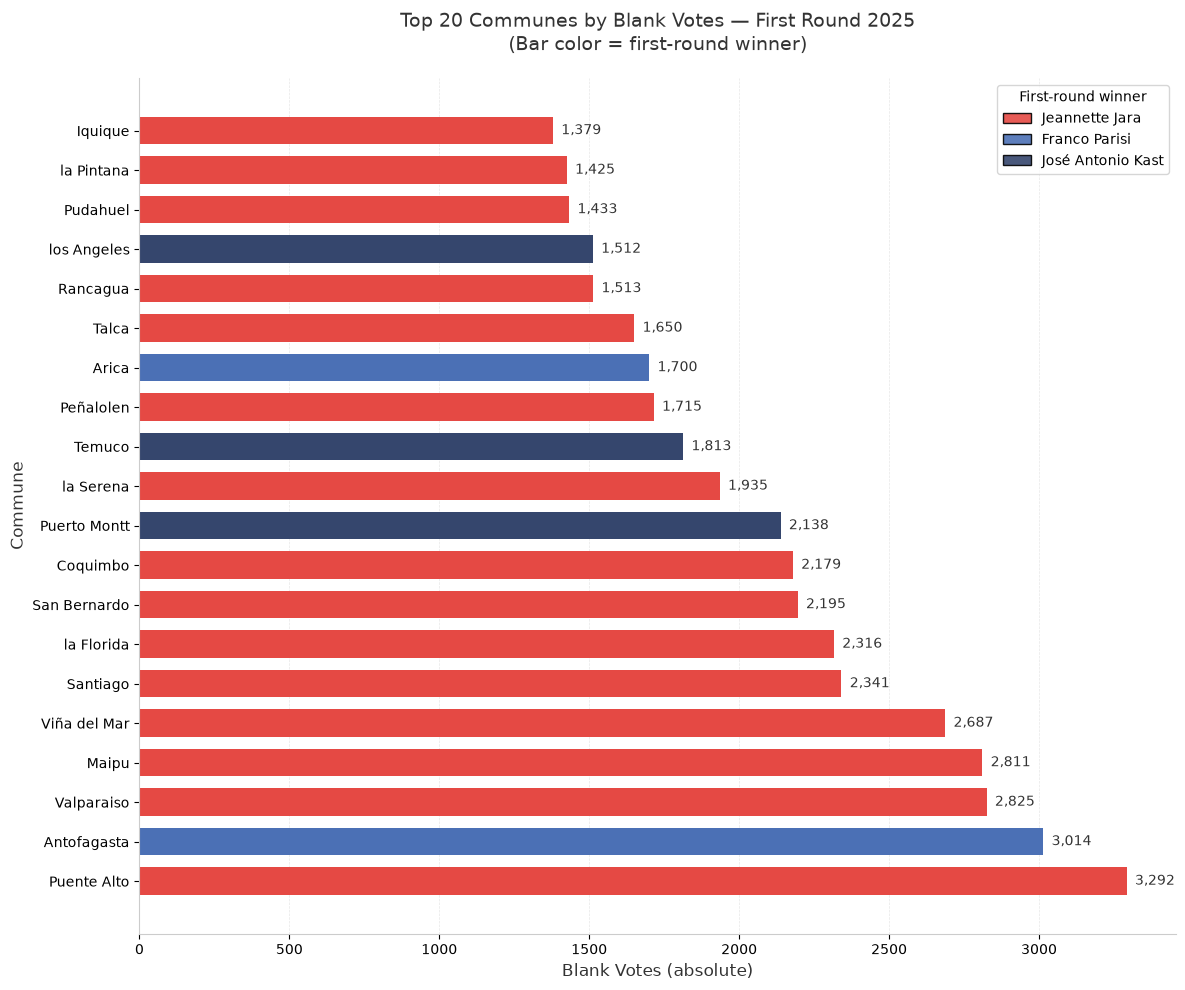

In [93]:
# ============================================================================
# PLOT HELPERS: STYLE, COLOR MAPPING, AND GENERIC BAR CHART
# ============================================================================
# Defines reusable plotting utilities: axis styling, candidate name mapping,
# and a horizontal bar chart for top-N blank vote communes.
# ============================================================================

def set_clean_style(ax):
    """
    Applies a minimal publication-ready style to an Axes object:
    white background, no top/right spines, muted grid on the value axis.
    """
    ax.set_facecolor('white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#cccccc')
    ax.spines['bottom'].set_color('#cccccc')
    ax.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.5, zorder=1)
    return ax

# ============================================================================
# WINNER SHORT-NAME → DISPLAY NAME MAPPING
# ============================================================================
# Maps abbreviated candidate names to full display names for legend labels.

WINNER_NAME_MAPPING = {
    'Parisi':            'Franco Parisi',
    'Kast':              'José Antonio Kast',
    'Jara':              'Jeannette Jara',
    'Kaiser':            'Johannes Kaiser',
    'Matthei':           'Evelyn Matthei',
    'Mayne Nicholls':    'Harold Mayne-Nicholls',
    'Enríquez Ominami':  'Marco Enriquez-Ominami',
    'Artes':             'Eduardo Artes',
}

# ============================================================================
# VISUALIZATION: Top-N Communes by Blank Votes — First Round 2025
# ============================================================================
# Generates a horizontal bar chart of communes with the highest blank vote
# counts. Bar color encodes the first-round winner of each commune.
# ============================================================================

def plot_top_blank_first_round(df: pd.DataFrame, top_n: int = 20) -> None:
    """
    Horizontal bar chart of the communes with the largest blank votes
    in the first round.

    Bar color encodes the first-round winner of each commune.
    Each bar carries one annotation:
      - Blank vote count (bold, offset right of bar tip).

    Parameters
    ----------
    df : pd.DataFrame
        Output of analyze_communes_blank_first_round(), containing at minimum:
        commune, blank_votes, blank_pct_1v, first_round_winner.
    top_n : int, optional
        Number of communes to display (default 20).
    """

    # ---------------------------------------------------------------------------
    # 0. DATA PREPARATION
    # ---------------------------------------------------------------------------
    # Select top-N communes by blank vote count and resolve display names/colors.

    plot_df = df.nlargest(top_n, 'blank_votes').copy()

    # Resolve full display name and color for each bar
    plot_df['winner_full'] = (
        plot_df['first_round_winner']
        .map(WINNER_NAME_MAPPING)
        .fillna('No data')
    )
    plot_df['color'] = (
        plot_df['winner_full']
        .map(CANDIDATE_COLORS)
        .fillna(CANDIDATE_COLORS['No data'])
    )

    # ---------------------------------------------------------------------------
    # 1. VISUALIZATION — HORIZONTAL BAR CHART
    # ---------------------------------------------------------------------------
    # Render bars with annotations and legend.

    fig, ax = plt.subplots(figsize=(12, 10))
    fig.patch.set_facecolor('white')
    ax = set_clean_style(ax)

    # Bars rendered above the grid (zorder=2)
    bars = ax.barh(
        plot_df['commune'],
        plot_df['blank_votes'],
        color=plot_df['color'],
        linewidth=0.8,
        height=0.7,
        zorder=2,
    )

    # Primary annotation: blank vote count
    for bar, value in zip(bars, plot_df['blank_votes']):
        ax.annotate(
            f'{value:,.0f}',
            xy=(bar.get_width(), bar.get_y() + bar.get_height() / 2),
            xytext=(6, 0),
            textcoords='offset points',
            ha='left', va='center',
            fontsize=10,
            color='#333333', zorder=3,
        )

    ax.set_xlabel('Blank Votes (absolute)', fontsize=12, color='#333333')
    ax.set_ylabel('Commune', fontsize=12, color='#333333')
    ax.set_title(
        f'Top {top_n} Communes by Blank Votes — First Round 2025\n'
        '(Bar color = first-round winner)',
        fontsize=14, pad=20, color='#333333',
    )

    # Legend
    legend_elements = [
        Patch(
            facecolor=CANDIDATE_COLORS.get(WINNER_NAME_MAPPING.get(w, 'No data'), CANDIDATE_COLORS['No data']),
            edgecolor='black',
            label=WINNER_NAME_MAPPING.get(w, w),
            alpha=0.9,
        )
        for w in plot_df['first_round_winner'].unique()
    ]
    ax.legend(
        handles=legend_elements,
        loc='upper right',
        title='First-round winner',
        fontsize=10,
        frameon=True,
        facecolor='white',
        edgecolor='#cccccc',
    )

    plt.tight_layout()
    plt.show()

# Execute
plot_top_blank_first_round(commune_blank_metrics, 20)

##### Analysis

**The Dominance of Greater Santiago and the Major Cities**

The chart shows a significant concentration of the blank vote in the major cities, especially in the Metropolitan Region. **Eight of the 20 communes** belong to Greater Santiago (Puente Alto, Maipú, Santiago, La Florida, San Bernardo, Peñalolén, Pudahuel, and La Pintana), reflecting that the blank vote, like the null vote, affects the country's most densely populated urban core. Unlike the null vote, however —where Puente Alto led with 11,758 null votes— the volume of blank votes in these communes is significantly smaller (between 1,400 and 3,300), reflecting that passive protest is less common than active protest in the left's urban strongholds.

The case of **Puente Alto** is particularly telling. With 3,292 blank votes, the country's most populous commune —and a historic stronghold of the left— posts the largest volume of passive protest. This suggests that even in Jara's strongholds, a share of the electorate chose to invalidate its ballot passively, likely as an expression of discontent with the available electoral offer or with the Boric government. The presence of **Maipú** (2,811) and **La Florida** (2,316) in the Top 5 confirms that the blank vote affects the left's main urban strongholds, though with less intensity than the null vote.

**The North as a Second Pole: Antofagasta, Coquimbo, and Arica**

The second pattern to emerge from the chart is the presence of communes in the Norte Grande and Norte Chico where Parisi won the first round. **Antofagasta** (3,014), **Arica** (1,700), and **Coquimbo** (2,179) —the latter won by Jara— appear in the ranking with significant volumes. Antofagasta is particularly notable: with 3,014 blank votes, it ranks as the country's second-largest volume of passive protest, despite having a population far smaller than Puente Alto or Maipú.

Antofagasta's presence in the Top 2, combined with its high null-vote level (8,137, fourth place in the null-vote ranking), suggests that the mining North is a territory where electoral discontent is expressed through both forms of ballot invalidation. The overlap between high blank-vote levels and communes won by Parisi —Antofagasta, Arica— indicates that a share of the anti-establishment electorate opted for passive protest in November, though the predominant form of expressing discontent in the North was the null vote (2.69% versus 1.06% nationally).

**Valparaíso and Viña del Mar: The Centro's Enclave**

**Valparaíso** (2,825) and **Viña del Mar** (2,687) appear in the Top 5, cementing the Valparaíso Region as a territory where the blank vote has a significant presence. The presence of both communes in the blank-vote ranking, combined with their high null-vote level (Valparaíso: 8,242, third place in the null-vote ranking), suggests that the electorate of this coastal region expressed its discontent through both forms of ballot invalidation, reflecting a deeper disaffection than seen in other Centro regions.

**The Exception of the South: Puerto Montt, Temuco, and Los Ángeles**

**Puerto Montt** (2,138), **Temuco** (1,813), and **Los Ángeles** (1,512) —all communes won by Kast— appear in the ranking with moderate volumes. This shows that even in the Republican candidate's strongholds, a share of the electorate chose passive protest in November, albeit with less intensity than in the North or the Centro. The fact that these southern communes appear in the blank-vote ranking but not in the null-vote ranking (with the exception of Puerto Montt, which appears in both) suggests that the South's conservative electorate turned preferentially to the blank vote as a form of expressing discontent, rather than to the null vote.

**A Geography That Outlines Challenges**

The chart reveals a geography of the blank vote that combines **volume in the Centro** (large cities where Jara was strong) with **intensity in the North** (mining and border communes where Parisi was dominant). This duality outlines challenges of a different nature for each candidacy heading into the runoff:

- **For Jara**, the high volume of blank votes in her urban strongholds (Puente Alto, Maipú, La Florida) indicates that she will need to mobilize her base while preventing a share of it from turning to passive protest in the decisive round. Valparaíso's presence in the Top 3 suggests that this coastal region is, in addition, particularly volatile.
- **For Kast**, the blank vote in northern communes where Parisi was strong (Antofagasta, Arica) is a signal worth monitoring: it suggests that a share of the anti-establishment electorate may not feel fully represented by either of the two runoff options. The presence of southern communes (Puerto Montt, Temuco, Los Ángeles) in the blank-vote ranking, albeit to a lesser degree, indicates that even in his strongholds a share of the electorate expressed passive discontent.


#### Chart: Top 20 Communes with the Most Blank Votes (Relative Value)


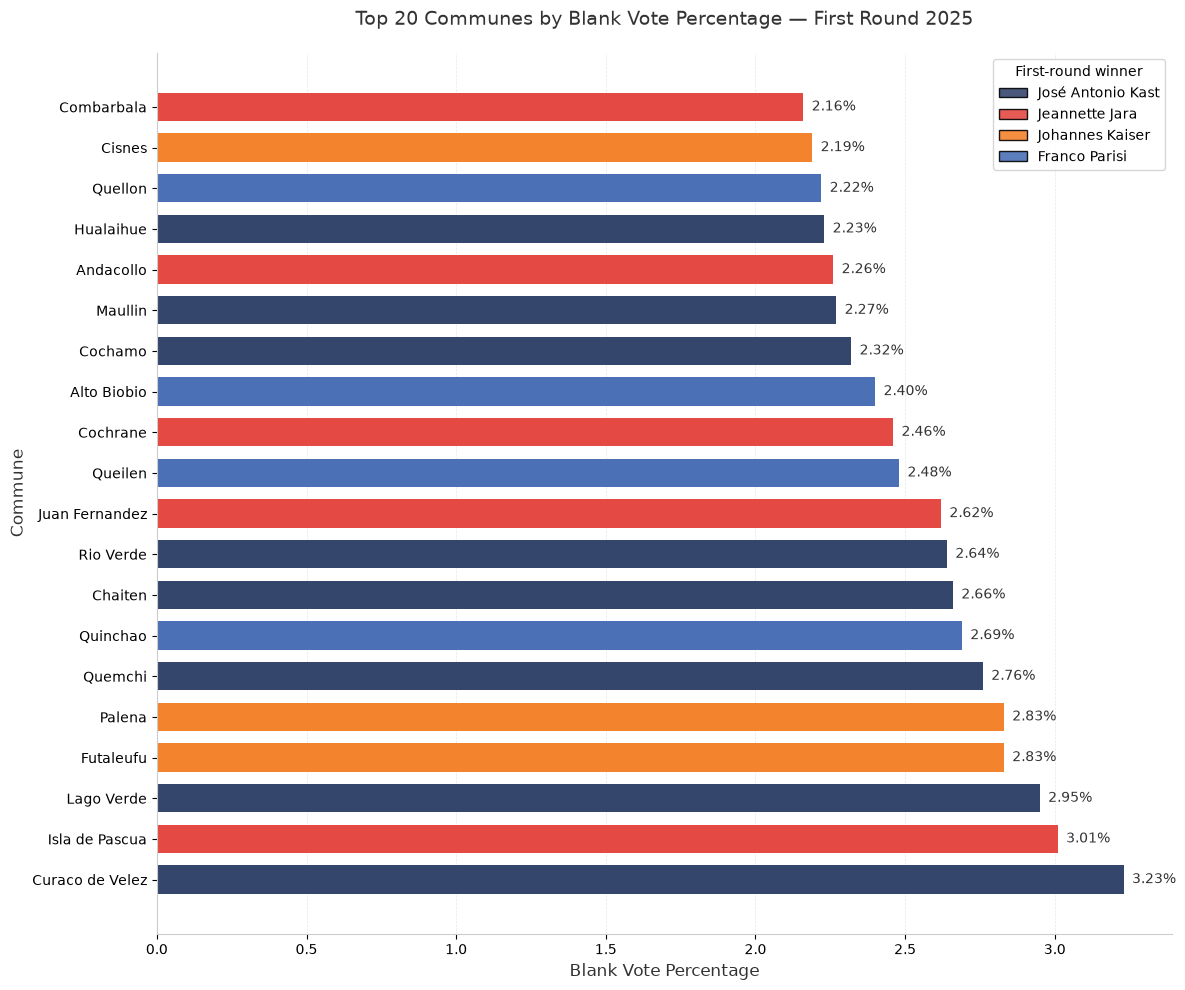

In [94]:
# ============================================================================
# TOP-N COMMUNES BY BLANK VOTE PERCENTAGE — FIRST ROUND 2025
# ============================================================================
# Generates a horizontal bar chart of communes with the highest blank vote
# percentage in the first round. Bar color encodes the first-round winner.
# ============================================================================

# ---------------------------------------------------------------------------
# 1. VISUALIZATION FUNCTION
# ---------------------------------------------------------------------------
# Defines the plotting function for top-N blank vote communes.

def plot_top_blank_pct_first_round(df: pd.DataFrame, top_n: int = 20) -> None:
    """
    Horizontal bar chart of the communes with the largest percentage
    of blank votes in the first round.

    Bar color encodes the first-round winner of each commune.
    Each bar carries one annotation:
      - Blank vote percentage (bold, offset right of bar tip).

    Parameters
    ----------
    df : pd.DataFrame
        Output of analyze_communes_blank_first_round(), containing at minimum:
        commune, blank_pct_1v, first_round_winner.
    top_n : int, optional
        Number of communes to display (default 20).
    """

    plot_df = df.nlargest(top_n, 'blank_pct_1v').copy()

    # Resolve full display name and color for each bar
    plot_df['winner_full'] = (
        plot_df['first_round_winner']
        .map(WINNER_NAME_MAPPING)
        .fillna('No data')
    )
    plot_df['color'] = (
        plot_df['winner_full']
        .map(CANDIDATE_COLORS)
        .fillna(CANDIDATE_COLORS['No data'])
    )

    fig, ax = plt.subplots(figsize=(12, 10))
    fig.patch.set_facecolor('white')
    ax = set_clean_style(ax)

    # Bars rendered above the grid (zorder=2)
    bars = ax.barh(
        plot_df['commune'],
        plot_df['blank_pct_1v'],
        color=plot_df['color'],
        linewidth=0.8,
        height=0.7,
        zorder=2,
    )

    # Primary annotation: percentage of blank votes
    for bar, value in zip(bars, plot_df['blank_pct_1v']):
        ax.annotate(
            f'{value:.2f}%',
            xy=(bar.get_width(), bar.get_y() + bar.get_height() / 2),
            xytext=(6, 0),
            textcoords='offset points',
            ha='left', va='center',
            fontsize=10,
            color='#333333', zorder=3,
        )

    ax.set_xlabel('Blank Vote Percentage', fontsize=12, color='#333333')
    ax.set_ylabel('Commune', fontsize=12, color='#333333')
    ax.set_title(
        f'Top {top_n} Communes by Blank Vote Percentage — First Round 2025',
        fontsize=14, pad=20, color='#333333',
    )

    # Legend 
    legend_elements = [
        Patch(
            facecolor=CANDIDATE_COLORS.get(WINNER_NAME_MAPPING.get(w, 'No data'), CANDIDATE_COLORS['No data']),
            edgecolor='black',
            label=WINNER_NAME_MAPPING.get(w, w),
            alpha=0.9,
        )
        for w in plot_df['first_round_winner'].unique()
    ]
    ax.legend(
        handles=legend_elements,
        loc='upper right',
        title='First-round winner',
        fontsize=10,
        frameon=True,
        facecolor='white',
        edgecolor='#cccccc',
    )

    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------------------------
# 2. EXECUTION
# ---------------------------------------------------------------------------
# Generates the top-20 blank vote percentage chart.

plot_top_blank_pct_first_round(commune_blank_metrics, 20)

##### Analysis

**The Dominance of Patagonia and Isolated Communities**

The chart's most telling finding is the presence of **multiple communes from Patagonia, Aysén, and Chiloé** in the ranking. **Curaco de Vélez** (3.23%), **Easter Island** (3.01%), **Lago Verde** (2.95%), **Futaleufú** (2.83%), **Palena** (2.83%), **Quemchi** (2.76%), **Quinchao** (2.69%), and **Chaitén** (2.66%) top the list. These communes, characterized by low population density, geographic isolation, and heavy dependence on the central state, post the country's highest blank-vote levels. This pattern confirms that the blank vote —like the null vote— operates as a thermometer of territorial discontent in the periphery, where a perceived neglect by the state and disconnection from the political center translate into a passive expression of rejection toward the electoral offer.

The case of **Easter Island** is particularly revealing. With 3.01% blank votes —three times the national average (1.06%)— the island commune, with a tourism-based economy and heavy dependence on the central state for basic services, shows one of the country's highest levels of passive protest. This reflects a deep discontent with Santiago-centered centralism, which on the island is expressed through historical demands for autonomy and greater state investment. The presence of **Juan Fernández** (2.62%) in the ranking confirms that island territories are particularly prone to the blank vote, likely due to their isolation and the perception that national public policy does not address their specific needs.

**Southern Chile as a Second Epicenter**

The second pattern to emerge from the chart is the presence of communes in southern Chile, especially in the regions of Los Lagos, Aysén, and Palena province. **Futaleufú** (2.83%), **Palena** (2.83%), **Quemchi** (2.76%), **Chaitén** (2.66%), **Cochamó** (2.32%), and **Hualaihué** (2.23%) form a bloc of rural, isolated communes where the blank vote exceeds 2.2%. These communes, with economies based on fishing, tourism, and subsistence agriculture, concentrate an electorate that perceives Santiago-centered centralism as a threat to its way of life and to its demands for productive development and connectivity.

The presence of **Quemchi** (2.76%) and **Quinchao** (2.69%) in the ranking confirms that the Chiloé archipelago is a territory where passive discontent has a significant presence. The choice of these communes' electorate to opt for the blank vote —rather than the null vote— suggests that discontent in Chiloé is expressed in a more institutional or passive manner than in the mining North, where active protest (null) is the predominant form of expressing discontent.

**The Political Diversity of High-Blank-Vote Communes**

One notable aspect of the chart is the political diversity of communes with a high blank-vote share. The ranking includes communes won by **Kast** (Curaco de Vélez, Lago Verde, Quemchi, Chaitén, Río Verde, Cochamó, Maullín, Hualaihué), **Jara** (Easter Island, Juan Fernández, Cochrane, Andacollo, Combarbalá), **Kaiser** (Futaleufú, Palena, Cisnes), and **Parisi** (Quinchao, Quellén, Alto Biobío, Quellón). This diversity suggests that the blank vote in the periphery is not an ideological phenomenon but a territorial one: it reflects discontent with centralism and a perceived neglect by the state that cuts across party lines.

The case of **Curaco de Vélez** is particularly notable: the commune, won by Kast, posts the country's highest blank-vote share (3.23%). This suggests that even in the Republican candidate's strongholds, a share of the electorate chose passive protest, likely as an expression of discontent with the available electoral offer or with Santiago-centered centralism. The presence of communes won by **Kaiser** (Futaleufú, Palena, Cisnes) in the ranking is also significant: the libertarian electorate, though largely loyal to its candidate, showed a propensity toward the blank vote in isolated territories, where disconnection from the political center is more pronounced.


##### Comparison with the Null Vote: Two Forms of Peripheral Discontent

Comparing the blank-vote ranking with the null-vote ranking reveals significant differences that enrich our understanding of peripheral discontent:

- **Intensity:** The null vote in the periphery (2.92% in the Norte Grande, 3.16% in Patagonia) is more frequent than the blank vote (1.09% in the Norte Grande, 1.49% in Patagonia). Yet in the ranking of communes with the highest blank-vote percentage, levels reach 3.23% (Curaco de Vélez), exceeding the national null-vote average (2.69%). This suggests that, although the null vote is the predominant form of protest in aggregate terms, in some isolated communes the blank vote reaches exceptional levels.
- **Territoriality:** While the null vote is concentrated in the mining North (Antofagasta, Atacama) and in some Patagonian communes, the blank vote is concentrated in southern Chile —especially Patagonia, Aysén, and Chiloé— and in island territories. This difference suggests that active protest (null) is more intense in territories where the anti-establishment electorate (Parisi) was strongest, while passive protest (blank) is more frequent in territories where a perceived neglect by the state and geographic isolation are more pronounced.
- **Voter profile:** The literature on electoral behavior suggests that the blank vote is more common among voters with higher education levels and a more institutional relationship with the political system. The concentration of the blank vote in communes of Patagonia and Chiloé —where education levels are generally lower than in the Centro— appears to contradict this hypothesis. It is possible, however, that in these territories the blank vote reflects a more "traditional" or "respectful" form of protest toward the electoral system, in contrast with the null vote, which implies a more explicit, confrontational rejection.


#### Distribution of the Blank Vote by First-Round Winner


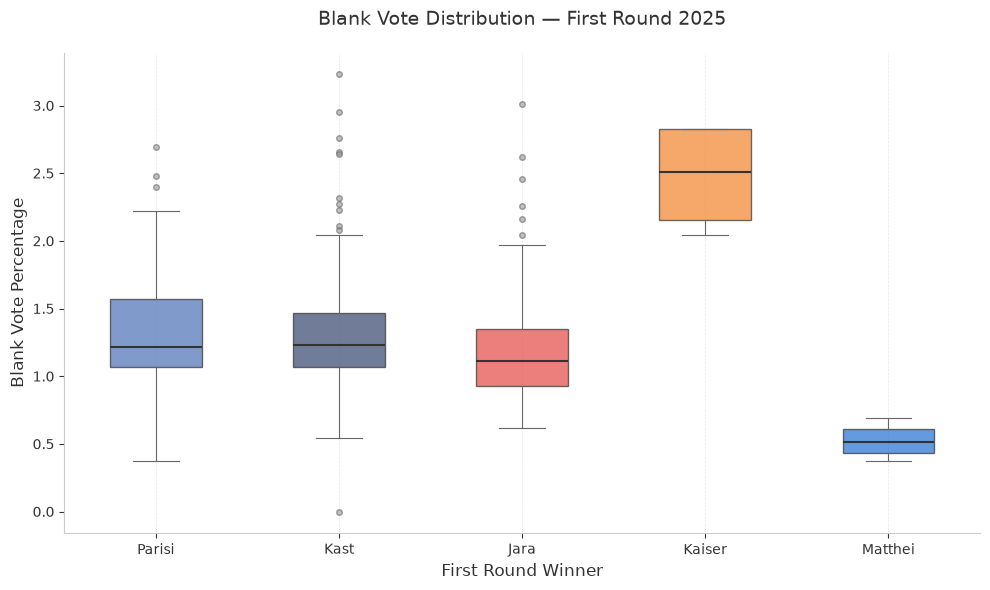

In [95]:
# ============================================================================
# BLANK VOTE DISTRIBUTION — FIRST ROUND 2025
# ============================================================================
# Generates a box plot of blank vote percentage grouped by first-round winner.
# Filters to top candidates with sufficient commune representation.
# ============================================================================

# ---------------------------------------------------------------------------
# 0. DATA PREPARATION
# ---------------------------------------------------------------------------
# Filter communes to top winners for meaningful distribution analysis.

top_winners = ['Parisi', 'Kast', 'Jara', 'Kaiser', 'Matthei']
plot_df = commune_blank_metrics[
    commune_blank_metrics['first_round_winner'].isin(top_winners)
].copy()

# ---------------------------------------------------------------------------
# 1. VISUALIZATION — BOX PLOT
# ---------------------------------------------------------------------------
# Create box plot with candidate-specific coloring.

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('white')
ax = set_clean_style(ax)

# Prepare data for box plots
box_data = [
    plot_df[plot_df['first_round_winner'] == winner]['blank_pct_1v']
    for winner in top_winners
]

# Create box plot with custom styling
boxes = ax.boxplot(
    box_data,
    patch_artist=True,
    medianprops={'color': '#333333', 'linewidth': 1.5},
    whiskerprops={'color': '#666666', 'linewidth': 0.8},
    capprops={'color': '#666666', 'linewidth': 0.8},
    flierprops={
        'marker': 'o',
        'markerfacecolor': '#999999',
        'markeredgecolor': '#666666',
        'markersize': 4,
        'alpha': 0.6
    }
)

# Set x-tick labels after boxplot creation
ax.set_xticklabels(top_winners)

# Color each box consistently with candidate colors
for box, winner in zip(boxes['boxes'], top_winners):
    full_name = WINNER_NAME_MAPPING.get(winner, winner)
    color = CANDIDATE_COLORS.get(full_name, CANDIDATE_COLORS.get('No data', '#dddddd'))
    box.set_facecolor(color)
    box.set_alpha(0.7)
    box.set_edgecolor('#333333')
    box.set_linewidth(1)

# Labels and title
ax.set_xlabel('First Round Winner', fontsize=12, color='#333333')
ax.set_ylabel('Blank Vote Percentage', fontsize=12, color='#333333')
ax.set_title(
    'Blank Vote Distribution — First Round 2025',
    fontsize=14, pad=20, color='#333333'
)

# Style adjustments
ax.tick_params(axis='both', colors='#333333', labelsize=10)

plt.tight_layout()
plt.show()

##### Analysis by Candidate

**Parisi (median ~1.25%, range 1.1–1.6%)**

Communes won by Franco Parisi show a relatively compact distribution, with a median of roughly 1.25% and the central 50% of his communes concentrated between 1.1% and 1.6%. The group shows several high outliers approaching 2.7%, corresponding to communes where the blank vote was significantly higher than Parisi's average. The presence of these outliers suggests that, while Parisi's electorate as a whole showed a moderate propensity toward the blank vote, in certain specific communes —likely the most isolated or with the greatest perceived neglect by the state— passive protest reached exceptional levels. The overlap between high outliers and communes in Patagonia and Chiloé (such as Quinchao and Quellón, which appear in the blank-vote ranking) reinforces the interpretation that the blank vote among Parisi's electorate is tied to territorial rather than ideological factors.

**Kast (median ~1.25%, range 1.1–1.5%)**

Communes won by José Antonio Kast show a median similar to Parisi's (~1.25%), with the central 50% concentrated between 1.1% and 1.5%. However, this is the group with the **largest number and dispersion of outliers**. It shows an extreme outlier at 0% and several very high values above 3.0% (coinciding with communes such as Curaco de Vélez and Lago Verde, which appear in the blank-vote ranking). This high dispersion suggests that Kast's electorate is the most heterogeneous in terms of propensity toward the blank vote: while passive protest is moderate in most of his communes, in certain isolated peripheral communes —especially in Patagonia and Chiloé— the blank vote reaches exceptional levels, an indication that this peripheral segment of his electorate is also the least consolidated.

**Jara (median ~1.1%, range 0.95–1.35%)**

Communes won by Jeannette Jara show the lowest median among the main candidates (~1.1%), with a very compact box between 0.95% and 1.35%. The group shows several high outliers, the highest approaching 3.0% (corresponding to Easter Island, which appears in the blank-vote ranking). The low median and compact box suggest that Jara's electorate is, generally speaking, the least prone to the blank vote among the main candidates —with the exception of Matthei— reflecting greater discipline and loyalty within her base. Yet the presence of high outliers in isolated communes (Easter Island, Juan Fernández, Cochrane) indicates that, in the periphery, even Jara's strongholds can show significant levels of passive protest, likely tied to a perceived neglect by the state.

**Kaiser (median ~2.5%, range 2.2–2.8%) – The Anomaly**

The most distinctive, atypical group is that of communes won by Johannes Kaiser. His median is roughly **2.5%**, more than double the national average (1.06%) and significantly higher than the other main candidates. The central 50% of his communes is concentrated between 2.2% and 2.8%, and his maximum value (excluding outliers) is around 2.1%. No outliers are observed in this group, indicating an extremely compact, homogeneous distribution.

This pattern matters because the communes where Kaiser won the first round —Futaleufú, Palena, Cisnes, and other localities in Patagonia and Aysén— are isolated territories with a high perceived neglect by the state. The high blank-vote level in these communes suggests that the libertarian electorate in the periphery is particularly prone to passive protest, likely because it combines rejection of centralism with distrust of the traditional political system that is not necessarily channeled through the null vote. The absence of outliers suggests that this behavior is uniform across all of Kaiser's communes, indicating that the blank vote is a structural feature of the libertarian electorate in the periphery.

**Matthei (median ~0.5%, range 0.45–0.6%) – The Exception**

The most extreme, atypical group is that of communes won by Evelyn Matthei. Her median is roughly **0.5%**, the lowest of all, and the central 50% of her communes is concentrated between 0.45% and 0.6%. Her maximum value (upper whisker) does not exceed 0.7%, confirming that the traditional right's electorate was the most disciplined and the least prone to passive protest.

This pattern is consistent with the profile of Matthei's electorate: high-income communes on Santiago's east side, with higher education levels, higher incomes, and a more institutional relationship with the political system. The low propensity toward the blank vote in these communes reflects greater confidence in the electoral system and a lower disposition toward protest —active or passive— as a form of political expression while they had a candidate of their own sector in the race.

##### Chart Conclusions

**The blank vote was a cross-cutting phenomenon, but with differentiated intensities.** Parisi, Kast, and Jara show very similar medians and dispersion ranges (oscillating between 1% and 1.5% across the bulk of their communes). This suggests that passive protest, like active protest (null), was not exclusive to one political bloc but affected every sector, albeit with varying intensity depending on the territory.

**Kaiser's anomaly.** The communes won by the libertarian candidate in the first round had a **much higher** blank-vote share (2.5% median), reflecting that Kaiser's electorate in the periphery is particularly prone to passive protest. This pattern suggests that the blank vote among the libertarian electorate is tied to territorial factors —isolation, a perceived neglect by the state— rather than to active distrust of the political system.

**Matthei, once again the exception.** As with the null vote, Matthei's communes show **extremely low** blank-vote percentages (barely 0.5% on average), confirming that the traditional right's electorate was the most disciplined and the least prone to passive protest in the first round.

**An open question heading into the runoff.** How Matthei's electorate and Kaiser's electorate will behave going forward —both disciplined in November, though for different reasons— is one of the main unknowns this analysis leaves open: the former, because it is a historically institutional bloc that will have to decide its vote without a candidate of its own in the race; the latter, because of the more peripheral, volatile nature of much of its electorate. Whether Kast and Jara can reduce the blank vote in their respective strongholds, and draw those electorates toward an active choice, is one of the factors Chapter 12 explores in greater depth based on the transfer patterns observed in previous elections.


### Conclusion 5.2.


The analysis of the first-round blank vote confirms that passive protest is a territorially differentiated phenomenon that complements —and contrasts with— the pattern observed for the null vote. In absolute volume, the blank vote is concentrated in the large cities of Greater Santiago —Puente Alto (3,292), Maipú (2,811), and Santiago (2,341)— where even in Jara's strongholds a share of the electorate chose to passively invalidate its ballot. Yet the volume of blank votes in these communes is significantly smaller than that of null votes (a null-to-blank ratio of ~3.6:1 in Puente Alto), reflecting that active protest was the predominant form of expressing discontent in the left's urban strongholds.

In relative terms, the blank vote is proportionally more intense in Patagonia and the Sur —Curaco de Vélez (3.23%), Easter Island (3.01%), and Lago Verde (2.95%)— than in the mining North, where the null vote is the predominant form of protest. This difference suggests that passive protest is more frequent in territories where a perceived neglect by the state and geographic isolation are more pronounced, while active protest is more intense in the mining North, where the anti-establishment electorate (Parisi) was strongest. The political diversity of high-blank-vote communes —which includes strongholds of Kast, Jara, Kaiser, and Parisi— confirms that the blank vote in the periphery is not an ideological phenomenon but a territorial one: it reflects discontent with centralism and a perceived neglect by the state that cuts across party lines.

The distribution of the blank vote by first-round winner reveals that Kaiser is the anomaly, with a median of 2.5% —more than double the national average— reflecting that the libertarian electorate in the periphery is particularly prone to passive protest. Matthei, by contrast, shows the lowest median (0.5%), confirming that the traditional right's electorate was the most disciplined in the first round. Taken together, these findings confirm that the blank vote, though modest in magnitude, is a thermometer of passive discontent that complements the null-vote analysis, and that its reading is especially relevant for the traditional right and the libertarian electorate, whose behavior heading into the runoff is one of the main open questions this chapter leaves behind.


### 5.3. Communes with the Lowest Blank Vote: The Absence of Passive Protest


The analysis of communes with the lowest share of blank votes in the first round reveals a pattern that complements the geography of passive discontent: these are territories where the electorate did not turn to passively invalidating its ballot, either because it found a representative option on the ballot, or because its relationship with the political system is highly institutional. Unlike the high-blank-vote communes —concentrated in Patagonia and Chiloé— the lowest-blank communes are characterized by low population density, extreme-territory status (Antarctica), or membership in Parisi strongholds in the North, where the anti-establishment electorate channeled its discontent through the vote for the Partido de la Gente's candidate, without needing to resort to passive protest. The most extreme case is Antarctica, with 0% blank votes, followed by General Lagos (0.47%), Colchane (0.41%), and Sierra Gorda (0.37%), all communes where Parisi won the first round and where the vote for the anti-establishment candidate acted as a substitute for the blank vote.


In [96]:
# ============================================================================
# TOP 20 COMMUNES WITH LOWEST BLANK VOTES — FIRST ROUND 2025
# ============================================================================
# Computes blank vote statistics per commune (blank votes, blank percentage,
# valid votes and first-round winner), then ranks the 20 communes with the
# lowest absolute blank votes.
# ============================================================================

# ---------------------------------------------------------------------------
# 0. DATA PREPARATION
# ---------------------------------------------------------------------------
# Defines a helper function that calculates commune‑level blank vote metrics
# and identifies the winning candidate in each commune.

def compute_commune_blank_stats(df: pd.DataFrame) -> pd.DataFrame:
    """
    Computes commune‑level blank vote indicators and first‑round winner.

    Parameters
    ----------
    df : pd.DataFrame
        Electoral data with candidate vote columns and casted/blank/null totals.

    Returns
    -------
    pd.DataFrame
        Columns: commune, region, valid_votes_first_round, blank_votes,
        blank_pct_1v, first_round_winner.
    """
    candidate_cols = ['jara_votes', 'kast_votes', 'parisi_votes', 'kaiser_votes',
                      'matthei_votes', 'mayne_nicholls_votes', 'enriquez_ominami_votes',
                      'artes_votes']
    candidate_names = ['Jara', 'Kast', 'Parisi', 'Kaiser', 'Matthei',
                       'Mayne Nicholls', 'Enríquez Ominami', 'Artes']

    votes_prep = df.copy()

    # Determines the candidate with the highest vote count per commune
    votes_prep['first_round_winner'] = votes_prep[candidate_cols].idxmax(axis=1)
    winner_map = dict(zip(candidate_cols, candidate_names))
    votes_prep['first_round_winner'] = votes_prep['first_round_winner'].map(winner_map)

    # Calculates valid votes and blank vote percentage
    votes_prep['valid_votes_first_round'] = (
        votes_prep['casted_votes'] - votes_prep['null_votes'] - votes_prep['blank_votes']
    )
    votes_prep['blank_pct_1v'] = round(
        100.0 * votes_prep['blank_votes'] / votes_prep['casted_votes'], 2
    )

    commune_blank_metrics = votes_prep[[
        'commune', 'region',
        'valid_votes_first_round',
        'blank_votes',
        'blank_pct_1v',
        'first_round_winner'
    ]]

    return commune_blank_metrics

# ---------------------------------------------------------------------------
# 1. METRIC CALCULATION
# ---------------------------------------------------------------------------
# Applies the blank vote statistics function to the first‑round dataset.

commune_blank_metrics = compute_commune_blank_stats(df_votes)

# ---------------------------------------------------------------------------
# 2. RANKING
# ---------------------------------------------------------------------------
# Extracts the 20 communes with the lowest absolute blank votes.

lowest_blank_votes_top_20 = commune_blank_metrics.nsmallest(20, 'blank_votes')

# ---------------------------------------------------------------------------
# 3. TABLE OUTPUT
# ---------------------------------------------------------------------------
# Displays the top 20 communes ranked by fewest blank votes.

print("=" * 80)
print("TOP 20 COMMUNES WITH FEWEST BLANK VOTES")
print("=" * 80)
lowest_blank_votes_top_20

TOP 20 COMMUNES WITH FEWEST BLANK VOTES


,commune,region,valid_votes_first_round,blank_votes,blank_pct_1v,first_round_winner
187,Antartica,Magallanes,77,0,0.00,Kast
11,General Lagos,Arica y Parinacota,617,3,0.47,Parisi
6,Sierra Gorda,Antofagasta,1055,4,0.37,Parisi
196,Timaukel,Magallanes,232,4,1.65,Kast
192,Primavera,Magallanes,392,5,1.24,Jara
282,Colchane,Tarapacá,1213,5,0.41,Parisi
31,Tortel,Aysén,393,7,1.68,Jara
4,Ollague,Antofagasta,734,8,1.07,Parisi
195,San Gregorio,Magallanes,375,8,2.04,Kaiser
29,O'higgins,Aysén,441,9,1.97,Kast


#### Analysis

##### The Case of Antarctica: The Commune Without a Blank Vote

Antarctica (0% blank votes) is the most extreme case of electoral discipline. With only 77 valid votes cast, the commune —made up mainly of scientific and military bases— shows atypical electoral behavior: a highly institutionalized electorate with a functional relationship to the political system and a low propensity toward passive protest. The total absence of blank votes in Antarctica reflects not only the profile of its electorate but also the nature of the commune itself: a territory with minimal population, where voting is a more administrative than political act, and where the available electoral offer is processed without resorting to ballot invalidation. The fact that Antarctica was won by Kast with 45.45% of the vote confirms that this is a territory of high electoral loyalty, where passive protest is virtually nonexistent.

##### The Concentration in the Parisi-Voting North: The Anti-Establishment Vote as a Substitute for the Blank Vote

One notable finding in the low-blank-vote ranking is the presence of Norte Grande communes where Parisi won the first round: General Lagos (0.47% blank votes), Colchane (0.41%), Sierra Gorda (0.37%), Ollagüe (1.07%), Camiña (0.52%), and Camarones (0.82%). These communes, all strongholds of the anti-establishment candidate, show blank-vote levels well below the national average (1.06%) and, in some cases, even below 1%.

The case of Colchane (0.41%) and Sierra Gorda (0.37%) is particularly telling. Both communes, located in the Norte Grande, were where Parisi achieved his best results nationwide (57.30% and 41.90%, respectively). Yet the blank vote there is minimal, indicating that the electorate that backed Parisi did not additionally resort to passive protest, likely because the anti-establishment candidate was already channeling its discontent. This suggests that, in some northern communes, the vote for Parisi acted as a substitute for the blank vote: voters disillusioned with the traditional political system found in the Partido de la Gente's candidate a channel of expression for their discontent, without needing to passively invalidate their ballot. This behavior is consistent with the finding that, in communes Parisi won, the median blank vote (1.25%) is similar to that of the other main candidates, and that the correlation between the Parisi vote and the blank vote is virtually nil (Pearson: 0.064).

##### Patagonia's Low Presence in the Lowest-Blank-Vote Ranking

Unlike the lowest-null-vote ranking —where Patagonia dominated broadly— Patagonian communes have a more limited presence, and higher percentages, in the lowest-blank-vote ranking. Timaukel (1.65%), Primavera (1.24%), Tortel (1.68%), San Gregorio (2.04%), O'Higgins (1.97%), Cabo de Hornos (0.82%), Laguna Blanca (2.08%), Río Verde (2.64%), Torres del Paine (1.78%), and Guaitecas (1.86%) —all in Magallanes and Aysén— show blank-vote levels that, while below the national average in some cases, are significantly higher than those observed in the Parisi-voting North.

This suggests that, in Patagonia, the blank vote is more common than in the mining North, reflecting a less confrontational relationship with the political system. The Patagonian electorate, while discontented with centralism, maintains a more institutional relationship with the electoral system, turning to passive protest (blank vote) rather than active protest (null vote) or transferring support to an anti-establishment candidate. This difference between the North and Patagonia is consistent with the finding that the null vote is concentrated in the mining North —where the anti-establishment electorate is more radical— while the blank vote is concentrated in Patagonia and the Sur, where a perceived neglect by the state and geographic isolation are more pronounced but the relationship with the political system is less confrontational.

##### Elite and Traditional-Right Communes: Absent from the Ranking

One notable finding is the absence of Santiago's elite communes —Vitacura, Las Condes, Providencia, La Reina— from the lowest-blank-vote ranking. These communes, which in the first round showed low blank-vote levels (Matthei median: 0.5%), do not appear in the Top 20 lowest simply because their vote volume is far larger than that of Patagonian and northern communes. Even so, the elite electorate's behavior is consistent with the overall pattern: traditional-right voters, characterized by higher education levels, higher incomes, and a more institutional relationship with the political system, resorted to passive protest far less often than the electorates of other blocs.

### Conclusion 5.3.

The analysis of the lowest-blank-vote communes reveals that passive protest is minimal in territories where the electorate found a representative option on the ballot —especially in Parisi's northern strongholds— or where the relationship with the political system is highly institutional, as in Antarctica (0%) and the low-density communes of Patagonia. In northern communes where Parisi was strong and the blank vote was low —General Lagos (0.47%), Colchane (0.41%), Sierra Gorda (0.37%), Ollagüe (1.07%), Camiña (0.52%)— the vote for the anti-establishment candidate acted as a substitute for passive protest, reflecting that voters disillusioned with the traditional political system found in the Partido de la Gente a channel of expression for their discontent, without needing to invalidate their ballot.

The presence of Patagonian communes in the lowest-blank-vote ranking —albeit with higher percentages than the North— confirms that the relationship with the political system in the far south is less confrontational than in the mining North. The Patagonian electorate, while discontented with centralism, maintains a more institutional relationship with the electoral system, turning to passive protest (blank vote) rather than active protest (null vote) or transferring support to an anti-establishment candidate.

Taken together, the geography of discipline with respect to the blank vote confirms that the absence of passive protest follows different logics depending on the territory: substitution by the anti-establishment vote in the Parisi-voting North, the institutional relationship characteristic of Patagonia, and the discipline of the traditional right in elite communes. The low population density of most of these communes, however, limits the weight of this behavior in the aggregate national result, making its relevance more illustrative —of the different logics of electoral discipline that coexist across the country— than decisive for the final outcome.


### 5.4. Map of Blank-Vote Intensity by Commune


/tmp/ipykernel_359531/2944547610.py:169: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 1, 0.94])


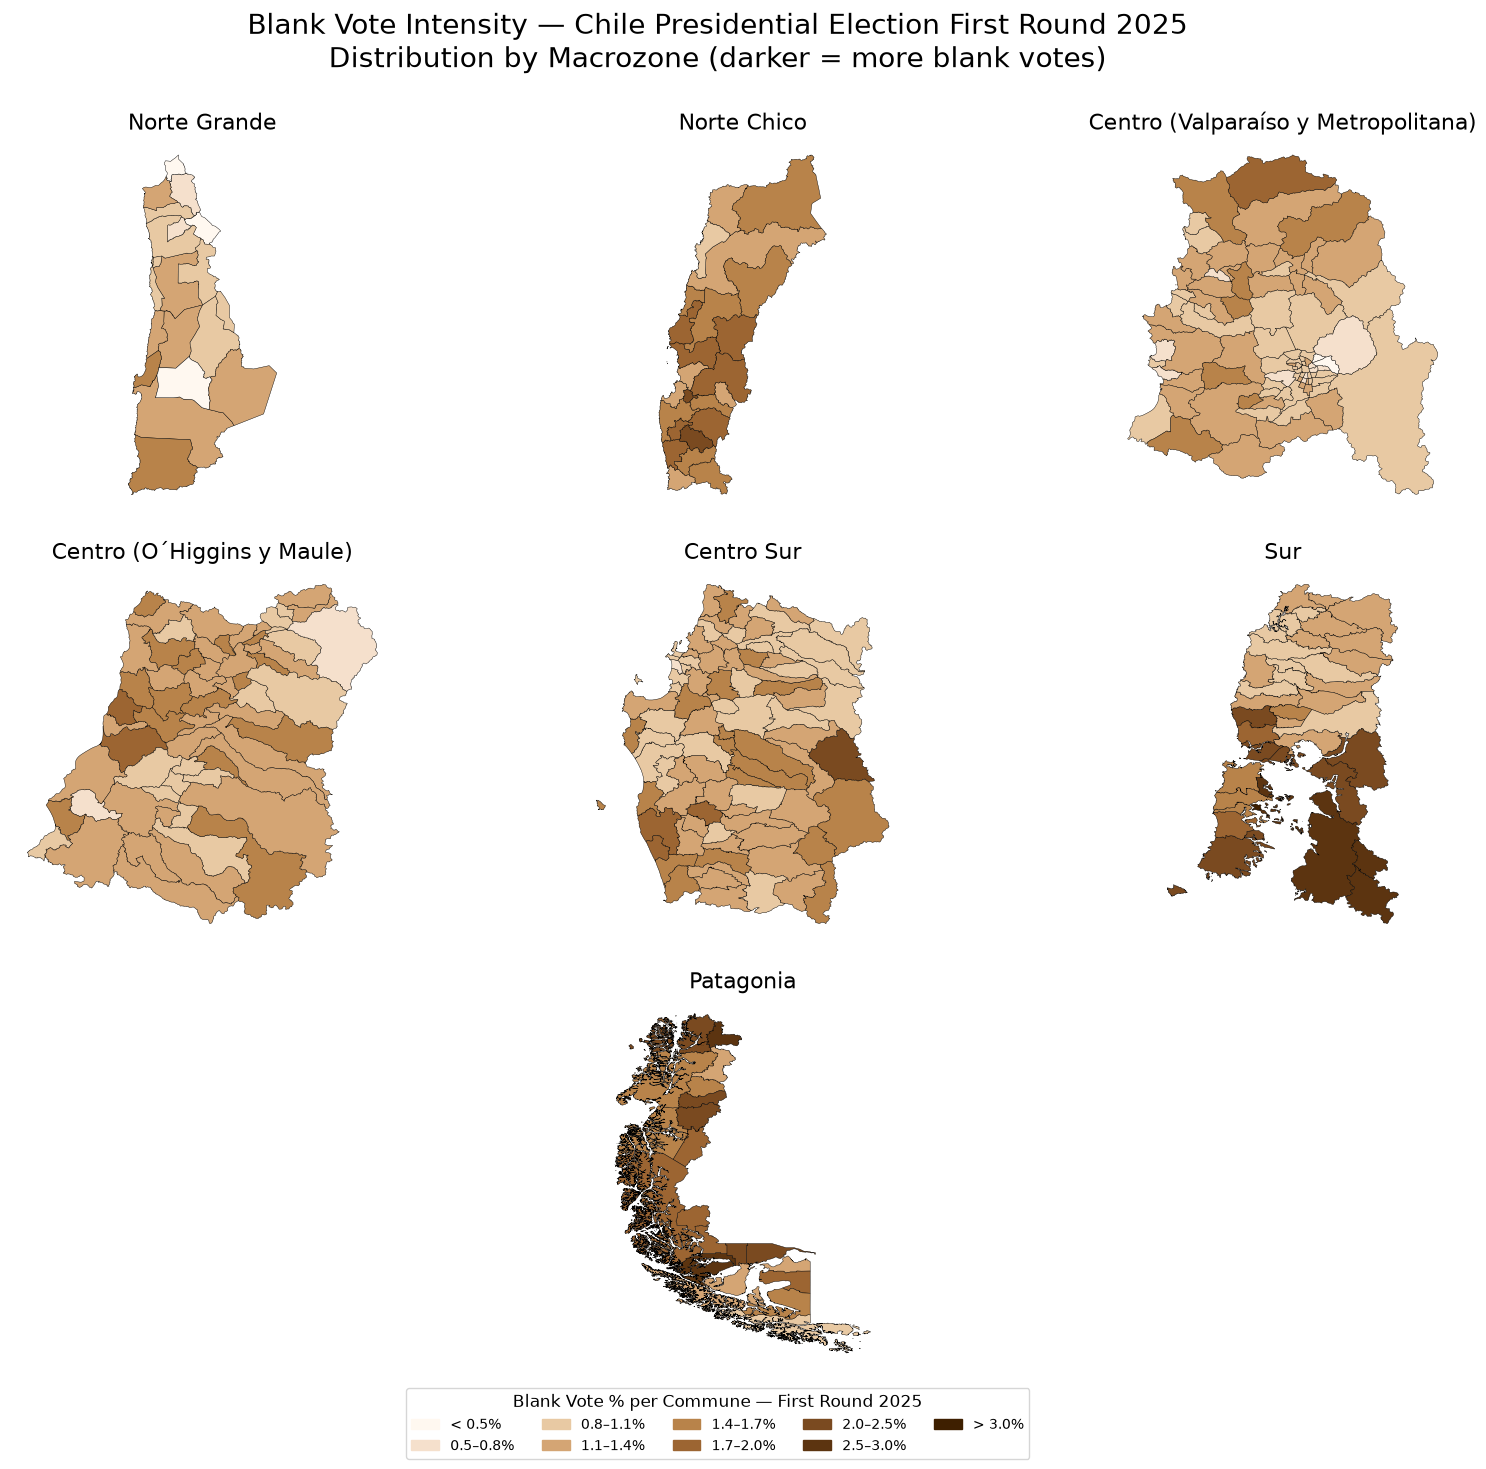

In [97]:
# ============================================================================
# BLANK VOTE INTENSITY MAP BY COMMUNE — FIRST ROUND 2025
# ============================================================================
# Generates a 3x3 grid map of blank vote percentage by macrozone.
# Uses a cream-to-dark-brown color scale for intensity visualization.
# ============================================================================

# ---------------------------------------------------------------------------
# 0. DATA PREPARATION
# ---------------------------------------------------------------------------
# Copy base dataframe and calculate blank vote percentage per commune.
df_votes_map = df_votes.copy()
df_votes_map['blank_pct'] = (df_votes_map['blank_votes'] / df_votes_map['casted_votes'] * 100).round(2)

# Normalize commune names for spatial join.
communes_map = communes.copy()
communes_map['NOM_COM_NORM'] = communes_map['NOM_COM'].apply(normalize_commune_name)
df_votes_map['commune_norm'] = df_votes_map['commune'].apply(normalize_commune_name)

# Merge geometries with blank vote data.
map_data = communes_map.merge(
    df_votes_map[['commune_norm', 'blank_pct']],
    left_on='NOM_COM_NORM',
    right_on='commune_norm',
    how='left',
)

# Exclude island communes.
map_data = map_data[~map_data['NOM_COM'].str.contains('Isla de Pascua|Juan Fernández', case=False, na=False)]

# Assign macrozone based on region number.
MACROZONE_MAP = {
    15: 'Norte Grande',
    1:  'Norte Grande',
    2:  'Norte Grande',
    3:  'Norte Chico',
    4:  'Norte Chico',
    5:  'Centro (Valparaíso y Metropolitana)',
    13: 'Centro (Valparaíso y Metropolitana)',
    6:  'Centro (O\u00b4Higgins y Maule)',
    7:  'Centro (O\u00b4Higgins y Maule)',
    16: 'Centro Sur',
    8:  'Centro Sur',
    9:  'Centro Sur',
    14: 'Sur',
    10: 'Sur',
    11: 'Patagonia',
    12: 'Patagonia',
}

map_data['macrozone'] = map_data['REGION_NUM'].map(MACROZONE_MAP)

# ---------------------------------------------------------------------------
# 1. COLOR SCALE FUNCTION
# ---------------------------------------------------------------------------
# Returns color based on blank vote percentage (cream to dark brown gradient).
def get_blank_color(blank_pct):
    """Return color based on blank vote percentage (cream to dark brown gradient)."""
    if pd.isna(blank_pct):
        return '#D3D3D3'
    if blank_pct < 0.5:
        return '#FFF8F0'
    elif blank_pct < 0.8:
        return '#F5E0CC'
    elif blank_pct < 1.1:
        return '#E8C9A3'
    elif blank_pct < 1.4:
        return '#D4A574'
    elif blank_pct < 1.7:
        return '#B8834A'
    elif blank_pct < 2.0:
        return '#9C6532'
    elif blank_pct < 2.5:
        return '#7A4A20'
    elif blank_pct < 3.0:
        return '#5C3410'
    else:
        return '#3E1F00'

# Apply color scale.
map_data['color'] = map_data['blank_pct'].apply(get_blank_color)

# ---------------------------------------------------------------------------
# 2. GRID LAYOUT CONFIGURATION
# ---------------------------------------------------------------------------
# Create 3x3 grid figure.
fig = plt.figure(figsize=(20, 16))
gs = GridSpec(3, 3, figure=fig, hspace=0.15, wspace=0.15)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[1, 2])
ax7 = fig.add_subplot(gs[2, 1])

zone_axes = [
    (ax1, 'Norte Grande'),
    (ax2, 'Norte Chico'),
    (ax3, 'Centro (Valparaíso y Metropolitana)'),
    (ax4, 'Centro (O\u00b4Higgins y Maule)'),
    (ax5, 'Centro Sur'),
    (ax6, 'Sur'),
    (ax7, 'Patagonia'),
]

# ---------------------------------------------------------------------------
# 3. MACROZONE MAP PLOTTING
# ---------------------------------------------------------------------------
# Plot each macrozone in its respective grid cell.
for ax, macro in zone_axes:
    macro_data = map_data[map_data['macrozone'] == macro].copy()
    if macro_data.empty:
        ax.text(0.5, 0.5, f'No data\n{macro}', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(macro, fontsize=14)
        ax.set_axis_off()
        continue

    macro_data.plot(ax=ax, color=macro_data['color'], edgecolor='black', linewidth=0.3)
    ax.set_title(macro, fontsize=16)
    ax.set_axis_off()
    ax.set_aspect('equal')

    # Adjust Patagonia bounds for better visibility.
    if macro == 'Patagonia':
        bounds = macro_data.total_bounds
        margin_x = (bounds[2] - bounds[0]) * 0.05
        margin_y = (bounds[3] - bounds[1]) * 0.05
        ax.set_xlim(bounds[0] - margin_x, bounds[2] + margin_x)
        ax.set_ylim(bounds[1] - margin_y, bounds[3] + margin_y)

# Hide unused grid cells.
ax_empty1 = fig.add_subplot(gs[2, 0])
ax_empty2 = fig.add_subplot(gs[2, 2])
ax_empty1.set_visible(False)
ax_empty2.set_visible(False)

# Set main title.
fig.suptitle(
    'Blank Vote Intensity — Chile Presidential Election First Round 2025\nDistribution by Macrozone (darker = more blank votes)',
    fontsize=20, y=0.96,
)

# ---------------------------------------------------------------------------
# 4. LEGEND CONFIGURATION
# ---------------------------------------------------------------------------
# Define legend entries with color ranges.
legend_entries = [
    ('< 0.5%',   '#FFF8F0'),
    ('0.5–0.8%', '#F5E0CC'),
    ('0.8–1.1%', '#E8C9A3'),
    ('1.1–1.4%', '#D4A574'),
    ('1.4–1.7%', '#B8834A'),
    ('1.7–2.0%', '#9C6532'),
    ('2.0–2.5%', '#7A4A20'),
    ('2.5–3.0%', '#5C3410'),
    ('> 3.0%',   '#3E1F00'),
]

legend_handles = [mpatches.Patch(color=color, label=label) for label, color in legend_entries]

fig.legend(
    handles=legend_handles, loc='lower center', ncol=5, fontsize=10,
    title='Blank Vote % per Commune — First Round 2025', title_fontsize=12,
    bbox_to_anchor=(0.5, 0.05),
)

plt.tight_layout(rect=[0, 0.05, 1, 0.94])
plt.show()

### 5.5. Map of Blank-Vote Intensity in Metropolitan Areas and Conurbations


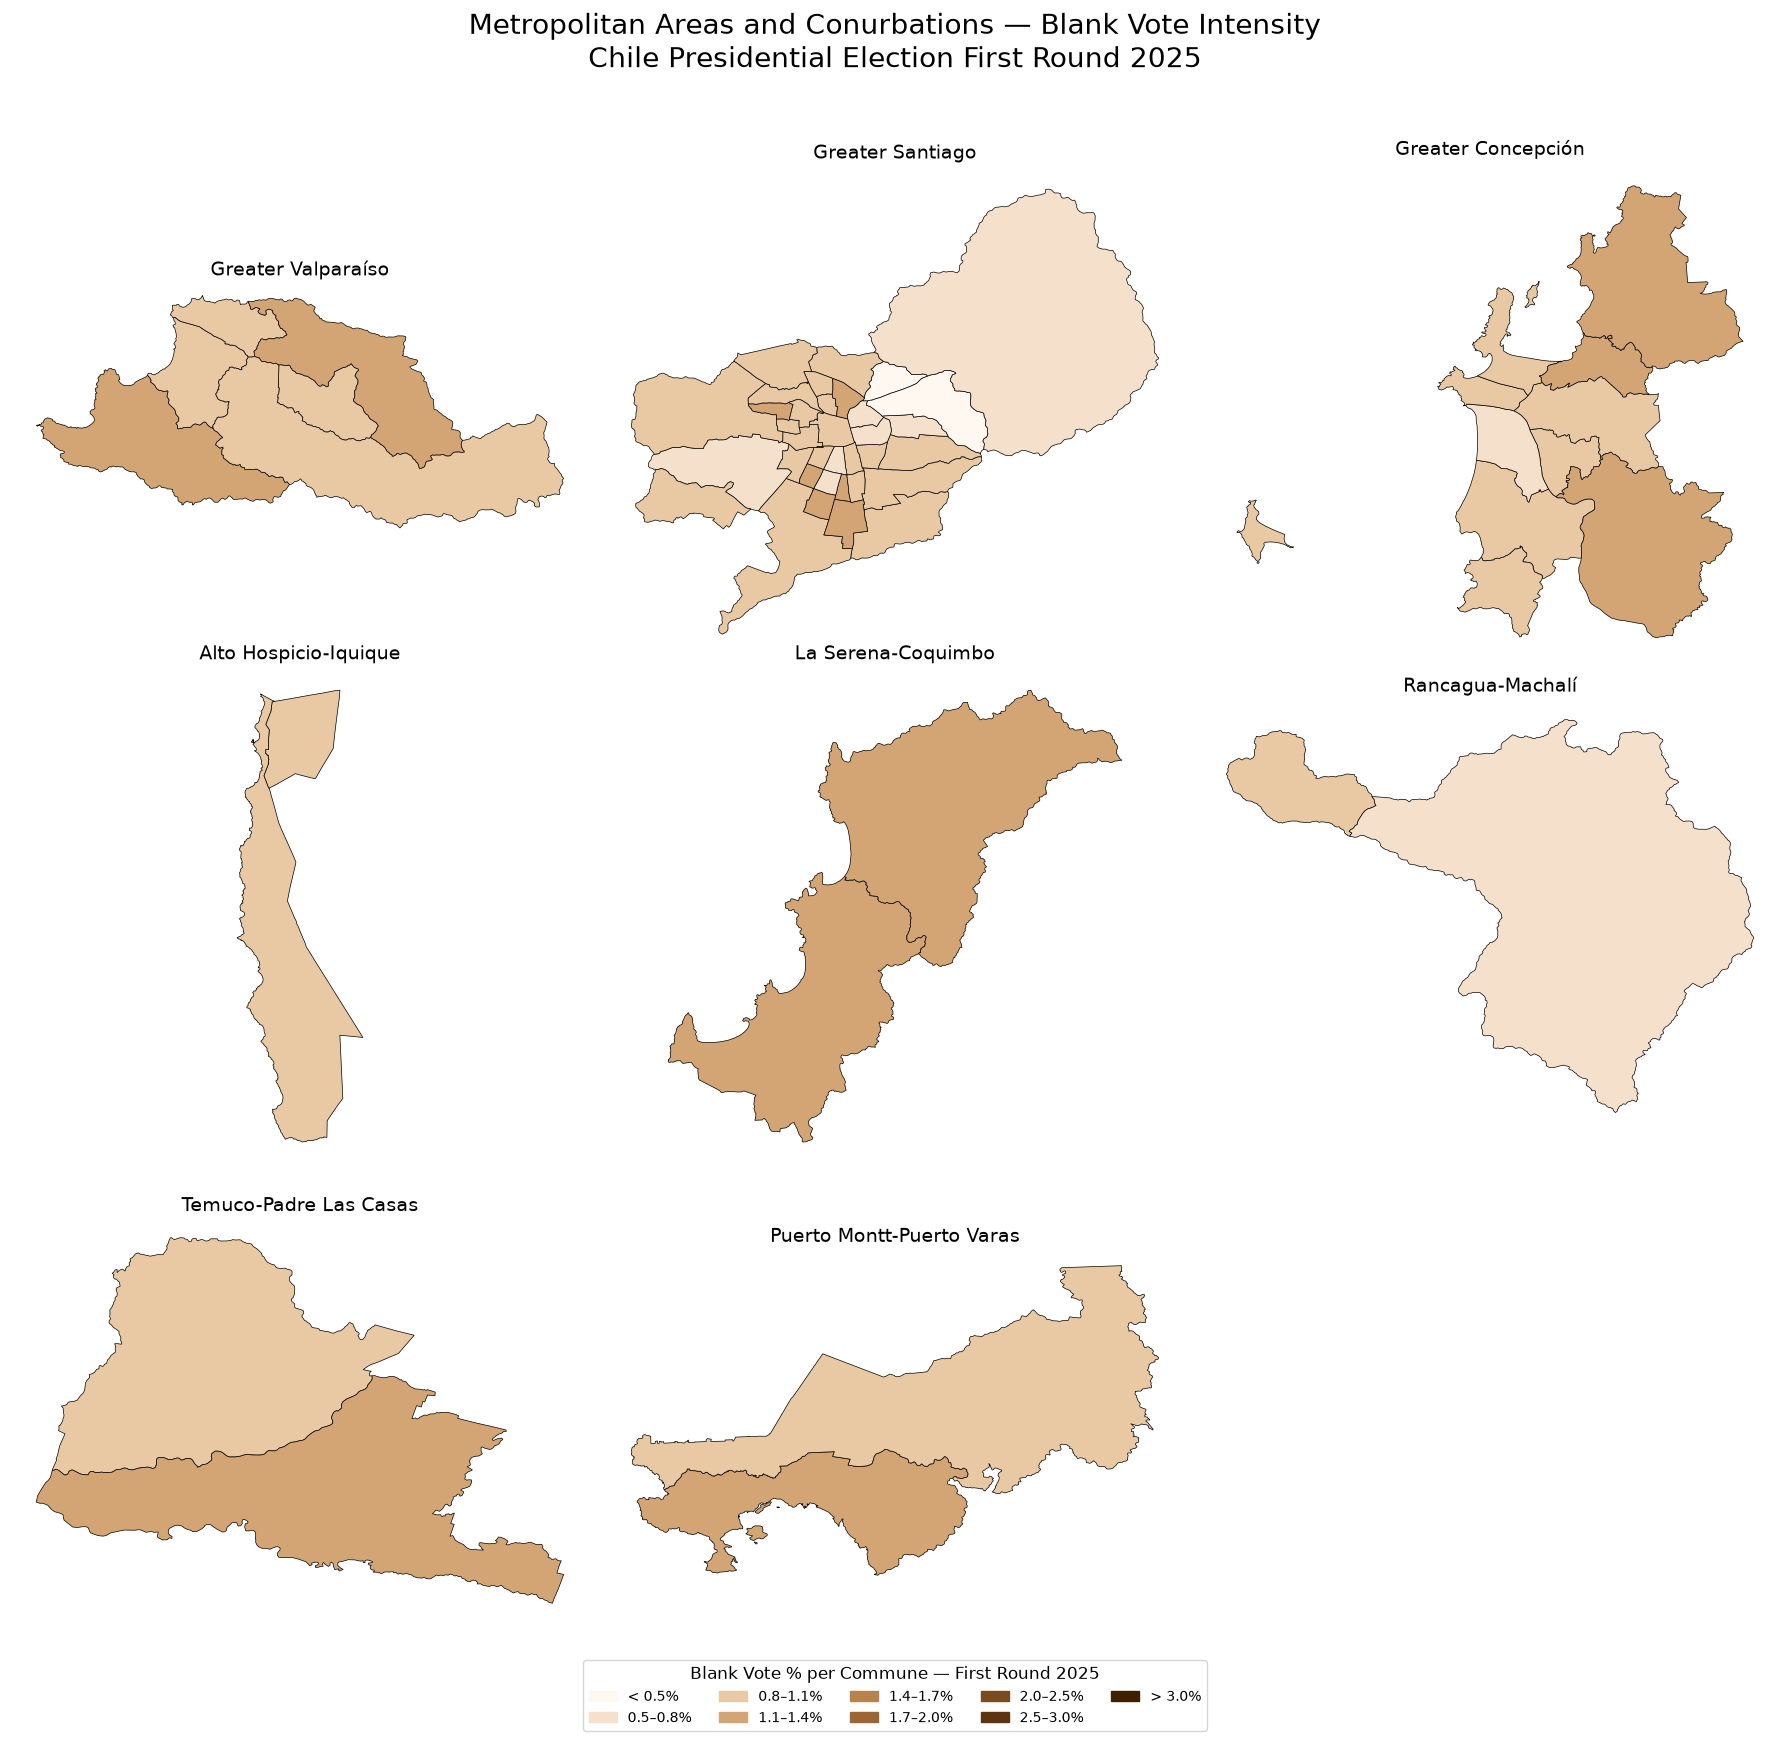

In [98]:
# ============================================================================
# METROPOLITAN AREAS AND CONURBATIONS — BLANK VOTE INTENSITY
# ============================================================================
# Defines urban agglomerations and renders a 3×3 facet grid of blank vote
# percentages for Chile's major metropolitan areas.
# ============================================================================

# ---------------------------------------------------------------------------
# 1. URBAN AGGLOMERATION DEFINITIONS
# ---------------------------------------------------------------------------
# Defines commune lists for each metropolitan area.

GREATER_SANTIAGO = [
    "Cerrillos", "Cerro Navia", "Conchalí", "El Bosque", "Estación Central",
    "Huechuraba", "Independencia", "La Cisterna", "La Florida", "La Granja",
    "Providencia", "Las Condes", "La Reina", "Lo Espejo", "Lo Prado", "Macul",
    "Maipú", "Ñuñoa", "Padre Hurtado", "Pedro Aguirre Cerda", "Peñalolén",
    "Vitacura", "Pudahuel", "Puente Alto", "Quilicura", "Quinta Normal",
    "Recoleta", "Renca", "San Bernardo", "San Joaquín", "San Miguel",
    "San Ramón", "Santiago", "Lo Barnechea", "La Pintana",
]

GREATER_VALPARAISO = [
    "Valparaíso", "Viña del Mar", "Concón", "Quilpué", "Villa Alemana", "Limache",
]

GREATER_CONCEPCION = [
    "Concepción", "Coronel", "Chiguayante", "Hualpén", "Hualqui", "Lota",
    "Penco", "San Pedro de la Paz", "Talcahuano", "Tomé",
]

ALTO_HOSPICIO_IQUIQUE  = ["Alto Hospicio", "Iquique"]
LA_SERENA_COQUIMBO     = ["La Serena", "Coquimbo"]
RANCAGUA_MACHALI       = ["Rancagua", "Machalí"]
TEMUCO_METRO           = ["Temuco", "Padre Las Casas"]
PUERTO_MONTT_VARAS     = ["Puerto Montt", "Puerto Varas"]

# ---------------------------------------------------------------------------
# 2. GRID LAYOUT CONFIGURATION
# ---------------------------------------------------------------------------
# Defines facet grid positions and normalizes commune names for matching.

FACET_CONFIG = [
    ((0, 0), GREATER_VALPARAISO, 'Greater Valparaíso'),
    ((0, 1), GREATER_SANTIAGO,   'Greater Santiago'),
    ((0, 2), GREATER_CONCEPCION, 'Greater Concepción'),
    ((1, 0), ALTO_HOSPICIO_IQUIQUE, 'Alto Hospicio-Iquique'),
    ((1, 1), LA_SERENA_COQUIMBO,    'La Serena-Coquimbo'),
    ((1, 2), RANCAGUA_MACHALI,      'Rancagua-Machalí'),
    ((2, 0), TEMUCO_METRO,      'Temuco-Padre Las Casas'),
    ((2, 1), PUERTO_MONTT_VARAS, 'Puerto Montt-Puerto Varas'),
]

# ---------------------------------------------------------------------------
# 3. BLANK VOTE COLOR SCALE
# ---------------------------------------------------------------------------
# Defines a cream-to-dark-brown gradient for blank vote percentages (max ~3.23%).

def get_blank_color(blank_pct):
    """Return color based on blank vote percentage (cream to dark brown gradient)."""
    if pd.isna(blank_pct):
        return '#D3D3D3'
    if blank_pct < 0.5:
        return '#FFF8F0'
    elif blank_pct < 0.8:
        return '#F5E0CC'
    elif blank_pct < 1.1:
        return '#E8C9A3'
    elif blank_pct < 1.4:
        return '#D4A574'
    elif blank_pct < 1.7:
        return '#B8834A'
    elif blank_pct < 2.0:
        return '#9C6532'
    elif blank_pct < 2.5:
        return '#7A4A20'
    elif blank_pct < 3.0:
        return '#5C3410'
    else:
        return '#3E1F00'

# ---------------------------------------------------------------------------
# 4. BLANK VOTE PERCENTAGE CALCULATION
# ---------------------------------------------------------------------------
# Computes blank vote percentage per commune and merges with map data.

# Prepare base map (GeoDataFrame)
map_data = communes.copy()
map_data['NOM_COM_NORM'] = map_data['NOM_COM'].apply(normalize_commune_name)

# Prepare electoral data with blank percentage
df_votes_map = df_votes.copy()
df_votes_map['blank_pct'] = (df_votes_map['blank_votes'] / df_votes_map['casted_votes'] * 100).round(2)
df_votes_map['commune_norm'] = df_votes_map['commune'].apply(normalize_commune_name)

# Merge blank_pct into map_data (left join preserves geometry)
map_data = map_data.merge(
    df_votes_map[['commune_norm', 'blank_pct']],
    left_on='NOM_COM_NORM',
    right_on='commune_norm',
    how='left'
)

# Drop the redundant right-side key
map_data = map_data.drop(columns=['commune_norm'], errors='ignore')

# Exclude island communes
map_data = map_data[~map_data['NOM_COM'].str.contains('Isla de Pascua|Juan Fernández', case=False, na=False)]

# Verify merge success
if 'blank_pct' not in map_data.columns:
    raise ValueError("Merge failed: 'blank_pct' column not found in map_data")

# ---------------------------------------------------------------------------
# 5. FACET GRID RENDERING
# ---------------------------------------------------------------------------
# Renders a 3×3 grid of choropleth maps for each metropolitan area.

# Build normalized set for each area
area_norm_keys = {
    title: {normalize_commune_name(c) for c in commune_list}
    for _, commune_list, title in FACET_CONFIG
}

fig, axes = plt.subplots(3, 3, figsize=(18, 18))
fig.suptitle(
    'Metropolitan Areas and Conurbations — Blank Vote Intensity\n'
    'Chile Presidential Election First Round 2025',
    fontsize=20, y=0.98,
)

for (row, col), commune_list, title in FACET_CONFIG:
    ax = axes[row, col]
    norm_set = area_norm_keys[title]

    area_data = map_data[map_data['NOM_COM_NORM'].isin(norm_set)].copy()

    if area_data.empty:
        ax.text(0.5, 0.5, f'No data\n{title}',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title, fontsize=14)
        ax.set_axis_off()
        continue

    area_data['color'] = area_data['blank_pct'].apply(get_blank_color)

    area_data.plot(ax=ax, color=area_data['color'], edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontsize=14)
    ax.set_axis_off()
    ax.set_aspect('equal')

# Hide the unused bottom-right cell
axes[2, 2].set_visible(False)

# ---------------------------------------------------------------------------
# 6. SHARED LEGEND
# ---------------------------------------------------------------------------
# Creates a shared legend for the blank vote percentage color scale.

legend_entries = [
    ('< 0.5%',   '#FFF8F0'),
    ('0.5–0.8%', '#F5E0CC'),
    ('0.8–1.1%', '#E8C9A3'),
    ('1.1–1.4%', '#D4A574'),
    ('1.4–1.7%', '#B8834A'),
    ('1.7–2.0%', '#9C6532'),
    ('2.0–2.5%', '#7A4A20'),
    ('2.5–3.0%', '#5C3410'),
    ('> 3.0%',   '#3E1F00'),
]

legend_handles = [mpatches.Patch(color=color, label=label) for label, color in legend_entries]

fig.legend(
    handles=legend_handles, loc='lower center', ncol=5, fontsize=10,
    title='Blank Vote % per Commune — First Round 2025', title_fontsize=12,
    bbox_to_anchor=(0.5, 0.02),
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

### Conclusion to Chapter 5: The Blank Vote


The analysis of the first-round blank vote confirms that passive protest is a territorially differentiated phenomenon that complements —and contrasts with— the null vote. While the null vote is concentrated in the mining North (2.92%) and working-class communes, the blank vote is proportionally more intense in Patagonia (1.49%) and the Sur (1.28%), where a perceived neglect by the state and geographic isolation are more pronounced. This difference suggests that active protest is the predominant form of discontent in the extractive north, while passive protest is more frequent in the far south, where the electorate maintains a less confrontational relationship with the political system.

In absolute volume, the blank vote is concentrated in the large cities of Greater Santiago —Puente Alto (3,292), Maipú (2,811), and Santiago (2,341)— but at an intensity far below that of the null vote (a null-to-blank ratio of ~3.6:1 in Puente Alto), indicating that even in Jara's strongholds passive protest was a minority phenomenon relative to active protest. The political diversity of high-blank-vote communes —which includes strongholds of Kast, Jara, Kaiser, and Parisi— confirms that in the periphery this phenomenon is not ideological but territorial: it reflects discontent with centralism that cuts across party lines.

The distribution by first-round winner reveals that Kaiser is the anomaly (2.5% median, more than double the national average), reflecting that the libertarian electorate in the periphery is particularly prone to passive protest. Matthei, by contrast, shows the lowest median (0.5%), confirming that the traditional right was the most disciplined in November, a behavior consistent with what was observed for the null vote and with her electorate's socioeconomic profile. How both electorates behave —the libertarian one, dispersed and volatile, and the traditional one, disciplined but now without a candidate of its own— heading into the runoff is one of the main unknowns this chapter leaves open, one that the projection analysis in Chapter 12 takes up based on the transfer patterns observed in previous elections.


---

## 6. National Results by Candidate: A Country Without Majorities

The 2025 presidential first round produced a map of **advanced fragmentation and relatively weak leads**: no candidate reached 27% of the valid vote. This result is not merely a consequence of the proliferation of candidacies, but of the deep realignment the Chilean electorate has undergone since 2019. The election revealed that no political bloc currently holds a consolidated majority capable of winning outright in the first round, and that the political center —historically the space where consensus was built— has lost structural pull.

*Methodological note: the national figures presented in this chapter, and throughout this report, are calculated by aggregating the results of the 346 communes of continental and insular Chile, consistent with the territorial methodology used elsewhere in this analysis. Votes cast by Chileans residing abroad cannot be assigned to any specific commune and were therefore not incorporated into this calculation. As a result, the percentages reported here may differ slightly, by tenths of a point, from the final official result proclaimed by Servel once the overseas vote is tallied, without this affecting the ranking of candidates or the analysis's conclusions.*

This section analyzes the results by candidate, organizes them by competitiveness group, and offers a strategic assessment by ideological bloc, identifying the vote-transfer dynamics that will shape the road to the runoff.


In [99]:
# ============================================================================
# NATIONAL CANDIDATE AGGREGATION — FIRST ROUND 2025
# ============================================================================
# Aggregates votes at national level by candidate, calculates vote percentage
# over valid votes, and determines runoff eligibility based on absolute
# majority requirement (Article 26).
# ============================================================================

# ---------------------------------------------------------------------------
# 0. DATA PREPARATION
# ---------------------------------------------------------------------------
# Defines a helper function that computes national vote totals and
# competitiveness context for each candidate.

def compute_national_candidate_stats(df: pd.DataFrame) -> pd.DataFrame:
    """
    Computes national‑level vote totals, percentages, runoff eligibility and
    competitiveness context per candidate.

    Parameters
    ----------
    df : pd.DataFrame
        Electoral data with candidate vote columns, casted_votes, null_votes
        and blank_votes.

    Returns
    -------
    pd.DataFrame
        Columns: candidate, party, votes, vote_percentage,
        goes_to_runoff, competitiveness_context.
    """
    total_valid = (
        df['casted_votes'].sum()
        - df['null_votes'].sum()
        - df['blank_votes'].sum()
    )

    rows = []
    for name, meta in CANDIDATES_META.items():
        votes = df[meta['col']].sum()
        rows.append({
            'candidate':       name,
            'party':           meta['party'],
            'votes':           votes,
            'vote_percentage': round((votes / total_valid) * 100, 2),
        })

    result = (
        pd.DataFrame(rows)
        .sort_values('vote_percentage', ascending=False)
        .reset_index(drop=True)
    )

    # Classifies competitiveness by percentage threshold
    def _context(pct: float) -> str:
        if pct > 20:  return 'High support'
        if pct >= 10: return 'Competitive threshold'
        return 'Minimum threshold'

    result['competitiveness_context'] = result['vote_percentage'].apply(_context)

    # Runoff applies when no candidate exceeds 50% of valid votes
    first_pct = result.loc[0, 'vote_percentage']
    result['goes_to_runoff'] = False if first_pct > 50 else result.index < 2

    return result[['candidate', 'party', 'votes', 'vote_percentage',
                   'goes_to_runoff', 'competitiveness_context']]

# ---------------------------------------------------------------------------
# 1. METRIC CALCULATION
# ---------------------------------------------------------------------------
# Applies the national aggregation function to the first‑round dataset.

national_candidate_metrics = compute_national_candidate_stats(df_votes)

# ---------------------------------------------------------------------------
# 2. TABLE OUTPUT
# ---------------------------------------------------------------------------
# Displays national results by candidate with competitiveness context.

print("\n" + "=" * 80)
print("NATIONAL RESULTS BY CANDIDATE")
print("=" * 80)
national_candidate_metrics


NATIONAL RESULTS BY CANDIDATE


,candidate,party,votes,vote_percentage,goes_to_runoff,competitiveness_context
0,Jeannette Jara,Left-wing officialist (Boric - Unidad por Chile),3446854,26.75,True,High support
1,José Antonio Kast,Conservative right (Partido Republicano),3086963,23.96,True,High support
2,Franco Parisi,Third way (Partido de la Gente),2550770,19.80,False,Competitive threshold
3,Johannes Kaiser,Libertarian right (Partido Nacional Libertario),1796034,13.94,False,Competitive threshold
4,Evelyn Matthei,Historical right - Piñerismo (Chile Vamos),1603104,12.44,False,Competitive threshold
5,Harold Mayne-Nicholls,Independent,162366,1.26,False,Minimum threshold
6,Marco Enriquez-Ominami,Independent left,154321,1.20,False,Minimum threshold
7,Eduardo Artes,Far left,85516,0.66,False,Minimum threshold


### Analysis by Competitiveness Group

**Group 1: Competitive Leadership (Top Tier)**

- **Jeannette Jara (26.75%)** — Won the first round with the narrowest base the left has had in decades. Her 3.45 million votes represent the near-total unification of the progressive, governing-coalition space, yet that fully tapped total is barely enough to lead the first round. Her result reflects the real ceiling of support for Gabriel Boric's government: solid in terms of internal cohesion, but insufficient to build a majority of its own. Jara's strategic challenge is that she enters the runoff without any meaningful reserves of her own: her space is already essentially unified, and her room to grow in the runoff depends almost entirely on winning over votes from other candidates.

- **José Antonio Kast (23.96%)** — Trailing Jara by 2.79 percentage points (roughly 360,000 votes), Kast consolidated the conservative electorate and posted the hard right's best first-round result of the democratic era, even surpassing his own 2021 result in absolute votes (+58%). He demonstrated a broad, loyal territorial base —169 communes won— but his first-round margin understates his real position heading into the runoff, since the bloc aligned with him —including Kaiser (13.94%) and part of Matthei's electorate (12.44%)— comfortably exceeds 50% in terms of potential votes. The 2.79-point Jara-Kast gap is statistically small for a frontrunner: in Latin American presidential elections, first-round margins under 5 points tend to narrow or even reverse in the runoff, especially when the runner-up has greater transfer potential.

**Group 2: Relevant Competitors — The Decisive Third**

- **Franco Parisi (19.71%)** — The election's most disruptive phenomenon. With 2.55 million votes and 184% growth in absolute terms over 2021, the Partido de la Gente consolidated anti-establishment politics as a permanent third force nationally. His electorate concentrates cross-cutting discontent: economic, security-related, migration-related, and a rejection of the traditional poles. Parisi will be the runoff's chief arbiter, not so much because of his ideology —deliberately kept ambiguous— but because of the territorial intensity of his support and the uncertainty surrounding where it goes. The fact that much of this electorate defines itself, above all, by rejection of the political system as a whole rather than by a clear ideological identification —as confirmed by the null- and blank-vote patterns analyzed in Chapters 4 and 5— makes this electorate the runoff's most unpredictable factor.

- **Johannes Kaiser (13.94%)** — A significant breakthrough for the libertarian right, which opened up a niche in Chile that until then had lacked any electoral expression of its own. He captured an ideological vote —young, urban, and highly educated in certain segments— that combines rejection of the state with hardline positions on migration and a defense of individual liberties. His high ideological compatibility with Kast makes him an almost natural source of transferred votes, though the intensity of his positions generates resistance even within the moderate right. The fact that Kaiser won 13.94% in his first national election is significant: no candidate from a new party had reached that level since the transition to democracy.

- **Evelyn Matthei (12.44%)** — Chile Vamos's lowest result in a competitive presidential first round. Caught between Kast's advance (which captured the mobilized conservative vote) and the accumulated rejection of *piñerismo* —tied to the government's handling of the 2019 social uprising— Matthei was reduced to high-income enclaves of the Metropolitan Region. Her low percentage does not mean her voters disappeared; rather, they had already redistributed toward Kast in previous electoral cycles, and her moderate profile failed to mobilize the most radicalized electorate. The challenge for the traditional right is that its territorial footprint has shrunk to a bare minimum: 4 communes won, all on Santiago's east side.

**Sum of the middle third (Parisi + Kaiser + Matthei): 46.18%** — roughly 5.95 million votes, a bloc numerically larger than either finalist alone, and whose distribution will determine the runoff's outcome.

**Group 3: Residual Candidates - The Collapse of the Center and the Independent Candidates**

- Harold Mayne-Nicholls (1.26%), Marco Enríquez-Ominami (1.20%), and Eduardo Artés (0.66%) together add up to just 3.12% of the valid vote.
- MEO's collapse —he won 10.99% in 2013— is especially significant: it reflects the exhaustion of independent left-wing candidacies and the effect of strategic voting toward Jara within the progressive bloc. The fragmentation of the political center, which in previous cycles had been the space where consensus was built, confirms that the structuring axis of Chilean politics has shifted toward left-right-anti-establishment polarization.

#### Strategic Analysis by Ideological Bloc

| Bloc                       | Candidates               | % Total    | Approx. votes | Main characteristic                    |
| --------------------------- | ------------------------ | ---------- | -------------- | --------------------------------------- |
| Left                        | Jara + MEO + Artés       | **28.61%** | 3,686,691       | Clear leadership, narrow base           |
| Right                       | Kast + Kaiser + Matthei  | **50.34%** | 6,486,101       | Theoretical majority, high fragmentation |
| Third Way / Anti-establishment | Parisi + Mayne-Nicholls | **21.06%** | 2,713,136       | Decisive swing factor in the runoff     |

**Key takeaways:**
- **The combined right exceeded 50% for the first time in the voluntary-voting era.** This threshold, already nearly reached in 2021 (Kast + Sichel ≈ 40.8%), was consolidated in 2025, signaling a structural shift in the electorate driven mainly by the wear on the Boric government in the areas of security, migration, and economic growth. Yet the right's fragmentation —three candidacies in double digits— prevented a first-round win, and the fragmentation is more apparent than real: Kaiser and Matthei functioned as communicating vessels within the same electoral bloc rather than as irreversible fractures.

- **The Parisi vote is not a "right-wing vote" in the strict sense.** It is a vote of **structural discontent**: economic, territorial, and anti-establishment. In regions such as Tarapacá or Antofagasta, it partly comes from voters who backed Boric or Provoste in 2021. In the Centro Sur, it eroded Kast's support. Its cross-cutting nature makes it the runoff's unpredictable factor, and nothing in the first-round data allows one to assume its transfer will flow automatically toward either side.

- **No candidate exceeded 27%.** By comparative standards, this is one of the most fragmented first rounds on the continent. This low concentration of the vote in first place signals that whoever wins the runoff will do so without a broad majority mandate, posing governability challenges from day one.


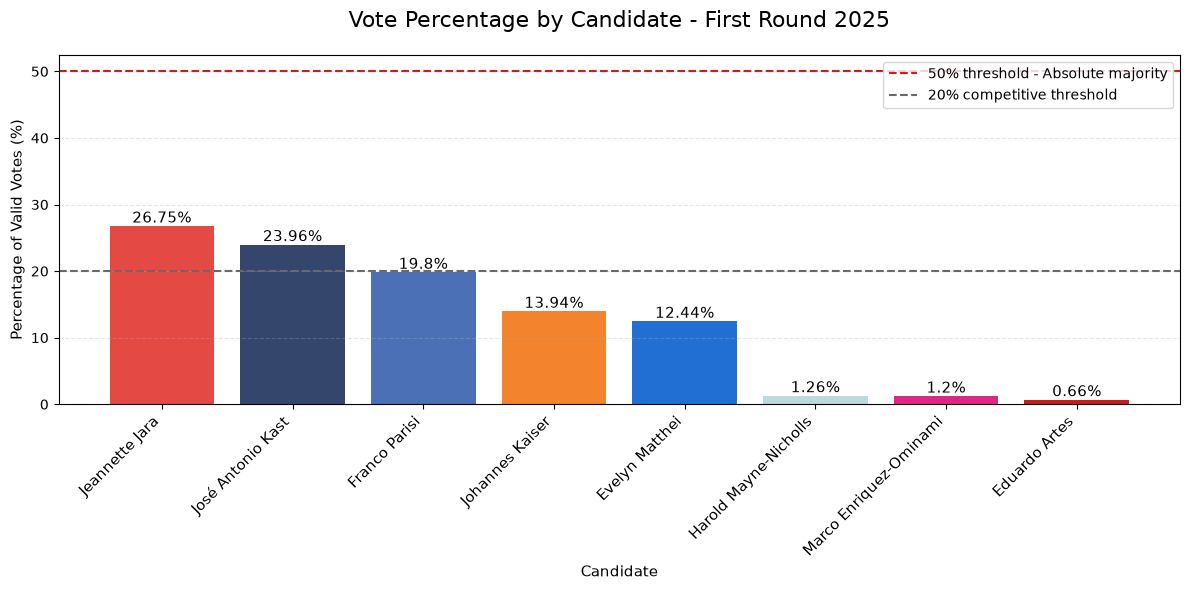

In [100]:
# ============================================================================
# CANDIDATE VOTE PERCENTAGE BAR CHART — FIRST ROUND 2025
# ============================================================================
# Generates a bar chart displaying vote percentages per candidate with
# electoral reference lines (50% absolute majority, 20% competitive threshold).
# ============================================================================

# ---------------------------------------------------------------------------
# 0. DATA PREPARATION
# ---------------------------------------------------------------------------
# Extract ordered lists from the pre-computed candidate results DataFrame.

candidates_ordered  = national_candidate_metrics['candidate'].tolist()
percentages_ordered = national_candidate_metrics['vote_percentage'].tolist()
bar_colors          = [CANDIDATE_COLORS[c] for c in candidates_ordered]

# ---------------------------------------------------------------------------
# 1. VISUALIZATION — BAR CHART
# ---------------------------------------------------------------------------
# Configure and render the bar chart with percentage labels and reference lines.

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(candidates_ordered, percentages_ordered,
              color=bar_colors, linewidth=1)

# Percentage label above each bar
for bar, pct in zip(bars, percentages_ordered):
    ax.text(
        bar.get_x() + bar.get_width() / 2.,
        bar.get_height(),
        f'{pct}%',
        ha='center', va='bottom', fontsize=11,
    )

# Electoral reference lines
ax.axhline(y=50, color='#DA171D', linestyle='--', linewidth=1.5,
           label='50% threshold - Absolute majority')
ax.axhline(y=20, color='#696969', linestyle='--', linewidth=1.5,
           label='20% competitive threshold')

ax.set_title('Vote Percentage by Candidate - First Round 2025', fontsize=16, pad=20)
ax.set_ylabel('Percentage of Valid Votes (%)', fontsize=11)
ax.set_xlabel('Candidate', fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.xticks(rotation=45, ha='right', fontsize=11)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

### Conclusion to Chapter 6: National Results

The 2025 presidential first round left a landscape in which **fragmentation is not a passing circumstance but the expression of a deep political realignment**: the center's loss of pull, the strengthening of the poles, and the emergence of anti-establishment politics as a permanent space. Jeannette Jara led thanks to the cohesion of the progressive bloc and the demographic weight of urban Chile; José Antonio Kast came in second with a broader territorial base and far greater transfer potential; and Franco Parisi became the election's great arbiter, not so much because of his ideology as because of the territorial intensity of his support and the uncertainty surrounding where it will go.


---

## 7. Electoral Strongholds: Top 15 Communes by Candidate

Beyond the national percentages, territorial analysis reveals clear patterns of support for each candidate that help us understand the sociological base of each political project. This section examines the **10 best-performing communes for each candidate**, identifying the geographic, demographic, and socioeconomic profiles that define their strongest strongholds.

The exercise is revealing because, in proportional, two-round electoral systems, strongholds define each candidate's floor —the guaranteed minimum base— and allow us to estimate how efficiently that hard core can be capitalized on in the runoff. They also expose structural limitations: a candidate whose stronghold is sociodemographically homogeneous faces greater difficulty expanding their coalition beyond that profile.


In [101]:
# ============================================================================
# CANDIDATE STRONGHOLD ANALYSIS — FIRST ROUND 2025
# ============================================================================
# Identifies communes with the highest vote percentage for each candidate
# and indicates whether the candidate won in each of those communes.
# ============================================================================

# ---------------------------------------------------------------------------
# 0. DATA PREPARATION
# ---------------------------------------------------------------------------
# Defines percentage‑to‑votes column mapping and the list of percentage columns.

PCT_TO_VOTES = {
    'artes_pct':             'artes_votes',
    'enriquez_ominami_pct':  'enriquez_ominami_votes',
    'jara_pct':              'jara_votes',
    'kaiser_pct':            'kaiser_votes',
    'kast_pct':              'kast_votes',
    'matthei_pct':           'matthei_votes',
    'mayne_nicholls_pct':    'mayne_nicholls_votes',
    'parisi_pct':            'parisi_votes',
}

COLS_PCT = [
    'artes_pct', 'enriquez_ominami_pct', 'jara_pct', 'kaiser_pct',
    'kast_pct', 'matthei_pct', 'mayne_nicholls_pct', 'parisi_pct',
]

# ---------------------------------------------------------------------------
# 1. METRIC CALCULATION
# ---------------------------------------------------------------------------
# Builds the stronghold identification function: for a given candidate's
# percentage column, returns the N communes with the highest vote share
# and determines whether the candidate won there.

def candidate_strongholds(df: pd.DataFrame, col_pct: str, n: int = 10) -> pd.DataFrame:
    """
    Identifies the N communes with the highest vote percentage for a candidate
    and indicates whether that candidate won in each of them.

    Parameters
    ----------
    df : pd.DataFrame
        Electoral DataFrame with percentage and vote columns per candidate.
    col_pct : str
        Percentage column name for the target candidate.
    n : int
        Number of communes to return (default 10).

    Returns
    -------
    pd.DataFrame
        Columns: commune, region, votes, percentage, commune_result.
    """
    vote_col = PCT_TO_VOTES[col_pct]

    # Selects required columns, preserving order and avoiding duplicates
    cols_needed = ['commune', 'region', vote_col, col_pct] + COLS_PCT
    cols_needed = list(dict.fromkeys(cols_needed))

    votes_prep = df[cols_needed].copy().reset_index(drop=True)
    votes_prep = votes_prep.rename(columns={vote_col: 'candidate_votes'})

    # Computes maximum percentage among all other candidates (vectorised)
    other_cols = [c for c in COLS_PCT if c != col_pct]
    max_others = votes_prep[other_cols].max(axis=1).values
    target_pct = votes_prep[col_pct].values

    # Flattens if necessary
    if target_pct.ndim > 1:
        target_pct = target_pct.flatten()
    if max_others.ndim > 1:
        max_others = max_others.flatten()

    votes_prep['commune_result'] = np.where(target_pct >= max_others, 'Wins', 'Loses')

    strongholds_top_N = votes_prep.nlargest(n, col_pct)
    strongholds_metrics = strongholds_top_N[['commune', 'region', 'candidate_votes', col_pct, 'commune_result']].copy()
    strongholds_metrics = strongholds_metrics.rename(columns={'candidate_votes': 'votes', col_pct: 'percentage'})
    return strongholds_metrics

### 7.1. Jeannette Jara: The Power of the Big Cities


In [102]:
# ============================================================================
# ELECTORAL STRONGHOLDS — JEANNETTE JARA
# ============================================================================
# Displays top 15 communes with highest Jara vote percentage.
# Computes and displays communes with highest candidate support.
# ============================================================================

jara_strongholds = candidate_strongholds(df_votes, 'jara_pct', n=15)

print("\n" + "=" * 80)
print("ELECTORAL STRONGHOLDS — JEANNETTE JARA")
print("=" * 80)

display(jara_strongholds)


ELECTORAL STRONGHOLDS — JEANNETTE JARA


,commune,region,votes,percentage,commune_result
299,Juan Fernandez,Valparaíso,235,43.44,Wins
252,Pedro Aguirre Cerda,Metropolitana,30357,41.90,Wins
264,San Joaquin,Metropolitana,26233,39.29,Wins
244,Lo Espejo,Metropolitana,25101,37.10,Wins
279,ÑUñoa,Metropolitana,65386,36.55,Wins
247,Maipu,Metropolitana,127656,36.40,Wins
318,Valparaiso,Valparaíso,76553,36.34,Wins
265,San Jose de Maipo,Metropolitana,4914,36.20,Wins
234,Conchali,Metropolitana,32397,36.12,Wins
245,Lo Prado,Metropolitana,24166,35.68,Wins


#### Geographic Patterns

The analysis of Jeannette Jara's first-round strongholds reveals an overwhelming concentration in the Metropolitan Region, where eight of the fifteen communes with the highest vote share for the governing coalition's candidate belong to Greater Santiago. Puente Alto (130,305 votes, 35.57%), Maipú (127,656, 36.40%), and Ñuñoa (65,386, 36.55%) top a ranking dominated by communes in the capital's southern and western districts —Pedro Aguirre Cerda, Lo Espejo, San Joaquín, Conchalí, Lo Prado— all with percentages above 35%. The exception within this urban core is Ñuñoa, an upper-middle-class commune with a strong university presence, suggesting that the Jara vote also captures a progressive ideological electorate beyond the strictly economic axis. Outside the Metropolitan Region, only Valparaíso (76,553 votes, 36.34%) and Juan Fernández (235 votes, 43.44%) appear in the top 15, confirming that the port and peripheral vote forms part of Jara's base, albeit with more limited territorial intensity. The total absence of communes from the Norte Grande, rural areas, and mid-sized southern cities from this ranking exposes her main territorial weakness: her support is concentrated in a handful of urban enclaves, with no capacity to expand into provincial, peripheral Chile.

#### Socioeconomic Profile

The communes where Jara achieved her best results share a common socioeconomic profile that sets them apart from the rest of the country. These are territories with high population density, a strong presence of working-class and lower-middle-class sectors, a high Social Priority Index according to the Ministry of Social Development, heavy reliance on state benefits and public employment, and a long tradition of left-wing voting going back to the Concertación and Nueva Mayoría coalitions. Neighborhood and union organizing has historically been significant in these communes, where public employment and social services are the main economic driver. Puente Alto is emblematic: the country's most populous commune, with over half a million residents, has a high share of social housing and working-class sectors, and there Jara won 130,305 votes (35.57%), the highest absolute figure in the country. Maipú, with 127,656 votes (36.40%), and La Florida, which does not appear in the top 15 but is a notable stronghold, round out her hard core of working-class support. The exception of Ñuñoa —with an upper-middle-class profile and a high concentration of university students— suggests that the Jara vote also includes a progressive ideological component, though this does not change the overall diagnosis: her base is socially homogeneous and territorially concentrated.

#### Synthesis of the Common Pattern

The overall pattern of the first-round Jara vote is that of a candidate who **concentrates her support in urban, working-class, densely populated Chile**, with a strength built on the ability to mobilize large vote volumes in highly populated communes of the Metropolitan Region and Valparaíso, but with a structural weakness in her lack of territorial breadth. Her base combines urban working-class sectors with a strong tradition of social and political organizing, along with a progressive ideological electorate in communes such as Ñuñoa, but she has no presence in rural, provincial, peripheral Chile, which makes up most of the national territory. This pattern —many votes concentrated in a few large communes— is a strength in terms of absolute volume but a liability in terms of territorial coverage, foreshadowing the challenges Jara will face in expanding her base beyond her traditional strongholds, especially against a José Antonio Kast who has consolidated broad territorial dominance in the North and the rural South.


### 7.2. José Antonio Kast: The Empire of Rural Chile


In [103]:
# ============================================================================
# ELECTORAL STRONGHOLDS — JOSÉ ANTONIO KAST
# ============================================================================
# Displays top 15 communes with highest Kast vote percentage.
# Computes and displays communes with highest candidate support.
# ============================================================================

kast_strongholds = candidate_strongholds(df_votes, 'kast_pct', n=15)

print("\n" + "=" * 80)
print("ELECTORAL STRONGHOLDS — JOSÉ ANTONIO KAST")
print("=" * 80)

display(kast_strongholds)


ELECTORAL STRONGHOLDS — JOSÉ ANTONIO KAST


,commune,region,votes,percentage,commune_result
199,Chanco,Maule,3717,46.61,Wins
94,Lumaco,La Araucanía,3356,46.19,Wins
111,los Sauces,La Araucanía,2818,46.16,Wins
187,Antartica,Magallanes,35,45.45,Wins
204,Empedrado,Maule,1689,44.39,Wins
39,Contulmo,Biobío,2110,42.57,Wins
101,Puren,La Araucanía,4040,41.30,Wins
243,Lo Barnechea,Metropolitana,31581,41.03,Wins
59,Tirua,Biobío,3125,40.82,Wins
196,Timaukel,Magallanes,93,40.09,Wins


#### Territorial Characteristics

The analysis of José Antonio Kast's first-round strongholds reveals a territorially expansive but demographically dispersed pattern of support, with a clear dominance of rural, peripheral Chile. Eight of the fifteen communes with the highest vote share for the Republican candidate are low-density localities in the regions of La Araucanía (Lumaco, Los Sauces, Purén, Victoria, Collipulli), Biobío (Contulmo, Tirúa), and Maule (Chanco, Empedrado, Pencahue, Pelluhue), all with percentages above 38%, where Kast's rhetoric on security, order, and rejection of recognizing a "state within the state" resonated with particular intensity in communes directly affected by the Mapuche territorial conflict. The presence of communes such as Antarctica (45.45%) and Timaukel (40.09%) in Magallanes confirms that his base also extends to the far south, while Lo Barnechea (41.03%) emerges as the sole urban, high-income exception in the top 10, reflecting a symbolic shift of a share of the electorate on Santiago's east side migrating from the traditional right of Chile Vamos toward the Partido Republicano as its new conservative reference point. Lumaco is particularly telling: the commune, with a high share of rural population and a long history of Mapuche conflict, was where Kast achieved his best result in the region, surpassing 46% of the vote.

#### Socioeconomic Profile

The communes where Kast achieved his best results share a common profile that sets them clearly apart from Jeannette Jara's urban strongholds: these are territories with low population density, agricultural, forestry, or subsistence economies, heavy reliance on primary activities, and a marked perceived neglect by the state. Poor connectivity, a limited state presence, and high youth emigration rates feed a sense of being left behind relative to Santiago-centered centralism, which translates electorally into a punishment vote against the governing coalition and support for candidacies promising radical change on order and security. The Araucanía factor is particularly relevant: several of Kast's strongest communes are located in rural areas affected by the territorial conflict, where his message of a "firm hand" and defense of farmers against rural violence resonated with particular force among an electorate that perceives Gabriel Boric's government as having failed to guarantee security in the region. Chanco (46.61%) and Empedrado (44.39%) in the Maule, with economies based on agriculture and artisanal fishing, confirm that a sense of state neglect is a cross-cutting factor across Kast's rural strongholds.

#### Synthesis of the Common Pattern

The overall pattern of the first-round Kast vote is that of a candidacy that **dominates rural, provincial, peripheral Chile**, with a broad but demographically dispersed territorial base —169 communes won— built on concrete demands for security, order, and anti-centralism rather than on strictly defined ideological adherence. His base combines the traditional conservative vote of the rural south —where the Mapuche conflict and a perceived neglect by the state are decisive factors— with the anti-establishment vote of the mining north that backed Franco Parisi in the first round, plus an emerging vote among Santiago's elite that has migrated from the traditional right toward the Partido Republicano. This pattern —many communes with low vote volumes— is a strength in terms of territorial coverage but a liability in terms of absolute volume, foreshadowing that Kast's challenge will be to consolidate his rural base without losing the urban vote he needs to compete with Jara's demographic concentration in Greater Santiago.


### 7.3. Franco Parisi: The Owner of the North


In [104]:
# ============================================================================
# ELECTORAL STRONGHOLDS — FRANCO PARISI
# ============================================================================
# Displays top 15 communes with highest Parisi vote percentage.
# Computes and displays communes with highest candidate support.
# ============================================================================

parisi_strongholds = candidate_strongholds(df_votes, 'parisi_pct', n=15)

print("\n" + "=" * 80)
print("ELECTORAL STRONGHOLDS — FRANCO PARISI")
print("=" * 80)

display(parisi_strongholds)


ELECTORAL STRONGHOLDS — FRANCO PARISI


,commune,region,votes,percentage,commune_result
4,Ollague,Antofagasta,427,58.17,Wins
282,Colchane,Tarapacá,695,57.30,Wins
11,General Lagos,Arica y Parinacota,302,48.95,Wins
2,Maria Elena,Antofagasta,1429,45.86,Wins
13,Alto del Carmen,Atacama,1565,43.16,Wins
281,Camiña,Tarapacá,729,43.09,Wins
280,Alto Hospicio,Tarapacá,25061,42.94,Wins
20,Tierra Amarilla,Atacama,4365,42.59,Wins
6,Sierra Gorda,Antofagasta,442,41.90,Wins
286,Pozo Almonte,Tarapacá,4037,41.39,Wins


#### Territorial Characteristics

The analysis of Franco Parisi's first-round strongholds reveals a territorially concentrated but intense pattern of support, with near-absolute dominance of Chile's Norte Grande. Nine of the fifteen communes with the highest vote share for the Partido de la Gente's candidate are located in the regions of Arica y Parinacota, Tarapacá, and Antofagasta, led by Ollagüe (58.17%), Colchane (57.30%), and General Lagos (48.95%), all with percentages above 48%, where Parisi's anti-establishment rhetoric resonated with particular force in border territories affected by the migration crisis and a perceived neglect by the state. The presence of communes such as Alto Hospicio (42.94%) and Pozo Almonte (41.39%) in Tarapacá confirms that his base also extends to mid-sized urban centers in the north, while the appearance of Alto Biobío (40.31%) in the Biobío region —a rural commune with a large Mapuche population— suggests that Parisi's anti-establishment vote also found an echo in southern territories where the territorial conflict and a perceived neglect by the state are decisive factors.

#### Socioeconomic Profile

The communes where Parisi achieved his best results share a common profile that sets them apart from both Jara's urban strongholds and Kast's rural ones: these are territories with extractive economies —copper, saltpeter, and lithium mining— or border economies, with heavy reliance on primary activities, a marked perceived neglect by the state, and a historical sentiment that "the North produces the country's wealth, but centralism gives nothing back." The migration crisis has been a particularly relevant factor in communes such as Colchane, Ollagüe, and General Lagos —epicenters of the mass entry of irregular migrants since 2021— where saturated local services, coexistence conflicts, and the perception that Gabriel Boric's government has failed to control the border turned these communes into fertile ground for a discourse of order and border sovereignty. The rise of organized crime and transnational criminal activity in Alto Hospicio, Iquique, and other Norte Grande communes since 2022 generated an urgent demand for public order that Parisi capitalized on effectively, combining anti-establishment rhetoric with proposals for decentralization and redistributive royalties for mining regions.

#### Synthesis of the Common Pattern

The overall pattern of the first-round Parisi vote is that of a candidacy that **capitalizes on a protest vote deeply rooted in territorial grievance across the Norte Grande**, with an intense electoral base —64 communes won— but geographically confined, built on concrete, urgent demands —migration, crime, state neglect, the security crisis— that the northern electorate perceived as ignored by the traditional duopoly. His base combines the anti-establishment vote of border and mining communes —where the migration crisis and extractive centralism are decisive factors— with an emerging vote in the rural south (Alto Biobío), where the territorial conflict and a perceived neglect by the state also play a relevant role. This pattern —high intensity in a small number of northern communes— is a strength in terms of territorial cohesion but a liability in terms of geographic expansion, foreshadowing that Parisi's challenge will be to hold his northern base together heading into a runoff in which he does not directly participate, and in which the direction this electorate ultimately takes —toward one of the two finalists, toward active rejection, or toward abstention— stands as one of the election's principal unknowns.


### 7.4. Johannes Kaiser: A Niche With a Future


In [105]:
# ============================================================================
# ELECTORAL STRONGHOLDS — JOHANNES KAISER
# ============================================================================
# Displays top 15 communes with highest Kaiser vote percentage.
# Computes and displays communes with highest candidate support.
# ============================================================================

kaiser_strongholds = candidate_strongholds(df_votes, 'kaiser_pct', n=15)

print("\n" + "=" * 80)
print("ELECTORAL STRONGHOLDS — JOHANNES KAISER")
print("=" * 80)

display(kaiser_strongholds)


ELECTORAL STRONGHOLDS — JOHANNES KAISER


,commune,region,votes,percentage,commune_result
155,Futaleufu,Los Lagos,671,31.11,Wins
160,Palena,Los Lagos,380,27.03,Wins
195,San Gregorio,Magallanes,98,26.13,Wins
187,Antartica,Magallanes,20,25.97,Loses
24,Cisnes,Aysén,916,25.86,Wins
148,Chaiten,Los Lagos,811,25.24,Loses
194,Rio Verde,Magallanes,105,24.08,Loses
28,Lago Verde,Aysén,173,23.90,Loses
174,los Muermos,Los Lagos,3407,23.60,Loses
29,O'higgins,Aysén,104,23.58,Loses


#### Territorial Characteristics

The analysis of Johannes Kaiser's first-round strongholds reveals a pattern of support territorially concentrated in the country's far south, with a dominant presence in the regions of Los Lagos, Aysén, and Magallanes. The communes where Kaiser achieved his best results —Futaleufú (31.11%), Palena (27.03%), San Gregorio (26.13%), and Cisnes (25.86%)— are rural, isolated, low-density territories, with economies based on ranching, artisanal fishing, tourism, and subsistence agriculture, where a perceived neglect by the state and disconnection from the political center are particularly pronounced. Unlike the other main candidates, however, Kaiser won only **4 communes nationwide**, a figure that reveals the tension between his concentrated percentage support in very small communes and his limited aggregate traction in terms of vote volume. Kaiser's performance in the top 10 by percentage is inflated by the small denominator of these rural localities —many with fewer than 1,000 voters— suggesting that his territorial base is more a symbolic niche than a solid electoral platform.

#### Socioeconomic Profile

The communes where Kaiser achieved his best results share a common profile that sets them apart from the other candidates' strongholds: these are territories with primary economies, poor connectivity, and a marked perceived neglect by the state, where libertarian rhetoric rejecting the state and defending individual liberties resonated with particular force among an electorate that perceives Santiago-centered centralism as unresponsive to its specific demands. Kaiser combines two distinct voter subgroups: a **rural-southern component** more tied to public order, rejection of traditional institutions, and the defense of farmers and ranchers against what they perceive as state encroachment on their way of life; and an **urban-young component** with high education levels and libertarian identification that votes in mid-sized cities and regional capitals, where the discourse of a minimal state and individual liberties finds an echo among professional and university sectors. This duality makes it difficult to build a coherent territorial base and explains why Kaiser, despite winning 13.94% of the national vote, prevailed in only four communes.

#### Synthesis of the Common Pattern

The overall pattern of the first-round Kaiser vote is that of a candidacy that **represents an ideological niche with potential for future consolidation, but which in 2025 lacked the territorial coverage needed to become an autonomous actor**. His base combines the rural libertarian vote in Patagonia and Aysén —where anti-state rhetoric and the defense of individual liberties resonated in isolated territories with a strong sense of neglect— with an incipient young, urban vote in mid-sized cities of the south, though his limited territorial coverage —just 4 communes won— shows that his relevance in this election was more structural —demonstrating that a space exists for the libertarian right in Chile— than immediate. The fact that Kaiser's geographic profile overlaps significantly with Kast's —both competed for the same space in the south— suggests that his role within the emerging party system is that of an actor who expands the boundaries of the political field toward libertarianism, forcing Kast to position himself relative to those views, though in the short term his impact on the electoral outcome depends on how his electorate's votes are transferred to one of the finalists.


### 7.5. Evelyn Matthei: The Retreat of the Traditional Right


In [106]:
# ============================================================================
# ELECTORAL STRONGHOLDS — EVELYN MATTHEI
# ============================================================================
# Displays top 15 communes with highest Matthei vote percentage.
# Computes and displays communes with highest candidate support.
# ============================================================================

matthei_strongholds = candidate_strongholds(df_votes, 'matthei_pct', n=15)

print("\n" + "=" * 80)
print("ELECTORAL STRONGHOLDS — EVELYN MATTHEI")
print("=" * 80)

display(matthei_strongholds)


ELECTORAL STRONGHOLDS — EVELYN MATTHEI


,commune,region,votes,percentage,commune_result
272,Vitacura,Metropolitana,29467,42.45,Wins
278,las Condes,Metropolitana,79998,36.54,Wins
256,Providencia,Metropolitana,43965,36.30,Wins
243,Lo Barnechea,Metropolitana,23778,30.89,Loses
277,la Reina,Metropolitana,21697,29.38,Wins
279,ÑUñoa,Metropolitana,48927,27.35,Loses
321,Zapallar,Valparaíso,2168,23.59,Loses
269,Santiago,Metropolitana,56605,23.11,Loses
266,San Miguel,Metropolitana,20141,22.11,Loses
240,Independencia,Metropolitana,13080,20.03,Loses


#### Territorial Characteristics

The analysis of Evelyn Matthei's first-round strongholds reveals a pattern of support extremely concentrated in the eastern district of the Metropolitan Region, where the country's highest per-capita-income communes —Vitacura (42.45%), Las Condes (36.54%), Providencia (36.30%), and La Reina (29.38%)— stand as the only territories where the Chile Vamos candidate prevailed. This electoral geography is not new for the traditional right, but it had never been this exclusive: for the first time in decades, the Chile Vamos candidate fails to compete credibly in any other region of the country, and her presence outside eastern Santiago is reduced to symbolic enclaves such as Zapallar (23.59%) and Santo Domingo (17.95%) in the Valparaíso Region, and Con Con (19.51%) —the only commune in the coastal conurbation where the right prevailed— while in the rest of the country her vote share does not exceed 20%, and in most communes it does not even reach 15%. Lo Barnechea (30.89%) is particularly telling: the commune, which Matthei lost to Kast, shows that even at the heart of the traditional right's territory, the Partido Republicano managed to break through and capture a significant share of the conservative electorate.

#### Socioeconomic Profile

The communes where Matthei achieved her best results share a common profile that sets them clearly apart both from Jara's working-class strongholds and from Kast's rural ones: these are territories with the country's highest per-capita income, a high concentration of professionals and business owners, and a historically institutional relationship with the political system, where the Chile Vamos vote has been the predominant choice since the return to democracy. Yet Matthei's result —12.44% nationally— reflects the electoral collapse of the moderate right, pushed into an increasingly narrow socioeconomic niche, caught between Kast's advance (which captured the mobilized conservative vote) and the accumulated rejection of *piñerismo* tied to the government's handling of the 2019 social uprising. Matthei's electorate is the residue that did not complete the transition toward the Partido Republicano, concentrated in eastern Santiago, where the class divide with the rural, Kast-voting world is most pronounced. The presence of communes such as Colina (17.56%) —a vulnerable commune in northern Santiago— and Ñuñoa (27.35%) —won by Jara, but where Matthei was competitive— suggests that the traditional right's vote also has an aspirational, middle-class component that failed to consolidate in this electoral cycle.

#### Synthesis of the Common Pattern

The overall pattern of the first-round Matthei vote is that of a candidacy that **represents the electoral collapse of the moderate right**, pushed into an increasingly narrow socioeconomic niche in eastern Santiago, unable to compete in the rest of the country. Her base combines the economic elite's vote —concentrated in Vitacura, Las Condes, and Providencia— with an incipient vote among upper-middle-class, aspirational sectors in communes such as Ñuñoa and Colina, though her limited territorial coverage —just 4 communes won— shows that her result does not reflect the disappearance of that political sensibility, but rather its fragmentation and redistribution: part of it migrated to Kast, another part may have expressed itself through genuine abstention or implicit rejection, and a smaller share opted for the blank vote as a form of passive protest. The medium-term political question is whether Chile Vamos can rebuild itself as a competitive force —perhaps by renewing its leadership and policy platform— or whether it will end up absorbed by the Partido Republicano, in a scenario where the moderate right's space has shrunk to its bare territorial and electoral minimum.


### Conclusion to Chapter 7: Electoral Strongholds


The analysis of the leading candidates' first-round strongholds in 2025 reveals that Chile voted across **three territories with their own political, social, and economic logics**, forming a fragmented electoral map that reflects the depth of the ongoing realignment. In **Urban, Working-Class Chile** —represented by Jeannette Jara— the vote is concentrated in the western and southern Metropolitan Region, and in Valparaíso, territories with high population density, a strong presence of working-class and lower-middle-class sectors, and a long tradition of social and union organizing, where the service economy and reliance on state benefits shape a loyal but territorially limited electorate. In **Rural, Peripheral Chile** —represented by José Antonio Kast and Franco Parisi— the vote spreads across the deep south and the mining, border north, respectively, where a perceived neglect by the state, the security crisis, and anti-centralism are cross-cutting factors that both candidates capitalized on with different messages: Kast with a public-order focus in the South, Parisi with an anti-establishment, anti-migration message in the North. In **Elite Chile** —represented by Evelyn Matthei— the vote is confined to eastern Santiago, an increasingly residual enclave as an autonomous electoral actor, where the traditional right lost its base outside the high-income sector and failed to compete in the rest of the country.

The fundamental strategic tension emerging from this analysis is the **contrast between urban density and territorial breadth**: Jara built support that was dense but territorially limited —high performance in a few heavily populated communes— while Kast built support that was broad but demographically dispersed —wide coverage across many small communes— and Parisi capitalized on an intense protest vote that was geographically concentrated in the Norte Grande. This dynamic outlines the main challenges facing each runoff candidacy: Jara will need to expand her base beyond her urban strongholds without losing her hard core, while Kast will need to consolidate his rural dominance without neglecting the urban vote he needs to offset Jara's demographic concentration in Greater Santiago. The collapse of the traditional right —reflected in Matthei's result (12.44%)— and the emergence of Kaiser's libertarian niche (13.94%) round out a picture in which fragmentation is not a passing circumstance but the expression of a deep political realignment: the political center has lost structural pull, the poles have strengthened, and anti-establishment politics has consolidated as a permanent space, redefining the balance of political forces in Chile for the next electoral cycle.


---

## 8. Territorial Mapping and Vote Distribution: Winning Territory, Losing Votes


### Introduction


If the previous chapter showed who each candidacy's electorate is, this chapter asks where they are located and how efficiently that support translates into votes. The answer reveals one of the richest tensions of the 2025 election: the one between controlling territory and controlling votes, two forms of electoral power that do not always coincide and that, in this cycle, diverged in a particularly pronounced way. The analysis of territorial mapping (8.1), the distribution by macrozone (8.2), regional results (8.3), and gaps in regional support (8.4) shows that Chile's electoral map does not respond to a single fault line, but to a fragmented political geography in which each macrozone expresses its own structural demands: mining extraction and the migration crisis in the North, population density and social organization in the Centro, and territorial conflict and rurality in the South.


### 8.1. Territorial Mapping: Communes Won by Candidate


The 2025 presidential first round revealed a **structural paradox** between territorial control and demographic weight, one of the most significant findings of the process: the candidate who won the most communes was not the one who led the national vote, and the one who led the first round did so with a far narrower territorial base. José Antonio Kast won 169 communes (48.8% of the total) but came in second in the popular vote (23.96%). Jeannette Jara, by contrast, led the first round with 26.75% of the vote but prevailed in only 105 communes (30.3%). This gap between "winning territory" and "winning votes" is not trivial: it foreshadows the difficulties each candidate will face in expanding their base, and it reveals what kind of Chile each campaign mobilized. The map of commune-level wins expresses, in essence, radically different electoral strategies —Kast bet on a broad, rural, peripheral Chile; Jara, on the country's demographic center— a strategic difference that looks set to become one of the central axes of the runoff race.


In [107]:
# ============================================================================
# TERRITORIAL WINNER MAPPING — FIRST ROUND 2025
# ============================================================================
# Maps the candidate with the highest vote count per commune and aggregates
# the number of communes won by each candidate with percentage share.
# ============================================================================

# ---------------------------------------------------------------------------
# 0. DATA PREPARATION
# ---------------------------------------------------------------------------
# Defines candidate column mapping for first round vote counts.

COL_TO_CANDIDATE_VOTES = {
    'jara_votes':             'Jeannette Jara',
    'kast_votes':             'José Antonio Kast',
    'parisi_votes':           'Franco Parisi',
    'kaiser_votes':           'Johannes Kaiser',
    'matthei_votes':          'Evelyn Matthei',
    'mayne_nicholls_votes':   'Harold Mayne-Nicholls',
    'enriquez_ominami_votes': 'Marco Enriquez-Ominami',
    'artes_votes':            'Eduardo Artes',
}

candidate_columns_votes = list(COL_TO_CANDIDATE_VOTES.keys())

# Validates required DataFrame and column availability.
try:
    df_votes
except NameError:
    raise NameError("df_votes is not defined. Load the first round data first.")

missing_cols = [col for col in candidate_columns_votes if col not in df_votes.columns]
if missing_cols:
    raise KeyError(f"Missing columns in df_votes: {missing_cols}")

# ---------------------------------------------------------------------------
# 1. WINNER DETERMINATION
# ---------------------------------------------------------------------------
# Identifies the candidate with the maximum vote count per commune.

winner_series = df_votes[candidate_columns_votes].idxmax(axis=1).map(COL_TO_CANDIDATE_VOTES)

# ---------------------------------------------------------------------------
# 2. VICTORY AGGREGATION
# ---------------------------------------------------------------------------
# Aggregates commune victories per candidate and computes percentage share.

victories_metrics = winner_series.value_counts().reset_index()
victories_metrics.columns = ['candidate', 'communes_won']
victories_metrics['communes_percentage'] = round(
    (victories_metrics['communes_won'] / len(df_votes)) * 100, 1
)

# ---------------------------------------------------------------------------
# 3. TABLE OUTPUT
# ---------------------------------------------------------------------------
# Displays territorial victory results sorted by communes won.

print("\n" + "=" * 80)
print("COMMUNES WON BY CANDIDATE — FIRST ROUND 2025")
print("=" * 80)
territorial_map_ranked = victories_metrics.sort_values('communes_won', ascending=False).reset_index(drop=True)
display(territorial_map_ranked)


COMMUNES WON BY CANDIDATE — FIRST ROUND 2025


,candidate,communes_won,communes_percentage
0,José Antonio Kast,169,48.8
1,Jeannette Jara,105,30.3
2,Franco Parisi,64,18.5
3,Johannes Kaiser,4,1.2
4,Evelyn Matthei,4,1.2


#### Analysis

##### José Antonio Kast: Territorial Hegemony in Rural, Peripheral Chile

José Antonio Kast achieved **territorial hegemony**, winning 169 communes (48.8% of the total), showing broad penetration across the country, especially in rural, semi-rural, and peripheral areas of the center-south. His map of wins stretches from the Metropolitan Region —where he won communes on the east side such as Lo Barnechea— to the far south, consolidating dominance in regions such as La Araucanía, Ñuble, Maule, and Los Lagos. This pattern reflects Kast's ability to unite the conservative, right-wing vote across deep Chile, which perceives Santiago-centered centralism as a threat to its way of life and its demands for order and security. Yet his territorial hegemony did not translate into a lead in the popular vote: his 169 communes, though numerous, have lower population density than the communes won by Jara.

##### Jeannette Jara: The Demographic Weight of Urban Chile

Jeannette Jara concentrated her support in 105 communes (30.3% of the total), but with **high population density**: her communes produce far more votes per unit of territory than Kast's. Her map of wins is concentrated in Greater Santiago —Puente Alto, Maipú, La Florida, San Bernardo— and in urban enclaves of the North —such as Coquimbo, La Serena, and Calama— where population density and the presence of working-class sectors are higher. This pattern reflects Jara's ability to mobilize the left-wing, progressive vote in urban centers, where demographic weight is decisive. Yet her narrower territorial base foreshadows a structural difficulty in expanding her coalition: outside the urban centers where she is already strong, her electoral presence is marginal, with very few communes won in the rural south and the country's periphery.

##### Franco Parisi: The Anti-Establishment North's Regional Monopoly

Franco Parisi consolidated a **regional monopoly in the North**, winning 64 communes (18.5% of the total). His map of wins is concentrated in the regions of Arica y Parinacota, Tarapacá, Antofagasta, Atacama, Coquimbo, and some communes in Biobío and Los Lagos. In four Norte Grande regions —Arica y Parinacota, Tarapacá, Antofagasta, and Atacama— Parisi was the top vote-getter, reflecting support that is territorially concentrated and deep.

The profile of the communes where Parisi triumphed confirms his role as a channel for structural discontent: these are territories marked by mining, border dynamics, and irregular migration, where the state has had a weak presence and organized crime has hit hard. Most of the 64 communes Parisi won in 2025 he had not won in 2021, showing a significant territorial expansion of his candidacy. His electoral base, which reached 2.55 million votes in the first round, stands out as the runoff's most unpredictable factor, insofar as much of that electorate defines itself by rejecting the political system as a whole rather than by a stable partisan identification.

##### Evelyn Matthei and Johannes Kaiser: The Collapse of the Traditional Right and the Libertarian Breakthrough

Evelyn Matthei and Johannes Kaiser each won just 4 communes (1.2% of the total), but their results represent radically different phenomena. In Matthei's case, the result —Chile Vamos's lowest in a competitive presidential first round— represents the **most drastic territorial collapse of a traditional-right candidacy** in recent history. Sources within her own campaign acknowledged, in the days after the election, that the candidacy had faced difficulties from its earliest stage despite adjustments made along the way, a diagnosis the results ultimately confirmed. Caught between Kast's advance (which captured the mobilized conservative vote) and the accumulated rejection of *piñerismo*, Matthei was reduced to high-income enclaves of the Metropolitan Region —Vitacura, Las Condes, Providencia, and La Reina— where her elite electorate remained disciplined. Her low vote share does not mean her voters disappeared; rather, they had already redistributed toward Kast in previous electoral cycles, and her moderate profile failed to mobilize the most radicalized electorate.

Johannes Kaiser, by contrast, opened up a libertarian niche in Chile that until then had lacked any electoral expression of its own. His 4 communes won —Futaleufú, Palena, Cisnes, and a fourth Patagonian locality— are isolated territories with a high perceived neglect by the state, where the libertarian electorate in the periphery showed a particular propensity toward the blank vote. His breakthrough with 13.94% of the vote —in his first national election— is significant, foreshadowing the consolidation of a political space that combines rejection of the state, hardline positions on migration, and individual liberties.


### Conclusion 8.1.

The territorial mapping of the 2025 first round reveals a structural paradox between territorial control and demographic weight. Kast won 169 communes but came in second in votes; Jara led the popular vote but prevailed in only 105 communes. This gap expresses radically different electoral strategies: Kast bet on a broad, rural, peripheral Chile; Jara, on the country's demographic center. Franco Parisi, with 64 communes won and a regional monopoly in the North, stands out as the election's great arbiter, not so much because of his ideology as because of the territorial intensity of his support and the uncertainty surrounding where it will go. Matthei's territorial collapse —reduced to 4 communes in Santiago's elite— confirms the end of an era in which the traditional right served as the main organizer of the conservative vote, while Kaiser's breakthrough with 4 communes in Patagonia opens up a new political niche that could consolidate in future electoral cycles. The challenge for Jara and Kast will be to win over the Parisi, Kaiser, and Matthei vote —which together add up to 46.18% of the electorate— and reduce the scale of the protest vote, in a scenario where territorial fragmentation and political polarization are redefining the balance of political forces in Chile.


### 8.2. Territorial Vote Distribution by Macrozone: Three Chiles, Three Logics


The distribution of communes won by each candidate by macrozone reveals a deeply segmented electoral map, in which each candidate built their base in territories with radically different political, economic, and social logics. Franco Parisi consolidated unprecedented dominance in the Norte Grande and Norte Chico, turning those regions into a nearly uniform political bloc where anti-establishment politics took hold as regional hegemony. Jeannette Jara imposed her supremacy in the Centro —the zone of greatest demographic weight in the country— concentrating her wins in Greater Santiago and Valparaíso, where population density offsets her disadvantage in territorial coverage. José Antonio Kast showed commanding dominance in the Centro Sur and Sur, from the Maule to Los Lagos, where rural, agricultural, and forestry areas responded to his message with high intensity. Patagonia, meanwhile, split mainly between Jara and Kast, with a marginal presence for Kaiser. This territorial segmentation is not trivial: it expresses Chile's political and geographic fragmentation, and it outlines the transfer dynamics that could shape the runoff.


In [108]:
# ============================================================================
# COMMUNES WON PER CANDIDATE BY MACROZONE — FIRST ROUND 2025
# ============================================================================
# Computes a pivot table showing the number of communes each candidate won
# within each macrozone, ordered north to south based on macrozone_order.
# ============================================================================

# ---------------------------------------------------------------------------
# 0. DATA PREPARATION
# ---------------------------------------------------------------------------
# Merges region dimension to assign macrozone per commune.

main_candidates = {
    'jara_pct':    'Jeannette Jara',
    'kast_pct':    'José Antonio Kast',
    'parisi_pct':  'Franco Parisi',
    'kaiser_pct':  'Johannes Kaiser',
    'matthei_pct': 'Evelyn Matthei',
}

df_votes_prep = df_votes.merge(
    df_region_dim[['region', 'macrozone', 'macrozone_order']],
    on='region', how='left',
)

# ---------------------------------------------------------------------------
# 1. WINNER DETERMINATION
# ---------------------------------------------------------------------------
# Identifies the candidate with the maximum vote percentage per commune.

cols_pct = list(main_candidates.keys())
df_votes_prep['winner'] = df_votes_prep[cols_pct].idxmax(axis=1).map(main_candidates)

# ---------------------------------------------------------------------------
# 2. PIVOT TABLE CONSTRUCTION
# ---------------------------------------------------------------------------
# Builds cross-tabulation of commune winners by macrozone.

winner_pivot_metrics = pd.crosstab(
    df_votes_prep['winner'], df_votes_prep['macrozone'], margins=False
)

# Ensures all candidates appear even with zero wins
for cand in main_candidates.values():
    if cand not in winner_pivot_metrics.index:
        winner_pivot_metrics.loc[cand] = 0

# ---------------------------------------------------------------------------
# 3. SORTING AND COLUMN ORDERING
# ---------------------------------------------------------------------------
# Sorts candidates by total communes won and orders macrozone columns
# north to south.

winner_pivot_metrics['Total'] = winner_pivot_metrics.sum(axis=1)
winner_pivot_metrics = winner_pivot_metrics.sort_values(
    'Total', ascending=False
).drop(columns='Total')

zone_order = (
    df_region_dim[['macrozone', 'macrozone_order']]
    .drop_duplicates()
    .sort_values('macrozone_order')['macrozone']
    .tolist()
)

# ---------------------------------------------------------------------------
# 4. TABLE OUTPUT
# ---------------------------------------------------------------------------
# Displays the final pivot table ordered by macrozone.

print("\n" + "=" * 80)
print("COMMUNES WON PER CANDIDATE BY MACROZONE")
print("=" * 80)
winner_by_macrozone_table = winner_pivot_metrics[zone_order]
winner_by_macrozone_table


COMMUNES WON PER CANDIDATE BY MACROZONE


macrozone,Norte Grande,Norte Chico,Centro,Centro Sur,Sur,Patagonia
winner,,,,,,
José Antonio Kast,0,0,63,70,27,9
Jeannette Jara,1,9,75,5,5,10
Franco Parisi,19,15,11,11,8,0
Evelyn Matthei,0,0,4,0,0,0
Johannes Kaiser,0,0,0,0,2,2


#### Analysis

##### Norte Grande and Norte Chico: Parisi's Regional Hegemony

Franco Parisi achieved **unprecedented dominance** in the Norte Grande and Norte Chico. Of the 19 communes Parisi won in the Norte Grande, most are concentrated in the regions of Arica y Parinacota, Tarapacá, Antofagasta, and Atacama, where the Partido de la Gente's candidate was the top vote-getter. In the Norte Chico, Parisi added 15 more communes, consolidating a territorial bloc stretching from the border with Peru to the Coquimbo Region.

Several factors combine to explain this dominance: the migration crisis in border areas, organized crime, mining economies marked by a sense of centralized extraction, and the state's historically weak performance in the area. These conditions created fertile ground for anti-establishment politics to take hold as regional hegemony rather than as an exception. Parisi's presence in the North is not a passing phenomenon, but the expression of structural discontent that has found a political outlet in the Partido de la Gente.

##### Centro: Jara's Demographic Stronghold

Jeannette Jara imposed her **supremacy in the Centro**, winning 75 communes, most of them in the Metropolitan Region and Valparaíso. This zone holds roughly 45-50% of the national population, which explains why Jara was able to lead the first round with fewer total communes than Kast: the demographic efficiency of her wins is far greater. The communes of Greater Santiago —Puente Alto, Maipú, La Florida, San Bernardo— and Greater Valparaíso —Valparaíso, Viña del Mar— produce votes in large volumes, more than offsetting her disadvantage in territorial coverage.

Jara's dominance in the Centro reflects the persistence of the left-wing vote among urban working-class sectors, where population density, public-sector employment, and a long tradition of social organizing have shaped an electorate that consistently backs center-left and left candidacies. Yet this geographic concentration also foreshadows her main challenge heading into the runoff: outside the Centro, her electoral presence is marginal, with only 5 communes won in the Centro Sur and 5 in the Sur.

##### Centro Sur and Sur: Kast's Territorial Heartland

José Antonio Kast showed **commanding dominance in the Centro Sur and Sur**, winning 70 communes in the Centro Sur —including regions such as Maule, Ñuble, Biobío, and La Araucanía— and 27 communes in the Sur —Los Ríos and Los Lagos. These areas, characterized by their rural, agricultural, and forestry character, responded to Kast's message with high intensity. La Araucanía, Ñuble, and Biobío were his strongest strongholds: regions where territorial conflict, rural violence, and the perception of an absent state, or one captured by the progressive agenda, generated categorical rejection of the governing coalition.

Kast's presence in the Centro Sur and Sur is no accident. These regions have a high share of rural population, a strong evangelical presence, and a perceived neglect by the state that translates electorally into a punishment vote against the governing coalition and support for candidacies promising radical change. The fact that Kast won 70 communes in the Centro Sur and 27 in the Sur —compared with the 5 communes Jara won in each of these macrozones— confirms that the south of the country is the traditional right's territorial heartland conservative right.

##### Patagonia: A Competitive Territory

Patagonia split mainly between Jara (10 communes) and Kast (9 communes), with a marginal presence for Kaiser (2 communes). Geographic remoteness and isolation generate a distinctive electoral dynamic: local factors and regional identity carry more relative weight than national narratives. Kaiser's presence in Patagonia —Futaleufú and Palena— confirms that the libertarian electorate in the periphery is particularly inclined to support candidacies that combine rejection of the state with hardline positions on migration and individual liberties.

#### The Territory-Demographics Paradox

The quantitative gap between territorial control and demographic weight is the most significant finding of the macrozone-level analysis:

- **Kast** controlled 48.8% of communal territory but won 23.96% of the vote.
- **Jara** won 30.3% of communes but captured 26.75% of the vote.
- **Parisi** dominated 18.5% of communes with 19.80% of the vote —the most balanced ratio of territory to vote among the three finalists.

This arithmetic carries a direct political reading: **winning many small communes does not equate to greater electoral power in a runoff system**, where what counts is the total national valid vote. Even so, Kast's territorial coverage is not irrelevant: it implies a more geographically diversified base, greater resilience to variation in regional turnout, and a network of local loyalties that is a valuable asset heading into the runoff.


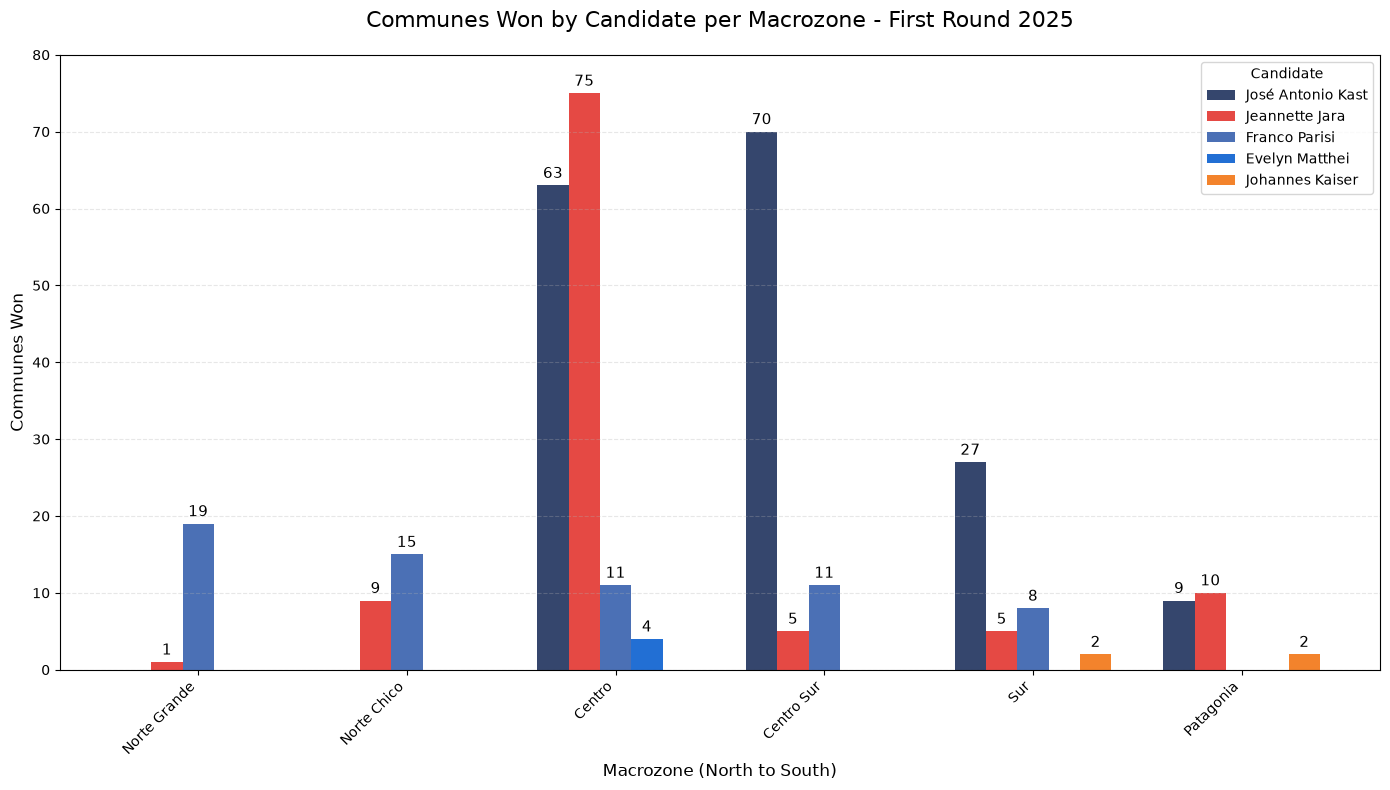

In [109]:
# ============================================================================
# COMMUNES WON PER CANDIDATE BY MACROZONE — GROUPED BAR CHART
# ============================================================================
# Generates a grouped bar chart displaying the number of communes each
# candidate won across macrozones, ordered north to south.
# ============================================================================

def plot_communes_won_by_zone(df_votes: pd.DataFrame, df_region_dim: pd.DataFrame) -> None:
    """
    Plots a grouped bar chart of communes won per candidate by macrozone.

    Parameters
    ----------
    df_votes : pd.DataFrame
        DataFrame containing vote percentages per candidate.
    df_region_dim : pd.DataFrame
        DataFrame containing region-to-macrozone mapping with ordering.
    """
    # ---------------------------------------------------------------------------
    # 0. DATA PREPARATION
    # ---------------------------------------------------------------------------
    # Merges region dimension to assign macrozone per commune.

    main_candidates = {
        'jara_pct':    'Jeannette Jara',
        'kast_pct':    'José Antonio Kast',
        'parisi_pct':  'Franco Parisi',
        'kaiser_pct':  'Johannes Kaiser',
        'matthei_pct': 'Evelyn Matthei',
    }

    df_votes_prep = df_votes.merge(
        df_region_dim[['region', 'macrozone', 'macrozone_order']],
        on='region', how='left',
    )

    # ---------------------------------------------------------------------------
    # 1. WINNER DETERMINATION
    # ---------------------------------------------------------------------------
    # Identifies the winning candidate per commune based on highest vote percentage.

    cols_pct = list(main_candidates.keys())
    df_votes_prep['winner'] = df_votes_prep[cols_pct].idxmax(axis=1).map(main_candidates)

    # ---------------------------------------------------------------------------
    # 2. CROSS-TABULATION
    # ---------------------------------------------------------------------------
    # Builds a pivot table counting communes won per candidate per macrozone.

    winner_pivot_metrics = pd.crosstab(
        df_votes_prep['winner'], df_votes_prep['macrozone'], margins=False
    )
    for candidate in main_candidates.values():
        if candidate not in winner_pivot_metrics.index:
            winner_pivot_metrics.loc[candidate] = 0

    # ---------------------------------------------------------------------------
    # 3. MACROZONE AND CANDIDATE ORDERING
    # ---------------------------------------------------------------------------
    # Sorts macrozones by geographical order and candidates by total communes won.

    macrozone_order = (
        df_region_dim[['macrozone', 'macrozone_order']]
        .drop_duplicates()
        .sort_values('macrozone_order')['macrozone']
        .tolist()
    )
    winner_pivot_metrics = winner_pivot_metrics[macrozone_order]
    winner_pivot_metrics['Total'] = winner_pivot_metrics.sum(axis=1)
    candidates_order = winner_pivot_metrics.sort_values('Total', ascending=False).index.tolist()
    winner_pivot_metrics = winner_pivot_metrics.loc[candidates_order].drop(columns=['Total'])

    # ---------------------------------------------------------------------------
    # 4. VISUALIZATION — GROUPED BAR CHART
    # ---------------------------------------------------------------------------
    # Generates a grouped bar chart with a custom color palette per candidate.

    colors = {
        'Jeannette Jara':    '#E54944',
        'José Antonio Kast': '#35466D',
        'Franco Parisi':     '#4B70B5',
        'Johannes Kaiser':   '#F3832C',
        'Evelyn Matthei':    '#226FD4',
    }

    fig, ax = plt.subplots(figsize=(14, 8))
    x = np.arange(len(macrozone_order))
    width = 0.15
    offsets = np.linspace(-0.3, 0.3, len(candidates_order))

    for i, candidate in enumerate(candidates_order):
        values = winner_pivot_metrics.loc[candidate].values
        bars = ax.bar(x + offsets[i], values, width,
                      label=candidate, color=colors.get(candidate, '#D3D3D3'))
        for bar, val in zip(bars, values):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                        str(int(val)), ha='center', va='bottom', fontsize=11)

    ax.set_xlabel('Macrozone (North to South)', fontsize=12)
    ax.set_ylabel('Communes Won', fontsize=12)
    ax.set_title('Communes Won by Candidate per Macrozone - First Round 2025',
                 fontsize=16, pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(macrozone_order, rotation=45, ha='right')
    ax.legend(loc='upper right', fontsize=10, title='Candidate')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_ylim(0, winner_pivot_metrics.values.max() + 5)
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------------
# 5. EXECUTION
# ---------------------------------------------------------------------------
# Executes the plotting function with current electoral data.

plot_communes_won_by_zone(df_votes, df_region_dim)

### Conclusion 8.2.

The territorial distribution of the vote by macrozone reveals a deeply segmented electoral map, in which each candidate built their base in territories with radically different political, economic, and social logics. Parisi consolidated unprecedented dominance in the Norte Grande and Norte Chico, turning those regions into a uniform political bloc where anti-establishment politics took hold as regional hegemony, driven by the migration crisis, organized crime, and the state's historically weak performance. Jara imposed her supremacy in the Centro —the zone of greatest demographic weight in the country— where population density offsets her disadvantage in territorial coverage, though her presence outside the Centro is marginal. Kast showed commanding dominance in the Centro Sur and Sur, where rural, agricultural, and forestry areas responded to his message with high intensity, consolidating the traditional right's territorial heartland. Patagonia, meanwhile, split mainly between Jara and Kast, with a marginal presence for Kaiser that confirms the existence of a libertarian niche in the periphery. The territory-demographics paradox —Kast controls 48.8% of the territory but wins 23.96% of the vote; Jara wins 30.3% of communes but captures 26.75% of the vote— outlines the transfer dynamics that could shape the runoff, in which each candidate's ability to win over the Parisi, Kaiser, and Matthei vote will be decisive for the final result. In this scenario, Kast starts with a structural advantage: his broad, diversified territorial base gives him a greater capacity to absorb votes from other sectors, while Jara faces the challenge of expanding her coalition beyond the urban centers where she is already strong, in a context in which territorial fragmentation and political polarization are redefining the balance of political forces in Chile.


### 8.3. Results by Region: Mapping the Three-Way Split


The 2025 presidential first round consolidated a **territorial three-way split** in the vote that goes beyond a simple north-south divide. Three electoral realities emerged, each with its own logic, its own demands, and its own winner: the anti-establishment North —dominated by Franco Parisi—, the urban-progressive Centro —led by Jeannette Jara—, and the rural-conservative Centro-Sur —controlled by José Antonio Kast. This segmentation is not new —its contours were already visible in 2021— but in 2025 it deepened and sharpened, reaching levels of internal cohesion that make building cross-cutting coalitions more difficult. The regional analysis confirms that Chile's electoral map does not respond to a single fault line, but to a **fragmented political geography** in which each macrozone expresses its own structural demands: mining extraction and the migration crisis in the North, population density and social organization in the Centro, and territorial conflict and rurality in the South.


In [110]:
# ============================================================================
# REGIONAL RESULTS AGGREGATION
# ============================================================================
# Aggregates votes by region, calculates candidate percentages over valid votes,
# determines the regional winner, and orders regions from north to south.
# ============================================================================

# ---------------------------------------------------------------------------
# 0. DATA PREPARATION
# ---------------------------------------------------------------------------
# Builds lookup dictionaries for region order and macrozone from the dimension table.

REGION_ORDER = dict(zip(df_region_dim['region'], df_region_dim['region_order']))
MACROZONE_BY_REG = dict(zip(df_region_dim['region'], df_region_dim['macrozone']))

CANDIDATE_KEYS = [
    'jara', 'kast', 'parisi', 'kaiser',
    'matthei', 'mayne_nicholls', 'enriquez_ominami', 'artes',
]

KEY_TO_NAME = {
    'jara':             'Jeannette Jara',
    'kast':             'José Antonio Kast',
    'parisi':           'Franco Parisi',
    'kaiser':           'Johannes Kaiser',
    'matthei':          'Evelyn Matthei',
    'mayne_nicholls':   'Harold Mayne-Nicholls',
    'enriquez_ominami': 'Marco Enriquez-Ominami',
    'artes':            'Eduardo Artes',
}

# ---------------------------------------------------------------------------
# 1. METRIC CALCULATION
# ---------------------------------------------------------------------------
# Aggregates votes per region and computes candidate percentages over valid votes.

cols_agg = (
    {f'{c}_votes': 'sum' for c in CANDIDATE_KEYS}
    | {'casted_votes': 'sum', 'blank_votes': 'sum', 'null_votes': 'sum'}
)
region_metrics = df_votes.groupby('region').agg(cols_agg).reset_index()

# Replaces zero valid votes with 1 to avoid division by zero.
region_metrics['valid_votes'] = (
    region_metrics['casted_votes'] - region_metrics['blank_votes'] - region_metrics['null_votes']
).replace(0, 1)

# Computes each candidate's vote percentage over valid votes per region.
for cand in CANDIDATE_KEYS:
    region_metrics[f'{cand}_percentage'] = round(
        (region_metrics[f'{cand}_votes'] / region_metrics['valid_votes']) * 100, 2
    )

# ---------------------------------------------------------------------------
# 2. RANKING / FILTERING
# ---------------------------------------------------------------------------
# Determines the regional winner by maximum percentage and orders regions
# from north to south.

pct_cols = [f'{c}_percentage' for c in CANDIDATE_KEYS]
region_metrics['regional_winner'] = (
    region_metrics[pct_cols]
    .idxmax(axis=1)
    .str.replace('_percentage', '', regex=False)
    .map(KEY_TO_NAME)
)

region_ordered_prep = region_metrics[['region', 'regional_winner'] + pct_cols].copy()
region_ordered_prep['order'] = region_ordered_prep['region'].map(REGION_ORDER).fillna(99)
regional_results_ranked = (
    region_ordered_prep
    .sort_values('order')
    .drop(columns='order')
    .reset_index(drop=True)
)

# ---------------------------------------------------------------------------
# 3. TABLE OUTPUT
# ---------------------------------------------------------------------------
# Displays the regional results table with winner and candidate percentages.

print("\n" + "=" * 80)
print("REGIONAL RESULTS")
print("=" * 80)
regional_results_ranked


REGIONAL RESULTS


,region,regional_winner,jara_percentage,kast_percentage,parisi_percentage,kaiser_percentage,matthei_percentage,mayne_nicholls_percentage,enriquez_ominami_percentage,artes_percentage
0,Arica y Parinacota,Franco Parisi,22.77,21.91,27.84,18.09,6.69,0.96,1.15,0.58
1,Tarapacá,Franco Parisi,21.98,22.60,31.11,14.57,6.95,1.14,1.11,0.54
2,Antofagasta,Franco Parisi,23.35,18.02,34.99,13.08,7.47,1.39,1.14,0.53
3,Atacama,Franco Parisi,26.45,18.81,32.60,13.13,6.29,1.01,1.16,0.55
4,Coquimbo,Jeannette Jara,27.49,19.05,26.72,13.75,10.08,1.13,1.20,0.59
5,Valparaíso,Jeannette Jara,29.56,20.26,19.50,15.39,11.88,1.40,1.31,0.70
6,Metropolitana,Jeannette Jara,31.14,21.82,14.26,12.86,16.44,1.46,1.25,0.77
7,Libertador,José Antonio Kast,24.49,25.50,21.91,13.86,11.35,1.13,1.24,0.53
8,Maule,José Antonio Kast,21.59,30.51,22.15,13.65,9.61,0.93,1.11,0.45
9,Ñuble,José Antonio Kast,19.03,31.64,22.10,15.11,9.71,0.87,1.01,0.52


#### Analysis

##### The Three Electoral Chiles

**1. The Northern Chile: Parisi's Dominance**

Franco Parisi won all four northern regions —Arica y Parinacota, Tarapacá, Antofagasta, and Atacama— with percentages ranging from 27.8% in Atacama to 35% in Antofagasta. What stands out is not just that he won, but that he did so by wide margins over second place. The North was not "contested": it was closed territory for anti-establishment politics. The combination of extractive economies —where residents perceive that the benefits of mineral wealth are not redistributed locally—, the migration crisis —Tarapacá has the highest proportion of migrants per capita in the country— and the state's historically weak performance created the conditions for Parisi to channel those demands better than any other candidate.

**2. Central Chile: Jara's Stronghold**

Jeannette Jara won five regions —Coquimbo, Valparaíso, Metropolitana, Aysén, and Magallanes— with her best result in the Metropolitana (31.14%). The density of these regions makes them the core of the national electorate: the Metropolitan Region alone holds 40% of the Chilean electoral roll. Coquimbo is the most interesting case: Jara won, but by just 0.77 points over Parisi, confirming that the northern frontier of institutional-left dominance is being eroded by the anti-establishment effect.

**3. Centro-Sur and Southern Chile: Kast's Heartland**

José Antonio Kast won seven regions —Libertador O'Higgins, Maule, Ñuble, Biobío, La Araucanía, Los Ríos, and Los Lagos— with his largest percentages in La Araucanía (32.56%) and Maule (~30%). These results reflect the rural profile of these regions, the strong evangelical presence, and a perceived neglect by the state. La Araucanía, in particular, has recorded the highest levels of rural violence since 2018, including machinery arson, attacks on farms, and land occupations. This conflict generated a vote against the governing coalition —seen as unable to resolve it— and in favor of Kast, who proposed more direct measures.

##### Structural Patterns

- **Economy-vote correlation**: there is a consistent relationship between the type of regional economy and political preference: extractive-mining economies → anti-establishment (North); service economies with high density → institutional left (Centro); rural, primary-export economies → conservative right (Centro Sur).

- **The La Araucanía conflict as an independent variable**: the region was, in 2025, the most favorable to Kast in the entire country, reflecting the exhaustion of the governing coalition on matters of public order and security.

- **Patagonia as a zone of high volatility**: Aysén and Magallanes voted for Jara in the first round, but by narrow margins. These are regions with their own electoral logics, a higher proportion of state employees and aquaculture workers, and particular sensitivity to issues of connectivity and geographic isolation.

##### Swing Regions

| Region                | Winner (1st R) | 1st–2nd Gap | Strategic significance             |
| ---------------------- | -------------- | ------------ | ------------------------------------ |
| Coquimbo               | Jara           | **0.77 pp**  | Northern frontier of Jara's dominance |
| Libertador O'Higgins   | Kast           | **1.01 pp**  | The country's most contested region  |
| Biobío                 | Kast           | 2.00 pp      | Zone of three-way competition        |
| Los Ríos               | Kast           | 2.44 pp      | Transition toward the south          |

These four regions functioned as **electoral laboratories**: small variations in differential turnout, vote transfers, or targeted mobilization could alter the regional result and, in tight elections, the national result. Heading into the runoff, they represent the territories of greatest uncertainty.


### Conclusion 8.3.

The regional analysis of the 2025 first round confirms the territorial three-way split in the Chilean vote, in which each macrozone expressed its own structural demands. Parisi consolidated the North as his stronghold, capitalizing on mining-related discontent, the migration crisis, and a perceived neglect by the state. Jara imposed her dominance in the Centro, where population density and social organization offset her territorial disadvantage, though her presence in the south and north is marginal. Kast consolidated the Centro Sur and Sur as his electoral heartland, where rural areas, territorial conflict, and the perception of an absent state generated a vote against the governing coalition. The swing regions —Coquimbo, O'Higgins, Biobío, and Los Ríos— emerged as the electoral laboratories that could prove decisive in the runoff, where small variations in the transfer of votes from Parisi, Kaiser, and Matthei could tip the balance. The territory-demographics paradox —Kast controls 48.8% of the territory but wins 23.96% of the vote; Jara wins 30.3% of communes but captures 26.75% of the vote— signals that the runoff will be decided at the margins, where each candidate's ability to win over the Parisi and Kaiser vote will be decisive for the final result.


### 8.4. Gaps in Regional Support: Where Every Vote Counts


The analysis of the gaps between the regional winner and the runner-up in the 2025 first round reveals an electoral map of uneven intensities, in which each candidate's territorial dominance was not uniform in magnitude. The contrast between highly competitive regions —such as Coquimbo (0.77 pp), O'Higgins (1.01 pp), and Biobío (2.00 pp)— and regions of overwhelming dominance —such as Antofagasta (11.64 pp), La Araucanía (11.98 pp), and Tarapacá (8.51 pp)— shows that electoral fragmentation operates not only between candidates but also in the intensity of their regional wins. Regions with narrow gaps functioned as **electoral laboratories** where small variations in vote transfers could alter the outcome, while regions with wide gaps reflect an early consolidation of preferences that points to greater stability for each candidate in their territory. This analysis helps identify the zones of greatest uncertainty ahead of the runoff and assess each candidate's territorial solidity.


In [111]:
# ============================================================================
# WINNER-RUNNER-UP GAP BY REGION — FIRST ROUND 2025
# ============================================================================
# Computes the percentage-point difference between the winning candidate and
# the runner-up for each region, based on aggregated vote totals.
# ============================================================================

# ---------------------------------------------------------------------------
# 0. DATA PREPARATION
# ---------------------------------------------------------------------------
# Defines candidate keys and mapping from candidate name to percentage column.
# Also builds region order lookup.

REGION_ORDER = dict(zip(df_region_dim['region'], df_region_dim['region_order']))

CANDIDATE_KEYS = ['jara', 'kast', 'parisi', 'kaiser', 'matthei']

NAME_TO_PCT_COL = {
    'Jeannette Jara':    'jara_pct',
    'José Antonio Kast': 'kast_pct',
    'Franco Parisi':     'parisi_pct',
    'Johannes Kaiser':   'kaiser_pct',
    'Evelyn Matthei':    'matthei_pct',
}

# ---------------------------------------------------------------------------
# 1. METRIC CALCULATION
# ---------------------------------------------------------------------------
# Aggregates votes by region and computes valid votes, then calculates
# each candidate's vote percentage.

cols_agg = (
    {f'{c}_votes': 'sum' for c in CANDIDATE_KEYS}
    | {'casted_votes': 'sum', 'blank_votes': 'sum', 'null_votes': 'sum'}
)
region_metrics = df_votes.groupby('region').agg(cols_agg).reset_index()

# Avoids division by zero by replacing zero valid votes with 1.
region_metrics['valid_votes'] = (
    region_metrics['casted_votes'] - region_metrics['blank_votes'] - region_metrics['null_votes']
).replace(0, 1)

for cand in CANDIDATE_KEYS:
    region_metrics[f'{cand}_pct'] = (
        region_metrics[f'{cand}_votes'] / region_metrics['valid_votes']
    ) * 100

# ---------------------------------------------------------------------------
# 2. RANKING / FILTERING
# ---------------------------------------------------------------------------
# Determines the winner and runner-up for each region by sorting candidate
# percentages in descending order and computing the gap.

gap_rows = []
for _, row in region_metrics.iterrows():
    percentages = {name: row[col] for name, col in NAME_TO_PCT_COL.items()}
    sorted_cands = sorted(percentages.items(), key=lambda x: x[1], reverse=True)
    gap_rows.append({
        'region':               row['region'],
        'winner':               sorted_cands[0][0],
        'winner_percentage':    round(sorted_cands[0][1], 2),
        'runner_up':            sorted_cands[1][0],
        'runner_up_percentage': round(sorted_cands[1][1], 2),
        'difference_pct':       round(sorted_cands[0][1] - sorted_cands[1][1], 2),
    })

# ---------------------------------------------------------------------------
# 3. TABLE OUTPUT
# ---------------------------------------------------------------------------
# Builds the final DataFrame, sorts by region order, and displays the results.

gap_results_ranked = pd.DataFrame(gap_rows)
gap_results_ranked['order'] = gap_results_ranked['region'].map(REGION_ORDER).fillna(99)
gap_results_ranked = (
    gap_results_ranked
    .sort_values('order')
    .drop(columns='order')
    .reset_index(drop=True)
)

print("\n" + "=" * 80)
print("WINNER-RUNNER-UP GAP BY REGION")
print("=" * 80)
display(gap_results_ranked)


WINNER-RUNNER-UP GAP BY REGION


,region,winner,winner_percentage,runner_up,runner_up_percentage,difference_pct
0,Arica y Parinacota,Franco Parisi,27.84,Jeannette Jara,22.77,5.07
1,Tarapacá,Franco Parisi,31.11,José Antonio Kast,22.60,8.51
2,Antofagasta,Franco Parisi,34.99,Jeannette Jara,23.35,11.64
3,Atacama,Franco Parisi,32.60,Jeannette Jara,26.45,6.15
4,Coquimbo,Jeannette Jara,27.49,Franco Parisi,26.72,0.77
5,Valparaíso,Jeannette Jara,29.56,José Antonio Kast,20.26,9.30
6,Metropolitana,Jeannette Jara,31.14,José Antonio Kast,21.82,9.32
7,Libertador,José Antonio Kast,25.50,Jeannette Jara,24.49,1.01
8,Maule,José Antonio Kast,30.51,Franco Parisi,22.15,8.36
9,Ñuble,José Antonio Kast,31.64,Franco Parisi,22.10,9.54


#### Analysis

##### Norte Grande: Parisi's Solid Hegemony

The Norte Grande —Arica y Parinacota, Tarapacá, and Antofagasta— was the territory where Franco Parisi consolidated his most solid dominance. The gaps between Parisi and second place are wide: 11.64 pp in Antofagasta, 8.51 pp in Tarapacá, and 5.07 pp in Arica y Parinacota. These margins indicate that the anti-establishment vote in the North was neither a marginal nor a contested phenomenon: Parisi built a regional hegemony that did not rest on narrow margins.

Antofagasta is particularly telling: with an 11.64-point gap, Parisi won 34.99% of the vote, more than 11 points ahead of Jara (23.35%). This gap reflects the intensity of discontent in the mining region par excellence, where a sense of centralized resource extraction, the migration crisis, and organized crime generated a massive vote of rejection against the traditional political system. The solidity of this gap suggests that the transfer of the Parisi vote in the North is unlikely to flow automatically toward either Kast or Jara: a significant share of this electorate could opt for active protest —a null vote or abstention— rather than for one of the two finalists.

##### Norte Chico: The Frontier of Competitiveness

The Norte Chico —Atacama and Coquimbo— shows a dual pattern reflecting the transition between Parisi's dominance in the Norte Grande and Jara's dominance in the Centro. In Atacama, Parisi won with a 6.15 pp gap over Jara (32.60% vs. 26.45%), a solid margin but smaller than in the Norte Grande. In Coquimbo, by contrast, Jara won by just **0.77 percentage points** over Parisi (27.49% vs. 26.72%), making it the most competitive region in the entire election.

Coquimbo is, therefore, the North's most significant **electoral laboratory**. The narrowness of the gap indicates that the region sits right at the boundary between Parisi's dominance and Jara's, and that small variations in vote transfers —especially away from Parisi toward other candidates— could determine the regional result in the runoff. A mixed economy —mining, agriculture, and tourism— combined with intermediate population density makes Coquimbo a highly volatile territory.

##### Metropolitan-Port Centro: Jara's Solid Stronghold

The Centro —Valparaíso and Metropolitana— was the territory where Jeannette Jara consolidated her most solid dominance. The gaps between Jara and second place are wide: 9.32 pp in the Metropolitana (31.14% vs. 21.82% for Kast) and 9.30 pp in Valparaíso (29.56% vs. 20.26% for Kast). These margins indicate that the left-wing vote in the Centro was not a contested phenomenon: Jara built a demographic hegemony that did not rest on narrow margins.

The Metropolitan Region, which holds 40% of the electoral roll, is Jara's most solid stronghold. Her 9.32-point gap reflects the persistence of the left-wing vote among urban working-class sectors of Greater Santiago, where population density, public-sector employment, and a long tradition of social organizing have shaped an electorate that consistently backs center-left and left candidacies. Yet this demographic solidity also foreshadows Jara's main challenge heading into the runoff: outside the Centro, her electoral presence is far more fragile.

##### Centro: O'Higgins and Maule — The Transition Zone

The macrozone comprising O'Higgins and Maule shows a dual pattern reflecting the transition between Jara's dominance in the Centro and Kast's dominance in the Centro Sur. In O'Higgins, Kast won by just **1.01 percentage points** over Jara (25.50% vs. 24.49%), making it the country's most contested region alongside Coquimbo. In Maule, by contrast, Kast won with an 8.36 pp gap over Parisi (30.51% vs. 22.15%), consolidating more solid dominance.

O'Higgins is, therefore, the Centro-Sur's most significant **electoral laboratory**. The narrowness of the gap —just 1.01 points— indicates that the region sits at the boundary between Jara's central Chile and Kast's southern Chile. A mixed economy —agriculture, services, and some industrial areas— combined with intermediate population density makes O'Higgins a highly volatile territory, where the transfer of the Parisi and Kaiser vote could prove decisive for the runoff result.

##### Centro Sur: Kast's Solid Heartland

The Centro Sur —Ñuble, Biobío, and La Araucanía— was the territory where José Antonio Kast consolidated his most solid dominance. The gaps between Kast and second place are wide: 11.98 pp in La Araucanía (32.56% vs. 20.58% for Parisi), 9.54 pp in Ñuble (31.64% vs. 22.10% for Parisi), and 2.00 pp in Biobío (27.09% vs. 25.09% for Parisi).

La Araucanía, with an 11.98-point gap, was the region most favorable to Kast in the entire election. This result reflects the impact of the region's territorial conflict —machinery arson, attacks on farms, and land occupations— which generated a vote against the governing coalition (seen as unable to resolve it) and in favor of Kast, who proposed more direct measures. The solidity of this gap suggests Kast should retain a considerable starting advantage in La Araucanía heading into the runoff, regardless of how the Parisi vote in the region ultimately breaks.

Biobío, with a gap of just 2.00 points, is the exception in the Centro Sur. The region, which combines the Concepción metropolitan area with rural and industrial zones, was a territory of three-way competition where Kast (27.09%), Parisi (25.09%), and Jara (22.07%) all posted significant percentages. The narrowness of the gap makes Biobío a key electoral laboratory for the runoff, where the transfer of the Parisi and Kaiser vote could tip the balance toward Kast or Jara.

##### Sur: Kast's Consolidation, With Nuance

The Sur —Los Ríos and Los Lagos— was a territory where Kast consolidated his dominance, albeit with more moderate gaps than in the Centro Sur. In Los Ríos, Kast won by 2.44 pp over Jara (26.87% vs. 24.43%), while in Los Lagos the gap was 5.00 pp over Jara (27.11% vs. 22.11%).

Los Ríos, with a 2.44-point gap, is the Sur's most competitive region. The presence of Valdivia —a university city with a left-wing tradition— together with rural areas with a strong evangelical presence, generates tighter competition than in other southern regions. The narrowness of the gap makes Los Ríos a highly volatile territory heading into the runoff.

##### Patagonia: Jara's Exception

Patagonia —Aysén and Magallanes— was the only southern macrozone where Jara prevailed, albeit with moderate gaps: 4.16 pp in Aysén (27.20% vs. 23.04% for Kast) and 5.32 pp in Magallanes (28.89% vs. 23.57% for Kast).

Patagonia's behavior confirms that the extreme southern regions have their own electoral logics, shaped by geographic isolation, a high proportion of state employees and aquaculture workers, and particular sensitivity to connectivity issues. The moderate gap in both regions suggests Patagonia could be a competitive territory in the runoff, where the transfer of the Parisi and Kaiser vote —which won significant percentages in the region in the first round— could influence the outcome.


/tmp/ipykernel_359531/3766307618.py:142: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = communes_clean.geometry.centroid


Polygons excluded (islands / Antarctic): 2
Continental map ready: 16 regions
Map saved to 'regional_maps/regional_winners_jara_kast_parisi.png'


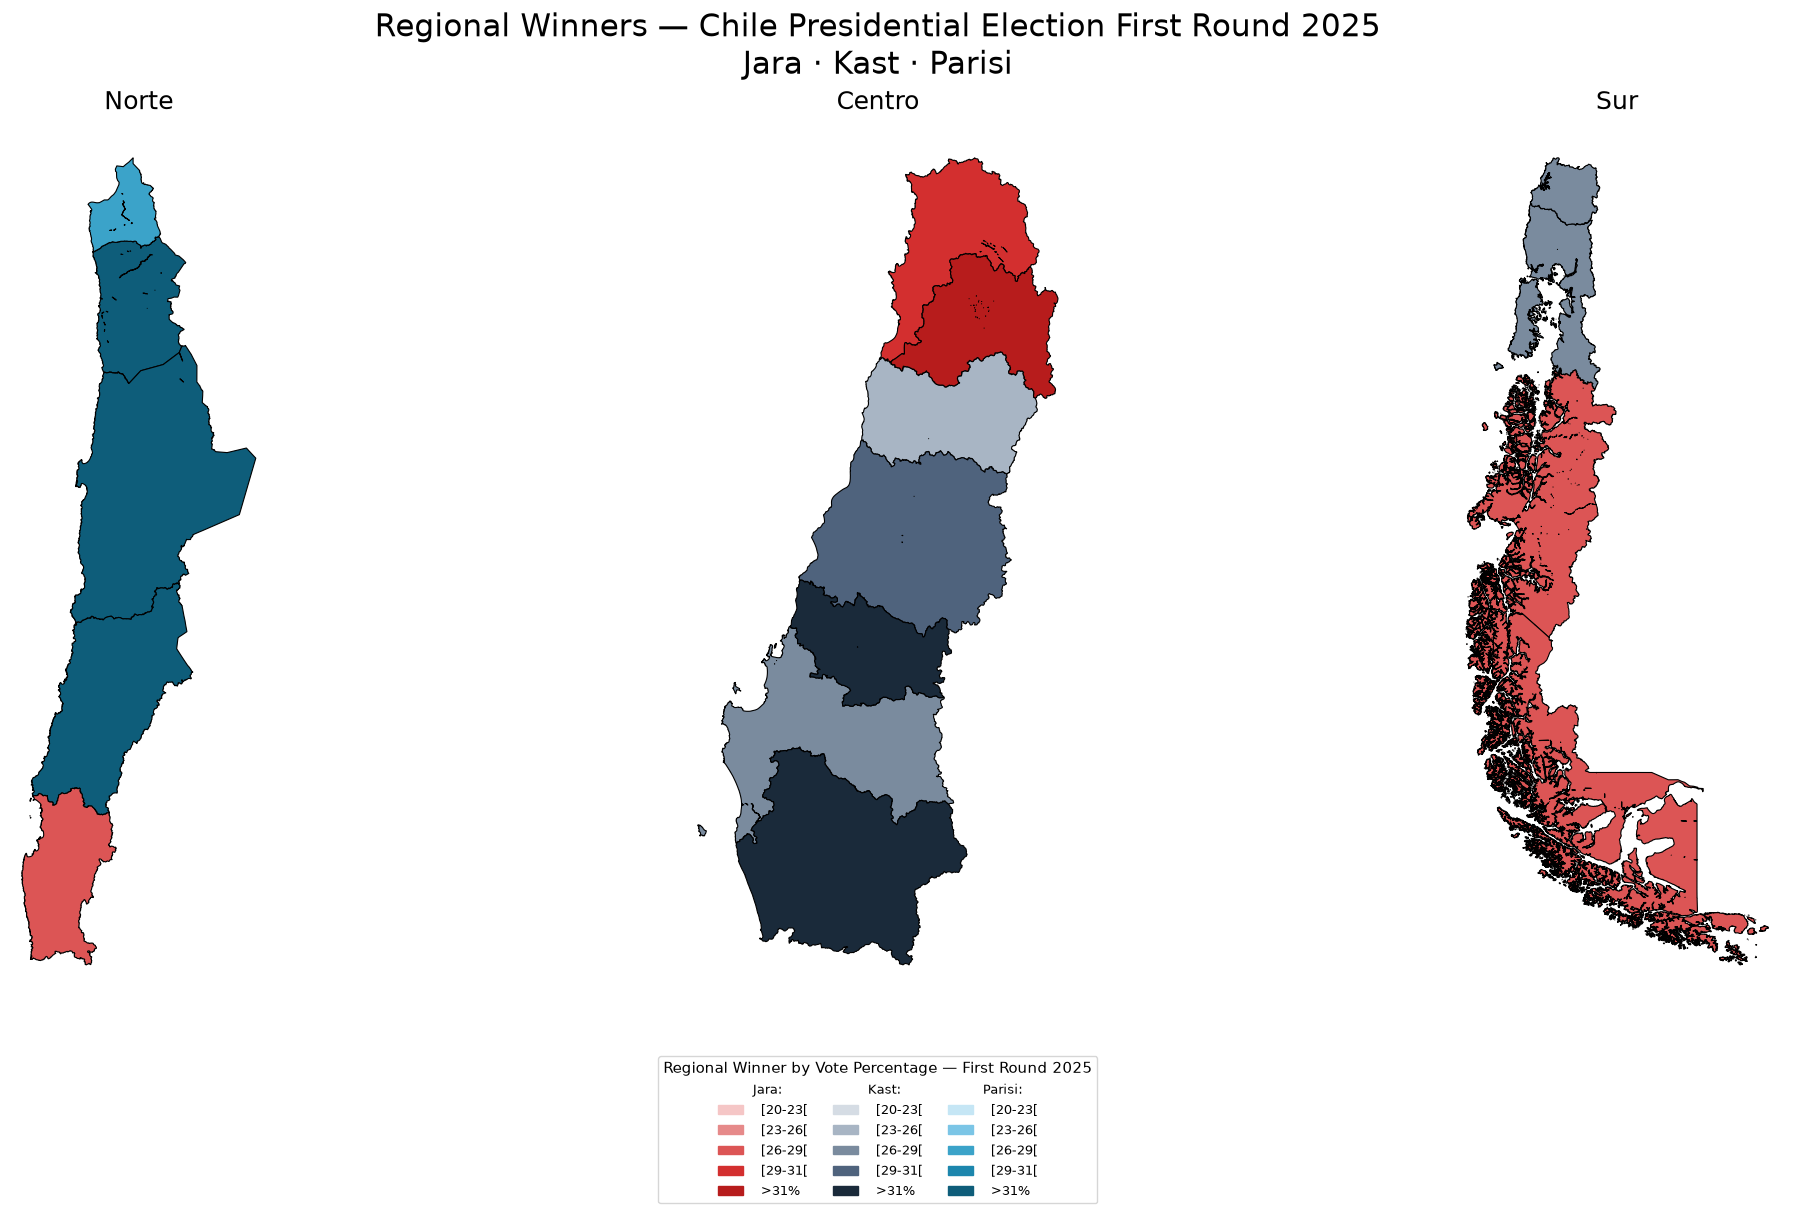

In [112]:
%matplotlib inline

# ============================================================================
# REGIONAL WINNER CHOROPLETH BY MACROREGION — FIRST ROUND 2025
# ============================================================================
# Generates a 3-panel choropleth map showing regional winners (Jara, Kast, Parisi)
# grouped by macroregion (Norte, Centro, Sur) with gradient color scales.
# ============================================================================

assert 'df_votes' in dir(), "Variable 'df_votes' not defined. Load data first."
assert 'communes' in dir(), "Variable 'communes' not defined. Run geographic data cell first."
assert 'df_region_dim' in dir(), "Variable 'df_region_dim' not defined. Load region dimension first."

# ---------------------------------------------------------------------------
# 0. DATA PREPARATION — CANDIDATE COLOR SCALES AND MACROREGION MAPPING
# ---------------------------------------------------------------------------
# Defines gradient color scales for each candidate based on vote percentage ranges.

CANDIDATE_GRADIENTS = {
    'Jara': {
        (20, 23): '#F5C6C6', 
        (23, 26): '#E68A8A',
        (26, 29): '#DC5555',
        (29, 31): '#D32F2F',
        (31, 100): '#B71C1C',
    },
    'Kast': {
        (20, 23): '#D5DCE4',
        (23, 26): '#A8B5C4',
        (26, 29): '#7A8B9E',
        (29, 31): '#4F637D',
        (31, 100): '#1A2A3A',
    },
    'Parisi': {
        (20, 23): '#C5E6F5',
        (23, 26): '#7BC5E6',
        (26, 29): '#3BA3C9',
        (29, 31): '#1C86AD',
        (31, 100): '#0E5D7A',
    },
}

CANDIDATE_KEYS = ['jara', 'kast', 'parisi']

CANDIDATE_DISPLAY = {
    'jara': 'Jara', 'kast': 'Kast', 'parisi': 'Parisi',
}

CANDIDATE_SOLID = {
    'No data': '#D3D3D3',
}

def get_gradient_color(candidate_name: str, pct: float) -> str:
    """Returns gradient color for a candidate based on vote percentage range."""
    if pd.isna(pct) or pct < 20:
        return CANDIDATE_SOLID.get('No data', '#D3D3D3')
    
    if candidate_name in CANDIDATE_GRADIENTS:
        gradients = CANDIDATE_GRADIENTS[candidate_name]
        for (low, high), color in gradients.items():
            if low <= pct < high:
                return color
        return list(gradients.values())[-1]
    else:
        return CANDIDATE_SOLID.get(candidate_name, '#D3D3D3')

# ---------------------------------------------------------------------------
# 0. DATA PREPARATION — MACROREGION MAPPING (3 ZONES)
# ---------------------------------------------------------------------------
# Maps region codes to macroregions: Norte, Centro, Sur.

MACROREGION_MAP = {
    15: 'Norte',
    1:  'Norte',
    2:  'Norte',
    3:  'Norte',
    4:  'Norte',
    5:  'Centro',
    13: 'Centro',
    6:  'Centro',
    7:  'Centro',
    16: 'Centro',
    8:  'Centro',
    9:  'Centro',
    14: 'Sur',
    10: 'Sur',
    11: 'Sur',
    12: 'Sur',
}

# ---------------------------------------------------------------------------
# 1. METRIC CALCULATION — REGIONAL WINNER AND VOTE PERCENTAGES
# ---------------------------------------------------------------------------
# Aggregates votes by region, computes valid votes, and determines the winner.

regions_agg = df_votes.groupby('region').agg(
    {f'{c}_votes': 'sum' for c in CANDIDATE_KEYS}
    | {'casted_votes': 'sum', 'blank_votes': 'sum', 'null_votes': 'sum'}
).reset_index()

regions_agg['valid_votes'] = (
    regions_agg['casted_votes'] - regions_agg['blank_votes'] - regions_agg['null_votes']
).replace(0, 1)

for cand in CANDIDATE_KEYS:
    regions_agg[f'{cand}_pct'] = regions_agg[f'{cand}_votes'] / regions_agg['valid_votes'] * 100

pct_cols = [f'{c}_pct' for c in CANDIDATE_KEYS]
regions_agg['winner_key'] = regions_agg[pct_cols].idxmax(axis=1).str.replace('_pct', '', regex=False)
regions_agg['winner_pct'] = regions_agg[pct_cols].max(axis=1)
regions_agg['winner_display'] = regions_agg['winner_key'].map(CANDIDATE_DISPLAY)

# ---------------------------------------------------------------------------
# 2. DATA PREPARATION — MERGE REGION CODES AND MACROREGION ASSIGNMENT
# ---------------------------------------------------------------------------
# Merges region codes from dimension table and assigns macroregion.

regions_agg = regions_agg.merge(df_region_dim[['region', 'region_code']], on='region', how='left')
regions_agg['REGION_NUM'] = regions_agg['region_code'].astype(int)

regions_agg['macroregion'] = regions_agg['REGION_NUM'].map(MACROREGION_MAP)

# ---------------------------------------------------------------------------
# 3. COLOR ASSIGNMENT — WINNER GRADIENT
# ---------------------------------------------------------------------------
# Assigns color based on winner and vote percentage.

regions_agg['color'] = regions_agg.apply(
    lambda row: get_gradient_color(row['winner_display'], row['winner_pct']), axis=1
)

# ---------------------------------------------------------------------------
# 4. DATA PREPARATION — FILTER CONTINENTAL CHILE AND DISSOLVE TO REGIONS
# ---------------------------------------------------------------------------
# Filters out islands and Antarctic polygons, then dissolves communes into regions.

BBOX = dict(lon_min=-76, lon_max=-65, lat_min=-56, lat_max=-17)

communes_clean = communes.copy()
communes_clean['geometry'] = communes_clean['geometry'].buffer(0)

centroids = communes_clean.geometry.centroid
mask = (
    centroids.x.between(BBOX['lon_min'], BBOX['lon_max']) &
    centroids.y.between(BBOX['lat_min'], BBOX['lat_max'])
)
print(f'Polygons excluded (islands / Antarctic): {(~mask).sum()}')
communes_continental = communes_clean[mask].copy()

regions_geom = communes_continental.dissolve(by='REGION_NUM', aggfunc='first').reset_index()
map_gdf = regions_geom.merge(regions_agg, on='REGION_NUM', how='left')
map_gdf['winner_display'] = map_gdf['winner_display'].fillna('No data')
map_gdf['color'] = map_gdf['color'].fillna(CANDIDATE_SOLID['No data'])
map_gdf['macroregion'] = map_gdf['macroregion'].fillna('No data')
print(f'Continental map ready: {len(map_gdf)} regions')

# ---------------------------------------------------------------------------
# 5. VISUALIZATION — MACROREGION MAPS (NORTE, CENTRO, SUR)
# ---------------------------------------------------------------------------
# Renders three subplots, one per macroregion, with winner colors.

macro_order = ['Norte', 'Centro', 'Sur']

fig, axes = plt.subplots(1, 3, figsize=(24, 12))

for idx, macro in enumerate(macro_order):
    ax = axes[idx]
    macro_data = map_gdf[map_gdf['macroregion'] == macro].copy()
    
    if macro_data.empty:
        ax.text(0.5, 0.5, f'No data\n{macro}', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(macro, fontsize=16)
        ax.set_axis_off()
        continue
    
    macro_data.plot(ax=ax, color=macro_data['color'], edgecolor='black', linewidth=0.8)
    ax.set_title(macro, fontsize=18)
    ax.set_axis_off()
    
    if macro == 'Sur':
        bounds = macro_data.total_bounds
        margin_x = (bounds[2] - bounds[0]) * 0.05
        margin_y = (bounds[3] - bounds[1]) * 0.05
        ax.set_xlim(bounds[0] - margin_x, bounds[2] + margin_x)
        ax.set_ylim(bounds[1] - margin_y, bounds[3] + margin_y)

fig.suptitle(
    'Regional Winners — Chile Presidential Election First Round 2025\nJara · Kast · Parisi',
    fontsize=22, y=0.98,
)

# ---------------------------------------------------------------------------
# 6. VISUALIZATION — LEGEND
# ---------------------------------------------------------------------------
# Creates a custom legend with gradient color ranges for each candidate.

legend_handles = []

for cand_name, gradients in CANDIDATE_GRADIENTS.items():
    legend_handles.append(mpatches.Patch(color='white', label=f'{cand_name}:', alpha=0))
    for (low, high), color in gradients.items():
        if high == 100:
            label = f'  >{low}%'
        else:
            label = f'  [{low}-{high}[' 
        legend_handles.append(mpatches.Patch(color=color, label=label))

fig.legend(
    handles=legend_handles, loc='lower center', ncol=3, fontsize=9,
    title='Regional Winner by Vote Percentage — First Round 2025', title_fontsize=11,
    bbox_to_anchor=(0.5, -0.02),
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)

os.makedirs('regional_maps', exist_ok=True)
output_path = 'regional_maps/regional_winners_jara_kast_parisi.png'
fig.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Map saved to '{output_path}'")
plt.show()

### Conclusion 8.4.

The analysis of gaps in regional support reveals an electoral map of uneven intensities, in which each candidate's territorial dominance was not uniform in magnitude. Parisi consolidated the Norte Grande as his most solid stronghold, with gaps exceeding 11 points in Antofagasta, while the Norte Chico —especially Coquimbo— emerged as the most competitive frontier. Jara imposed her dominance in the Centro with gaps above 9 points in Valparaíso and the Metropolitana, though her presence outside the Centro is more fragile. Kast consolidated the Centro Sur as his electoral heartland, with gaps reaching 12 points in La Araucanía, while O'Higgins and Biobío emerged as the country's most contested regions. The swing regions —Coquimbo (0.77 pp), O'Higgins (1.01 pp), Biobío (2.00 pp), and Los Ríos (2.44 pp)— functioned as electoral laboratories where small variations in the transfer of votes from Parisi, Kaiser, and Matthei could tip the balance. Heading into the runoff, these regions stand out as the main battleground, where each candidate's ability to win over the anti-establishment and libertarian vote could prove decisive for the final result.


### Conclusion to Chapter 8: Territorial Mapping and Vote Distribution


The territorial analysis of the 2025 first round confirms the three-way split in the Chilean vote across three electoral realities, each with its own logic. Parisi consolidated the North as his stronghold —with 64 communes won and dominance reaching gaps of 11.64 pp in Antofagasta— capitalizing on mining-related discontent, the migration crisis, and a perceived neglect by the state. Jara imposed her dominance in the Centro —with 105 communes and gaps above 9 points in Valparaíso and the Metropolitana— where population density and social organization offset her territorial disadvantage, though her presence outside the Centro is marginal. Kast consolidated the Centro Sur and Sur as his electoral heartland —with 169 communes and gaps reaching 12 points in La Araucanía— where rural areas, territorial conflict, and the perception of an absent state generated a vote against the governing coalition.

The territory-demographics paradox is the most significant finding: Kast controls 48.8% of the territory but wins 23.96% of the vote; Jara wins 30.3% of communes but captures 26.75% of the vote. This arithmetic carries a direct political reading: winning many small communes does not equate to greater electoral power in a runoff system, where what counts is the total national valid vote. Even so, Kast's territorial coverage is not irrelevant: it implies a more geographically diversified base, greater resilience to variation in regional turnout, and a network of local loyalties that is a valuable asset heading into the runoff.

The swing regions —Coquimbo (0.77 pp), O'Higgins (1.01 pp), Biobío (2.00 pp), and Los Ríos (2.44 pp)— emerged as the electoral laboratories that could prove decisive in the runoff, where small variations in the transfer of votes from Parisi, Kaiser, and Matthei could tip the balance. Matthei's territorial collapse —reduced to 4 communes in Santiago's elite— confirms the end of an era in which the traditional right served as the main organizer of the conservative vote, while Kaiser's breakthrough with 4 communes in Patagonia opens up a new political niche that could consolidate in future electoral cycles. In this scenario, Kast starts with a structural advantage: his broad, diversified territorial base gives him a greater capacity to absorb votes from other sectors, while Jara faces the challenge of expanding her coalition beyond the urban centers where she is already strong, in a context in which territorial fragmentation and political polarization are redefining the balance of political forces in Chile.


---

## 9. Regional Capitals: The Urban-Administrative Vote


### Introduction


Up to this point, the analysis has treated each region as a homogeneous unit. But within every region there is a crucial distinction that regional averages tend to obscure: the one separating the capital —an administrative, university, and services hub— from its rural, peripheral hinterland. This chapter tests that distinction by examining the results in the country's 16 regional capitals, and the finding is one of the sharpest structural gaps in Chile's electoral map: the systematic reversal between the vote in urban-administrative centers and the vote across each region as a whole. The analysis of results in the capitals (9.1) and of competitiveness gaps (9.2) makes it possible to establish whether, and to what extent, "the capital votes differently than its region."


### 9.1. Results in Regional Capitals: When the Capital Votes Against Its Own Region


One of the most revealing contrasts of the 2025 presidential first round is the **systematic gap between results in regional capitals and results across each region as a whole**. This gap is not a technical detail: it is an indicator of how different socioeconomic and functional contexts —the capital city versus its hinterland— produce radically different electoral behavior, even within the same administrative region. The analysis of the 16 regional capitals reveals a **reversal of the power map**: Jeannette Jara won 10 of 16 capitals (62.5%) but only 5 of 16 regions (31.3%), while José Antonio Kast won 4 capitals (25.0%) but 7 regions (43.8%). This paradox —capitals vote differently than their own regions— points to the fact that the urban-administrative vote and the rural-peripheral vote respond to different logics that neither runoff candidate can afford to ignore.


In [113]:
# ============================================================================
# REGIONAL CAPITAL RESULTS — FIRST ROUND 2025
# ============================================================================
# Filters electoral data to the 16 regional capitals, determines the winning
# candidate in each, and orders results north to south.
# ============================================================================

# ---------------------------------------------------------------------------
# 0. DATA PREPARATION
# ---------------------------------------------------------------------------
# Defines commune name normalisation utility, capital list, and lookup mappings.

def normalize_name(name: str) -> str:
    """
    Backward-compatible alias for normalize_commune_name (§2.4).
    Retained so downstream functions continue to work without modification;
    all normalisation logic is consolidated in normalize_commune_name.
    """
    return normalize_commune_name(name)


REGIONAL_CAPITALS = [
    'Arica', 'Iquique', 'Antofagasta', 'Copiapo', 'La Serena',
    'Valparaiso', 'Santiago', 'Rancagua', 'Talca', 'Chillan',
    'Concepcion', 'Temuco', 'Valdivia', 'Puerto Montt', 'Coyhaique',
    'Punta Arenas',
]

capitals_norm = {normalize_name(c): c for c in REGIONAL_CAPITALS}
region_order  = dict(zip(df_region_dim['region'], df_region_dim['region_order']))

key_to_name_5 = {
    'jara':    'Jeannette Jara',
    'kast':    'José Antonio Kast',
    'parisi':  'Franco Parisi',
    'kaiser':  'Johannes Kaiser',
    'matthei': 'Evelyn Matthei',
}
candidate_keys = ['jara', 'kast', 'parisi', 'kaiser', 'matthei']
pct_columns    = [f'{c}_pct' for c in candidate_keys]

# ---------------------------------------------------------------------------
# 1. FILTER REGIONAL CAPITALS
# ---------------------------------------------------------------------------
# Normalises commune names and keeps only the 16 predefined regional capitals.

df_prep = df_votes.copy()
df_prep['commune_norm'] = df_prep['commune'].apply(normalize_name)
capitals_prep = df_prep[df_prep['commune_norm'].isin(capitals_norm.keys())].copy()
capitals_prep['capital'] = capitals_prep['commune_norm'].map(capitals_norm)

missing = set(REGIONAL_CAPITALS) - set(capitals_prep['capital'].unique())
if missing:
    print(f'Capitals not found in data: {missing}')

# ---------------------------------------------------------------------------
# 2. NORMALIZE COLUMN NAMES AND DETERMINE WINNER
# ---------------------------------------------------------------------------
# Maps candidate columns to human-readable names and selects the winner
# based on the highest vote percentage.

capitals_prep['winner'] = (
    capitals_prep[pct_columns]
    .idxmax(axis=1)
    .str.replace('_pct', '', regex=False)
    .map(key_to_name_5)
)
capitals_prep['winner_percentage'] = capitals_prep[pct_columns].max(axis=1)

# ---------------------------------------------------------------------------
# 3. ORDER BY REGION
# ---------------------------------------------------------------------------
# Sorts capitals according to the regional north-to-south order.

capital_results_ranked = capitals_prep[
    ['capital', 'region', 'winner', 'winner_percentage'] + pct_columns
].copy()
capital_results_ranked['order'] = capital_results_ranked['region'].map(region_order).fillna(99)
capital_results_ranked = (
    capital_results_ranked
    .sort_values('order')
    .drop(columns='order')
    .reset_index(drop=True)
)

# ---------------------------------------------------------------------------
# 4. TABLE OUTPUT
# ---------------------------------------------------------------------------
# Displays the final table with winner, percentages, and regional order.

print("\n" + "=" * 80)
print("REGIONAL CAPITAL RESULTS")
print("=" * 80)
capital_results_ranked


REGIONAL CAPITAL RESULTS


,capital,region,winner,winner_percentage,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct
0,Arica,Arica y Parinacota,Franco Parisi,27.68,22.97,21.79,27.68,18.16,6.69
1,Iquique,Tarapacá,Jeannette Jara,25.03,25.03,23.71,24.26,15.60,8.34
2,Antofagasta,Antofagasta,Franco Parisi,32.54,24.71,17.98,32.54,12.99,8.44
3,Copiapo,Atacama,Franco Parisi,30.51,25.89,20.26,30.51,13.48,6.88
4,La Serena,Coquimbo,Jeannette Jara,28.72,28.72,18.95,21.90,14.68,12.59
5,Valparaiso,Valparaíso,Jeannette Jara,36.34,36.34,17.11,16.59,15.23,10.67
6,Santiago,Metropolitana,Jeannette Jara,32.71,32.71,20.73,7.20,12.80,23.11
7,Rancagua,Libertador,Jeannette Jara,26.54,26.54,21.54,22.62,14.08,11.91
8,Talca,Maule,Jeannette Jara,26.65,26.65,25.36,20.15,12.97,12.03
9,Chillan,Ñuble,José Antonio Kast,27.70,22.65,27.70,20.29,15.21,11.35


#### Analysis

##### The Capital-Region Paradox: A Reversal of the Power Map

The most structural finding in the section on regional capitals is the **reversal of the power map** that occurs when moving from the capitals to the full regional territory. The comparative table tells the story:

| Candidate               | Capitals Won | % Capitals | Regions Won | % Regions | Interpretation                          |
| ------------------------ | ------------- | ----------- | ------------- | ----------- | ----------------------------------------- |
| **Jeannette Jara**        | **10 / 16**    | **62.5%**   | 5 / 16         | 31.3%       | Urban-capital phenomenon                  |
| **José Antonio Kast**     | 4 / 16         | 25.0%       | **7 / 16**     | **43.8%**   | Rural-territorial phenomenon              |
| **Franco Parisi**         | 2 / 16         | 12.5%       | 4 / 16         | 25.0%       | Northern phenomenon, urban weakness       |
| Matthei / Kaiser          | 0              | 0%          | 0              | 0%          | No regional representation                |

**The paradox is stark:** Jara won 10 of 16 capitals and only 5 of 16 regions. Kast won 4 capitals and 7 regions. This means capitals "vote differently" from their own regions, and quite consistently so: they are more favorable to Jara, less favorable to Kast, and nearly impermeable to Parisi outside the North.

##### Readings by Candidate

**Jeannette Jara — The candidate of the capital cities**

Jara dominates in capitals such as Valparaíso (36.34%), Santiago (32.71%), Valdivia (31.03%), and La Serena (28.72%). Her performance in these cities reflects the weight of the university, public-employee, and services vote concentrated in regional capitals. Even in regions where she loses (La Araucanía, Maule), Jara posts respectable results in Temuco (22.05%) and Talca (26.65%), showing that capitals function as "progressive islands" within conservative regions. Yet her inability to translate control of the capitals into regional control reveals her structural weakness: outside the cities, her electoral presence thins out quickly.

**José Antonio Kast — Stronger in the hinterland than in the capital**

Kast wins capitals such as Temuco (29.36%), Chillán (27.70%), Puerto Montt (26.81%), and Copiapó (30.51% —though Parisi is the regional winner in Copiapó), but his real advantage lies in the territory surrounding those cities, not in the cities themselves. In Temuco, for instance, he wins the capital but by a smaller margin than in adjacent rural communes of La Araucanía, where his percentage exceeds 70% in some localities. The gap between his performance in capitals (25.0% won) and his regional performance (43.8% of regions) confirms that the heart of his support lies not in urban administrative centers but in rural, peripheral Chile.

**Franco Parisi — Structural urban weakness**

Parisi wins only Antofagasta (32.54%) and Iquique (24.26%) among the regional capitals. In all the others —including capitals of regions he won in the regional aggregate, such as Arica (27.68%) and Copiapó (30.51%)— he loses to Jara. This pattern confirms that his vote is significantly stronger in rural, mining, and border communes than in established urban centers, even in the North. Parisi's urban weakness is structural: his anti-establishment rhetoric, though effective in peripheral territories, fails to penetrate administrative centers, where public employment and state services foster a more institutional relationship with the political system.

**Evelyn Matthei — Widespread urban underrepresentation**

Matthei posts her best result in Santiago (23.11%), where a high concentration of high-income sectors gives her a "natural base." Outside that enclave, her average across regional capitals falls to 10-11%, confirming that Chile Vamos's collapse is not solely a rural or peripheral phenomenon but a cross-cutting one that includes the cities. The fact that Matthei failed to win a single regional capital —not even in elite communes such as Vitacura or Las Condes, which are part of Santiago but not capitals in the administrative sense— reflects the scale of her defeat.

**Johannes Kaiser — The most surprising case**

Kaiser shows better relative performance in capitals (~15.4%) than in his national average (13.94%). He stands out in Coyhaique (20.62%), Punta Arenas (17.23%), and Puerto Montt (16.26%), suggesting that his electorate —urban, young, highly connected to social media and online ideological debate— is more concentrated in cities than in the rural world, unlike Kast's pattern. This is one of the few dimensions in which Kaiser clearly sets himself apart from the traditional conservative right: his support is more urban and less territorial.


### Conclusion 9.1.

The analysis of results in regional capitals reveals a structural gap between urban-administrative Chile and rural-peripheral Chile that defines the 2025 electoral map. Jara won 10 of 16 capitals (62.5%) but only 5 of 16 regions (31.3%), confirming that her support is an urban-capital phenomenon concentrated in administrative and university centers. Kast won 4 capitals (25.0%) but 7 regions (43.8%), showing that his strength lies in the rural, peripheral hinterland surrounding the cities. Parisi, with only 2 capitals won, shows structural urban weakness that contrasts with his dominance in the mining, border North. Matthei and Kaiser, with no capitals won, confirm their lack of a broad territorial base, though Kaiser stands out for his better relative performance in capitals, suggesting a more urban, digitally connected electorate. This reversal of the power map —in which capitals vote differently than their own regions— outlines one of the axes of the runoff dynamic: Jara will need to mobilize her urban vote without losing control of the capitals, while Kast will need to consolidate his rural dominance without letting the cities slip entirely out of reach.


### 9.2. Competitiveness Gaps in the Regional Capitals: Iquique and the Three-Way Tie


The analysis of the gaps between the winner and the runner-up in the 16 regional capitals reveals a map of competitiveness that complements and nuances the regional analysis. While gaps across entire regions can be wide —as in Antofagasta (11.64 pp) or La Araucanía (11.98 pp)— gaps in the capitals tend to be narrower, reflecting tighter competition in urban centers. The contrast between highly competitive capitals —such as Iquique (0.77 pp), Talca (1.29 pp), and Rancagua (3.92 pp)— and capitals of overwhelming dominance —such as Valparaíso (19.23 pp) and Santiago (9.60 pp)— shows that the urban-administrative vote is not homogeneous but responds to specific local political dynamics. Iquique is a particularly telling case: with a gap of just 0.77 points, the capital of Tarapacá was the most competitive region in the entire country, reflecting extreme fragmentation of the vote in a city where Parisi, Jara, and Kast competed in what was essentially a three-way tie.


In [114]:
# ============================================================================
# WINNER-RUNNER-UP GAP IN REGIONAL CAPITALS — FIRST ROUND 2025
# ============================================================================
# Computes the percentage-point difference between the winning candidate and
# the runner-up in each of the 16 regional capitals, ordered north to south.
# ============================================================================

# ---------------------------------------------------------------------------
# 0. DATA PREPARATION
# ---------------------------------------------------------------------------
# Defines commune name normalisation utility, capital list, and lookup mappings.

def normalize_name(name: str) -> str:
    """
    Backward-compatible alias for normalize_commune_name (§2.4).
    Retained so downstream functions continue to work without modification;
    all normalisation logic is consolidated in normalize_commune_name.
    """
    return normalize_commune_name(name)


REGIONAL_CAPITALS = [
    'Arica', 'Iquique', 'Antofagasta', 'Copiapo', 'La Serena',
    'Valparaiso', 'Santiago', 'Rancagua', 'Talca', 'Chillan',
    'Concepcion', 'Temuco', 'Valdivia', 'Puerto Montt', 'Coyhaique',
    'Punta Arenas',
]

capitals_norm = {normalize_name(c): c for c in REGIONAL_CAPITALS}
region_order  = dict(zip(df_region_dim['region'], df_region_dim['region_order']))

CANDIDATE_PCT_COLS = {
    'Jeannette Jara':    'jara_pct',
    'José Antonio Kast': 'kast_pct',
    'Franco Parisi':     'parisi_pct',
    'Johannes Kaiser':   'kaiser_pct',
    'Evelyn Matthei':    'matthei_pct',
}

# ---------------------------------------------------------------------------
# 1. FILTER REGIONAL CAPITALS
# ---------------------------------------------------------------------------
# Normalises commune names and keeps only the 16 predefined regional capitals.

df_prep = df_votes.copy()
df_prep['commune_norm'] = df_prep['commune'].apply(normalize_name)
capitals_prep = df_prep[df_prep['commune_norm'].isin(capitals_norm.keys())].copy()
capitals_prep['capital'] = capitals_prep['commune_norm'].map(capitals_norm)

missing = set(REGIONAL_CAPITALS) - set(capitals_prep['capital'].unique())
if missing:
    print(f'Capitals not found in data: {missing}')

# ---------------------------------------------------------------------------
# 2. COMPUTE WINNER-RUNNER-UP GAP
# ---------------------------------------------------------------------------
# Extracts candidate percentages, determines winner and runner-up per capital,
# and computes the percentage-point gap.

gap_rows = []
for _, row in capitals_prep.iterrows():
    candidate_pcts = {name: row[col] for name, col in CANDIDATE_PCT_COLS.items()}
    sorted_cands = sorted(candidate_pcts.items(), key=lambda x: x[1], reverse=True)
    gap_rows.append({
        'capital':              row['capital'],
        'region':               row['region'],
        'winner':               sorted_cands[0][0],
        'winner_percentage':    round(sorted_cands[0][1], 2),
        'runner_up':            sorted_cands[1][0],
        'runner_up_percentage': round(sorted_cands[1][1], 2),
        'difference_pct':       round(sorted_cands[0][1] - sorted_cands[1][1], 2),
    })

# ---------------------------------------------------------------------------
# 3. ORDER BY REGION
# ---------------------------------------------------------------------------
# Sorts capitals according to the regional north-to-south order.

capital_gaps_ranked = pd.DataFrame(gap_rows)
capital_gaps_ranked['order'] = capital_gaps_ranked['region'].map(region_order).fillna(99)
capital_gaps_ranked = (
    capital_gaps_ranked
    .sort_values('order')
    .drop(columns='order')
    .reset_index(drop=True)
)

# ---------------------------------------------------------------------------
# 4. TABLE OUTPUT
# ---------------------------------------------------------------------------
# Displays the winner-runner-up gap for each regional capital.

print("\n" + "=" * 80)
print("WINNER-RUNNER-UP GAP IN REGIONAL CAPITALS")
print("=" * 80)
capital_gaps_ranked


WINNER-RUNNER-UP GAP IN REGIONAL CAPITALS


,capital,region,winner,winner_percentage,runner_up,runner_up_percentage,difference_pct
0,Arica,Arica y Parinacota,Franco Parisi,27.68,Jeannette Jara,22.97,4.71
1,Iquique,Tarapacá,Jeannette Jara,25.03,Franco Parisi,24.26,0.77
2,Antofagasta,Antofagasta,Franco Parisi,32.54,Jeannette Jara,24.71,7.83
3,Copiapo,Atacama,Franco Parisi,30.51,Jeannette Jara,25.89,4.62
4,La Serena,Coquimbo,Jeannette Jara,28.72,Franco Parisi,21.90,6.82
5,Valparaiso,Valparaíso,Jeannette Jara,36.34,José Antonio Kast,17.11,19.23
6,Santiago,Metropolitana,Jeannette Jara,32.71,Evelyn Matthei,23.11,9.60
7,Rancagua,Libertador,Jeannette Jara,26.54,Franco Parisi,22.62,3.92
8,Talca,Maule,Jeannette Jara,26.65,José Antonio Kast,25.36,1.29
9,Chillan,Ñuble,José Antonio Kast,27.70,Jeannette Jara,22.65,5.05


#### Analysis

##### General Pattern: Capitals More Competitive Than Regions

A consistent finding in the analysis of capitals is that the gaps between the winner and the runner-up tend to be narrower than across each region as a whole. Where the regional analysis found gaps exceeding 11 points (Antofagasta, La Araucanía), the capitals generally show smaller differences: 9 of the 16 capitals have gaps under 6 points. This pattern suggests that regional capitals are territories of greater electoral competition, where socioeconomic diversity and the presence of middle-class and university sectors produce a more fragmented electorate, less prone to hegemony by a single candidate.

##### The Case of Iquique: The Country's Most Competitive Capital

**Iquique** stands out as the regional capital with the narrowest gap of the entire election: just **0.77 percentage points** between Jeannette Jara (25.03%) and Franco Parisi (24.26%), with José Antonio Kast very close behind (23.71%). This is the only capital where three candidates —Jara, Parisi, and Kast— posted such close percentages, reflecting extreme fragmentation of the vote.

Iquique's case is particularly relevant for several reasons. First, because the city is the capital of the Tarapacá Region, one of the regions where Parisi was the regional winner, with 31.11% and an 8.51-point gap over Kast. The reversal of the power map in Iquique —where Jara wins by a razor-thin margin— shows that the capital of Tarapacá "votes differently" than the rest of the region: it is more favorable to the institutional left, less favorable to Parisi, and far more competitive than the northern hinterland.

Second, Iquique is an extreme case of the **urban-rural gap** that characterizes the North. While in Tarapacá's rural and mining communes —such as Colchane, Camiña, and Pica— Parisi won overwhelming victories with percentages exceeding 40% and 50%, in the capital the anti-establishment candidate was relegated to a closely contested third place. This contrast suggests that Parisi's vote in the North is significantly stronger in peripheral, border territories than in established urban centers, where the presence of the state and public services foster a more institutional relationship with the political system.

Third, the three-way tie in Iquique foreshadows a particularly uncertain runoff dynamic in the city: with three candidates separated by less than 1.3 points, where the Parisi and Kast vote ultimately goes will be decisive for the final result. If Parisi's electorate in Iquique opts for active protest (null vote or abstention) rather than transferring its vote to Kast, Jara could consolidate her advantage; if, on the other hand, the Parisi vote swings mostly toward Kast, the Republican candidate could reverse the result.

##### Other Highly Competitive Capitals

**Talca** (1.29 pp): Jeannette Jara won by just 1.29 points over José Antonio Kast (26.65% vs. 25.36%), with Parisi close behind (20.15%). Talca is the capital of the Maule Region, where Kast was the regional winner with an 8.36-point gap over Parisi. The narrowness of the gap in Talca confirms that the Maule's capital functions as a "progressive island" within a conservative region, where the university and public-employee vote offsets Kast's rural dominance.

**Rancagua** (3.92 pp): Jeannette Jara won by 3.92 points over Franco Parisi (26.54% vs. 22.62%), with Kast in third place (21.54%). Rancagua is the capital of the O'Higgins Region, where Kast was the regional winner by just 1.01 points over Jara. The reversal of the power map in Rancagua —where Jara wins and Parisi comes second— shows that O'Higgins's capital is significantly more favorable to the left and to anti-establishment politics than the rest of the region, where the rural vote tips the balance toward Kast.

**Concepción** (3.78 pp): Jeannette Jara won by 3.78 points over José Antonio Kast (28.00% vs. 24.22%), with Parisi in third place (16.42%). Concepción is the capital of the Biobío Region, where Kast was the regional winner by 2.00 points over Parisi. Jara's win in Concepción confirms that major university cities —Concepción is home to one of the country's leading universities— are more favorable to the left than their surrounding region.

##### Capitals of Overwhelming Dominance

**Valparaíso** (19.23 pp): Jeannette Jara scored an overwhelming victory with 36.34% of the vote, more than 19 points ahead of Kast (17.11%). Valparaíso is the capital of the Valparaíso Region, where Jara won by 9.30 points over Kast. The width of the gap in Valparaíso reflects the city's progressive, port-city tradition, where social organizations, unions, and a left-wing university tradition have shaped an electorate that consistently backs center-left and left candidacies.

**Santiago** (9.60 pp): Jeannette Jara won with 32.71% of the vote, 9.60 points ahead of Evelyn Matthei (23.11%), with Kast in third place (20.73%). Matthei's presence as the runner-up in Santiago —rather than Kast— is notable: the commune of Santiago, home to the country's administrative and financial center, retained a significant base for the traditional right, though not enough to compete with Jara.


### Conclusion 9.2.

The analysis of gaps across the 16 regional capitals confirms that urban-administrative centers "vote differently" than their own regions, and quite consistently so: they are more favorable to Jara, less favorable to Kast, and nearly impermeable to Parisi outside the North. Iquique is the most telling case of this dynamic: with a gap of just 0.77 points, the capital of Tarapacá was the most competitive city in the entire country, reflecting extreme fragmentation of the vote in a city where Parisi, Jara, and Kast competed in what was essentially a three-way tie. This pattern suggests regional capitals will be territories of high competition heading into the runoff, where the direction of the Parisi and Kaiser vote could prove decisive for the final result. Each candidate's ability to mobilize the urban-administrative vote —especially in cities such as Iquique, Talca, and Rancagua— will be key to tipping the balance in an election that all signs suggest will be decided at the margins.


### Conclusion to Chapter 9: Regional Capitals, the Urban-Administrative Vote


The analysis of results in regional capitals reveals a structural gap between urban-administrative Chile and rural-peripheral Chile that defines the 2025 electoral map. Jara won 10 of 16 capitals (62.5%) but only 5 of 16 regions (31.3%), confirming that her support is an urban-capital phenomenon concentrated in administrative, university, and services centers. Kast won 4 capitals (25.0%) but 7 regions (43.8%), showing that his strength lies in the rural, peripheral hinterland surrounding the cities, where the conservative vote is expressed with far greater intensity. Parisi, with only 2 capitals won (Antofagasta and Iquique), shows structural urban weakness that contrasts with his dominance in the mining, border North: his anti-establishment rhetoric, though effective in peripheral territories, fails to penetrate administrative centers, where public employment and state services foster a more institutional relationship with the political system.

Iquique is the most telling case of this dynamic: with a gap of just 0.77 points between Jara, Parisi, and Kast —three candidates separated by less than 1.3 points— the capital of Tarapacá was the most competitive city in the entire country, reflecting extreme fragmentation of the vote in an urban center that "votes differently" from the rest of its region. By contrast, Valparaíso (19.23 pp) and Santiago (9.60 pp) show overwhelming dominance by Jara, confirming that the major port and administrative cities are strongholds of the institutional left.

Matthei and Kaiser, with no capitals won, confirm their lack of a broad territorial base, though Kaiser stands out for his better relative performance in capitals (~15.4% vs. 13.94% nationally), suggesting a more urban, digitally connected electorate, unlike Kast's rural pattern. This reversal of the power map —in which capitals vote differently than their own regions— outlines one of the central dynamics of the runoff: Jara will need to mobilize her urban vote without losing control of the capitals, while Kast will need to consolidate his rural dominance without letting the cities slip entirely out of reach. Each candidate's ability to bridge this urban-rural gap —especially in cities such as Iquique, Talca, and Rancagua, where the margins are narrowest— stands out as one of the factors that could prove decisive in an election that all signs suggest will be decided at the margins.


---

## 10. Electoral Behavior in Urban Centers


### Introduction


The previous chapters established that Kast dominates in territory and Jara in votes. This chapter probes that tension from a different angle: not region or capital, but the size of the commune itself. The exercise divides the country's 346 communes into five population segments —from major cities of over 200,000 residents to rural localities under 10,000— and asks whether political preference varies systematically as urban scale changes. The result is one of the sharpest structural fault lines of the 2025 election: an urban-rural gradient that is not a sampling artifact but a real sociological structure, with an inflection point precise enough to trace, with near-demographic exactness, the boundary between "urban Chile" and "rural Chile." The analysis of the five population segments (10.1 to 10.5) and their synthesis (10.6) explore this fault line in detail.


### 10.1. Major Urban Centers (> 200,000 residents)


The analysis of major urban centers (>200,000 residents) reveals a clear structural pattern: Jeannette Jara won 16 of the 21 communes in this segment and controlled **76.9% of the population** of that group —more than 3.46 million voters— her largest relative advantage in any size category. This demographic concentration explains how Jara was able to lead the first round despite her territorial disadvantage: major cities are her natural stronghold, where population density, public-sector employment, the university vote, and service-sector workers produce an electorate favorable to the institutional left. Yet the pattern is not uniform: in the North, the singularity of Antofagasta —where Parisi won— confirms that the segment's logic operates with territorial exceptions; and in the South, cities such as Temuco, Los Ángeles, and Puerto Montt —where Kast prevailed— show that the surrounding region can "contaminate" the urban vote with the sensibilities of adjacent territory.


In [115]:
# ---------------------------------------------------------------------------
# NORMALIZATION UTILITY
# ---------------------------------------------------------------------------
# Canonical commune name normalizer: lowercase, removes accents, punctuation,
# and parenthetical text; applies known spelling corrections.

def normalize_name(name: str) -> str:
    """Canonical commune name: lowercase, no accents, no special chars."""
    if pd.isna(name):
        return ''
    name = str(name).lower().strip()
    for k, v in {'á':'a','é':'e','í':'i','ó':'o','ú':'u','ñ':'n','ü':'u'}.items():
        name = name.replace(k, v)
    name = re.sub(r'[^a-z0-9\s]', '', name)
    name = re.sub(r'\s*\([^)]*\)', '', name)
    name = re.sub(r'\s+', ' ', name).strip()
    known_corrections = {'llay-llay':'llaillay','llay llay':'llaillay',
                         'marchigue':'marchihue','navarino':'cabo de hornos'}
    return known_corrections.get(name, name)


# ============================================================================
# LARGE URBAN CENTERS ANALYSIS — FIRST ROUND 2025
# ============================================================================
# Analyzes electoral results for communes with population exceeding 200,000.
# Computes winner per commune and aggregates by macrozone and candidate.
# ============================================================================

# ---------------------------------------------------------------------------
# 0. DATA PREPARATION
# ---------------------------------------------------------------------------
# Loads and normalizes source datasets, merges on normalized commune name,
# and attaches macrozone information.

CANDIDATE_NAMES = {
    'jara':    'Jeannette Jara',
    'kast':    'José Antonio Kast',
    'parisi':  'Franco Parisi',
    'kaiser':  'Johannes Kaiser',
    'matthei': 'Evelyn Matthei',
}

votes_raw = pd.read_csv(url_votes, encoding='utf-8-sig')
pop_raw   = pd.read_csv(url_pop,   encoding='utf-8-sig')
df_region_dim = pd.read_csv(url_dim,   encoding='utf-8-sig')

votes_raw['commune_norm'] = votes_raw['commune'].apply(normalize_name)
pop_raw['commune_norm']   = pop_raw['commune'].apply(normalize_name)

votes_pop_prep = votes_raw.merge(
    pop_raw[['commune_norm','population','male_population','female_population','sex_ratio']],
    on='commune_norm', how='left',
)
votes_pop_prep = votes_pop_prep.dropna(subset=['population'])
votes_pop_prep['population'] = votes_pop_prep['population'].astype('Int64')

# Maps region to macrozone and builds macrozone north-to-south order.
macrozone_map   = dict(zip(df_region_dim['region'], df_region_dim['macrozone']))
macrozone_order = (
    df_region_dim[['macrozone','macrozone_order']]
    .drop_duplicates().sort_values('macrozone_order')['macrozone'].tolist()
)
votes_pop_prep['macrozone'] = votes_pop_prep['region'].map(macrozone_map)

candidate_keys = ['jara','kast','parisi','kaiser','matthei']
pct_cols       = [f'{c}_pct' for c in candidate_keys]

# ---------------------------------------------------------------------------
# 1. URBAN COMMUNE FILTERING
# ---------------------------------------------------------------------------
# Filters to communes with population > 200,000 and reports coverage.

urban_communes_prep = votes_pop_prep[votes_pop_prep['population'] > 200_000].copy()
urban_communes_prep = urban_communes_prep.sort_values('population', ascending=False)

pop_urban    = urban_communes_prep['population'].sum()
pop_national = votes_pop_prep['population'].sum()
print(f'Communes: {len(urban_communes_prep)}')
print(f'Population covered: {pop_urban:,} ({pop_urban/pop_national*100:.1f}% national)')

# ---------------------------------------------------------------------------
# 2. WINNER DETERMINATION
# ---------------------------------------------------------------------------
# Identifies the candidate with the highest vote percentage per commune.

for col in pct_cols:
    urban_communes_prep[col] = urban_communes_prep[col].astype(float)
urban_communes_prep['winner'] = (
    urban_communes_prep[pct_cols]
    .idxmax(axis=1)
    .str.replace('_pct','',regex=False)
    .map(CANDIDATE_NAMES)
)

# ---------------------------------------------------------------------------
# 3. MACROZONE TABLE OUTPUT
# ---------------------------------------------------------------------------
# Displays commune-level results grouped by macrozone (north to south).

table_cols = ['commune','region','macrozone','population','casted_votes'] + pct_cols + ['winner']
for zone in macrozone_order:
    zone_display = urban_communes_prep[urban_communes_prep['macrozone'] == zone]
    if len(zone_display) > 0:
        print("\n" + "-" * 80)
        print(f'{zone.upper()} ({len(zone_display)} communes)')
        print('-'*80)
        display(zone_display[table_cols].round(2))

# ---------------------------------------------------------------------------
# 4. CANDIDATE SUMMARY TABLE
# ---------------------------------------------------------------------------
# Aggregates communes won and total population per candidate.

print('='*80)
print('SUMMARY BY CANDIDATE')
print('='*80)

summary_rows = []
for cname in CANDIDATE_NAMES.values():
    subset = urban_communes_prep[urban_communes_prep['winner'] == cname]
    if len(subset) == 0:
        continue
    summary_rows.append({
        'candidate':         cname,
        'communes_won':      len(subset),
        'total_population':  int(subset['population'].sum()),
        'pct_pop_segment':   round(subset['population'].sum() / pop_urban * 100, 1),
        'casted_votes':      int(subset['casted_votes'].sum()),
    })
candidate_summary_ranked = pd.DataFrame(summary_rows).sort_values('communes_won', ascending=False)
display(candidate_summary_ranked)

Communes: 21
Population covered: 6,443,321 (35.4% national)

--------------------------------------------------------------------------------
NORTE GRANDE (1 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
0,Antofagasta,Antofagasta,Norte Grande,401096,255984,24.71,17.98,32.54,12.99,8.44,Franco Parisi



--------------------------------------------------------------------------------
NORTE CHICO (2 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
68,Coquimbo,Coquimbo,Norte Chico,263719,167795,27.48,18.32,25.85,14.38,10.78,Jeannette Jara
78,la Serena,Coquimbo,Norte Chico,250141,174173,28.72,18.95,21.90,14.68,12.59,Jeannette Jara



--------------------------------------------------------------------------------
CENTRO (14 communes)
--------------------------------------------------------------------------------


...

,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
104,Temuco,La Araucanía,Centro Sur,292518,211836,22.05,29.36,18.00,15.67,11.74,José Antonio Kast
38,Concepcion,Biobío,Centro Sur,230375,171339,28.00,24.22,16.42,13.33,14.51,Jeannette Jara
64,los Angeles,Biobío,Centro Sur,219441,159128,14.57,32.23,25.70,16.12,9.15,José Antonio Kast



--------------------------------------------------------------------------------
SUR (1 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
161,Puerto Montt,Los Lagos,Sur,277040,185344,21.78,26.81,20.61,16.26,11.51,José Antonio Kast


SUMMARY BY CANDIDATE


,candidate,communes_won,total_population,pct_pop_segment,casted_votes
0,Jeannette Jara,16,4957092,76.9,3467640
1,José Antonio Kast,3,788999,12.2,556308
2,Franco Parisi,1,401096,6.2,255984
3,Evelyn Matthei,1,296134,4.6,222675


#### Analysis

##### General Pattern: Jara Dominates the Major Cities

The relationship between commune size and the Jara vote share is positive and consistent. In communes with more than 300,000 residents —Maipú (36.40%), Puente Alto (35.57%), La Florida (35.16%), Santiago (32.71%), San Bernardo (30.16%)— Jara averaged between 33% and 36% in her wins, with the exception of Las Condes, where the electorate's socioeconomic profile —high income and conservative values— tipped the balance toward Evelyn Matthei (36.54%) and Kast (31.63%).

Jara's dominance in major cities is explained by three structural factors: (1) a concentration of service and retail workers with high unionization and reliance on state labor policy; (2) the presence of university and young professional sectors with progressive identification; (3) social housing populations directly dependent on state benefits. Jara's platform —continuity with Gabriel Boric's government on social policy, labor rights, and expanded services— resonated with these sensibilities better than the available alternatives.

##### The Northern Exception: Antofagasta

**Antofagasta** is a significant case: with more than 400,000 residents, it should be favorable ground for Jara under the general gradient, yet here Franco Parisi won with 32.54% of the vote, more than 7 points ahead of Jara (24.71%). This result confirms that the Norte Grande's singularity operates according to a logic of its own that transcends demographic size.

Several factors combine to explain Parisi's dominance in Antofagasta: a sense of centralized resource extraction —where residents feel the benefits of mineral wealth are not redistributed locally—, the migration crisis in border areas, organized crime, and the state's historically weak performance in the area. These factors created the conditions for anti-establishment politics to take hold as regional hegemony, even in the North's largest city.

##### The Southern Exception: Temuco, Los Ángeles, and Puerto Montt

In the South, cities such as **Temuco** (29.36% Kast), **Los Ángeles** (32.23% Kast), and **Puerto Montt** (26.81% Kast) —all with more than 200,000 residents— break the general pattern of Jara's dominance in major urban centers. These cities, though large in absolute terms, sit within regions with a rural-conservative profile —La Araucanía, Biobío, and Los Lagos— where the surrounding region "contaminates" the urban vote with the sensibilities of adjacent territory.

Temuco is particularly telling: the city, capital of La Araucanía, combines administrative and university functions with a nearby rural environment marked by territorial conflict, rural violence, and the perception of an absent state, or one captured by the progressive agenda. This conflict generated a vote against the governing coalition and in favor of Kast, who proposed more direct measures to address the region's security crisis.

##### The Elite Exception: Las Condes

**Las Condes** (36.54% Matthei, 31.63% Kast, 13.07% Jara) confirms that the urban gradient favoring Jara has a limit set by the electorate's socioeconomic profile. Santiago's elite communes —with high incomes, conservative values, strong concern for security, and rejection of redistributive policy— impose an electoral ceiling on any left-wing candidate, regardless of their capacity for percentage growth.

The fact that Matthei won Las Condes —the only commune in the segment where the Chile Vamos candidate prevailed— reflects the persistence of a traditional-right vote among the country's highest-income sectors, though not enough to compete with Kast across the rest of the territory.


### Conclusion 10.1.

The analysis of major urban centers confirms that Jara is the candidate of the cities: she won 16 of 21 communes in the segment and controlled 76.9% of its population, her largest relative advantage in any size category. Yet the pattern is not uniform: Antofagasta breaks the segment's logic, confirming that the Norte Grande's singularity operates according to a logic of its own that transcends demographic size; Temuco, Los Ángeles, and Puerto Montt show that the surrounding region can "contaminate" the urban vote with the sensibilities of adjacent territory; and Las Condes confirms that the urban gradient favoring Jara has a limit set by the electorate's socioeconomic profile. These findings outline a challenge heading into the runoff: Jara will need to consolidate her dominance in major cities without losing the urban enclaves where Kast or Parisi managed to break through, while Kast will need to expand his presence in the urban centers where his performance was weakest.


### 10.2. Medium Urban Centers (100,000 – 199,999 residents)


The analysis of medium urban centers (100,000–199,999 residents) reveals a transition zone where Jeannette Jara's dominance in major cities begins to dilute, and José Antonio Kast emerges with greater strength, especially in the south and center-south of the country. Jara won 21 of the 35 communes in this segment (60%), but her control of the segment's population falls from 76.9% in major cities to **59.5%**, while Kast wins 8 communes and Parisi 5, confirming that medium cities are more competitive, heterogeneous territories. In these communes, the "city effect" —which favors the institutional left in major metropolises— partly dilutes, and the urban vote is "contaminated" by the sensibilities of the nearby rural environment, especially in regions such as Maule, Ñuble, Biobío, and Los Lagos. The transition between the two patterns is not linear: it depends on the region, the local economic profile, and the cultural distance from the adjacent rural world, making medium urban centers one of the election's most contested segments.


In [116]:
# ---------------------------------------------------------------------------
# NORMALIZATION UTILITY
# ---------------------------------------------------------------------------
# Canonical commune name normalizer: lowercase, removes accents, punctuation,
# and parenthetical text; applies known spelling corrections.

def normalize_name(name: str) -> str:
    """Canonical commune name: lowercase, no accents, no special chars."""
    if pd.isna(name):
        return ''
    name = str(name).lower().strip()
    for k, v in {'á':'a','é':'e','í':'i','ó':'o','ú':'u','ñ':'n','ü':'u'}.items():
        name = name.replace(k, v)
    name = re.sub(r'[^a-z0-9\s]', '', name)
    name = re.sub(r'\s*\([^)]*\)', '', name)
    name = re.sub(r'\s+', ' ', name).strip()
    known_corrections = {'llay-llay':'llaillay','llay llay':'llaillay',
                         'marchigue':'marchihue','navarino':'cabo de hornos'}
    return known_corrections.get(name, name)


# ============================================================================
# MEDIUM URBAN CENTERS (100,000–199,999 INHABITANTS) — FIRST ROUND 2025
# ============================================================================
# Filters communes with population between 100,000 and 199,999 inhabitants.
# Computes winner per commune and aggregates results by macrozone and candidate.
# ============================================================================

# ---------------------------------------------------------------------------
# 0. DATA PREPARATION
# ---------------------------------------------------------------------------
# Loads source datasets, normalizes commune names, merges with population data,
# and attaches macrozone mapping.

CANDIDATE_NAMES = {
    'jara':    'Jeannette Jara',
    'kast':    'José Antonio Kast',
    'parisi':  'Franco Parisi',
    'kaiser':  'Johannes Kaiser',
    'matthei': 'Evelyn Matthei',
}

votes_raw = pd.read_csv(url_votes, encoding='utf-8-sig')
pop_raw   = pd.read_csv(url_pop,   encoding='utf-8-sig')
df_region_dim = pd.read_csv(url_dim,   encoding='utf-8-sig')

votes_raw['commune_norm'] = votes_raw['commune'].apply(normalize_name)
pop_raw['commune_norm']   = pop_raw['commune'].apply(normalize_name)

votes_pop_prep = votes_raw.merge(
    pop_raw[['commune_norm','population','male_population','female_population','sex_ratio']],
    on='commune_norm', how='left',
)
votes_pop_prep = votes_pop_prep.dropna(subset=['population'])
votes_pop_prep['population'] = votes_pop_prep['population'].astype('Int64')

macrozone_map   = dict(zip(df_region_dim['region'], df_region_dim['macrozone']))
macrozone_order = (
    df_region_dim[['macrozone','macrozone_order']]
    .drop_duplicates().sort_values('macrozone_order')['macrozone'].tolist()
)
votes_pop_prep['macrozone'] = votes_pop_prep['region'].map(macrozone_map)

candidate_keys = ['jara','kast','parisi','kaiser','matthei']
pct_cols       = [f'{c}_pct' for c in candidate_keys]

# ---------------------------------------------------------------------------
# 1. POPULATION FILTERING
# ---------------------------------------------------------------------------
# Filters to communes with population between 100,000 and 199,999 and reports
# coverage statistics.

medium_urban_prep = votes_pop_prep[
    (votes_pop_prep['population'] >= 100_000) & (votes_pop_prep['population'] <= 199_999)
].copy()
medium_urban_prep = medium_urban_prep.sort_values('population', ascending=False)

pop_medium    = medium_urban_prep['population'].sum()
pop_national  = votes_pop_prep['population'].sum()
print(f'Communes: {len(medium_urban_prep)}')
print(f'Population covered: {pop_medium:,} ({pop_medium/pop_national*100:.1f}% national)')

# ---------------------------------------------------------------------------
# 2. WINNER DETERMINATION
# ---------------------------------------------------------------------------
# Identifies the candidate with the highest vote percentage per commune.

for col in pct_cols:
    medium_urban_prep[col] = medium_urban_prep[col].astype(float)
medium_urban_prep['winner'] = (
    medium_urban_prep[pct_cols]
    .idxmax(axis=1)
    .str.replace('_pct','',regex=False)
    .map(CANDIDATE_NAMES)
)

# ---------------------------------------------------------------------------
# 3. TABLE OUTPUT — BY MACROZONE
# ---------------------------------------------------------------------------
# Displays commune-level results grouped by macrozone (north to south).

table_cols = ['commune','region','macrozone','population','casted_votes'] + pct_cols + ['winner']
for zone in macrozone_order:
    zone_display = medium_urban_prep[medium_urban_prep['macrozone'] == zone]
    if len(zone_display) > 0:
        print("\n" + "-" * 80)
        print(f'{zone.upper()} ({len(zone_display)} communes)')
        print('-'*80)
        display(zone_display[table_cols].round(2))

# ---------------------------------------------------------------------------
# 4. TABLE OUTPUT — CANDIDATE SUMMARY
# ---------------------------------------------------------------------------
# Aggregates communes won and total population per candidate.

print("\n" + "=" * 80)
print('SUMMARY BY CANDIDATE')
print("=" * 80)

summary_rows = []
for cname in CANDIDATE_NAMES.values():
    subset = medium_urban_prep[medium_urban_prep['winner'] == cname]
    if len(subset) == 0:
        continue
    summary_rows.append({
        'candidate':         cname,
        'communes_won':      len(subset),
        'total_population':  int(subset['population'].sum()),
        'pct_pop_segment':   round(subset['population'].sum() / pop_medium * 100, 1),
        'casted_votes':      int(subset['casted_votes'].sum()),
    })
candidate_summary_ranked = pd.DataFrame(summary_rows).sort_values('communes_won', ascending=False)
display(candidate_summary_ranked)

Communes: 35
Population covered: 5,063,889 (27.8% national)

--------------------------------------------------------------------------------
NORTE GRANDE (3 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
284,Iquique,Tarapacá,Norte Grande,199587,131590,25.03,23.71,24.26,15.60,8.34,Jeannette Jara
1,Calama,Antofagasta,Norte Grande,166334,108350,18.69,19.28,38.98,14.37,6.09,Franco Parisi
280,Alto Hospicio,Tarapacá,Norte Grande,142086,60526,17.08,20.12,42.94,12.63,4.74,Franco Parisi



--------------------------------------------------------------------------------
NORTE CHICO (2 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
16,Copiapo,Atacama,Norte Chico,168831,111212,25.89,20.26,30.51,13.48,6.88,Franco Parisi
71,Ovalle,Coquimbo,Norte Chico,118696,83715,24.73,20.40,31.41,13.16,7.77,Franco Parisi



--------------------------------------------------------------------------------
CENTRO (23 communes)
--------------------------------------------------------------------------------


...

,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
184,Valdivia,Los Ríos,Sur,170043,125638,31.03,22.09,16.98,14.47,11.94,Jeannette Jara
159,Osorno,Los Lagos,Sur,166455,126161,24.75,24.58,21.02,16.46,10.19,Jeannette Jara



--------------------------------------------------------------------------------
PATAGONIA (1 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
193,Punta Arenas,Magallanes,Patagonia,132363,96811,28.8,22.89,16.54,17.23,10.48,Jeannette Jara



SUMMARY BY CANDIDATE


,candidate,communes_won,total_population,pct_pop_segment,casted_votes
0,Jeannette Jara,21,3014611,59.5,2106407
1,José Antonio Kast,8,1185709,23.4,779985
2,Franco Parisi,5,719595,14.2,448382
3,Evelyn Matthei,1,143974,2.8,123633


#### Analysis

##### General Pattern: Jara Leads, but Kast and Parisi Make Inroads

In medium urban centers, Jara retains her lead but with less intensity than in major cities. Her average vote share in her wins is solid in the Centro —especially in working-class communes of the Metropolitan Region and Valparaíso such as Estación Central (34.36%), Recoleta (34.80%), Quinta Normal (35.11%), Conchalí (36.12%), and Macul (35.45%)— but she loses relative ground in medium communes of the center-south and north.

Kast reappears clearly in this segment, winning 8 medium communes: Chillán (27.70%), Curicó (27.28%), Colina (32.74%), Lampa (24.82%), Melipilla (26.40%), Buin (31.26%), Lo Barnechea (41.03%), and San Pedro de la Paz (24.90%). His wins are concentrated in Maule, Ñuble, Biobío, and the Metropolitan Region —intermediate cities where the nearby rural environment permeates urban voting behavior. Lo Barnechea, at 41.03%, is the most extreme case: this elite Santiago commune, though classified as a medium city, follows the logic of the high-income conservative vote.

Parisi wins 5 medium communes in the Norte Grande and Norte Chico —Calama (38.98%), Alto Hospicio (42.94%), Copiapó (30.51%), Ovalle (31.41%), and Coronel (31.13%)— confirming that his presence is significant in the North but limited elsewhere. Coronel, in Biobío, is particularly notable because it confirms the existence of mining and port enclaves with a strong union tradition where anti-establishment politics managed to break through even in the center-south of the country.

##### The Medium City as a Transition Zone

Cities of 100,000 to 200,000 residents are the first tier where the "city effect" begins to dilute. Their socioeconomic makeup is more heterogeneous than that of major metropolises, and their ties to the surrounding rural environment are closer. This creates a mixed electorate: urban working-class sectors that vote as they would in major cities (Jara), alongside lower-middle-class strata and sectors with more conservative identities that lean toward Kast's pattern.

The transition between the two patterns is not linear: it depends on the region, the local economic profile, and the cultural distance from the adjacent rural world. In Maule and Ñuble, cities such as Curicó and Chillán function as "provincial capitals" where the conservative rural vote mixes with the urban-services vote, tipping the balance toward Kast. In the Metropolitan Region, communes such as Colina, Lampa, Melipilla, and Buin —former rural communes absorbed by Santiago's expansion— retain a more conservative profile than communes in the consolidated urban core.

##### Emblematic Cases

- **Lo Barnechea (41.03% Kast, 30.89% Matthei, 9.84% Jara):** confirms that in Santiago's elite communes, the electorate's socioeconomic profile —high income, conservative values, rejection of redistributive policy— imposes an electoral ceiling on any left-wing candidate, regardless of commune size.

- **Alto Hospicio (42.94% Parisi, 20.12% Kast, 17.08% Jara):** this peripheral commune of Iquique, with a high concentration of migrants and working-class sectors, is Parisi's most solid stronghold in the medium segment, reflecting the intensity of anti-establishment discontent in the North.

- **Conchalí (36.12% Jara, 19.14% Kast, 15.74% Parisi):** this working-class commune in northern Santiago confirms that the left-wing vote in Greater Santiago remains solid among working-class sectors, regardless of commune size.

- **Coronel (31.13% Parisi, 24.38% Kast, 23.48% Jara):** this mining and port enclave in Biobío is the only case in the center-south where Parisi prevails, confirming that anti-establishment politics has a presence in territories with a strong union tradition and extractive economies.


### Conclusion 10.2.

The analysis of medium urban centers confirms that cities of 100,000 to 200,000 residents are among the election's most contested segments. Jara retains her lead with 21 communes won and 59.5% of the segment's population, but her dominance is less intense than in major cities, and Kast reappears clearly, winning 8 communes in Maule, Ñuble, Biobío, and the Metropolitan Region. Parisi, with 5 communes in the North, confirms his character as a regional candidate. The transition between the two patterns is not linear: it depends on the region, the local economic profile, and the cultural distance from the adjacent rural world. In this segment, the urban vote is "contaminated" by the sensibilities of the nearby rural environment, creating a mixed electorate whose direction heading into the runoff —toward Kast, toward Jara, or toward active rejection— depends heavily on how the electorate currently split between Parisi and Kaiser in these intermediate cities ultimately distributes itself.


### 10.3. Small Urban Centers (50,000 – 99,999 residents)


The analysis of small urban centers (50,000 – 99,999 residents) confirms that Jara retains her lead, though with more competition than in the previous segments. She wins **19 of 33 communes** (57.6%) and controls **61.5%** of the segment's population, a figure similar to that of medium urban centers (59.5%), suggesting that the "urban floor" of progressive loyalty holds steady even in smaller cities. José Antonio Kast, however, consolidates his advance with **11 communes won** (29.2% of the segment's population), especially in the Centro Sur —Padre Las Casas, Villarrica, Angol— and in communes of Maule and Libertador where the semi-rural profile of the surroundings translates into greater support for the conservative candidate. Franco Parisi, with only one commune won (Vallenar, in the Norte Chico), confirms his weakness in established urban centers, while Evelyn Matthei remains within her elite niche with La Reina and Vitacura. The stabilization of Jara's vote share in the small segment, rather than a sharp drop, suggests there is an urban floor of progressive loyalty that holds even in smaller cities, while Kast's gradient keeps growing.


In [117]:
# ---------------------------------------------------------------------------
# NORMALIZATION UTILITY
# ---------------------------------------------------------------------------
# Canonical commune name normalizer: lowercase, removes accents, punctuation,
# and parenthetical text; applies known spelling corrections.

def normalize_name(name: str) -> str:
    """Canonical commune name: lowercase, no accents, no special chars."""
    if pd.isna(name):
        return ''
    name = str(name).lower().strip()
    for k, v in {'á':'a','é':'e','í':'i','ó':'o','ú':'u','ñ':'n','ü':'u'}.items():
        name = name.replace(k, v)
    name = re.sub(r'[^a-z0-9\s]', '', name)
    name = re.sub(r'\s*\([^)]*\)', '', name)
    name = re.sub(r'\s+', ' ', name).strip()
    known_corrections = {'llay-llay':'llaillay','llay llay':'llaillay',
                         'marchigue':'marchihue','navarino':'cabo de hornos'}
    return known_corrections.get(name, name)


# ============================================================================
# SMALL URBAN CENTERS (50,000–99,999 INHABITANTS) — FIRST ROUND 2025
# ============================================================================
# Filters communes with population between 50,000 and 99,999 inhabitants.
# Computes winner per commune and aggregates results by macrozone and candidate.
# ============================================================================

# ---------------------------------------------------------------------------
# 0. DATA PREPARATION
# ---------------------------------------------------------------------------
# Loads source datasets, normalizes commune names, merges with population data,
# and attaches macrozone mapping.

CANDIDATE_NAMES = {
    'jara':    'Jeannette Jara',
    'kast':    'José Antonio Kast',
    'parisi':  'Franco Parisi',
    'kaiser':  'Johannes Kaiser',
    'matthei': 'Evelyn Matthei',
}

votes_raw = pd.read_csv(url_votes, encoding='utf-8-sig')
pop_raw   = pd.read_csv(url_pop,   encoding='utf-8-sig')
df_region_dim = pd.read_csv(url_dim,   encoding='utf-8-sig')

votes_raw['commune_norm'] = votes_raw['commune'].apply(normalize_name)
pop_raw['commune_norm']   = pop_raw['commune'].apply(normalize_name)

votes_pop_prep = votes_raw.merge(
    pop_raw[['commune_norm','population','male_population','female_population','sex_ratio']],
    on='commune_norm', how='left',
)
votes_pop_prep = votes_pop_prep.dropna(subset=['population'])
votes_pop_prep['population'] = votes_pop_prep['population'].astype('Int64')

macrozone_map   = dict(zip(df_region_dim['region'], df_region_dim['macrozone']))
macrozone_order = (
    df_region_dim[['macrozone','macrozone_order']]
    .drop_duplicates().sort_values('macrozone_order')['macrozone'].tolist()
)
votes_pop_prep['macrozone'] = votes_pop_prep['region'].map(macrozone_map)

candidate_keys = ['jara','kast','parisi','kaiser','matthei']
pct_cols       = [f'{c}_pct' for c in candidate_keys]

# ---------------------------------------------------------------------------
# 1. POPULATION FILTERING
# ---------------------------------------------------------------------------
# Filters to communes with population between 50,000 and 99,999 and reports
# coverage statistics.

small_urban_prep = votes_pop_prep[
    (votes_pop_prep['population'] >= 50_000) & (votes_pop_prep['population'] <= 99_999)
].copy()
small_urban_prep = small_urban_prep.sort_values('population', ascending=False)

pop_small     = small_urban_prep['population'].sum()
pop_national  = votes_pop_prep['population'].sum()
print(f'Communes: {len(small_urban_prep)}')
print(f'Population covered: {pop_small:,} ({pop_small/pop_national*100:.1f}% national)')

# ---------------------------------------------------------------------------
# 2. WINNER DETERMINATION
# ---------------------------------------------------------------------------
# Identifies the candidate with the highest vote percentage per commune.

for col in pct_cols:
    small_urban_prep[col] = small_urban_prep[col].astype(float)
small_urban_prep['winner'] = (
    small_urban_prep[pct_cols]
    .idxmax(axis=1)
    .str.replace('_pct','',regex=False)
    .map(CANDIDATE_NAMES)
)

# ---------------------------------------------------------------------------
# 3. TABLE OUTPUT — BY MACROZONE
# ---------------------------------------------------------------------------
# Displays commune-level results grouped by macrozone (north to south).

table_cols = ['commune','region','macrozone','population','casted_votes'] + pct_cols + ['winner']
for zone in macrozone_order:
    zone_display = small_urban_prep[small_urban_prep['macrozone'] == zone]
    if len(zone_display) > 0:
        print("\n" + "-" * 80)
        print(f'{zone.upper()} ({len(zone_display)} communes)')
        print('-'*80)
        display(zone_display[table_cols].round(2))

# ---------------------------------------------------------------------------
# 4. TABLE OUTPUT — CANDIDATE SUMMARY
# ---------------------------------------------------------------------------
# Aggregates communes won and total population per candidate.

print("\n" + "=" * 80)
print('SUMMARY BY CANDIDATE')
print("=" * 80)

summary_rows = []
for cname in CANDIDATE_NAMES.values():
    subset = small_urban_prep[small_urban_prep['winner'] == cname]
    if len(subset) == 0:
        continue
    summary_rows.append({
        'candidate':         cname,
        'communes_won':      len(subset),
        'total_population':  int(subset['population'].sum()),
        'pct_pop_segment':   round(subset['population'].sum() / pop_small * 100, 1),
        'casted_votes':      int(subset['casted_votes'].sum()),
    })
candidate_summary_ranked = pd.DataFrame(summary_rows).sort_values('communes_won', ascending=False)
display(candidate_summary_ranked)

Communes: 33
Population covered: 2,493,250 (13.7% national)

--------------------------------------------------------------------------------
NORTE CHICO (1 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
21,Vallenar,Atacama,Norte Chico,54222,39834,25.87,18.46,33.63,13.71,5.84,Franco Parisi



--------------------------------------------------------------------------------
CENTRO (23 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
313,San Antonio,Valparaíso,Centro,96770,71777,34.45,18.02,22.75,12.25,8.97,Jeannette Jara
309,Quillota,Valparaíso,Centro,96753,69955,25.40,22.74,22.55,15.52,10.40,Jeannette Jara
207,Linares,Maule,Centro,96744,76027,21.51,29.84,21.97,14.87,9.49,José Antonio Kast
252,Pedro Aguirre Cerda,Metropolitana,Centro,96062,75390,41.90,16.76,15.05,11.75,10.56,Jeannette Jara
264,San Joaquin,Metropolitana,Centro,95602,69365,39.29,17.29,14.16,12.31,13.16,Jeannette Jara
253,Peñaflor,Metropolitana,Centro,94402,68197,31.07,19.20,20.28,13.82,11.95,Jeannette Jara
245,Lo Prado,Metropolitana,Centro,91290,70486,35.68,18.97,17.02,12.90,11.74,Jeannette Jara
277,la Reina,Metropolitana,Centro,89870,75601,27.56,22.35,4.70,12.69,29.38,Evelyn Matthei
244,Lo Espejo,Metropolitana,Centro,87295,70863,37.10,17.86,21.58,11.12,8.69,Jeannette Jara
272,Vitacura,Metropolitana,Centro,86420,70359,7.20,35.14,0.82,12.90,42.45,Evelyn Matthei



--------------------------------------------------------------------------------
CENTRO SUR (7 communes)
--------------------------------------------------------------------------------


...

,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
163,Puerto Varas,Los Lagos,Sur,52942,42063,20.8,28.73,13.43,17.54,16.66,José Antonio Kast



--------------------------------------------------------------------------------
PATAGONIA (1 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
26,Coyhaique,Aysén,Patagonia,57823,40606,26.76,22.83,15.58,20.62,11.4,Jeannette Jara



SUMMARY BY CANDIDATE


,candidate,communes_won,total_population,pct_pop_segment,casted_votes
0,Jeannette Jara,19,1534479,61.5,1144301
1,José Antonio Kast,11,728259,29.2,534083
3,Evelyn Matthei,2,176290,7.1,145960
2,Franco Parisi,1,54222,2.2,39834


#### Analysis

##### General Pattern: Jara Leads, but Kast Closes In

In small urban centers, Jara retains her lead with 19 communes won, but her control of the segment's population (61.5%) is similar to that of medium centers (59.5%), indicating a stabilization of her dominance in the urban world. Her wins are concentrated in the Centro, especially in working-class and lower-middle-class communes of the Metropolitan Region and Valparaíso: Pedro Aguirre Cerda (41.90%), San Joaquín (39.29%), Lo Espejo (37.10%), Lo Prado (35.68%), San Antonio (34.45%), Cerrillos (32.53%), Peñaflor (31.07%), and Calera (29.21%).

Kast, for his part, consolidates his advance with 11 communes won, especially in the Centro Sur —Angol (36.07%), San Carlos (32.74%), Padre Las Casas (31.52%), Villarrica (27.48%)— and in communes of Maule and Libertador such as Linares (29.84%), Maule (30.04%), Paine (34.44%), Machalí (25.07%), and Rengo (24.58%). His presence in the Centro Sur is particularly notable: in communes such as Angol, the capital of Malleco province in La Araucanía, Kast exceeds 36%, reflecting the intensity of the territorial conflict and the perceived neglect by the state in the region.

The contrast between Jara and Kast in the Centro Sur is stark: while Jara wins communes in the Concepción metropolitan area —Hualpén (26.99%) and Chiguayante (26.90%)— Kast dominates communes in La Araucanía and Ñuble, where the rural-conservative vote is expressed with greater intensity even in medium-sized urban centers.

##### The Elite Exception: La Reina and Vitacura

Santiago's elite communes —La Reina (29.38% Matthei, 27.56% Jara, 22.35% Kast) and Vitacura (42.45% Matthei, 35.14% Kast, 7.20% Jara)— confirm that the electorate's socioeconomic profile is a stronger predictor than commune size. Vitacura, with its high-income, conservative-values electorate, is Matthei's most solid stronghold in the entire country: the Chile Vamos candidate exceeds 42% of the vote, more than 7 points ahead of Kast and 35 points ahead of Jara.

La Reina is a more complex case: Matthei wins with 29.38%, but Jara gets 27.56% and Kast 22.35%, reflecting tighter competition in an upper-middle-class commune that combines progressive and conservative sectors. Jara's presence in La Reina —one of the few elite communes where the governing coalition's candidate exceeds 25%— suggests that the left-wing vote among higher-income sectors is not nonexistent, though it remains a minority.

##### Parisi and Kaiser: Marginal Presence

Franco Parisi wins only Vallenar (33.63%) in the small segment, confirming that his support in established urban centers is limited and confined to the Norte Chico. His weakness in urban centers is structural: his anti-establishment rhetoric, though effective in peripheral and mining territories, fails to penetrate administrative and service centers, where public employment and urban working-class sectors foster a more institutional relationship with the political system.

Johannes Kaiser, though he wins no commune in this segment, posts notable results in southern communes: Villarrica (21.01%), Puerto Varas (17.54%), Punta Arenas (17.23%, in the previous segment), and Limache (17.09%). His presence in southern communes suggests that his electorate —urban, young, highly connected to social media— is concentrated in intermediate and tourist cities, where online ideological debate has greater impact.


### Conclusion 10.3.

The analysis of small urban centers confirms that Jara retains her lead in the urban world, though with more competition than in the previous segments. She wins 19 of 33 communes and controls 61.5% of the segment's population, a figure similar to medium urban centers, suggesting an urban floor of progressive loyalty that holds steady even in smaller cities. Kast consolidates his advance with 11 communes won, especially in the Centro Sur, where the semi-rural profile of the surroundings and the territorial conflict in La Araucanía translate into greater support for the conservative candidate. The elite exception —La Reina and Vitacura— confirms that the electorate's socioeconomic profile is a stronger predictor than commune size, while Parisi and Kaiser play marginal roles in this segment. The sharpest shift in trend appears, as the next section shows, in the following segment: rural-urban communes under 50,000 residents, where Kast's gradient intensifies and the "city effect" dilutes almost entirely.

### 10.4. Rural-Urban Centers (10,000 – 49,999 residents)


The analysis of rural-urban centers (10,000 – 49,999 residents) reveals the sharpest inflection point in the entire urban-rural gradient: **José Antonio Kast clearly dominates this segment**, winning 98 of the 164 communes and controlling **57.9%** of the population, while Jeannette Jara collapses to 23.0% of population control and Franco Parisi retains a significant presence in the North with 19.1%. The jump between the small urban centers segment (50-99k) and this rural-urban segment is the sharpest in the entire gradient: Jara falls from 61.5% to 23.0% of population control, and Kast rises from 29.2% to 57.9%. This inflection point —around 50,000 people— represents the boundary between "urban Chile" and "rural Chile" in electoral terms: communes under 50,000 residents in the Centro Sur and Sur have economies, social networks, and cultural identities qualitatively different from the larger cities in the same region, where the conservative vote is expressed with far greater intensity.


In [118]:
# ---------------------------------------------------------------------------
# DISPLAY OPTIONS
# ---------------------------------------------------------------------------
# Configure pandas to show full table content without truncation.

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# ---------------------------------------------------------------------------
# NORMALIZATION UTILITY
# ---------------------------------------------------------------------------
# Canonical commune name normalizer: lowercase, removes accents, punctuation,
# and parenthetical text; applies known spelling corrections.

def normalize_name(name: str) -> str:
    """Canonical commune name: lowercase, no accents, no special chars."""
    if pd.isna(name):
        return ''
    name = str(name).lower().strip()
    for k, v in {'á':'a','é':'e','í':'i','ó':'o','ú':'u','ñ':'n','ü':'u'}.items():
        name = name.replace(k, v)
    name = re.sub(r'[^a-z0-9\s]', '', name)
    name = re.sub(r'\s*\([^)]*\)', '', name)
    name = re.sub(r'\s+', ' ', name).strip()
    known_corrections = {'llay-llay':'llaillay','llay llay':'llaillay',
                         'marchigue':'marchihue','navarino':'cabo de hornos'}
    return known_corrections.get(name, name)


# ============================================================================
# RURAL–URBAN CENTERS (10,000–49,999 INHABITANTS) — FIRST ROUND 2025
# ============================================================================
# Filters communes with population between 10,000 and 49,999 inhabitants.
# Computes winner per commune and aggregates results by macrozone and candidate.
# ============================================================================

# ---------------------------------------------------------------------------
# 0. DATA PREPARATION
# ---------------------------------------------------------------------------
# Loads source datasets, normalizes commune names, merges with population data,
# and attaches macrozone mapping.

CANDIDATE_NAMES = {
    'jara':    'Jeannette Jara',
    'kast':    'José Antonio Kast',
    'parisi':  'Franco Parisi',
    'kaiser':  'Johannes Kaiser',
    'matthei': 'Evelyn Matthei',
}

votes_raw = pd.read_csv(url_votes, encoding='utf-8-sig')
pop_raw   = pd.read_csv(url_pop,   encoding='utf-8-sig')
df_region_dim = pd.read_csv(url_dim,   encoding='utf-8-sig')

votes_raw['commune_norm'] = votes_raw['commune'].apply(normalize_name)
pop_raw['commune_norm']   = pop_raw['commune'].apply(normalize_name)

votes_pop_prep = votes_raw.merge(
    pop_raw[['commune_norm','population','male_population','female_population','sex_ratio']],
    on='commune_norm', how='left',
)
votes_pop_prep = votes_pop_prep.dropna(subset=['population'])
votes_pop_prep['population'] = votes_pop_prep['population'].astype('Int64')

macrozone_map   = dict(zip(df_region_dim['region'], df_region_dim['macrozone']))
macrozone_order = (
    df_region_dim[['macrozone','macrozone_order']]
    .drop_duplicates().sort_values('macrozone_order')['macrozone'].tolist()
)
votes_pop_prep['macrozone'] = votes_pop_prep['region'].map(macrozone_map)

candidate_keys = ['jara','kast','parisi','kaiser','matthei']
pct_cols       = [f'{c}_pct' for c in candidate_keys]

# ---------------------------------------------------------------------------
# 1. POPULATION FILTERING
# ---------------------------------------------------------------------------
# Filters to communes with population between 10,000 and 49,999 and reports
# coverage statistics.

rural_urban_prep = votes_pop_prep[
    (votes_pop_prep['population'] >= 10_000) & (votes_pop_prep['population'] <= 49_999)
].copy()
rural_urban_prep = rural_urban_prep.sort_values('population', ascending=False)

pop_segment   = rural_urban_prep['population'].sum()
pop_national  = votes_pop_prep['population'].sum()
print(f'Communes: {len(rural_urban_prep)}')
print(f'Population covered: {pop_segment:,} ({pop_segment/pop_national*100:.1f}% national)')

# ---------------------------------------------------------------------------
# 2. WINNER DETERMINATION
# ---------------------------------------------------------------------------
# Identifies the candidate with the highest vote percentage per commune.

for col in pct_cols:
    rural_urban_prep[col] = rural_urban_prep[col].astype(float)
rural_urban_prep['winner'] = (
    rural_urban_prep[pct_cols]
    .idxmax(axis=1)
    .str.replace('_pct','',regex=False)
    .map(CANDIDATE_NAMES)
)

# ---------------------------------------------------------------------------
# 3. TABLE OUTPUT — BY MACROZONE
# ---------------------------------------------------------------------------
# Displays commune-level results grouped by macrozone (north to south).

table_cols = ['commune','region','macrozone','population','casted_votes'] + pct_cols + ['winner']
for zone in macrozone_order:
    zone_display = rural_urban_prep[rural_urban_prep['macrozone'] == zone]
    if len(zone_display) > 0:
        print("\n" + "-" * 80)
        print(f'{zone.upper()} ({len(zone_display)} communes)')
        print('-'*80)
        display(zone_display[table_cols].round(2))

# ---------------------------------------------------------------------------
# 4. TABLE OUTPUT — CANDIDATE SUMMARY
# ---------------------------------------------------------------------------
# Aggregates communes won and total population per candidate.

print("\n" + "=" * 80)
print('SUMMARY BY CANDIDATE')
print("=" * 80)

summary_rows = []
for cname in CANDIDATE_NAMES.values():
    subset = rural_urban_prep[rural_urban_prep['winner'] == cname]
    if len(subset) == 0:
        continue
    summary_rows.append({
        'candidate':         cname,
        'communes_won':      len(subset),
        'total_population':  int(subset['population'].sum()),
        'pct_pop_segment':   round(subset['population'].sum() / pop_segment * 100, 1),
        'casted_votes':      int(subset['casted_votes'].sum()),
    })
candidate_summary_ranked = pd.DataFrame(summary_rows).sort_values('communes_won', ascending=False)
display(candidate_summary_ranked)

# ---------------------------------------------------------------------------
# RESET DISPLAY OPTIONS
# ---------------------------------------------------------------------------
# Restore default pandas display settings.

pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')
pd.reset_option('display.width')
pd.reset_option('display.max_colwidth')

Communes: 164
Population covered: 3,736,021 (20.5% national)

--------------------------------------------------------------------------------
NORTE GRANDE (4 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
8,Tocopilla,Antofagasta,Norte Grande,25400,17152,26.62,14.93,40.50,10.11,5.18,Franco Parisi
286,Pozo Almonte,Tarapacá,Norte Grande,16878,10079,17.88,20.11,41.39,13.88,4.53,Franco Parisi
3,Mejillones,Antofagasta,Norte Grande,14084,8827,26.99,15.23,38.47,10.93,5.81,Franco Parisi
7,Taltal,Antofagasta,Norte Grande,12097,8260,26.63,16.72,36.91,11.79,5.27,Franco Parisi



--------------------------------------------------------------------------------
NORTE CHICO (12 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
69,Illapel,Coquimbo,Norte Chico,32009,24582,30.98,18.32,29.52,10.65,7.91,Jeannette Jara
70,Monte Patria,Coquimbo,Norte Chico,29997,24152,20.94,19.62,39.17,12.08,5.66,Franco Parisi
76,Vicuña,Coquimbo,Norte Chico,28047,22040,26.08,19.92,29.77,13.80,8.09,Franco Parisi
75,Salamanca,Coquimbo,Norte Chico,27823,20969,26.97,20.31,28.64,13.63,8.00,Franco Parisi
79,los Vilos,Coquimbo,Norte Chico,22879,16939,31.99,19.49,22.90,13.07,9.76,Jeannette Jara
14,Caldera,Atacama,Norte Chico,18805,14170,30.46,16.13,29.27,14.39,7.20,Jeannette Jara
67,Combarbala,Coquimbo,Norte Chico,12954,10326,28.91,18.88,27.42,12.97,9.35,Jeannette Jara
15,Chañaral,Atacama,Norte Chico,12345,9399,30.99,16.08,34.59,10.11,5.88,Franco Parisi
73,Punitaqui,Coquimbo,Norte Chico,12076,9710,22.06,17.25,41.07,12.23,5.43,Franco Parisi
20,Tierra Amarilla,Atacama,Norte Chico,11846,10694,20.84,18.12,42.59,11.80,4.22,Franco Parisi



--------------------------------------------------------------------------------
CENTRO (69 communes)
--------------------------------------------------------------------------------


...

,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
147,Castro,Los Lagos,Sur,46997,35536,26.00,24.09,24.06,13.31,9.39,Jeannette Jara
145,Ancud,Los Lagos,Sur,40949,32767,23.05,27.69,22.94,14.66,8.61,José Antonio Kast
185,la Union,Los Ríos,Sur,38907,31427,20.50,28.05,22.49,16.72,9.73,José Antonio Kast
146,Calbuco,Los Lagos,Sur,36474,27680,18.31,31.97,24.86,13.75,8.46,José Antonio Kast
182,Panguipulli,Los Ríos,Sur,35098,29642,19.74,31.16,21.67,16.50,8.10,José Antonio Kast
183,Rio Bueno,Los Ríos,Sur,33363,26629,18.71,29.64,21.64,17.79,9.71,José Antonio Kast
168,Quellon,Los Lagos,Sur,28460,20492,19.83,26.48,30.19,14.55,6.29,Franco Parisi
180,Mariquina,Los Ríos,Sur,22973,18106,20.79,26.80,28.29,13.32,8.23,Franco Parisi
154,Frutillar,Los Lagos,Sur,22554,17874,20.54,28.05,21.76,17.89,9.78,José Antonio Kast
186,los Lagos,Los Ríos,Sur,21431,16762,19.05,31.33,22.91,16.28,8.15,José Antonio Kast



--------------------------------------------------------------------------------
PATAGONIA (2 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
190,Natales,Magallanes,Patagonia,24152,17388,30.22,25.06,16.37,15.14,9.01,Jeannette Jara
22,Aysen,Aysén,Patagonia,23170,17357,27.41,21.91,21.74,17.83,7.98,Jeannette Jara



SUMMARY BY CANDIDATE


,candidate,communes_won,total_population,pct_pop_segment,casted_votes
1,José Antonio Kast,98,2162856,57.9,1743012
0,Jeannette Jara,33,859268,23.0,671278
2,Franco Parisi,33,713897,19.1,560779


#### Analysis

##### Kast's Dominance in the Centro Sur and Sur

Kast's most consistent base in this segment is the semi-rural, agricultural communes of La Araucanía, Ñuble, Biobío, and Los Lagos. In communes such as Angol (36.07%), San Carlos (32.74%), Padre Las Casas (31.52%), Villarrica (27.48%), and Puerto Varas (28.73%), rural identity, the forestry and agricultural economy, and the perception of the La Araucanía conflict as a problem unresolved by progressivism form a highly favorable electoral bloc. Kast also dominates in Maule, where communes such as San Javier (33.07%), San Clemente (32.44%), Parral (33.69%), and Cauquenes (38.25%) consolidate his dominance in the agricultural center-south.

In the South, Kast wins communes such as Ancud (27.69%), La Unión (28.05%), Calbuco (31.97%), Panguipulli (31.16%), Río Bueno (29.64%), Frutillar (28.05%), Los Lagos (31.33%), Paillaco (32.58%), Purranque (30.21%), Los Muermos (33.67%), Lanco (27.61%), Futrono (35.15%), Maullín (32.50%), Río Negro (27.60%), Fresia (30.43%), Puyehue (28.98%), San Pablo (27.70%), and Lago Ranco (34.52%). This bloc of rural communes in Los Ríos and Los Lagos confirms that southern Chile is the conservative right's territorial heartland, where the rural-conservative vote is expressed with high intensity even in mid-sized communes.

##### Jara's Sharp Retreat

Jara wins only 33 communes in this segment (23% of the population), concentrated mainly in the Norte Chico and a few pockets of the Centro. In the south, she practically disappears: her wins are limited to communes such as Castro (26.00%) in Chiloé, and a handful of Centro communes such as San José de Maipo (36.20%), Petorca (34.18%), El Tabo (35.51%), and El Quisco (33.79%), where a tourist or semi-rural upper-middle-class profile creates more favorable conditions for the left.

Jara's retreat in this segment is structural: outside established urban centers, her electoral presence thins out quickly. The lack of connection with rural demands —security, connectivity, productive development— and the perception that the Boric government failed to respond to the needs of deep Chile explain why her support is concentrated in the cities and fades in the countryside.

##### Parisi: A Significant Presence in the North

Parisi wins 33 communes in this segment (19.1% of the population), mainly in the Norte Grande and Norte Chico —Tocopilla (40.50%), Pozo Almonte (41.39%), Mejillones (38.47%), Taltal (36.91%), Monte Patria (39.17%), Vicuña (29.77%), Salamanca (28.64%), Chañaral (34.59%), Punitaqui (41.07%), Tierra Amarilla (42.59%), Diego de Almagro (35.54%)— confirming that anti-establishment politics is competitive even in small and medium communes of the North.

Parisi's presence in communes of the Centro Sur and Sur —Chimbarongo (27.27%), Nogales (32.24%), Hijuelas (31.96%), Calle Larga (28.78%), Santa María (30.76%), Codegua (27.12%), Catemu (33.73%), Rinconada (26.03%), Quellón (30.19%), Mariquina (28.29%), Chonchi (29.71%), Dalcahue (30.03%)— confirms that anti-establishment politics is not exclusive to the North but has a presence in specific center-south enclaves where a perceived neglect by the state and demands for order and security are particularly intense.

##### The Inflection Point: The Urban-Rural Boundary

The jump between the small urban centers segment (50-99k) and the rural-urban segment (10-49k) is the sharpest in the entire gradient. Jara falls from 61.5% to 23.0% of population control, and Kast rises from 29.2% to 57.9%. This inflection point —around 50,000 people— represents the boundary between "urban Chile" and "rural Chile" in electoral terms. It is not a geographic boundary but a demographic and functional one: communes under 50,000 residents in the Centro Sur and Sur have economies, social networks, and cultural identities qualitatively different from the larger cities in the same region.

The literature on electoral behavior in Chile has extensively documented this fault line. Rural areas have a high share of evangelical population, significantly higher levels of poverty and labor informality, and a perceived neglect by the state that translates electorally into a punishment vote against the governing coalition and support for candidacies promising radical change. This pattern is expressed with particular intensity in the Centro Sur and Sur, where territorial conflict and the perception of an absent state, or one captured by the progressive agenda, generate categorical rejection of the governing coalition.


### Conclusion 10.4.

The analysis of rural-urban centers confirms that the inflection point between "urban Chile" and "rural Chile" in electoral terms sits around 50,000 people. Kast dominates this segment with 98 communes won and 57.9% of the population, especially in the Centro Sur and Sur, where rural identity, the forestry and agricultural economy, and the territorial conflict in La Araucanía form a highly favorable electoral bloc. Jara collapses to 23.0% of population control, concentrating her wins in the Norte Chico and a few pockets of the Centro, and virtually disappearing from the south of the country. Parisi retains a significant presence in the North, but his support in the Centro Sur is limited. The sharpest jump in the entire gradient —Jara falling from 61.5% to 23.0%, and Kast rising from 29.2% to 57.9%— reveals the depth of the fault line between urban and rural Chile, one that looks set to become one of the main governability and policy-design challenges for whoever takes office. Jara's ability to reconnect with rural Chile, and Kast's ability to consolidate his dominance in the countryside, is one of the factors that could prove most decisive for the runoff result.


### 10.5. Rural Localities (< 10,000 residents)


In Chile's smallest, most rural communes, José Antonio Kast achieves his most absolute dominance, controlling roughly **60% of the population** of this segment and consolidating a pattern that deepens relative to the rural-urban segment. The pattern established in the rural-urban segment (10,000 – 49,999 residents) becomes nearly one-directional: Kast sweeps the Centro Sur and Sur, Franco Parisi retains a monopoly in the Norte Grande and Norte Chico, and Jeannette Jara is reduced to specific enclaves in Patagonia and island territories. In localities such as Chanco (46.61% Kast), Empedrado (44.39%), Lumaco (46.19%), and Los Sauces (46.16%), Kast's "deep Chile" is expressed at maximum intensity: agricultural or forestry economies, a high share of older adults, scant state services, and a strongly conservative cultural identity. At the opposite extreme, Parisi posts extreme results in Ollagüe (58.17%) and Colchane, communes at the epicenter of the migration crisis and state neglect. This gradient confirms that the correlation between commune size/density and political preference is not a sampling artifact, but a real sociological structure that reflects deep differences in economic type, relationship with the state, and the electorate's priority demands depending on its territorial position.


In [119]:
# ---------------------------------------------------------------------------
# NORMALIZATION UTILITY
# ---------------------------------------------------------------------------
# Canonical commune name normalizer: lowercase, removes accents, punctuation,
# and parenthetical text; applies known spelling corrections.

def normalize_name(name: str) -> str:
    """Canonical commune name: lowercase, no accents, no special chars."""
    if pd.isna(name):
        return ''
    name = str(name).lower().strip()
    for k, v in {'á':'a','é':'e','í':'i','ó':'o','ú':'u','ñ':'n','ü':'u'}.items():
        name = name.replace(k, v)
    name = re.sub(r'[^a-z0-9\s]', '', name)
    name = re.sub(r'\s*\([^)]*\)', '', name)
    name = re.sub(r'\s+', ' ', name).strip()
    known_corrections = {'llay-llay':'llaillay','llay llay':'llaillay',
                         'marchigue':'marchihue','navarino':'cabo de hornos'}
    return known_corrections.get(name, name)


# ============================================================================
# RURAL LOCALITIES (<10,000 INHABITANTS) — FIRST ROUND 2025
# ============================================================================
# Filters communes with population below 10,000 inhabitants.
# Computes winner per commune and aggregates results by macrozone and candidate.
# ============================================================================

# ---------------------------------------------------------------------------
# 0. DATA PREPARATION
# ---------------------------------------------------------------------------
# Loads source datasets, normalizes commune names, merges with population data,
# and attaches macrozone mapping.

CANDIDATE_NAMES = {
    'jara':    'Jeannette Jara',
    'kast':    'José Antonio Kast',
    'parisi':  'Franco Parisi',
    'kaiser':  'Johannes Kaiser',
    'matthei': 'Evelyn Matthei',
}

votes_raw = pd.read_csv(url_votes, encoding='utf-8-sig')
pop_raw   = pd.read_csv(url_pop,   encoding='utf-8-sig')
df_region_dim = pd.read_csv(url_dim,   encoding='utf-8-sig')

votes_raw['commune_norm'] = votes_raw['commune'].apply(normalize_name)
pop_raw['commune_norm']   = pop_raw['commune'].apply(normalize_name)

votes_pop_prep = votes_raw.merge(
    pop_raw[['commune_norm','population','male_population','female_population','sex_ratio']],
    on='commune_norm', how='left',
)
votes_pop_prep = votes_pop_prep.dropna(subset=['population'])
votes_pop_prep['population'] = votes_pop_prep['population'].astype('Int64')

macrozone_map   = dict(zip(df_region_dim['region'], df_region_dim['macrozone']))
macrozone_order = (
    df_region_dim[['macrozone','macrozone_order']]
    .drop_duplicates().sort_values('macrozone_order')['macrozone'].tolist()
)
votes_pop_prep['macrozone'] = votes_pop_prep['region'].map(macrozone_map)

candidate_keys = ['jara','kast','parisi','kaiser','matthei']
pct_cols       = [f'{c}_pct' for c in candidate_keys]

# ---------------------------------------------------------------------------
# 1. POPULATION FILTERING
# ---------------------------------------------------------------------------
# Filters to communes with population below 10,000 and reports coverage.

rural_prep = votes_pop_prep[votes_pop_prep['population'] < 10_000].copy()
rural_prep = rural_prep.sort_values('population', ascending=False)

pop_rural    = rural_prep['population'].sum()
pop_national = votes_pop_prep['population'].sum()
print(f'Communes: {len(rural_prep)}')
print(f'Population covered: {pop_rural:,} ({pop_rural/pop_national*100:.1f}% national)')

# ---------------------------------------------------------------------------
# 2. WINNER DETERMINATION
# ---------------------------------------------------------------------------
# Identifies the candidate with the highest vote percentage per commune.

for col in pct_cols:
    rural_prep[col] = rural_prep[col].astype(float)
rural_prep['winner'] = (
    rural_prep[pct_cols]
    .idxmax(axis=1)
    .str.replace('_pct','',regex=False)
    .map(CANDIDATE_NAMES)
)

# ---------------------------------------------------------------------------
# 3. TABLE OUTPUT — BY MACROZONE
# ---------------------------------------------------------------------------
# Displays commune-level results grouped by macrozone (north to south).

table_cols = ['commune','region','macrozone','population','casted_votes'] + pct_cols + ['winner']
for zone in macrozone_order:
    zone_display = rural_prep[rural_prep['macrozone'] == zone]
    if len(zone_display) > 0:
        print("\n" + "-" * 80)
        print(f'{zone.upper()} ({len(zone_display)} communes)')
        print('-'*80)
        display(zone_display[table_cols].round(2))

# ---------------------------------------------------------------------------
# 4. TABLE OUTPUT — CANDIDATE SUMMARY
# ---------------------------------------------------------------------------
# Aggregates communes won and total population per candidate.

print("\n" + "=" * 80)
print('SUMMARY BY CANDIDATE')
print("=" * 80)

summary_rows = []
for cname in CANDIDATE_NAMES.values():
    subset = rural_prep[rural_prep['winner'] == cname]
    if len(subset) == 0:
        continue
    summary_rows.append({
        'candidate':         cname,
        'communes_won':      len(subset),
        'total_population':  int(subset['population'].sum()),
        'pct_pop_segment':   round(subset['population'].sum() / pop_rural * 100, 1),
        'casted_votes':      int(subset['casted_votes'].sum()),
    })
candidate_summary_ranked = pd.DataFrame(summary_rows).sort_values('communes_won', ascending=False)
display(candidate_summary_ranked)

Communes: 90
Population covered: 475,064 (2.6% national)

--------------------------------------------------------------------------------
NORTE GRANDE (11 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
5,San Pedro de Atacama,Antofagasta,Norte Grande,9843,6722,31.88,14.37,33.84,10.34,6.24,Franco Parisi
285,Pica,Tarapacá,Norte Grande,6272,5233,22.26,19.76,33.41,16.41,5.86,Franco Parisi
2,Maria Elena,Antofagasta,Norte Grande,4834,3261,22.27,15.15,45.86,9.24,4.69,Franco Parisi
283,Huara,Tarapacá,Norte Grande,2858,2726,16.89,25.89,36.96,13.34,4.95,Franco Parisi
12,Putre,Arica y Parinacota,Norte Grande,1547,2169,15.76,28.06,31.29,16.24,6.17,Franco Parisi
6,Sierra Gorda,Antofagasta,Norte Grande,1472,1081,22.84,16.30,41.90,12.13,5.02,Franco Parisi
281,Camiña,Tarapacá,Norte Grande,1335,1730,7.21,35.93,43.09,10.58,2.84,Franco Parisi
10,Camarones,Arica y Parinacota,Norte Grande,861,1467,19.77,21.82,30.75,16.68,8.44,Franco Parisi
282,Colchane,Tarapacá,Norte Grande,790,1223,2.06,31.90,57.30,6.68,0.99,Franco Parisi
11,General Lagos,Arica y Parinacota,Norte Grande,508,634,7.62,28.69,48.95,9.56,4.21,Franco Parisi



--------------------------------------------------------------------------------
NORTE CHICO (7 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
66,Canela,Coquimbo,Norte Chico,9639,8004,34.47,19.82,27.39,9.05,6.34,Jeannette Jara
19,Huasco,Atacama,Norte Chico,9369,7405,30.20,14.99,34.24,13.20,4.93,Franco Parisi
18,Freirina,Atacama,Norte Chico,7577,5575,27.28,15.89,39.54,10.06,5.23,Franco Parisi
13,Alto del Carmen,Atacama,Norte Chico,4788,3810,20.93,16.85,43.16,11.06,5.87,Franco Parisi
72,Paihuano,Coquimbo,Norte Chico,4649,4469,25.98,20.63,24.70,14.48,11.20,Jeannette Jara
77,la Higuera,Coquimbo,Norte Chico,4335,4108,27.69,17.11,33.98,11.89,6.91,Franco Parisi
74,Rio Hurtado,Coquimbo,Norte Chico,4334,4003,19.27,25.86,30.10,14.14,8.04,Franco Parisi



--------------------------------------------------------------------------------
CENTRO (23 communes)
--------------------------------------------------------------------------------


...

,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
156,Hualaihue,Los Lagos,Sur,9480,7846,20.19,29.38,21.10,17.53,9.02,José Antonio Kast
162,Puerto Octay,Los Lagos,Sur,8865,7872,25.50,23.26,27.18,15.31,6.72,Franco Parisi
169,Quemchi,Los Lagos,Sur,8409,6985,19.93,31.75,25.36,13.20,6.89,José Antonio Kast
179,Mafil,Los Ríos,Sur,8074,6581,18.56,29.48,25.58,15.96,8.00,José Antonio Kast
172,San Juan de la Costa,Los Lagos,Sur,7776,7242,25.90,24.46,24.46,14.91,7.19,Jeannette Jara
170,Quinchao,Los Lagos,Sur,7678,6179,26.56,25.07,28.41,9.98,7.42,Franco Parisi
167,Queilen,Los Lagos,Sur,5690,4563,23.70,25.26,31.27,10.96,6.74,Franco Parisi
175,Corral,Los Ríos,Sur,5501,4589,28.46,24.01,21.62,16.15,7.25,Jeannette Jara
150,Cochamo,Los Lagos,Sur,4199,3671,16.94,34.87,15.22,20.91,8.52,José Antonio Kast
164,Puqueldon,Los Lagos,Sur,4048,3517,21.30,23.78,38.18,8.61,5.89,Franco Parisi



--------------------------------------------------------------------------------
PATAGONIA (16 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,population,casted_votes,jara_pct,kast_pct,parisi_pct,kaiser_pct,matthei_pct,winner
191,Porvenir,Magallanes,Patagonia,6809,4102,31.11,26.07,18.81,14.51,6.74,Jeannette Jara
24,Cisnes,Aysén,Patagonia,5137,3736,24.28,24.99,15.33,25.86,7.20,Johannes Kaiser
23,Chile Chico,Aysén,Patagonia,4905,3681,35.45,21.50,11.54,20.20,8.29,Jeannette Jara
25,Cochrane,Aysén,Patagonia,3458,2402,28.29,24.64,11.44,22.92,10.21,Jeannette Jara
30,Rio Ibañez,Aysén,Patagonia,2723,2310,25.87,25.60,11.77,22.78,11.28,Jeannette Jara
27,Guaitecas,Aysén,Patagonia,1598,1076,23.46,32.63,21.14,11.49,8.59,José Antonio Kast
28,Lago Verde,Aysén,Patagonia,779,779,26.38,28.31,12.15,23.90,7.32,José Antonio Kast
29,O'higgins,Aysén,Patagonia,647,458,24.94,31.97,8.39,23.58,8.39,José Antonio Kast
31,Tortel,Aysén,Patagonia,505,417,30.53,18.07,16.03,22.65,9.16,Jeannette Jara
192,Primavera,Magallanes,Patagonia,431,402,30.36,20.66,19.39,13.01,13.27,Jeannette Jara



SUMMARY BY CANDIDATE


,candidate,communes_won,total_population,pct_pop_segment,casted_votes
1,José Antonio Kast,48,284287,59.8,253974
2,Franco Parisi,23,104120,21.9,89102
0,Jeannette Jara,15,76314,16.1,63353
3,Johannes Kaiser,4,10343,2.2,7910


#### Analysis

##### Kast's Dominance in the Centro Sur and Sur: Kast's "Deep Chile"

In the Centro Sur and Sur, Kast sweeps the smallest localities. In Maule, communes such as Chanco (46.61%), Empedrado (44.39%), Pelluhue (39.43%), Pencahue (40.05%), and Curepto (31.38%) consolidate a bloc of rural support that does not rest on narrow margins. In Ñuble, Trehuaco (38.70%), Ninhue (38.43%), Portezuelo (37.78%), and Cobquecura (35.96%) confirm that the region is a conservative-right stronghold in the rural world. In La Araucanía, Lumaco (46.19%), Los Sauces (46.16%), Contulmo (42.57%), Ercilla (36.48%), and Curarrehue (36.56%) reflect the intensity of the territorial conflict and the perception of an absent state, or one captured by the progressive agenda.

In the South, Kast dominates communes such as Hualaihué (29.38%), Quemchi (31.75%), Mafil (29.48%), Cochamó (34.87%), Chaitén (26.89%), and Curaco de Vélez (28.94%). These communes, characterized by forestry, fishing, and tourism economies, concentrate an electorate that perceives Santiago-centered centralism as a threat to its way of life and to its demands for productive development and connectivity.

In Patagonia, Kast also prevails in communes such as Guaitecas (32.63%), Lago Verde (28.31%), O'Higgins (31.97%), Laguna Blanca (25.39%), Torres del Paine (28.97%), Timaukel (40.09%), Río Verde (34.17%), and Antarctica (45.45%). These localities, characterized by geographic isolation and low population density, confirm that the conservative right has a solid base even at the country's far southern tip.

##### Parisi's Monopoly in the North: Anti-Establishment Hegemony

Franco Parisi wins most of the very small communes of the Norte Grande and Norte Chico, with extreme results in Ollagüe (58.17%), Colchane (57.30%), General Lagos (48.95%), María Elena (45.86%), Camiña (43.09%), Sierra Gorda (41.90%), Huara (36.96%), Pica (33.41%), San Pedro de Atacama (33.84%), and Putre (31.29%). Parisi's intensity in these localities is the highest on the entire electoral map: this is not a victory, it is a hegemony.

These communes share characteristics that make them the most fertile ground for anti-establishment politics. They are border or mining territories, with a high indigenous population and economies tied to cross-border trade and mining. A perceived neglect by the state, the migration crisis —the Tarapacá Region has the highest proportion of migrants per capita in the country— and organized crime in border areas created the conditions for Parisi to channel these demands better than any other candidate.

Parisi's presence in the North is not a passing phenomenon but the expression of structural discontent that has found a political outlet in the Partido de la Gente. Even in the North's smallest, most isolated communes, anti-establishment politics achieves results exceeding 40% and 50%, confirming that distrust toward the traditional political system in the North runs deeper than in any other region of the country.

##### Jara's Resistance: Enclaves in Patagonia and Island Territories

Jeannette Jara holds on only in specific enclaves. In Patagonia, she wins communes such as Porvenir (31.11%), Chile Chico (35.45%), Cochrane (28.29%), Río Ibáñez (25.87%), Tortel (30.53%), and Primavera (30.36%). In the Centro, she wins Easter Island (33.05%) and Juan Fernández (43.44%), as well as coastal communes such as Navidad (31.44%) and Papudo (26.98%). In the South, she wins San Juan de la Costa (25.90%) and Corral (28.46%).

Jara's presence in Patagonia and the island territories confirms that the extreme southern regions have their own electoral logics, shaped by geographic isolation, a high proportion of state employees and aquaculture workers, and particular sensitivity to connectivity issues. In the continental rural world of the Centro Sur and Sur, however, her presence is practically token: in communes such as Chanco (15.92%), Empedrado (8.91%), Lumaco (16.64%), and Los Sauces (14.41%), Jara fails to exceed 20% of the vote.

##### Kaiser's Breakthrough in Patagonia

Johannes Kaiser wins 4 communes in the rural segment: Futaleufú (31.11%), Palena (27.03%), Cisnes (25.86%), and San Gregorio (26.13%). These communes, all in Patagonia, confirm that the libertarian electorate in the periphery is particularly inclined to support candidacies that combine rejection of the state with hardline positions on migration and individual liberties. Kaiser's presence in Patagonia is significant, foreshadowing the consolidation of a political niche that could carry over into future electoral cycles.


### Conclusion 10.5.

The analysis of rural localities confirms that, in Chile's smallest, most isolated communes, the electoral map becomes nearly one-directional. Kast dominates with 60% of the segment's population, especially in the Centro Sur and Sur, where Kast's "deep Chile" is expressed at maximum intensity in agricultural, forestry communes with a high perceived neglect by the state. Parisi retains a monopoly in the Norte Grande and Norte Chico, with extreme results in Ollagüe and Colchane confirming anti-establishment hegemony in border and mining territories. Jara is reduced to specific enclaves in Patagonia and island territories, with a practically token presence in the continental rural world of the Centro Sur and Sur. Kaiser breaks through in Patagonia, consolidating a libertarian niche in the periphery. The full urban-rural gradient —from Jara's 76.9% population control in major cities to Kast's 60% in rural localities— confirms that the correlation between commune size/density and political preference is not a sampling artifact, but a real sociological structure that reflects deep differences in economic type, relationship with the state, and the electorate's priority demands depending on its territorial position. This fault line between urban and rural Chile looks set to become one of the main challenges for whoever governs starting in 2026, who will have to do so on behalf of an electorate deeply fragmented across the territory.


### 10.6. Synthesis of the Urban-Rural Gradient



POPULATION SEGMENTATION ANALYSIS


,segment,total_communes,total_pop,top_winner,top_winner_pct,turnout
0,Large Urban\n> 200k,21,6443321,Jeannette Jara,76.19,69.88
1,Medium Urban\n100k-199k,35,5063889,Jeannette Jara,60.00,68.30
2,Small Urban\n50k-99k,33,2493250,Jeannette Jara,57.58,74.77
3,Rural-Urban\n10k-49k,164,3736021,José Antonio Kast,59.76,79.63
4,Rural\n< 10k,90,475064,José Antonio Kast,53.33,87.22


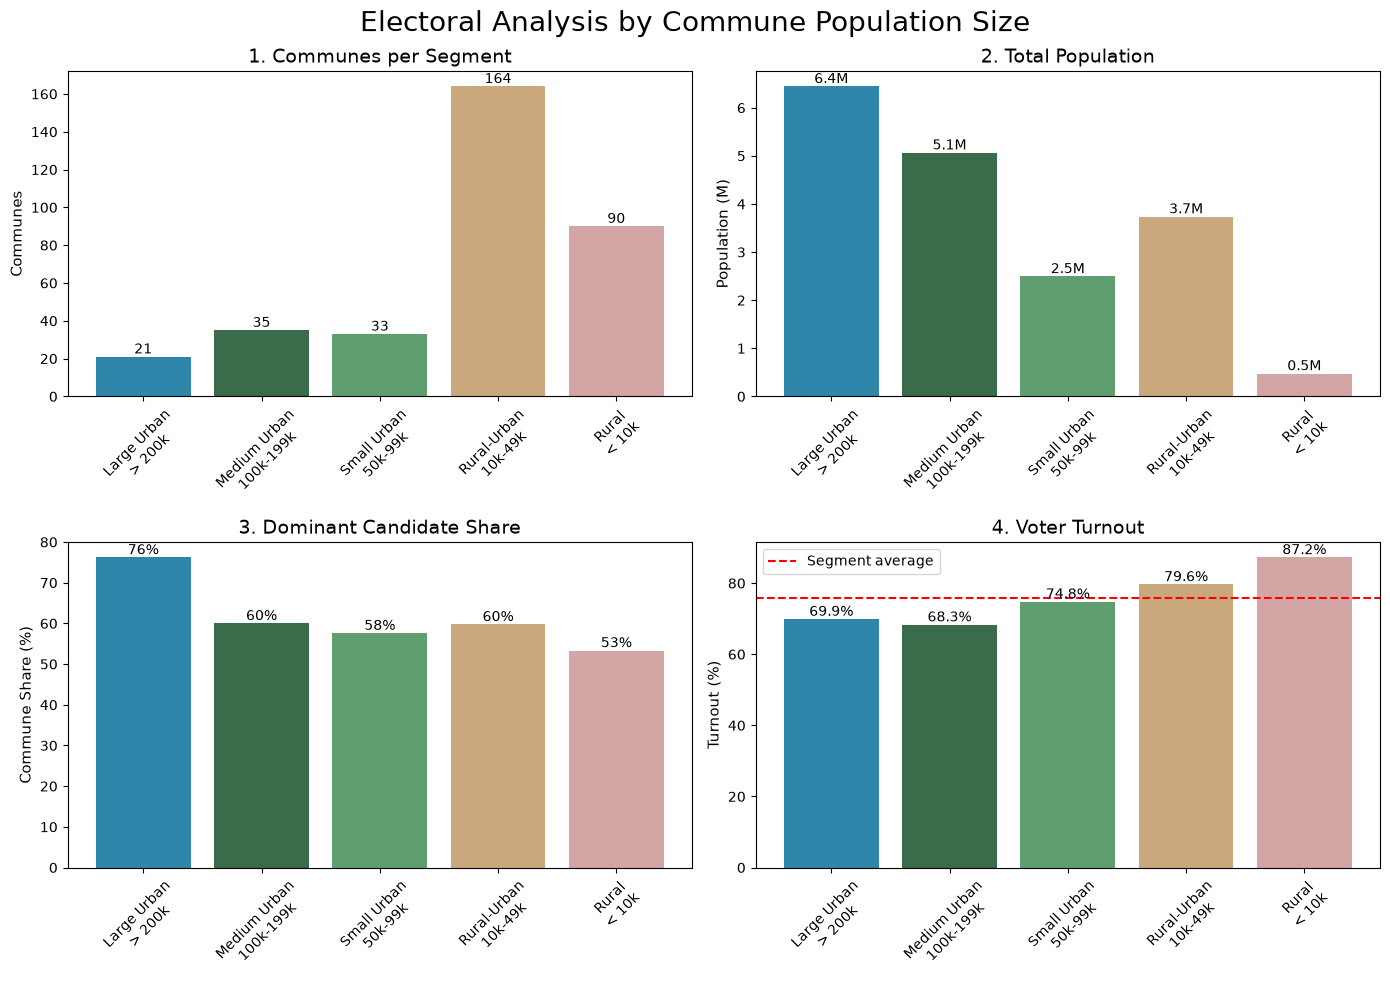

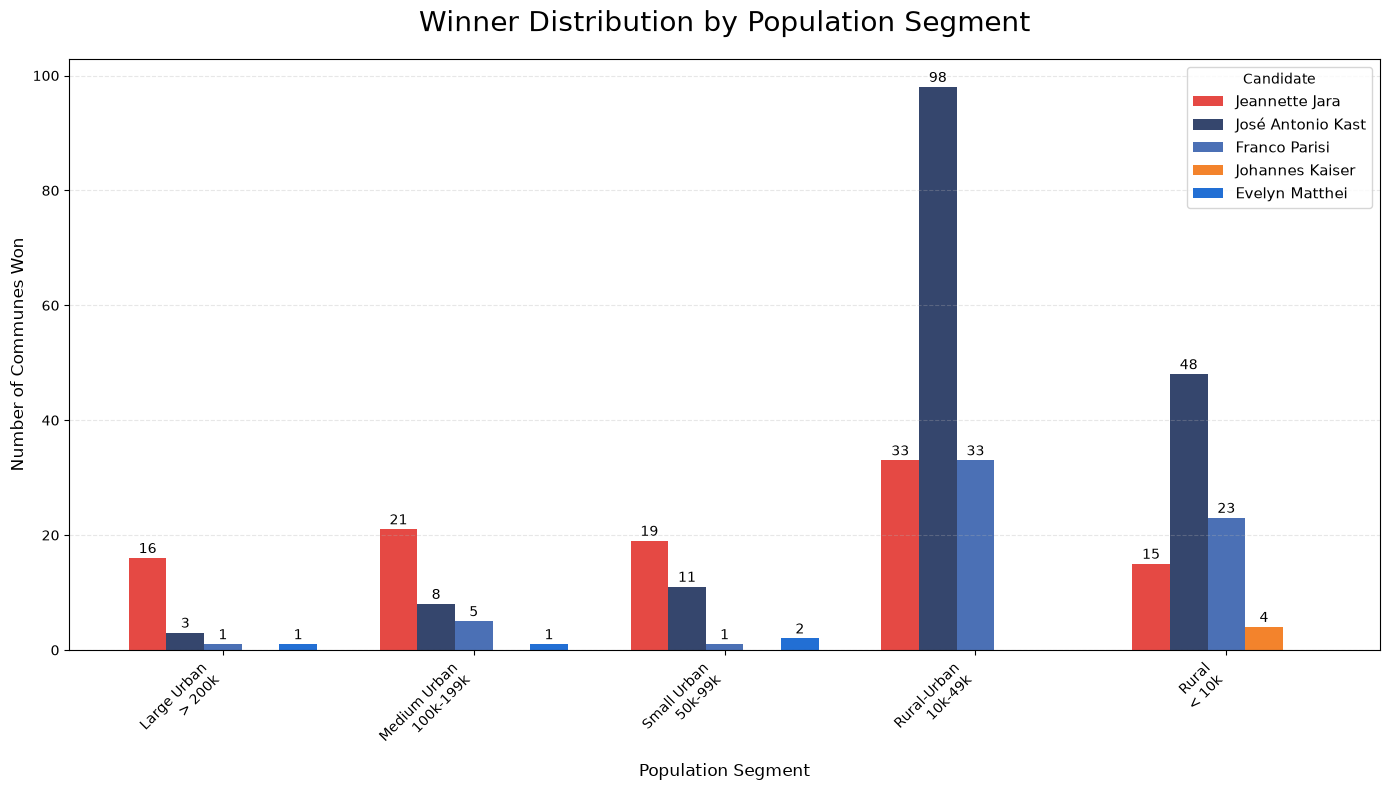

In [120]:
# ============================================================================
# POPULATION SEGMENT ANALYSIS — FIRST ROUND 2025
# ============================================================================
# Computes electoral metrics segmented by commune population size.
# Generates summary tables and visualizations for segment comparison.
# ============================================================================

# ---------------------------------------------------------------------------
# 0. DATA PREPARATION
# ---------------------------------------------------------------------------
# Converts percentage columns and population to numeric types.

votes_prep = votes_pop_prep.copy()
for col in pct_cols:
    votes_prep[col] = votes_prep[col].astype(float)
votes_prep['population'] = votes_prep['population'].astype(int)

# ---------------------------------------------------------------------------
# 1. WINNER DETERMINATION
# ---------------------------------------------------------------------------
# Assigns winner per commune based on highest vote percentage.

votes_prep['winner'] = (
    votes_prep[pct_cols]
    .idxmax(axis=1)
    .str.replace('_pct', '', regex=False)
    .map(CANDIDATE_NAMES)
)

# ---------------------------------------------------------------------------
# 2. POPULATION SEGMENT DEFINITION
# ---------------------------------------------------------------------------
# Defines population segments with thresholds and colors.

SEGMENTS = [
    {'name': 'Large Urban\n> 200k',     'min': 200_001, 'max': float('inf'), 'color': '#2E86AB'},
    {'name': 'Medium Urban\n100k-199k', 'min': 100_000, 'max': 199_999,      'color': '#3A6B4B'},
    {'name': 'Small Urban\n50k-99k',    'min':  50_000, 'max':  99_999,      'color': '#5F9E6E'},
    {'name': 'Rural-Urban\n10k-49k',    'min':  10_000, 'max':  49_999,      'color': '#C9A87C'},
    {'name': 'Rural\n< 10k',            'min':       0, 'max':   9_999,      'color': '#D4A5A5'},
]

def assign_segment(pop: int) -> str:
    """Assigns population segment based on commune size."""
    if pop > 200_000:  return 'Large Urban\n> 200k'
    if pop >= 100_000: return 'Medium Urban\n100k-199k'
    if pop >= 50_000:  return 'Small Urban\n50k-99k'
    if pop >= 10_000:  return 'Rural-Urban\n10k-49k'
    return 'Rural\n< 10k'

votes_prep['segment'] = votes_prep['population'].apply(assign_segment)

# ---------------------------------------------------------------------------
# 3. SEGMENT METRICS CALCULATION
# ---------------------------------------------------------------------------
# Computes statistics per population segment.

segment_metrics_rows = []
for seg in SEGMENTS:
    segment_prep = votes_prep[votes_prep['segment'] == seg['name']]
    n_comm = len(segment_prep)
    if n_comm == 0:
        continue
    top_winner = segment_prep['winner'].value_counts().index[0]
    top_pct = segment_prep['winner'].value_counts().iloc[0] / n_comm * 100
    segment_metrics_rows.append({
        'segment':        seg['name'],
        'total_communes': n_comm,
        'total_pop':      segment_prep['population'].sum(),
        'top_winner':     top_winner,
        'top_winner_pct': top_pct,
        'turnout':        segment_prep['casted_votes'].sum() / segment_prep['population'].sum() * 100,
    })
segment_metrics = pd.DataFrame(segment_metrics_rows)

# ---------------------------------------------------------------------------
# 4. TABLE OUTPUT — SEGMENT SUMMARY
# ---------------------------------------------------------------------------
# Displays summary table with segment metrics.

print("\n" + "=" * 80)
print('POPULATION SEGMENTATION ANALYSIS')
print("=" * 80)
display(segment_metrics.round(2))
print("\n")

# ---------------------------------------------------------------------------
# 5. VISUALIZATION — OVERVIEW METRICS PER SEGMENT (2x2 GRID)
# ---------------------------------------------------------------------------
# Generates bar charts for communes, population, dominant candidate share, and turnout.

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Electoral Analysis by Commune Population Size', fontsize=20)

seg_names = segment_metrics['segment'].tolist()
seg_colors = [s['color'] for s in SEGMENTS if s['name'] in seg_names]

def labeled_bar(ax, labels, values, ylabel, title, fmt='{:.0f}'):
    """Helper to create labeled bar charts."""
    bars = ax.bar(labels, values, color=seg_colors)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=14)
    ax.tick_params(axis='x', rotation=45)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                fmt.format(v), ha='center', va='bottom', fontsize=10)

labeled_bar(axes[0, 0], seg_names, segment_metrics['total_communes'], 'Communes', '1. Communes per Segment')
labeled_bar(axes[0, 1], seg_names, segment_metrics['total_pop'] / 1e6,  'Population (M)', '2. Total Population', fmt='{:.1f}M')
labeled_bar(axes[1, 0], seg_names, segment_metrics['top_winner_pct'],  'Commune Share (%)', '3. Dominant Candidate Share', fmt='{:.0f}%')
labeled_bar(axes[1, 1], seg_names, segment_metrics['turnout'],         'Turnout (%)', '4. Voter Turnout', fmt='{:.1f}%')

# Adds average line to turnout chart
axes[1, 1].axhline(segment_metrics['turnout'].mean(), color='red', linestyle='--', linewidth=1.5, label='Segment average')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# 6. VISUALIZATION — WINNER DISTRIBUTION BY SEGMENT (GROUPED BAR CHART)
# ---------------------------------------------------------------------------
# Displays winner distribution across population segments.

fig2, ax = plt.subplots(figsize=(14, 8))

# Defines candidates and their colors
all_winners = ['Jeannette Jara', 'José Antonio Kast', 'Franco Parisi', 'Johannes Kaiser', 'Evelyn Matthei']
winner_colors = {
    'Jeannette Jara': '#E54944',
    'José Antonio Kast': '#35466D',
    'Franco Parisi': '#4B70B5',
    'Johannes Kaiser': '#F3832C',
    'Evelyn Matthei': '#226FD4'
}

# Prepares data matrix: winners x segments
winner_counts = {}
for winner in all_winners:
    counts = []
    for seg in seg_names:
        segment_prep = votes_prep[votes_prep['segment'] == seg]
        count = len(segment_prep[segment_prep['winner'] == winner])
        counts.append(count)
    winner_counts[winner] = counts

# Sets up bar positions
x = np.arange(len(seg_names))
width = 0.15
offsets = np.linspace(-0.3, 0.3, len(all_winners))

# Creates grouped bars
for i, winner in enumerate(all_winners):
    bars = ax.bar(x + offsets[i], winner_counts[winner], width, 
                  label=winner, color=winner_colors.get(winner, '#D3D3D3'))
    
    # Adds value labels on top of bars
    for bar, val in zip(bars, winner_counts[winner]):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    str(val), ha='center', va='bottom', fontsize=10)

ax.set_xlabel('Population Segment', fontsize=12)
ax.set_ylabel('Number of Communes Won', fontsize=12)
ax.set_title('Winner Distribution by Population Segment', fontsize=20, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(seg_names, rotation=45, ha='right')
ax.legend(loc='upper right', fontsize=11, title='Candidate')
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

#### Chart Analysis

The analysis of the urban-rural gradient in the 2025 first round reveals a sharp, consistent territorial fault line running through the entire Chilean electoral map. The distribution of the 346 communes into five population segments —from major cities of over 200,000 residents to rural localities under 10,000— shows a systematic correlation between commune size and political preference, which is not a sampling artifact but a real sociological structure.

##### The General Pattern of the Gradient

| Commune Size                    | Dominant Candidate     | % Population Controlled | Central Characteristic |
| --------------------------------- | ------------------------ | -------------------------- | -------------------------- |
| Large (> 200,000 res.)            | **Jeannette Jara**       | **76.9%**                   | Dense metropolises          |
| Medium (100-199k)                 | **Jeannette Jara**       | 59.5%                       | Intermediate cities         |
| Small (50-99k)                    | **Jeannette Jara**       | 61.5%                       | Small cities                |
| Rural-Urban (10-49k)              | **José Antonio Kast**    | **57.9%**                   | Semi-rural communes         |
| Very Small / Rural (<10k)         | **José Antonio Kast**    | **~60%**                    | Deep rural Chile            |

- **Jara was the undisputed candidate of urban Chile.** Her strength in large cities let her win the first round despite far narrower territorial coverage. Of the population in the country's largest cities —more than 3.46 million people— 76.9% voted in communes that chose Jara as the top vote-getter. This concentration of votes in a few high-density territories explains the result's central paradox: fewer communes, more votes.

- **Kast was the standard-bearer of provincial, rural Chile.** His dominance grows monotonically as commune size decreases. In the Chile of under 50,000 residents —which covers most of the country's geographic territory, though not most of its population— Kast is the leading force by decisive margins. In rural localities (<10,000 residents), Kast controls roughly 60% of the segment's population, consolidating dominance that does not rest on narrow margins.

##### Territorial Distribution by Segment

- **Major Cities (>200,000 residents):** only 21 communes, but they hold most of the national population (6.4 million people). Jara wins 16 of these communes, controlling 76.9% of the segment's population. Her dominance is most solid in the Metropolitan Region and Valparaíso, where Greater Santiago's working-class communes —Puente Alto, Maipú, La Florida— give her largest relative advantage. The exception is Las Condes, where the electorate's socioeconomic profile tips the balance toward Matthei, and Antofagasta, where the Norte Grande's singularity operates according to a logic of its own that transcends demographic size.

- **Medium Cities (100,000 – 199,999 residents):** 35 communes, where Jara wins 21 (59.5% of the segment's population). Her average vote share stays solid in the Centro, especially in working-class communes of the Metropolitan Region and Valparaíso. She loses relative ground, however, in medium communes of the center-south, where Kast reappears clearly —Chillán, Curicó, Colina, Melipilla, Buin— confirming that the surrounding region can "contaminate" the urban vote with the sensibilities of adjacent territory.

- **Small Cities (50,000 – 99,999 residents):** 33 communes, where Jara wins 19 (61.5% of the segment's population), but Kast consolidates his advance with 11 communes, especially in the Centro Sur —Padre Las Casas, Villarrica, Angol— and in communes of Maule and Libertador where the semi-rural profile of the surroundings translates into greater support for the conservative candidate. The stabilization of Jara's vote share in the small segment (similar to the medium segment) suggests there is an urban floor of progressive loyalty that holds even in smaller cities.

- **Rural-Urban Centers (10,000 – 49,999 residents):** 164 communes —the largest segment— where **Kast makes a massive leap**, winning 98 communes and controlling 57.9% of the population. Jara collapses to 23.0% of population control, concentrating her wins in the Norte Chico and a few pockets of the Centro. Parisi retains a significant presence with 33 communes (19.1% of the population), mainly in the Norte Grande and Norte Chico, confirming that anti-establishment politics is competitive even in small and medium communes of the North.

- **Rural Localities (<10,000 residents):** 90 communes where **Kast consolidates as the outright winner** with 48 communes and roughly 60% of the segment's population. Parisi wins 23 communes (21.9% of the population), maintaining his monopoly in the North. Jara is reduced to 15 communes (16.1% of the population), concentrated in Patagonia and island territories, with a practically token presence in the continental rural world of the Centro Sur and Sur. Kaiser breaks through with 4 communes in Patagonia, consolidating a libertarian niche in the periphery.

##### The Inflection Point: The 50,000-Person Boundary

The demographic breaking point around **50,000 people** is one of the analysis's most precise findings. The jump between the small urban centers segment (50-99k) and the rural-urban segment (10-49k) is the sharpest in the entire gradient: Jara falls from 61.5% to 23.0% of population control, and Kast rises from 29.2% to 57.9%.

Above that threshold, Jara is the systematic leading force; below it, Kast dominates clearly. This functional boundary is not geographic but demographic and cultural: communes under 50,000 residents in the Centro Sur and Sur have economies, social networks, and cultural identities qualitatively different from the larger cities in the same region. Rural identity, the forestry and agricultural economy, and the perception of the La Araucanía conflict as a problem unresolved by progressivism form a highly favorable electoral bloc for Kast.

##### The Third Territory: Parisi and the Anti-Establishment North

Parisi represents a different case within the urban-rural gradient: his dominance in the North does not follow the pattern of size, but rather that of territory with specific characteristics (mining, border dynamics, the migration crisis). In large northern communes (Antofagasta) and in very small ones (Ollagüe, Colchane, María Elena), Parisi wins with similar intensity —between 32% and 58%— confirming that his vote responds to a thematic axis (northern discontent) rather than a demographic one.

Parisi's presence in the Centro Sur —Chimbarongo, Nogales, Hijuelas, Quellón, Mariquina, Dalcahue— confirms that anti-establishment politics is not exclusive to the North but has a presence in specific enclaves where a perceived neglect by the state and demands for order and security are particularly intense. His inability to break into established urban centers —especially outside the North— reveals a structural weakness that limits his national reach.

##### Voter Turnout: The Rural Paradox

Voter turnout shows an **inverse correlation** with commune size. Rural localities (<10,000 residents) had the highest turnout (87.2%), well above the general average (75%), while major cities (>200,000 residents) had the lowest turnout (69.9%).

This finding matters for several reasons. First, it suggests that in rural areas —where voting tends to be more influenced by community and local networks— turnout was notably higher than in major cities, possibly due to more effective territorial mobilization campaigns or denser community social networks. Second, higher rural turnout favors Kast, whose support is concentrated precisely in those territories, while lower turnout in major cities —where Jara is strongest— limits her growth potential in the segment where she is most competitive.

##### The Distribution of Secondary Candidates

- **Evelyn Matthei** has a token presence in the gradient analysis. She wins only 4 communes in the major-cities segment (Las Condes) and 2 in the small segment (La Reina and Vitacura), confirming that her support is confined to high-income enclaves in the Metropolitan Region. Her absence from the rural world is total, reflecting Chile Vamos's territorial collapse.

- **Johannes Kaiser** has a marginal but significant presence in the rural segments. He wins 4 communes in Patagonia —Futaleufú, Palena, Cisnes, and San Gregorio— confirming that his electorate is concentrated in the country's periphery, where libertarian rhetoric rejecting the state and hardline positions on migration find a particular echo. His better relative performance in regional capitals (~15.4%) suggests his electorate is more urban than Kast's, though his territorial base remains limited.

#### Outlining the Runoff

The urban-rural gradient outlines some of the central axes of the runoff. Jara faces a structural challenge: her support is concentrated in major cities, where turnout is lower, and fades in the rural world, where turnout is higher. Kast, by contrast, has a solid territorial base in rural and semi-rural Chile, where turnout is higher, and his performance in major cities, though weaker, is enough to remain competitive.

In the transition-zone communes —the swing regions where neither finalist has guaranteed dominance— the direction the Parisi, Kaiser, and Matthei vote ultimately takes is more uncertain and could prove especially decisive. Jara's ability to mobilize the urban vote without losing control of the regional capitals, and Kast's ability to consolidate his rural dominance without letting the cities slip away, stand out as among the most relevant factors for the final result.


### Conclusion 10.6.


The analysis of the urban-rural gradient confirms that Chile's territorial fault line is not a simple geographic division, but a deep sociological structure running through the entire electoral map. Jara capitalizes on the vote in major urban centers and medium cities, where the largest absolute population is concentrated, winning in total vote volume but with a limited territorial base. Kast dominates overwhelmingly in rural-urban centers and rural localities, where the largest number of communes and the highest voter turnout are concentrated, consolidating a territorial foothold in the Chile farthest from the major metropolises. Parisi acts as a "brake" in the rural and semi-rural segments of the North, taking communes from both Kast and Jara, but without managing to break into established urban centers. The breaking point around 50,000 people defines the boundary between urban and rural Chile in electoral terms, a boundary that neither runoff candidate can afford to ignore. How well Jara manages to mobilize the urban vote without losing control of the regional capitals, and Kast consolidates his rural dominance without letting the cities slip away, stands out as one of the most relevant factors for the final result.


### 10.7. National Map of Winners by Commune


/tmp/ipykernel_359531/2678520782.py:193: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 1, 0.94])


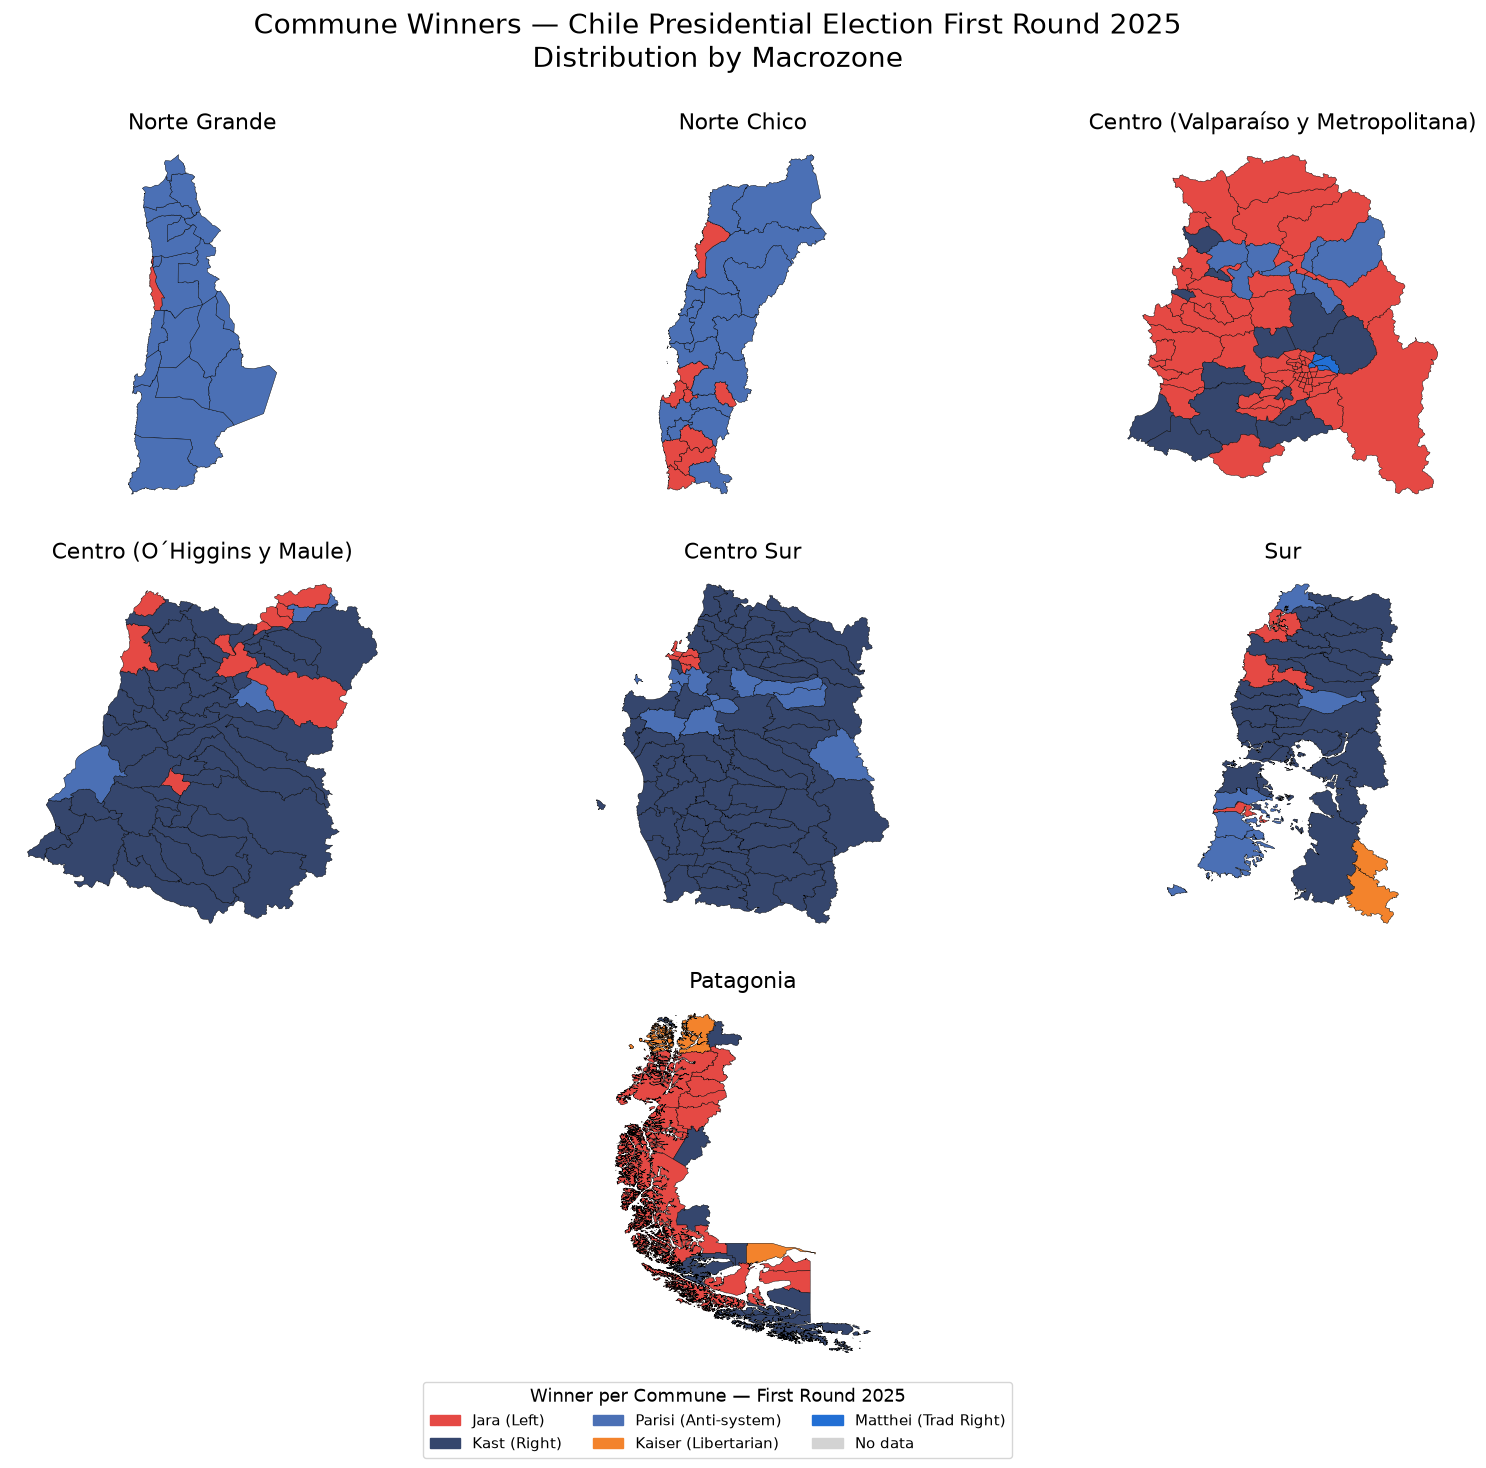

In [121]:
# ============================================================================
# COMMUNE-LEVEL WINNER MAP — FIRST ROUND 2025
# ============================================================================
# Generates a 3x3 grid map of commune-level winners by macrozone for the
# 2025 Chilean presidential election first round.
# ============================================================================

# ---------------------------------------------------------------------------
# 0. DATA PREPARATION
# ---------------------------------------------------------------------------
# Define candidate color palette and winner mapping dictionaries.

CANDIDATE_COLORS = {
    'Jara (Left)':              '#E54944',
    'Kast (Right)':             '#35466D',
    'Parisi (Anti-system)':     '#4B70B5',
    'Kaiser (Libertarian)':     '#F3832C',
    'Matthei (Trad Right)':     '#226FD4',
    'Mayne-Nicholls (Indep)':   '#BED8DF',
    'Enriquez-Ominami (Left)':  '#DD2883',
    'Artes (Far Left)':         '#CA1C1F',
    'No data':                  '#D3D3D3',
}

WINNER_MAP_2025 = {
    'jara':    'Jara (Left)',
    'kast':    'Kast (Right)',
    'parisi':  'Parisi (Anti-system)',
    'kaiser':  'Kaiser (Libertarian)',
    'matthei': 'Matthei (Trad Right)',
    'mayne_nicholls':   'Mayne-Nicholls (Indep)',
    'enriquez_ominami': 'Enriquez-Ominami (Left)',
    'artes':   'Artes (Far Left)',
}

def assign_winner_color(row):
    """Return the hex color associated with the 2025 commune winner."""
    winner = row.get('winner_2025')
    if pd.isna(winner):
        return CANDIDATE_COLORS['No data']
    return CANDIDATE_COLORS.get(winner, CANDIDATE_COLORS['No data'])

# ---------------------------------------------------------------------------
# 1. METRIC CALCULATION — WINNER PER COMMUNE
# ---------------------------------------------------------------------------
# Extract winner from raw vote share columns.

pct_cols_all = [
    'jara_pct', 'kast_pct', 'parisi_pct', 'kaiser_pct',
    'matthei_pct', 'mayne_nicholls_pct', 'enriquez_ominami_pct', 'artes_pct',
]

df_votes_map = df_votes.copy()
for col in pct_cols_all:
    df_votes_map[col] = pd.to_numeric(df_votes_map[col], errors='coerce').fillna(0)

df_votes_map['winner_2025_key'] = df_votes_map[pct_cols_all].idxmax(axis=1).str.replace('_pct', '', regex=False)
df_votes_map['winner_2025'] = df_votes_map['winner_2025_key'].map(WINNER_MAP_2025)

# ---------------------------------------------------------------------------
# 2. DATA PREPARATION — SPATIAL JOIN
# ---------------------------------------------------------------------------
# Normalize commune names for merging with geometry data.

communes_map = communes.copy()
communes_map['NOM_COM_NORM'] = communes_map['NOM_COM'].apply(normalize_commune_name)
df_votes_map['commune_norm']  = df_votes_map['commune'].apply(normalize_commune_name)

# Merge geometries with winner data.
map_data = communes_map.merge(
    df_votes_map[['commune_norm', 'winner_2025']],
    left_on='NOM_COM_NORM',
    right_on='commune_norm',
    how='left',
)

map_data['color'] = map_data.apply(assign_winner_color, axis=1).fillna(CANDIDATE_COLORS['No data'])

# Exclude island communes (unreachable territory distorts layout).
map_data = map_data[~map_data['NOM_COM'].str.contains('Isla de Pascua|Juan Fernández', case=False, na=False)]

unmatched = map_data[map_data['winner_2025'].isna()]['NOM_COM'].tolist()
if unmatched:
    print(f"Communes with no match ({len(unmatched)}): {unmatched[:10]}")

# ---------------------------------------------------------------------------
# 3. DATA PREPARATION — MACROZONE ASSIGNMENT
# ---------------------------------------------------------------------------
# Assign each commune to one of 7 macrozones based on region number.

MACROZONE_MAP = {
    15: 'Norte Grande',
    1:  'Norte Grande',
    2:  'Norte Grande',
    3:  'Norte Chico',
    4:  'Norte Chico',
    5:  'Centro (Valparaíso y Metropolitana)',
    13: 'Centro (Valparaíso y Metropolitana)',
    6:  'Centro (O\u00b4Higgins y Maule)',
    7:  'Centro (O\u00b4Higgins y Maule)',
    16: 'Centro Sur',
    8:  'Centro Sur',
    9:  'Centro Sur',
    14: 'Sur',
    10: 'Sur',
    11: 'Patagonia',
    12: 'Patagonia',
}

map_data['macrozone'] = map_data['REGION_NUM'].map(MACROZONE_MAP)

# ---------------------------------------------------------------------------
# 4. VISUALIZATION — 3x3 GRID LAYOUT
# ---------------------------------------------------------------------------
# Create figure with 3x3 grid for macrozone maps.

fig = plt.figure(figsize=(20, 16))
gs  = GridSpec(3, 3, figure=fig, hspace=0.15, wspace=0.15)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[1, 2])
ax7 = fig.add_subplot(gs[2, 1])

zone_axes = [
    (ax1, 'Norte Grande'),
    (ax2, 'Norte Chico'),
    (ax3, 'Centro (Valparaíso y Metropolitana)'),
    (ax4, 'Centro (O\u00b4Higgins y Maule)'),
    (ax5, 'Centro Sur'),
    (ax6, 'Sur'),
    (ax7, 'Patagonia'),
]

for ax, macro in zone_axes:
    macro_data = map_data[map_data['macrozone'] == macro].copy()
    if macro_data.empty:
        ax.text(0.5, 0.5, f'No data\n{macro}', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(macro, fontsize=14)
        ax.set_axis_off()
        continue

    macro_data.plot(ax=ax, color=macro_data['color'], edgecolor='black', linewidth=0.3)
    ax.set_title(macro, fontsize=16)
    ax.set_axis_off()
    ax.set_aspect('equal')

    if macro == 'Patagonia':
        bounds   = macro_data.total_bounds
        margin_x = (bounds[2] - bounds[0]) * 0.05
        margin_y = (bounds[3] - bounds[1]) * 0.05
        ax.set_xlim(bounds[0] - margin_x, bounds[2] + margin_x)
        ax.set_ylim(bounds[1] - margin_y, bounds[3] + margin_y)

# Hide unused grid cells.
ax_empty1 = fig.add_subplot(gs[2, 0])
ax_empty2 = fig.add_subplot(gs[2, 2])
ax_empty1.set_visible(False)
ax_empty2.set_visible(False)

fig.suptitle(
    'Commune Winners — Chile Presidential Election First Round 2025\nDistribution by Macrozone',
    fontsize=20, y=0.96,
)

# ---------------------------------------------------------------------------
# 5. VISUALIZATION — LEGEND
# ---------------------------------------------------------------------------
# Display legend only for candidates with at least one commune win.

present_winners = map_data['winner_2025'].dropna().unique()
legend_entries  = [
    (label, CANDIDATE_COLORS[label])
    for label in [
        'Jara (Left)', 'Kast (Right)', 'Parisi (Anti-system)',
        'Kaiser (Libertarian)', 'Matthei (Trad Right)',
    ]
    if label in present_winners
]
legend_entries.append(('No data', CANDIDATE_COLORS['No data']))

legend_handles = [mpatches.Patch(color=color, label=label) for label, color in legend_entries]

fig.legend(
    handles=legend_handles, loc='lower center', ncol=3, fontsize=11,
    title='Winner per Commune — First Round 2025', title_fontsize=13,
    bbox_to_anchor=(0.5, 0.05),
)

plt.tight_layout(rect=[0, 0.05, 1, 0.94])
plt.show()

### 10.8. Metropolitan Areas and Conurbations


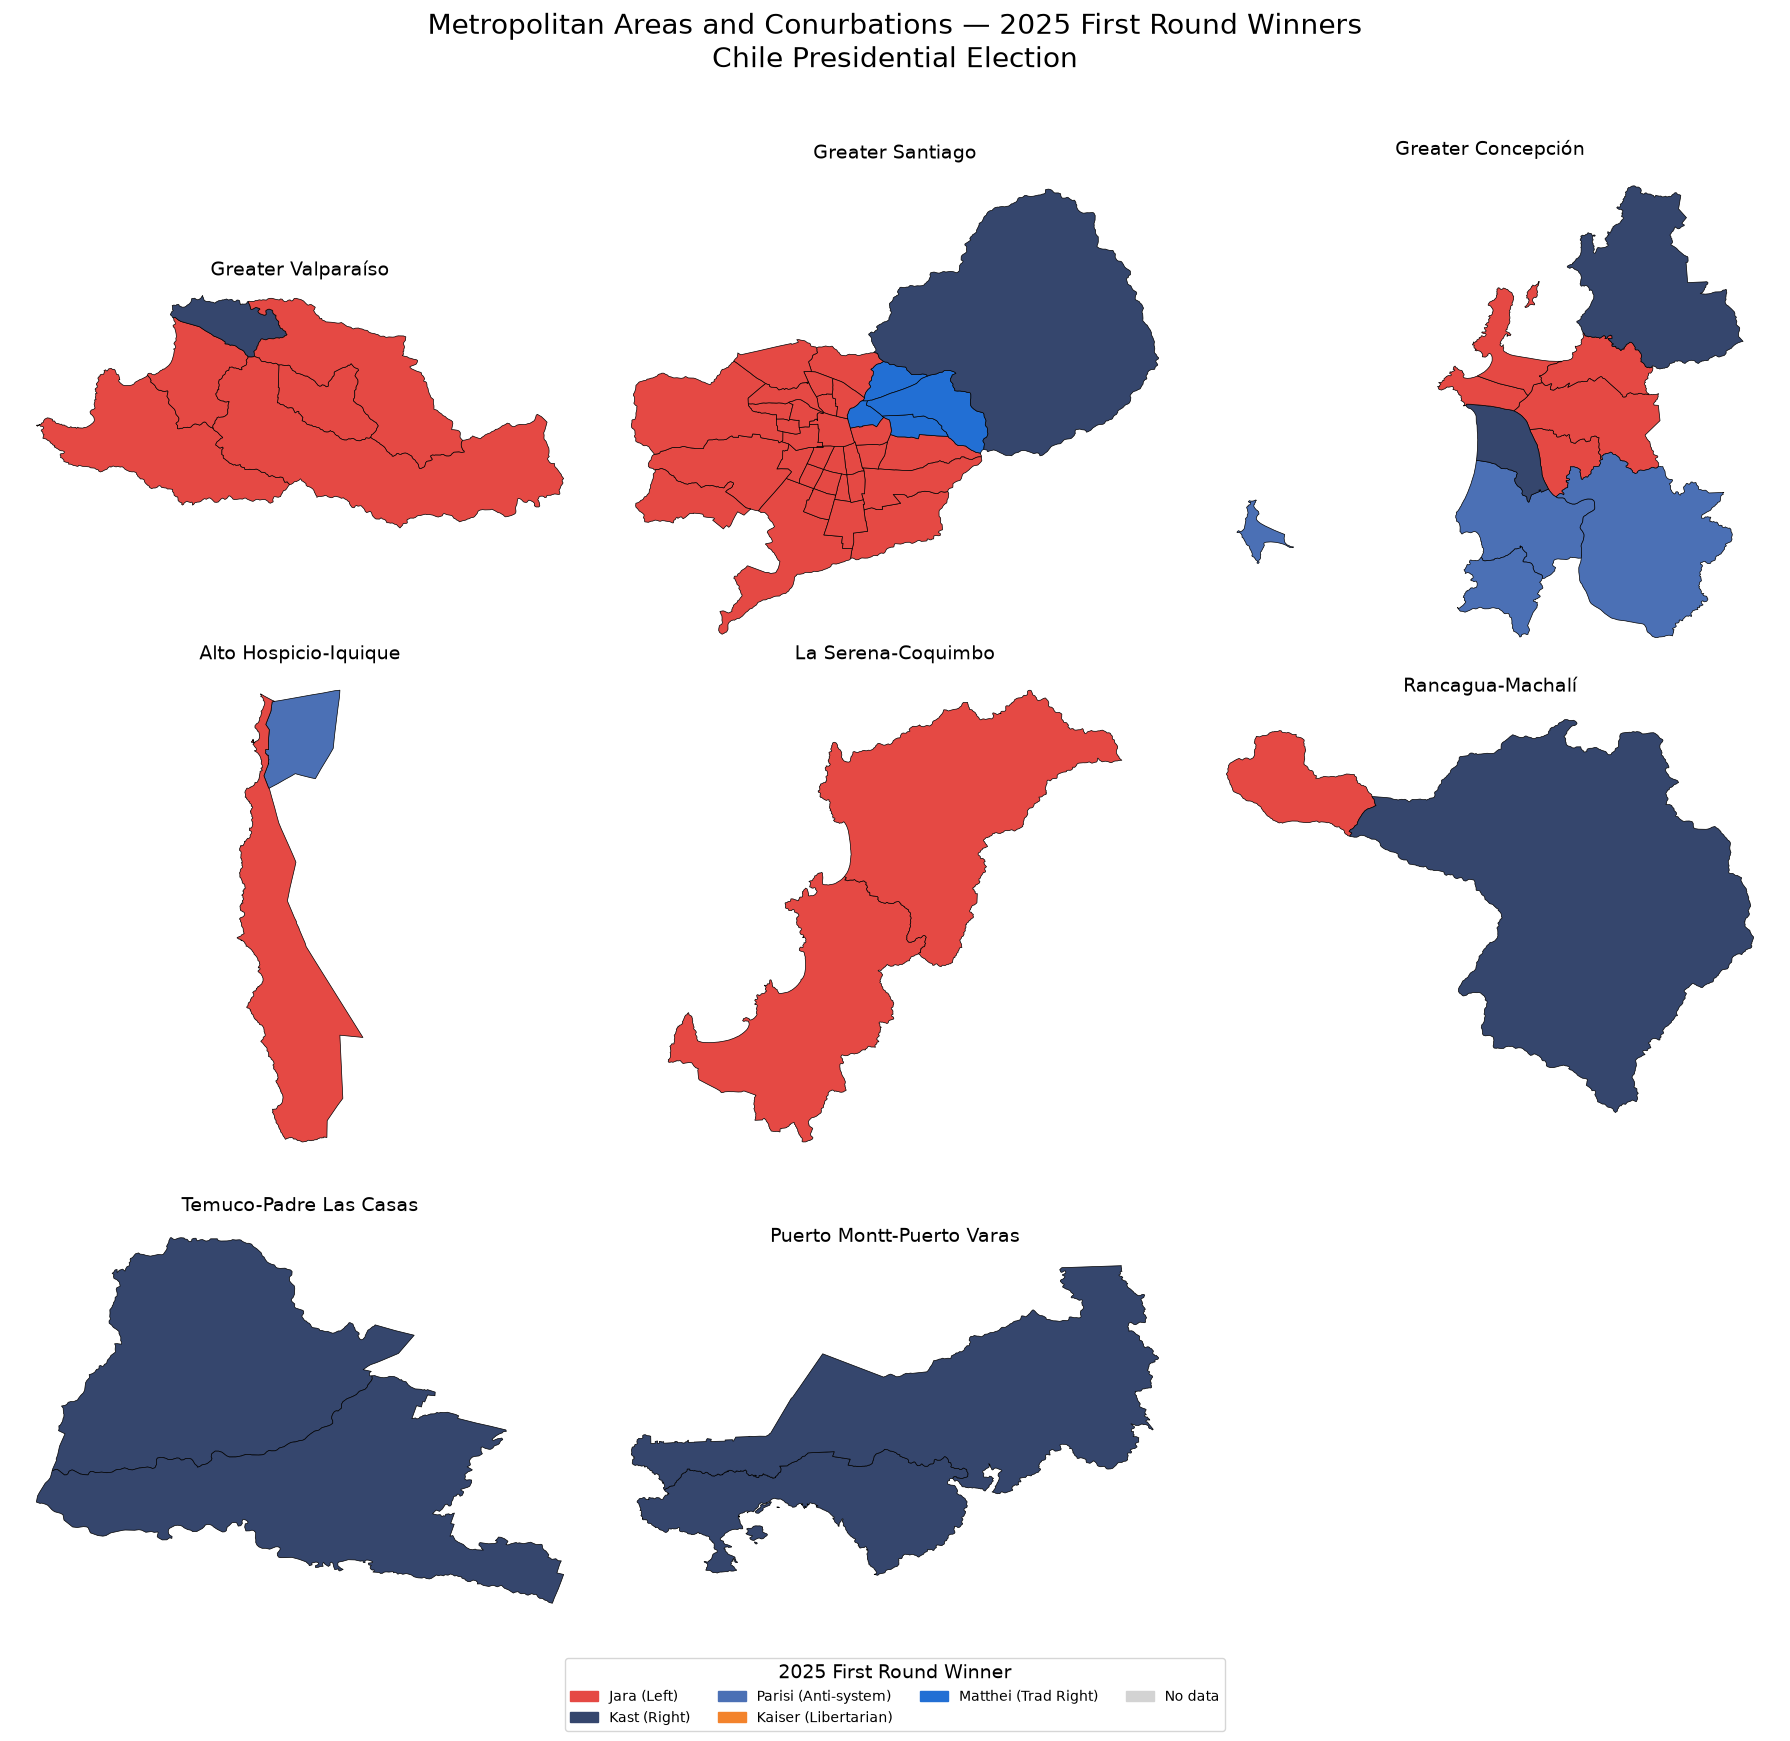

In [122]:
# ============================================================================
# METROPOLITAN AREAS AND CONURBATIONS — FIRST ROUND 2025 WINNERS
# ============================================================================
# Defines urban agglomerations and renders a 3x3 facet grid showing the
# winner of the 2025 first round in each metropolitan area.
# ============================================================================

# ---------------------------------------------------------------------------
# 1. URBAN AGGLOMERATION DEFINITIONS
# ---------------------------------------------------------------------------
# Raw display names (accents preserved) — matching is done via normalized
# keys to avoid encoding divergence with the GeoJSON source.
# ---------------------------------------------------------------------------

# Primary metropolitan areas (by population)
GREATER_SANTIAGO = [
    "Cerrillos", "Cerro Navia", "Conchalí", "El Bosque", "Estación Central",
    "Huechuraba", "Independencia", "La Cisterna", "La Florida", "La Granja",
    "Providencia", "Las Condes", "La Reina", "Lo Espejo", "Lo Prado", "Macul",
    "Maipú", "Ñuñoa", "Padre Hurtado", "Pedro Aguirre Cerda", "Peñalolén",
    "Vitacura", "Pudahuel", "Puente Alto", "Quilicura", "Quinta Normal",
    "Recoleta", "Renca", "San Bernardo", "San Joaquín", "San Miguel",
    "San Ramón", "Santiago", "Lo Barnechea", "La Pintana",
]

GREATER_VALPARAISO = [
    "Valparaíso", "Viña del Mar", "Concón", "Quilpué", "Villa Alemana", "Limache",
]

GREATER_CONCEPCION = [
    "Concepción", "Coronel", "Chiguayante", "Hualpén", "Hualqui", "Lota",
    "Penco", "San Pedro de la Paz", "Talcahuano", "Tomé",
]

# Secondary conurbations (north to south)
ALTO_HOSPICIO_IQUIQUE  = ["Alto Hospicio", "Iquique"]
LA_SERENA_COQUIMBO     = ["La Serena", "Coquimbo"]
RANCAGUA_MACHALI       = ["Rancagua", "Machalí"]
TEMUCO_METRO           = ["Temuco", "Padre Las Casas"]
PUERTO_MONTT_VARAS     = ["Puerto Montt", "Puerto Varas"]

# ---------------------------------------------------------------------------
# 2. GRID LAYOUT CONFIGURATION
# ---------------------------------------------------------------------------
# Tuple order: (grid_position, commune_list, display_title)
# ---------------------------------------------------------------------------
FACET_CONFIG = [
    # Row 0 — primary metropolitan areas
    ((0, 0), GREATER_VALPARAISO, 'Greater Valparaíso'),
    ((0, 1), GREATER_SANTIAGO,   'Greater Santiago'),
    ((0, 2), GREATER_CONCEPCION, 'Greater Concepción'),
    # Row 1 — northern and central conurbations
    ((1, 0), ALTO_HOSPICIO_IQUIQUE, 'Alto Hospicio-Iquique'),
    ((1, 1), LA_SERENA_COQUIMBO,    'La Serena-Coquimbo'),
    ((1, 2), RANCAGUA_MACHALI,      'Rancagua-Machalí'),
    # Row 2 — southern conurbations; cell (2,2) intentionally empty
    ((2, 0), TEMUCO_METRO,      'Temuco-Padre Las Casas'),
    ((2, 1), PUERTO_MONTT_VARAS, 'Puerto Montt-Puerto Varas'),
]

# Pre-compute normalized key sets for each area to avoid per-row normalization
# inside the render loop; NOM_COM_NORM already exists on map_data from cell #88.
area_norm_keys = {
    title: {normalize_commune_name(c) for c in commune_list}
    for _, commune_list, title in FACET_CONFIG
}

# ---------------------------------------------------------------------------
# 3. RENDER 3×3 FACET GRID
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(3, 3, figsize=(18, 18))
fig.suptitle(
    'Metropolitan Areas and Conurbations — 2025 First Round Winners\n'
    'Chile Presidential Election',
    fontsize=20, y=0.98,
)

for (row, col), commune_list, title in FACET_CONFIG:
    ax       = axes[row, col]
    norm_set = area_norm_keys[title]

    # Filter via normalized key (encoding-safe, consistent with the spatial join)
    area_data = map_data[map_data['NOM_COM_NORM'].isin(norm_set)].copy()

    if area_data.empty:
        ax.text(0.5, 0.5, f'No data\n{title}',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title, fontsize=14)
        ax.set_axis_off()
        continue

    # winner_2025 already mapped to display labels in cell #88;
    # re-map to color using the same palette defined there.
    area_data['color'] = area_data['winner_2025'].map(CANDIDATE_COLORS).fillna(CANDIDATE_COLORS['No data'])

    area_data.plot(ax=ax, color=area_data['color'], edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontsize=14)
    ax.set_axis_off()
    ax.set_aspect('equal')

# Hide the unused bottom-right cell
axes[2, 2].set_visible(False)

# ---------------------------------------------------------------------------
# 4. SHARED LEGEND
# ---------------------------------------------------------------------------
present_candidates = map_data['winner_2025'].dropna().unique()

legend_entries = [
    (label, CANDIDATE_COLORS[label])
    for label in [
        'Jara (Left)', 'Kast (Right)', 'Parisi (Anti-system)',
        'Kaiser (Libertarian)', 'Matthei (Trad Right)',
    ]
    if label in present_candidates
]
legend_entries.append(('No data', CANDIDATE_COLORS['No data']))

legend_handles = [mpatches.Patch(color=color, label=label) for label, color in legend_entries]

fig.legend(
    handles=legend_handles, loc='lower center', ncol=4, fontsize=10,
    title='2025 First Round Winner', title_fontsize=14,
    bbox_to_anchor=(0.5, 0.02),
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

### Conclusion to Chapter 10: Electoral Behavior in Urban Centers


The analysis of the urban-rural gradient confirms that Chile's territorial fault line is not a simple geographic division, but a deep sociological structure running through the entire electoral map. Jara is the undisputed candidate of urban Chile: she controls 76.9% of the population in major cities (>200,000 residents) and retains her lead in medium (59.5%) and small (61.5%) urban centers, but her presence collapses in rural-urban centers (23.0%) and rural localities (~16%). Kast, by contrast, is the standard-bearer of provincial, rural Chile: his dominance grows monotonically as commune size decreases, from 29.2% in small urban centers to 57.9% in rural-urban centers and 60% in rural localities. Parisi represents a different case: his dominance in the North does not follow the pattern of size, but rather that of territory with specific characteristics (mining, border dynamics, the migration crisis), acting as a "brake" that takes communes from both Kast and Jara in the North's rural and semi-rural segments.

The inflection point around 50,000 people is one of the analysis's most precise findings. Above that threshold, Jara is the systematic leading force; below it, Kast dominates clearly. This functional boundary reflects deep differences in economic type, relationship with the state, and the electorate's priority demands depending on its territorial position: communes under 50,000 residents in the Centro Sur and Sur have economies, social networks, and cultural identities qualitatively different from the larger cities in the same region. Voter turnout, moreover, shows an inverse correlation with commune size: rural localities had the highest turnout (87.2%) and major cities the lowest (69.9%), a demographic pattern that favors Kast, whose support is concentrated in the territories with higher turnout.

Ultimately, the urban-rural gradient outlines one of the central axes of the runoff. Jara faces a structural challenge: her support is concentrated in major cities, where turnout is lower, and fades in the rural world, where turnout is higher. Kast, by contrast, has a solid territorial base in rural and semi-rural Chile, where turnout is higher, and his performance in major cities, though weaker, is enough to keep him competitive. How each candidacy resolves its own challenge —Jara, mobilizing the urban vote without losing control of the regional capitals; Kast, consolidating his rural dominance without letting the cities slip away— stands out as one of the most relevant factors for the final result. Beyond the runoff, this fault line between urban and rural Chile is the main governability challenge facing the next government, which will be called upon to represent an electorate deeply fragmented across the territory.


---

## 11. Recoverable Communes (Margin < 1,000 Votes)


### Introduction


The previous chapters described where and why each candidate's vote landed as it did. This chapter shifts the question: given November's result, how much additional effort would each candidate have needed to flip a given commune? The exercise —identifying communes lost by margins under 1,000 votes— functions as a measure of territorial elasticity: it reveals where the result was effectively a technical tie and, by extension, where the terrain is most sensitive to mobilization. The analysis of Jara's recoverable communes (11.1), Kast's (11.2), and the mobilization effort by macrozone (11.3) makes it possible to size up the structural asymmetry in each candidate's room for territorial growth.


### 11.1 Jeannette Jara — The 81 Recoverable Communes


Jeannette Jara lost by fewer than 1,000 votes in **81 communes**, a total of **33,999 votes** separating her campaign from a considerably broader territorial map. These communes are not located in the major cities —where she won comfortably— but in **intermediate Chile**: medium and small localities where the urban-rural gradient described in the previous chapter works against her. This distribution reveals that Jara's structural weakness lies not in consolidating her urban dominance, but in expanding into the territories where José Antonio Kast built his hegemony.


In [123]:
# ============================================================================
# JEANNETTE JARA RECOVERABLE COMMUNES — FIRST ROUND 2025
# ============================================================================
# Identifies communes where Jeannette Jara lost by a margin < 1,000 votes,
# calculates the votes needed to reverse the result, and displays results
# grouped by macrozone.
# ============================================================================

# ---------------------------------------------------------------------------
# 0. DATA PREPARATION
# ---------------------------------------------------------------------------
# Configures display options for full table visibility and creates a working
# copy. Defines macrozone mapping and north-to-south order.

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

votes_prep = df_votes.copy()

# Builds region-to-macrozone lookup and ordering
macrozone_map   = dict(zip(df_region_dim['region'], df_region_dim['macrozone']))
macrozone_order = (
    df_region_dim[['macrozone', 'macrozone_order']]
    .drop_duplicates().sort_values('macrozone_order')['macrozone'].tolist()
)

# ---------------------------------------------------------------------------
# 1. METRIC CALCULATION
# ---------------------------------------------------------------------------
# Derives absolute vote counts from percentages and computes vote differences.

votes_prep['valid_votes']     = votes_prep['casted_votes'] - votes_prep['blank_votes'] - votes_prep['null_votes']
votes_prep['jara_abs_votes']  = (votes_prep['jara_pct']  / 100) * votes_prep['valid_votes']
votes_prep['kast_abs_votes']  = (votes_prep['kast_pct']  / 100) * votes_prep['valid_votes']
votes_prep['vote_difference'] = np.abs(votes_prep['jara_abs_votes'] - votes_prep['kast_abs_votes'])

# ---------------------------------------------------------------------------
# 2. FILTERING — CLOSE COMMUNES
# ---------------------------------------------------------------------------
# Filters communes where the vote difference is less than 1,000 votes and
# determines winner/loser.

close_communes_prep = votes_prep[votes_prep['vote_difference'] < 1000].copy()
close_communes_prep['winner'] = np.where(
    close_communes_prep['jara_abs_votes'] > close_communes_prep['kast_abs_votes'],
    'Jeannette Jara', 'José Antonio Kast'
)
close_communes_prep['loser'] = np.where(
    close_communes_prep['winner'] == 'Jeannette Jara',
    'José Antonio Kast', 'Jeannette Jara'
)
close_communes_prep['votes_needed'] = close_communes_prep['vote_difference']

# ---------------------------------------------------------------------------
# 3. FILTERING — JARA AS LOSER
# ---------------------------------------------------------------------------
# Keeps only communes where Jeannette Jara is the losing candidate.

jara_losing_prep = close_communes_prep[close_communes_prep['loser'] == 'Jeannette Jara'].copy()
jara_losing_prep['macrozone'] = jara_losing_prep['region'].map(macrozone_map)

# ---------------------------------------------------------------------------
# 4. SUMMARY OUTPUT
# ---------------------------------------------------------------------------
# Computes and displays summary statistics for recoverable communes.

total_votes = int(jara_losing_prep['votes_needed'].sum())
difficulty = (
    'Minor challenge'       if total_votes < 5_000  else
    'Moderate challenge'    if total_votes < 20_000 else
    'Significant challenge'
)

print("\n" + "=" * 80)
print('RECOVERABLE COMMUNES FOR JEANNETTE JARA (MARGIN < 1,000 VOTES)')
print('='*80)
print(f'Recoverable communes: {len(jara_losing_prep)}')
print(f'Total votes needed:   {total_votes:,}')
print(f'Avg votes needed:      {jara_losing_prep["votes_needed"].mean():.0f}')
print(f'Difficulty level:      {difficulty}')

# ---------------------------------------------------------------------------
# 5. DETAILED TABLE — BY MACROZONE
# ---------------------------------------------------------------------------
# Displays recoverable communes grouped by macrozone from north to south.

detail_cols = ['commune', 'region', 'macrozone',
               'jara_abs_votes', 'kast_abs_votes', 'vote_difference', 'votes_needed']

for zone in macrozone_order:
    zone_display = jara_losing_prep[jara_losing_prep['macrozone'] == zone]
    if len(zone_display) > 0:
        print("\n" + "-" * 80)
        print(f'{zone.upper()} ({len(zone_display)} communes)')
        print('-'*80)
        zone_display_formatted = zone_display[detail_cols].copy()
        for col in ['jara_abs_votes','kast_abs_votes','vote_difference','votes_needed']:
            zone_display_formatted[col] = zone_display_formatted[col].round(0).astype(int)
        display(zone_display_formatted)

# ---------------------------------------------------------------------------
# 6. RESET DISPLAY OPTIONS
# ---------------------------------------------------------------------------
# Restores default display settings.

pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')
pd.reset_option('display.width')
pd.reset_option('display.max_colwidth')


RECOVERABLE COMMUNES FOR JEANNETTE JARA (MARGIN < 1,000 VOTES)
Recoverable communes: 81
Total votes needed:   33,999
Avg votes needed:      420
Difficulty level:      Significant challenge

--------------------------------------------------------------------------------
NORTE GRANDE (9 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,jara_abs_votes,kast_abs_votes,vote_difference,votes_needed
1,Calama,Antofagasta,Norte Grande,19492,20107,615,615
4,Ollague,Antofagasta,Norte Grande,90,117,27,27
10,Camarones,Arica y Parinacota,Norte Grande,281,310,29,29
11,General Lagos,Arica y Parinacota,Norte Grande,47,177,130,130
12,Putre,Arica y Parinacota,Norte Grande,332,591,259,259
281,Camiña,Tarapacá,Norte Grande,122,608,486,486
282,Colchane,Tarapacá,Norte Grande,25,387,362,362
283,Huara,Tarapacá,Norte Grande,447,685,238,238
286,Pozo Almonte,Tarapacá,Norte Grande,1744,1962,218,218



--------------------------------------------------------------------------------
NORTE CHICO (1 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,jara_abs_votes,kast_abs_votes,vote_difference,votes_needed
74,Rio Hurtado,Coquimbo,Norte Chico,736,988,252,252



--------------------------------------------------------------------------------
CENTRO (30 communes)
--------------------------------------------------------------------------------


...

,commune,region,macrozone,jara_abs_votes,kast_abs_votes,vote_difference,votes_needed
32,Alto Biobio,Biobío,Centro Sur,746,1303,557,557
33,Antuco,Biobío,Centro Sur,743,1070,327,327
40,Coronel,Biobío,Centro Sur,19129,19862,733,733
52,Quilaco,Biobío,Centro Sur,747,1192,445,445
60,Tome,Biobío,Centro Sur,10950,11240,291,291
87,Ercilla,La Araucanía,Centro Sur,1607,2326,719,719
95,Melipeuco,La Araucanía,Centro Sur,1070,2003,933,933
98,Perquenco,La Araucanía,Centro Sur,1147,2033,886,886
100,Pucon,La Araucanía,Centro Sur,5779,6589,810,810
328,Cobquecura,Ñuble,Centro Sur,978,1810,832,832



--------------------------------------------------------------------------------
SUR (16 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,jara_abs_votes,kast_abs_votes,vote_difference,votes_needed
148,Chaiten,Los Lagos,Sur,770,864,94,94
149,Chonchi,Los Lagos,Sur,2786,2851,66,66
150,Cochamo,Los Lagos,Sur,589,1212,623,623
151,Curaco de Velez,Los Lagos,Sur,650,840,190,190
153,Fresia,Los Lagos,Sur,2184,3162,978,978
155,Futaleufu,Los Lagos,Sur,475,529,54,54
156,Hualaihue,Los Lagos,Sur,1509,2196,687,687
157,Llanquihue,Los Lagos,Sur,3078,3878,800,800
164,Puqueldon,Los Lagos,Sur,720,804,84,84
166,Puyehue,Los Lagos,Sur,2195,3032,837,837



--------------------------------------------------------------------------------
PATAGONIA (10 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,jara_abs_votes,kast_abs_votes,vote_difference,votes_needed
24,Cisnes,Aysén,Patagonia,860,885,25,25
27,Guaitecas,Aysén,Patagonia,243,338,95,95
28,Lago Verde,Aysén,Patagonia,191,205,14,14
29,O'higgins,Aysén,Patagonia,110,141,31,31
187,Antartica,Magallanes,Patagonia,7,35,28,28
188,Cabo de Hornos(ex-navarino),Magallanes,Patagonia,233,384,151,151
189,Laguna Blanca,Magallanes,Patagonia,122,130,8,8
194,Rio Verde,Magallanes,Patagonia,78,149,71,71
196,Timaukel,Magallanes,Patagonia,34,93,59,59
197,Torres del Paine,Magallanes,Patagonia,225,250,25,25


#### Analysis

#### Territorial Distribution by Macrozone

**Norte Grande (9 communes):** Calama, Ollagüe, Camarones, General Lagos, Putre, Camiña, Colchane, Huara, and Pozo Almonte. In these communes, Jara came very close to Parisi or Kast, but her presence in the North is fundamentally as the second or third force, not as a serious contender. Calama is particularly notable: with a 615-vote gap, this northern mining city is Jara's largest recoverable commune in the segment, but its electoral structure —dominated by Parisi (38.98%) and Kast (19.28%)— makes reversing that margin a significant challenge. The North's smaller communes —Ollagüe, General Lagos, Colchane— have narrow margins but minimal populations, so recovering them would have little impact on the national result.

**Norte Chico (1 commune):** Río Hurtado, in the Coquimbo Region, where Jara lost by 252 votes. The presence of just one recoverable commune in the Norte Chico confirms that Jara has little room for growth in this macrozone, where Parisi and Kast dominate the territory.

**Centro (30 communes):** the largest concentration of Jara's recoverable communes is found in the Centro, especially in the O'Higgins Region (18 communes), Maule (7 communes), the Metropolitan Region (3 communes), and Valparaíso (6 communes). These communes represent territories where Jara came in second by narrow margins, in communes with low or medium population density.

In O'Higgins, communes such as Litueche (a 6-vote gap), Machalí (27 votes), La Estrella (22 votes), Coinco (285 votes), Rengo (74 votes), and Codegua (132 votes) are territories where Jara competed in what was essentially a tie with Kast. The concentration of recoverable communes in O'Higgins confirms that this region is the country's most contested frontier: the boundary between Jara's central Chile and Kast's southern Chile runs right through this region, and small variations in vote transfers could tip the balance one way or the other.

In Maule, communes such as Curepto (612 votes), Hualañe (283 votes), Licantén (342 votes), and Vichuquén (513 votes) are rural territories where Kast came first but Jara maintained a competitive presence. In Valparaíso, communes such as La Cruz (18 votes), Panquehue (25 votes), Hijuelas (595 votes), and Santa María (313 votes) confirm that the coastal region is also a transition zone where Jara can compete, albeit by narrow margins.

**Centro Sur (15 communes):** a strong presence in Biobío and La Araucanía, regions where Kast's dominance is clear in the aggregate, but where some more urbanized communes or those with mixed economies left narrow margins. In Biobío, communes such as Coronel (733 votes), Tomé (291 votes), Alto Biobío (557 votes), Antuco (327 votes), and Quilaco (445 votes) are enclaves where Jara remains competitive despite Kast's overall dominance in the region. In La Araucanía, communes such as Ercilla (719 votes), Melipeuco (933 votes), Perquenco (886 votes), and Pucón (810 votes) confirm that, even though Kast dominates the region by wide margins, there are communes where Jara can compete if she manages to mobilize her base.

**Sur (16 communes):** the second-largest concentration of Jara's recoverable communes is found in the Sur, especially in Los Lagos. Communes such as Chaitén (94 votes), Chonchi (66 votes), Curaco de Vélez (190 votes), Futaleufú (54 votes), Puqueldón (84 votes), Queilen (68 votes), and Fresia (978 votes) are territories where Jara came in second by narrow margins. The presence of Chiloé communes —Chonchi, Curaco de Vélez, Puqueldón, Queilen— suggests that the archipelago is an area where Jara can compete, though Kast's and Parisi's dominance in the region limits her growth potential.

**Patagonia (10 communes):** Patagonia holds 10 recoverable communes, many with extremely narrow margins —Cisnes (25 votes), Lago Verde (14 votes), O'Higgins (31 votes), Laguna Blanca (8 votes), Torres del Paine (25 votes)— reflecting the region's high electoral volatility and the weight of local factors over national narratives. However, the low population density of these communes limits the impact of recovering them on the national result.

#### Common Characteristics of Jara's Recoverable Communes

Jara's recoverable communes are mostly communes of between 5,000 and 50,000 residents, with a semi-rural or transitional profile. In them, Jara came in second, losing by narrow margins in territories where the Kast vote has deeper cultural roots. Recovering them would require shifting the median voter in those communes in a way that goes beyond simple mobilization: it would require a shift in perceptions on order and security, precisely the issues where Kast holds the greatest advantage.

The fact that Jara has no recoverable communes among the major cities —where she won comfortably— confirms that her urban base is solid and does not require significant defensive effort. Her structural weakness lies in intermediate Chile: medium and small communes where the urban-rural gradient works against her and where her room for expansion is limited.

#### Strategic Implications

For Jara, recovering these 81 communes would require a significant mobilization effort in territories where her electoral presence is weak. The total volume of votes needed —33,999— is achievable in absolute terms, but the geographic dispersion of these communes —spread across every macrozone in the country— makes the effort costly and its impact uncertain.

The concentration of recoverable communes in the Centro —especially O'Higgins— suggests that Jara should focus her mobilization efforts on this region, where the margins are narrowest and where small variations in vote transfers could tip the balance. In the Sur and Patagonia, the low population density of the recoverable communes limits the impact of recovering them, so these territories should be prioritized only after consolidating her presence in the swing regions.


### Conclusion 11.1.

The analysis of Jara's 81 recoverable communes confirms that her main structural weakness lies in intermediate Chile: medium and small communes where the urban-rural gradient works against her and where her room for expansion is limited. The concentration of these communes in the Centro —especially O'Higgins— and in the Sur reveals that Jara faces a deep territorial challenge: to grow in the runoff, it is not enough to mobilize her base in major cities; she must also close the gap in the intermediate communes where Kast built his hegemony. The total volume of votes needed —33,999— is achievable in absolute terms, but the geographic dispersion of these communes —spread across every macrozone in the country— makes the effort costly and its impact uncertain. The most efficient strategy for Jara would be to concentrate her efforts in the swing regions —especially O'Higgins, where the margins are narrowest and where small variations in vote transfers could tip the balance— leaving the Sur and Patagonia, with their low population density and smaller aggregate impact, as a secondary priority.


### 11.2 José Antonio Kast — The 53 Recoverable Communes


José Antonio Kast lost by fewer than 1,000 votes in **53 communes**, with a total of **17,720 votes** needed to reverse those results —compared with the 81 communes and 33,999 votes Jara requires. This gap gives Kast a structural advantage in terms of room for territorial growth: his recoverable communes are spread across every macrozone in the country, reflecting broader geographic coverage, but they are strategically concentrated in the Centro —especially O'Higgins and Valparaíso— where competition with Jara was tightest. Unlike Jara, whose recoverable communes are concentrated in intermediate, semi-rural Chile where her presence is weak, Kast has growth opportunities in high-population, electorally significant swing regions.


In [124]:
# ============================================================================
# JOSÉ ANTONIO KAST RECOVERABLE COMMUNES — FIRST ROUND 2025
# ============================================================================
# Identifies communes where Kast lost by a margin < 1,000 votes, calculates
# the votes needed to reverse the result, and displays results grouped by
# macrozone.
# ============================================================================

# ---------------------------------------------------------------------------
# 0. DATA PREPARATION
# ---------------------------------------------------------------------------
# Configures display options for full table visibility and creates a working
# copy. Defines macrozone mapping and north-to-south order.

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

votes_prep = df_votes.copy()

# Builds region-to-macrozone lookup and ordering
macrozone_map   = dict(zip(df_region_dim['region'], df_region_dim['macrozone']))
macrozone_order = (
    df_region_dim[['macrozone', 'macrozone_order']]
    .drop_duplicates().sort_values('macrozone_order')['macrozone'].tolist()
)

# ---------------------------------------------------------------------------
# 1. METRIC CALCULATION
# ---------------------------------------------------------------------------
# Derives absolute vote counts from percentages and computes vote differences.

votes_prep['valid_votes']     = votes_prep['casted_votes'] - votes_prep['blank_votes'] - votes_prep['null_votes']
votes_prep['jara_abs_votes']  = (votes_prep['jara_pct']  / 100) * votes_prep['valid_votes']
votes_prep['kast_abs_votes']  = (votes_prep['kast_pct']  / 100) * votes_prep['valid_votes']
votes_prep['vote_difference'] = np.abs(votes_prep['jara_abs_votes'] - votes_prep['kast_abs_votes'])

# ---------------------------------------------------------------------------
# 2. FILTERING — CLOSE COMMUNES
# ---------------------------------------------------------------------------
# Filters communes where the vote difference is less than 1,000 votes and
# determines winner/loser.

close_communes_prep = votes_prep[votes_prep['vote_difference'] < 1000].copy()
close_communes_prep['winner'] = np.where(
    close_communes_prep['jara_abs_votes'] > close_communes_prep['kast_abs_votes'],
    'Jeannette Jara', 'José Antonio Kast'
)
close_communes_prep['loser'] = np.where(
    close_communes_prep['winner'] == 'Jeannette Jara',
    'José Antonio Kast', 'Jeannette Jara'
)
close_communes_prep['votes_needed'] = close_communes_prep['vote_difference']

# ---------------------------------------------------------------------------
# 3. FILTERING — KAST AS LOSER
# ---------------------------------------------------------------------------
# Keeps only communes where José Antonio Kast is the losing candidate.

kast_losing_prep = close_communes_prep[close_communes_prep['loser'] == 'José Antonio Kast'].copy()
kast_losing_prep['macrozone'] = kast_losing_prep['region'].map(macrozone_map)

# ---------------------------------------------------------------------------
# 4. SUMMARY OUTPUT
# ---------------------------------------------------------------------------
# Computes and displays summary statistics for recoverable communes.

total_votes = int(kast_losing_prep['votes_needed'].sum())
difficulty = (
    'Minor challenge'       if total_votes < 5_000  else
    'Moderate challenge'    if total_votes < 20_000 else
    'Significant challenge'
)

print("\n" + "=" * 80)
print('RECOVERABLE COMMUNES FOR JOSÉ ANTONIO KAST (MARGIN < 1,000 VOTES)')
print('=' * 80)
print(f'Recoverable communes: {len(kast_losing_prep)}')
print(f'Total votes needed:   {total_votes:,}')
print(f'Avg votes needed:      {kast_losing_prep["votes_needed"].mean():.0f}')
print(f'Difficulty level:      {difficulty}')

# ---------------------------------------------------------------------------
# 5. DETAILED TABLE — BY MACROZONE
# ---------------------------------------------------------------------------
# Displays recoverable communes grouped by macrozone from north to south.

detail_cols = ['commune', 'region', 'macrozone',
               'jara_abs_votes', 'kast_abs_votes', 'vote_difference', 'votes_needed']

for zone in macrozone_order:
    zone_display = kast_losing_prep[kast_losing_prep['macrozone'] == zone]
    if len(zone_display) > 0:
        print("\n" + "-" * 80)
        print(f'{zone.upper()} ({len(zone_display)} communes)')
        print('-' * 80)
        zone_display_formatted = zone_display[detail_cols].copy()
        for col in ['jara_abs_votes', 'kast_abs_votes', 'vote_difference', 'votes_needed']:
            zone_display_formatted[col] = zone_display_formatted[col].round(0).astype(int)
        display(zone_display_formatted)

# ---------------------------------------------------------------------------
# 6. RESET DISPLAY OPTIONS
# ---------------------------------------------------------------------------
# Restores default display settings.

pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')
pd.reset_option('display.width')
pd.reset_option('display.max_colwidth')


RECOVERABLE COMMUNES FOR JOSÉ ANTONIO KAST (MARGIN < 1,000 VOTES)
Recoverable communes: 53
Total votes needed:   17,720
Avg votes needed:      334
Difficulty level:      Moderate challenge

--------------------------------------------------------------------------------
NORTE GRANDE (5 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,jara_abs_votes,kast_abs_votes,vote_difference,votes_needed
2,Maria Elena,Antofagasta,Norte Grande,694,472,222,222
3,Mejillones,Antofagasta,Norte Grande,2291,1293,998,998
6,Sierra Gorda,Antofagasta,Norte Grande,241,172,69,69
7,Taltal,Antofagasta,Norte Grande,2091,1313,778,778
285,Pica,Tarapacá,Norte Grande,1131,1004,127,127



--------------------------------------------------------------------------------
NORTE CHICO (8 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,jara_abs_votes,kast_abs_votes,vote_difference,votes_needed
13,Alto del Carmen,Atacama,Norte Chico,759,611,148,148
18,Freirina,Atacama,Norte Chico,1451,845,606,606
20,Tierra Amarilla,Atacama,Norte Chico,2136,1857,279,279
67,Combarbala,Coquimbo,Norte Chico,2818,1840,978,978
70,Monte Patria,Coquimbo,Norte Chico,4814,4510,303,303
72,Paihuano,Coquimbo,Norte Chico,1116,886,230,230
73,Punitaqui,Coquimbo,Norte Chico,2041,1596,445,445
77,la Higuera,Coquimbo,Norte Chico,1078,666,412,412



--------------------------------------------------------------------------------
CENTRO (22 communes)
--------------------------------------------------------------------------------


...

,commune,region,macrozone,jara_abs_votes,kast_abs_votes,vote_difference,votes_needed
47,Lota,Biobío,Centro Sur,9499,8592,907,907
55,San Rosendo,Biobío,Centro Sur,853,836,17,17



--------------------------------------------------------------------------------
SUR (7 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,jara_abs_votes,kast_abs_votes,vote_difference,votes_needed
147,Castro,Los Lagos,Sur,8860,8209,651,651
159,Osorno,Los Lagos,Sur,30047,29841,206,206
160,Palena,Los Lagos,Sur,353,338,15,15
162,Puerto Octay,Los Lagos,Sur,1931,1761,170,170
170,Quinchao,Los Lagos,Sur,1549,1462,87,87
172,San Juan de la Costa,Los Lagos,Sur,1795,1695,100,100
175,Corral,Los Ríos,Sur,1253,1057,196,196



--------------------------------------------------------------------------------
PATAGONIA (9 communes)
--------------------------------------------------------------------------------


,commune,region,macrozone,jara_abs_votes,kast_abs_votes,vote_difference,votes_needed
22,Aysen,Aysén,Patagonia,4545,3633,912,912
23,Chile Chico,Aysén,Patagonia,1232,747,485,485
25,Cochrane,Aysén,Patagonia,643,560,83,83
30,Rio Ibañez,Aysén,Patagonia,578,572,6,6
31,Tortel,Aysén,Patagonia,120,71,49,49
190,Natales,Magallanes,Patagonia,4939,4096,843,843
191,Porvenir,Magallanes,Patagonia,1209,1013,196,196
192,Primavera,Magallanes,Patagonia,119,81,38,38
195,San Gregorio,Magallanes,Patagonia,97,89,8,8


#### Analysis

The pattern of the 53 communes where Kast lost by fewer than 1,000 votes is more geographically diversified than Jara's, with a presence in every macrozone in the country, reflecting his broader territorial coverage and his ability to compete across a wide variety of contexts. The total volume of votes needed to reverse these results —17,720— is significantly lower than Jara's (33,999), indicating that Kast is structurally closer to expanding his base than Jara is to defending hers.

#### Territorial Distribution by Macrozone

**Norte Grande and Norte Chico (13 communes):** in the North, Kast competed closely with Parisi in mining and rural communes —María Elena (a 222-vote gap), Mejillones (998 votes), Taltal (778 votes), Pica (127 votes), Sierra Gorda (69 votes), Alto del Carmen (148 votes), Freirina (606 votes), Tierra Amarilla (279 votes), Combarbalá (978 votes), Monte Patria (303 votes), Paihuano (230 votes), Punitaqui (445 votes), and La Higuera (412 votes). Here, recovery would require shifting votes away from Parisi in his most solid stronghold, which is structurally difficult. Parisi's dominance in the North —especially in mining and border communes— imposes a ceiling for Kast that cannot be solved through additional mobilization alone, but would require a shift in how the anti-establishment electorate perceives what the conservative right has to offer. Mejillones, with a 998-vote gap, is the most significant case in absolute terms, but Parisi's share in the commune —38.47%— makes reversing that margin particularly challenging.

**Centro (22 communes):** the largest concentration of Kast's recoverable communes is found in the Centro, especially O'Higgins (10 communes), Valparaíso (10 communes), and the Metropolitan Region (3 communes). These communes are the most strategically significant territories: they are recoverable and sit in high-importance swing regions, where competition with Jara was tightest.

In O'Higgins, communes such as Doñihue (204 votes), Graneros (945 votes), Mostazal (45 votes), Navidad (634 votes), Peumo (353 votes), Pichilemu (180 votes), San Fernando (456 votes), and San Vicente (11 votes) are territories where Kast came in second by narrow margins. San Vicente, with a gap of just 11 votes, stands out: it is O'Higgins's most competitive commune and one of the tightest in the entire country. The concentration of recoverable communes in O'Higgins confirms that this region is the country's most contested frontier, where small variations in vote transfers could tip the balance.

In Valparaíso, communes such as Algarrobo (547 votes), Calle Larga (326 votes), Casablanca (59 votes), Catemu (102 votes), Easter Island (816 votes), Juan Fernández (145 votes), Olmué (229 votes), Papudo (363 votes), Putaendo (947 votes), Rinconada (99 votes), and San Esteban (203 votes) form a diverse bloc of territories where Kast competed closely with Jara. The presence of Easter Island and Juan Fernández —island communes with distinctive political dynamics— reflects Kast's ability to compete even in territories where Jara holds a historical advantage.

In the Metropolitan Region, communes such as Alhué (163 votes), Isla de Maipo (214 votes), and Tiltil (116 votes) are rural or semi-rural enclaves on Santiago's periphery where Kast came in second by narrow margins. These communes, though low in population density, matter because they reflect Kast's ability to break into the capital's periphery.

**Centro Sur and Sur (9 communes):** in the Centro Sur and Sur, Kast has few recoverable communes —Lota (907 votes), San Rosendo (17 votes), Castro (651 votes), Osorno (206 votes), Palena (15 votes), Puerto Octay (170 votes), Quinchao (87 votes), San Juan de la Costa (100 votes), and Corral (196 votes)— confirming that in these macrozones his base is solid and does not require significant defensive effort. The communes where Jara managed to close the gap in territory that is Kast's natural base —Lota, Castro, Osorno— correspond to urban enclaves with a larger presence of state-industry or service workers, where the left-wing vote retains some presence despite Kast's overall dominance in the region. San Rosendo, with a gap of just 17 votes, confirms that even at the heart of Kast's dominance there are communes where competition can be extremely tight.

**Patagonia (9 communes):** Patagonia holds 9 of Kast's recoverable communes —Aysén (912 votes), Chile Chico (485 votes), Cochrane (83 votes), Río Ibáñez (6 votes), Tortel (49 votes), Natales (843 votes), Porvenir (196 votes), Primavera (38 votes), and San Gregorio (8 votes)— reflecting that, at the country's far south, competition between Jara and Kast is more balanced than elsewhere, and where Johannes Kaiser also plays a significant role. Río Ibáñez, with a gap of just 6 votes, is the most competitive commune in the entire election, reflecting Patagonia's high electoral volatility and the weight of local factors over national narratives.

#### Key Pattern in Kast's Recoverable Communes

Kast's recoverable communes are more geographically dispersed than Jara's, concentrated in transition zones where competition with Jara was tightest. His recoverable communes in the Centro —especially O'Higgins and Valparaíso— are strategically the most valuable: they sit in swing regions, are relatively larger, and require a smaller mobilization gap in absolute terms.

#### Strategic Implications

Recovering these 53 communes would require Kast to mount a mobilization effort concentrated in the Centro —especially O'Higgins and Valparaíso— where the margins are narrowest and where small variations in vote transfers could tip the balance. The concentration of recoverable communes in the Centro suggests Kast should prioritize these swing regions, where competition with Jara is tightest and where the impact of additional mobilization would be most significant.

In the North, recovering communes where Parisi came first is structurally difficult, so Kast should focus on consolidating his presence in communes where he is already strong before attempting to displace Parisi in his most solid strongholds. In Patagonia, high electoral volatility and low population density limit the impact of any mobilization effort, so these territories should be prioritized only after consolidating his presence in the Centro's swing regions.

The asymmetry between the number of Jara's recoverable communes (81) and Kast's (53), and between the volume of votes each needs (33,999 vs. 17,720), points toward a runoff in which Kast has more room to expand his territorial base than Jara has to defend hers. Kast's ability to capitalize on that advantage in the Centro's recoverable communes stands out as one of the most relevant factors for the final result.


### Conclusion 11.2.


The analysis of Kast's 53 recoverable communes confirms that his capacity for territorial expansion is significantly greater than Jara's. With 17,720 votes needed to reverse these results —nearly half of what Jara requires (33,999 votes)— and a geographic distribution spanning every macrozone in the country, Kast shows greater territorial flexibility and a broader capacity to compete across diverse contexts. The concentration of his recoverable communes in the Centro —especially O'Higgins and Valparaíso— is strategically significant because these regions are swing territories, have higher population density, and were where competition with Jara was tightest. By contrast, Kast's recoverable communes in the North —where Parisi is dominant— are structurally harder to flip, and his presence in Patagonia reflects the region's high electoral volatility more than a genuine growth opportunity. The asymmetry between the number of Jara's recoverable communes (81) and Kast's (53) points toward a runoff in which Kast has more room to expand his territorial base than Jara has to defend hers, especially if he manages to mobilize Matthei and Kaiser voters who did not back him in the first round, in a scenario where turnout in rural and semi-rural areas tends to run higher than in major cities.


### 11.3. Mobilization Effort by Macrozone: The Price Tag on Every Commune


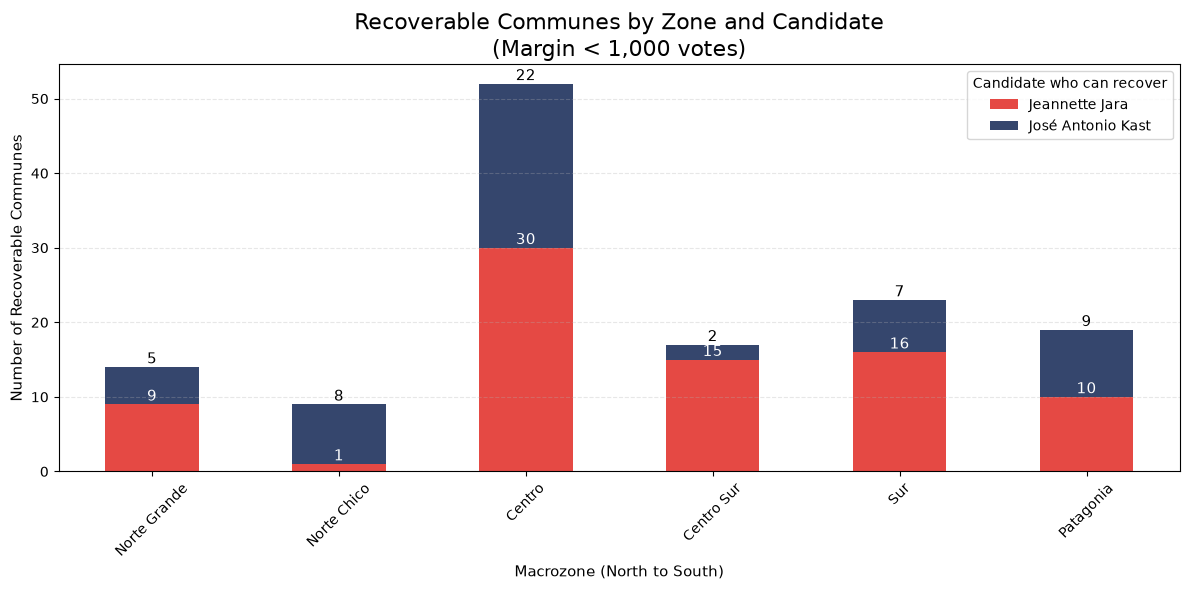

In [125]:
# ============================================================================
# RECOVERABLE COMMUNES STACKED BAR CHART BY MACROZONE — FIRST ROUND 2025
# ============================================================================
# Builds a stacked bar chart showing the number of communes recoverable per
# macrozone (margin < 1,000 votes), disaggregated by the candidate who
# can recover: Jeannette Jara or José Antonio Kast.
# ============================================================================

def plot_recoverable_communes_by_zone(
    close_communes_prep: pd.DataFrame, df_region_dim: pd.DataFrame
) -> None:
    """
    Plots a stacked bar chart of recoverable communes per macrozone for
    Jeannette Jara and José Antonio Kast.

    Parameters
    ----------
    close_communes_prep : pd.DataFrame
        DataFrame with columns 'region', 'loser', and 'macrozone' (optional).
        It contains communes where vote margin < 1,000.
    df_region_dim : pd.DataFrame
        Region dimension table with 'region', 'macrozone', 'macrozone_order'.
    """
    # ---------------------------------------------------------------------------
    # 0. DATA PREPARATION
    # ---------------------------------------------------------------------------
    # Ensures macrozone column is present and defines north-to-south order.
    # Aggregates recoverable commune counts per candidate and zone.

    if 'macrozone' not in close_communes_prep.columns:
        macrozone_map = dict(zip(df_region_dim['region'], df_region_dim['macrozone']))
        close_communes_prep['macrozone'] = close_communes_prep['region'].map(macrozone_map)

    macrozone_order = (
        df_region_dim[['macrozone', 'macrozone_order']]
        .drop_duplicates()
        .sort_values('macrozone_order')['macrozone']
        .tolist()
    )

    zone_count_rows = []
    for candidate in ['Jeannette Jara', 'José Antonio Kast']:
        candidate_prep = close_communes_prep[close_communes_prep['loser'] == candidate]
        for zone in macrozone_order:
            zone_count_rows.append({
                'candidate': candidate,
                'macrozone': zone,
                'communes': len(candidate_prep[candidate_prep['macrozone'] == zone]),
            })

    zone_counts_metrics = pd.DataFrame(zone_count_rows)

    # ---------------------------------------------------------------------------
    # 1. VISUALIZATION — STACKED BAR CHART
    # ---------------------------------------------------------------------------
    # Pivots the data and renders a stacked bar chart with candidate-specific colors.

    fig, ax = plt.subplots(figsize=(12, 6))
    pivot_metrics = (
        zone_counts_metrics
        .pivot(index='macrozone', columns='candidate', values='communes')
        .fillna(0)
        .reindex(macrozone_order)
    )

    cand_colors = {'Jeannette Jara': '#E54944', 'José Antonio Kast': '#35466D'}
    pivot_metrics.plot(kind='bar', stacked=True, ax=ax,
                       color=[cand_colors[c] for c in pivot_metrics.columns])

    ax.set_xlabel('Macrozone (North to South)', fontsize=11)
    ax.set_ylabel('Number of Recoverable Communes', fontsize=11)
    ax.set_title('Recoverable Communes by Zone and Candidate\n(Margin < 1,000 votes)', fontsize=16)
    ax.legend(title='Candidate who can recover', loc='upper right')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

    text_colors = {'Jeannette Jara': 'white', 'José Antonio Kast': 'black'}
    for i, container in enumerate(ax.containers):
        ax.bar_label(container, fmt='%d', fontsize=11, color=text_colors[pivot_metrics.columns[i]])

    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------------
# EXECUTION
# ---------------------------------------------------------------------------
# Calls the plotting function using the close‑communes dataset.

plot_recoverable_communes_by_zone(close_communes_prep, df_region_dim)

#### Chart Description

The stacked bar chart shows the total additional votes Jeannette Jara (red) and José Antonio Kast (blue) would have needed to reverse every commune they lost by fewer than 1,000 votes in each macrozone. It is a measure of **mobilization-effort efficiency**: how many votes it costs to change the result in each zone, making it possible to identify where each candidate has "cheap wins" available and where the required effort is more costly.

#### Analysis by Macrozone

- **Norte Grande:** Jara needed 2,364 votes to recover 9 communes; Kast required 2,194 votes for 5 communes. The effort per commune is similar for both (~263 vs. ~439 votes per commune), but Jara has more communes within reach. Even so, Parisi's structural control of this zone —with results exceeding 40% in several communes— means the real options for change are very limited, regardless of mobilization effort.

- **Norte Chico:** Jara needed only 252 votes for 1 commune; Kast required 3,401 votes for 8 communes. Kast has a clear advantage in the number of recoverable communes in this zone, but the effort per commune is significantly higher for him (425 votes per commune vs. 252 for Jara). Parisi's position as the top vote-getter in most Norte Chico communes —especially in Atacama and Coquimbo— limits the growth potential of both candidates.

- **Centro:** the most contested zone in the analysis. Jara needed 12,991 votes to recover 30 communes; Kast required 7,158 votes for 22 communes. The density of tightly contested communes in O'Higgins, Maule, and Valparaíso —52 recoverable communes in total, equivalent to 38.8% of the national total— confirms that these regions functioned as the real battleground of the first round, and all signs suggest they will remain so in the runoff. Kast had a more efficient effort in this zone: he needed fewer votes per commune recovered (325 votes vs. 433 for Jara), giving him a structural advantage in the country's most important swing regions.

- **Centro Sur:** Jara needed 10,252 votes to recover 15 communes; Kast required only 924 votes for 2 communes. Jara has more communes within reach in this macrozone, but the effort per commune is significantly higher for her (683 votes per commune vs. 462 for Kast). The presence of communes where Jara came in second by narrow margins —Coronel, Tomé, Ercilla, Melipeuco, Perquenco— suggests that her growth potential in the Centro Sur is limited and costly.

- **Sur:** Jara needed 8,935 votes to recover 16 communes; Kast required 1,425 votes for 7 communes. As in the Centro Sur, Jara has more communes within reach, but the effort per commune is significantly higher (558 votes per commune vs. 204 for Kast). In the south's swing regions —especially Los Lagos— Kast had "cheap wins" available: a handful of communes requiring few additional votes to change color.

- **Patagonia:** Jara needed 1,835 votes to recover 10 communes; Kast required 2,620 votes for 9 communes. Patagonia is the most balanced zone in terms of recovery opportunities (19 communes in total), with a similar effort per commune for both (~184 votes for Jara vs. ~291 for Kast). The region's high electoral volatility —where Kaiser also plays a significant role— makes results more uncertain and means small variations in mobilization can have a significant impact.

#### Strategic Reading

- **Jara required the largest absolute mobilization effort**, especially in the **Centro** (12,991 votes) and **Centro Sur** (10,252 votes). Her mobilization challenge was costly not just in scale, but in the type of voter she needed to persuade: voters in semi-rural communes with sensibilities different from her natural base. The concentration of her effort in the Centro and Centro Sur —where margins are narrow but the electorate's profile is less favorable— made her task particularly demanding.

- **Kast faced a more efficient challenge in terms of votes per commune recovered.** His greatest need was concentrated in the **Centro** (7,158 votes), but in the Centro Sur and Sur he required very low volumes (924 and 1,425 votes, respectively). This means that in the south's swing regions, Kast had "cheap wins" available —a handful of communes requiring few additional votes to change color. The geographic distribution of his recoverable communes —more balanced and requiring less effort per commune— gave him a structural advantage heading into the runoff.


### Conclusion 11.3.

The map of required effort structurally favored Kast heading into the runoff. Not only because he needed fewer votes in absolute terms to recover communes (17,720 vs. 33,999 for Jara), but because his recoverable communes were better distributed geographically, making targeted regional mobilization easier. While Jara faced the challenge of mobilizing votes in semi-rural communes of the Centro and Centro Sur —where her message has less traction— Kast could concentrate his efforts in the Centro, where margins are narrow and the electorate's profile is more favorable to his message. The asymmetry in mobilization effort —Jara needed nearly double the votes Kast did to recover communes— pointed toward a runoff in which Kast had more room to expand his territorial base than Jara had to defend hers.


### Conclusion to Chapter 11: Recoverable Communes (Margin < 1,000 Votes)


The analysis of recoverable communes confirms the structural asymmetry in each candidate's room for territorial growth heading into the runoff. Jara faces a significantly larger challenge: she must recover **81 communes** worth a total of **33,999 votes**, concentrated in intermediate, semi-rural Chile —especially O'Higgins, Maule, and the Valparaíso Region— where her message has less traction and where the Kast vote has deeper cultural roots. Her structural weakness lies not in consolidating her urban dominance —where she won comfortably— but in expanding into the territories where Kast built his hegemony, a challenge that would require a shift in how the electorate perceives issues of order and security.

Kast, by contrast, needs to reverse only **53 communes** worth **17,720 votes** —nearly half the effort Jara requires— spread across every macrozone in the country but strategically concentrated in the Centro's swing regions —O'Higgins and Valparaíso— where competition with Jara was tightest and where small variations in vote transfers could tip the balance. His capacity for territorial expansion is significantly greater than Jara's, placing him in a more favorable position to try to consolidate a majority in the runoff.

The map of required effort by macrozone confirms that Kast held a structural advantage in mobilization efficiency. While Jara needed an absolute effort of 12,991 votes in the Centro and 10,252 votes in the Centro Sur —where the electorate's profile is less favorable— Kast could concentrate his efforts in the Centro (7,158 votes) and had "cheap wins" available in the Centro Sur and Sur (924 and 1,425 votes, respectively). The asymmetry in mobilization effort —Jara needs nearly double the votes Kast does to recover communes— points toward a runoff in which Kast has more room to expand his territorial base than Jara has to defend hers, and in which each candidate's ability to capitalize on their recoverable communes —especially in the Centro's swing regions— stands out as one of the most relevant factors for the final result.


---

## 12. Runoff Projection (Jara vs. Kast)


### Introduction


Projecting the presidential runoff between Jeannette Jara and José Antonio Kast requires a simulation exercise that integrates transfer flows from the candidates eliminated in the first round, differential abstention, and the uncertain behavior of Franco Parisi's electorate —the cycle's most disruptive factor. This chapter presents four scenarios spanning the range of possibilities: a base scenario that deliberately excludes the Parisi vote to isolate the structural asymmetry between the blocs (12.1); an optimal scenario for Jara that would require an exceptional convergence of conditions (12.2); a neutral scenario reflecting the natural fragmentation of the anti-establishment vote absent party coordination (12.3); and an optimal scenario for Kast that maximizes the conservative right's advantage (12.4). The analysis of these scenarios suggests that Kast would enter the runoff with a structural advantage under most of the modeled assumptions, and that the Parisi unknown, while decisive for the magnitude of the final result, might not be enough on its own to reverse that advantage.


### 12.1. Base Scenario — Natural Vote Transfer

| Eliminated candidate    | Votes     | Transfer assumption                       | Rationale                                                                                  |
| ------------------------ | --------- | -------------------------------------------- | --------------------------------------------------------------------------------------------- |
| Johannes Kaiser          | 1,796,034 | 95% → Kast, 5% abstention                  | Libertarian-right ideological alignment; abstention reflects programmatic differences.        |
| Eduardo Artés            | 85,516    | 100% → Jara                                 | Radical-left electorate with no ideological alternative in the runoff.                        |
| Marco Enríquez-Ominami   | 154,321   | 100% → Jara                                 | Independent left-wing vote; reluctance to back a right-wing candidacy.                        |
| Evelyn Matthei           | 1,603,104 | 55% → Kast, 20% → Jara, 25% abstention      | The traditional right splits: majority to Kast, minority to Jara (former Evópoli, moderate RN), high abstention among the disaffected. |
| Harold Mayne-Nicholls    | 162,366   | 40% → Jara, 25% → Kast, 35% abstention      | Independent vote with a heterogeneous profile; high abstention out of disillusionment with both options. |

Franco Parisi's vote (2,550,770) **is not allocated in this base scenario**, reflecting genuine uncertainty about where it will go. The base scenario assesses each candidate's structural position before resolving the Parisi unknown.


In [126]:
# ============================================================================
# RUNOFF PROJECTION — BASELINE SCENARIO (FIRST ROUND 2025)
# ============================================================================
# Computes second-round vote projection based on first-round results and
# predefined transfer assumptions for eliminated candidates.
# ============================================================================

# ---------------------------------------------------------------------------
# 0. DATA PREPARATION
# ---------------------------------------------------------------------------
# Extracts national totals from first-round electoral data.

total_cast = df_votes['casted_votes'].sum()
total_blank = df_votes['blank_votes'].sum()
total_null = df_votes['null_votes'].sum()

# ---------------------------------------------------------------------------
# 1. CANDIDATE VOTE EXTRACTION
# ---------------------------------------------------------------------------
# Aggregates first-round votes for each candidate.

votes_jara = df_votes['jara_votes'].sum()
votes_kast = df_votes['kast_votes'].sum()
votes_kaiser = df_votes['kaiser_votes'].sum()
votes_matthei = df_votes['matthei_votes'].sum()
votes_meo = df_votes['enriquez_ominami_votes'].sum()
votes_artes = df_votes['artes_votes'].sum()
votes_mayne = df_votes['mayne_nicholls_votes'].sum()

# ---------------------------------------------------------------------------
# 2. TRANSFER ALLOCATION
# ---------------------------------------------------------------------------
# Applies predefined transfer assumptions for eliminated candidates.

# Kaiser (libertarian right) → 95% Kast, 5% abstention
votes_kast_proj = votes_kast + (votes_kaiser * 0.95)
abstention_kaiser = votes_kaiser * 0.05

# Artes (far left) → 100% Jara
votes_jara_proj = votes_jara + votes_artes

# MEO (independent left) → 100% Jara
votes_jara_proj += votes_meo

# Matthei (historical right) → 55% Kast, 20% Jara, 25% abstention
votes_kast_proj += votes_matthei * 0.55
votes_jara_proj += votes_matthei * 0.20
abstention_matthei = votes_matthei * 0.25

# Mayne-Nicholls (independent) → 40% Jara, 25% Kast, 35% abstention
votes_jara_proj += votes_mayne * 0.40
votes_kast_proj += votes_mayne * 0.25
abstention_mayne = votes_mayne * 0.35

# ---------------------------------------------------------------------------
# 3. METRIC CALCULATION
# ---------------------------------------------------------------------------
# Computes projected valid votes, total abstention from transfers, and margin.

total_valid_proj = votes_jara_proj + votes_kast_proj
abstention_total = abstention_kaiser + abstention_matthei + abstention_mayne
diff = votes_jara_proj - votes_kast_proj

# ---------------------------------------------------------------------------
# 4. TABLE OUTPUT
# ---------------------------------------------------------------------------
# Displays the projection with transfer details, valid vote shares, and margin.

print("\n" + "="*80)
print("SECOND ROUND PROJECTION - BASELINE SCENARIO")
print("="*80)

print("\n📊 TOTAL VOTES CAST:")
print(f"   Total cast: {total_cast:,.0f}".replace(',', '.'))
print(f"   Blank votes: {total_blank:,.0f}".replace(',', '.'))
print(f"   Null votes: {total_null:,.0f}".replace(',', '.'))

print("\n🔄 TRANSFER ALLOCATION:")
print(f"   Johannes Kaiser ({votes_kaiser:,.0f}) → 95% Kast, 5% abstention".replace(',', '.'))
print(f"   Eduardo Artes ({votes_artes:,.0f}) → 100% Jara".replace(',', '.'))
print(f"   Marco Enríquez-Ominami ({votes_meo:,.0f}) → 100% Jara".replace(',', '.'))
print(f"   Evelyn Matthei ({votes_matthei:,.0f}) → 55% Kast, 20% Jara, 25% abstention".replace(',', '.'))
print(f"   Harold Mayne-Nicholls ({votes_mayne:,.0f}) → 40% Jara, 25% Kast, 35% abstention".replace(',', '.'))

print("\n" + "="*80)
print("SECOND ROUND PROJECTION (VALID VOTES ONLY)")
print("="*80)
print(f"✅ Jeannette Jara: {votes_jara_proj:,.0f} votes ({votes_jara_proj/total_valid_proj*100:.1f}% of valid votes)".replace(',', '.'))
print(f"✅ José Antonio Kast: {votes_kast_proj:,.0f} votes ({votes_kast_proj/total_valid_proj*100:.1f}% of valid votes)".replace(',', '.'))

print("\n📊 NON-VOTER SUMMARY (CONTEXT):")
print(f"   Abstention (voters who do not participate): {abstention_total:,.0f}".replace(',', '.'))
print(f"   Blank + null votes: {total_blank + total_null:,.0f}".replace(',', '.'))

print(f"\n📊 MARGIN: {abs(diff):,.0f} votes in favor of {'Jara' if diff > 0 else 'Kast'}".replace(',', '.'))


SECOND ROUND PROJECTION - BASELINE SCENARIO

📊 TOTAL VOTES CAST:
   Total cast: 13.388.455
   Blank votes: 141.956
   Null votes: 360.571

🔄 TRANSFER ALLOCATION:
   Johannes Kaiser (1.796.034) → 95% Kast. 5% abstention
   Eduardo Artes (85.516) → 100% Jara
   Marco Enríquez-Ominami (154.321) → 100% Jara
   Evelyn Matthei (1.603.104) → 55% Kast. 20% Jara. 25% abstention
   Harold Mayne-Nicholls (162.366) → 40% Jara. 25% Kast. 35% abstention

SECOND ROUND PROJECTION (VALID VOTES ONLY)
✅ Jeannette Jara: 4.072.258 votes (41.6% of valid votes)
✅ José Antonio Kast: 5.715.494 votes (58.4% of valid votes)

📊 NON-VOTER SUMMARY (CONTEXT):
   Abstention (voters who do not participate): 547.406
   Blank + null votes: 502.527

📊 MARGIN: 1.643.236 votes in favor of Kast


#### Analysis

The base transfer scenario —which deliberately excludes the Franco Parisi vote to isolate the effect of the other eliminated candidates— reveals a **structural asymmetry favoring José Antonio Kast** that matters for thinking through the runoff's dynamics. Without needing to allocate Parisi's 2.55 million votes, Kast projects to lead by 1,643,236 votes (58.4% vs. 41.6% for Jara), a gap that reflects the combined weight of the blocs gravitating toward the right in the runoff.

The most decisive factor in this projection is the transfer of the **Kaiser + Matthei** bloc. Johannes Kaiser, with 1,796,034 votes, transfers 95% of his electorate to Kast (1,706,232 votes), a projection backed by the high ideological compatibility between libertarianism and the conservative right on issues such as reducing the state, migration, and individual liberties. Evelyn Matthei, with 1,603,104 votes, contributes 881,707 votes to Kast (55% of her electorate), while 20% (320,621 votes) leans toward Jara —reflecting a split within the traditional right between moderate sectors that reject Kast— and 25% (400,776 votes) opts for abstention, evidence of disillusionment among a share of *piñerismo* with the binary offer.

By contrast, the contributions to Jara from eliminated candidates are significantly smaller. Eduardo Artés (85,516 votes) and Marco Enríquez-Ominami (154,321 votes) transfer 100% of their electorate to Jara, adding up to 239,837 votes —a figure representing less than one-tenth of what Kast receives from Kaiser and Matthei. Harold Mayne-Nicholls (162,366 votes), with a more fragmented transfer (40% to Jara, 25% to Kast, 35% abstention), contributes just 64,946 votes to Jara and 40,592 to Kast, reflecting his independent electorate's heterogeneous profile.

The resulting arithmetic is stark: even without Parisi, Kast starts with a structural advantage that Jara cannot offset with the votes of the radical left and the centrist independent alone. The projected abstention within the Matthei bloc (547,406 votes in total, across all candidates) does not substantially alter this advantage. This suggests that the Parisi vote is the factor with the greatest capacity to change the equation: without it, the projection comfortably favors Kast; if it splits in Jara's favor, the result becomes competitive, as the following scenarios explore.

### Conclusion 12.1.

The base transfer scenario suggests Kast would enter the runoff with a **solid structural advantage**, even before resolving the Parisi unknown. The near-complete transfer of Kaiser's electorate and the majority of Matthei's give him a base of 5.7 million votes that Jara cannot match through the contributions of Artés, MEO, and Mayne-Nicholls. Abstention within the Matthei bloc (25%) would not, in this scenario, be enough to change the result, and the 1.64-million-vote margin reflects an asymmetry that additional mobilization of Jara's base alone would not resolve. This makes Parisi the runoff's **"great elector"**: his electorate of 2.55 million votes —concentrated in the North, ideologically fragmented, and with a high propensity toward active protest— is the factor with the greatest capacity to alter the equation. If his vote were to lean mostly toward Jara, the result would become competitive; if it fragmented among Kast, abstention, and the null vote, Kast's advantage would be reinforced. The uncertainty surrounding where his vote goes —especially in the North, where he was strongest— defines the runoff's real battleground, which scenarios 12.2 through 12.4 explore in detail.


### 12.2. Optimal Scenario for Jara

#### Political Context and Assumptions

The optimal scenario for Jeannette Jara projects the best possible runoff result, based on the convergence of two phenomena that could reshape the electoral map in her favor.

The first is the **recovery of the historical northern vote**. The Norte Grande regions were traditionally strongholds of the Concertación and Nueva Mayoría coalitions, where the mining and working-class vote —which leaned partly toward Boric in 2021 and swung massively toward Parisi in 2025— could return to the governing bloc in the runoff. This return would be possible if the northern electorate perceives that the Kast alternative poses a greater risk to its specific demands —labor rights, mining regulation, migration policy— and opts for a strategic vote to check the conservative right's advance.

The second is the **Parisi factor: from rejection to progressive strategic voting**. Franco Parisi and the Partido de la Gente occupy a hybrid political space: anti-establishment in rhetoric, but with social demands that partly overlap with progressivism on issues such as labor rights and access to services. If Parisi were to issue explicit support for Jara —framing it as "social transformation born of discontent" rather than continuity with the Boric government— or if coordination between the PDG and the governing coalition were to materialize, a significant share of the Parisi electorate could shift its vote toward Jara, interpreting her candidacy as an option for structural change rather than a vote for the status quo.


In [127]:
# ============================================================================
# RUNOFF PROJECTION — OPTIMAL FOR JARA SCENARIO (FIRST ROUND 2025)
# ============================================================================
# Computes second-round vote projection under optimal vote transfer assumptions
# for Jeannette Jara. Allocates first-round votes based on predefined
# transfer rates and calculates final valid vote totals and margin.
# ============================================================================

# ---------------------------------------------------------------------------
# 0. DATA PREPARATION
# ---------------------------------------------------------------------------
# Extracts national totals and aggregates first-round votes per candidate.

total_cast = df_votes['casted_votes'].sum()
total_blank = df_votes['blank_votes'].sum()
total_null = df_votes['null_votes'].sum()

votes_jara = df_votes['jara_votes'].sum()
votes_kast = df_votes['kast_votes'].sum()
votes_parisi = df_votes['parisi_votes'].sum()
votes_kaiser = df_votes['kaiser_votes'].sum()
votes_matthei = df_votes['matthei_votes'].sum()
votes_mayne = df_votes['mayne_nicholls_votes'].sum()
votes_artes = df_votes['artes_votes'].sum()
votes_meo = df_votes['enriquez_ominami_votes'].sum()

# ---------------------------------------------------------------------------
# 1. VOTE TRANSFER CALCULATION
# ---------------------------------------------------------------------------
# Applies optimal-for-Jara transfer assumptions from eliminated candidates.

# Initialises projected vote counters
votes_jara_proj = 0
votes_kast_proj = 0
abstention_total = 0

# Jara → 100% Jara (baseline)
votes_jara_proj += votes_jara

# Kast → 100% Kast (baseline)
votes_kast_proj += votes_kast

# Kaiser → 95% Kast, 5% abstention
votes_kast_proj += votes_kaiser * 0.95
abstention_kaiser = votes_kaiser * 0.05
abstention_total += abstention_kaiser

# Artes → 100% Jara
votes_jara_proj += votes_artes

# MEO → 100% Jara
votes_jara_proj += votes_meo

# Matthei → 55% Kast, 20% Jara, 25% abstention
votes_kast_proj += votes_matthei * 0.55
votes_jara_proj += votes_matthei * 0.20
abstention_matthei = votes_matthei * 0.25
abstention_total += abstention_matthei

# Mayne → 40% Jara, 25% Kast, 35% abstention
votes_jara_proj += votes_mayne * 0.40
votes_kast_proj += votes_mayne * 0.25
abstention_mayne = votes_mayne * 0.35
abstention_total += abstention_mayne

# Parisi → 60% Jara, 40% abstention (optimal for Jara)
votes_jara_proj += votes_parisi * 0.60
abstention_parisi = votes_parisi * 0.40
abstention_total += abstention_parisi

# ---------------------------------------------------------------------------
# 2. METRIC COMPUTATION
# ---------------------------------------------------------------------------
# Computes projected valid votes, margin, and total abstention.

total_valid_proj = votes_jara_proj + votes_kast_proj
diff = votes_jara_proj - votes_kast_proj

# ---------------------------------------------------------------------------
# 3. TABLE OUTPUT
# ---------------------------------------------------------------------------
# Displays formatted projection with transfer details and final margin.

print("\n" + "="*80)
print("SECOND ROUND PROJECTION - OPTIMAL FOR JARA SCENARIO")
print("="*80)

print("\n📊 TOTAL VOTES CAST:")
print(f"   Total cast: {total_cast:,.0f}".replace(',', '.'))
print(f"   Blank votes: {total_blank:,.0f}".replace(',', '.'))
print(f"   Null votes: {total_null:,.0f}".replace(',', '.'))

print("\n🔄 TRANSFER ALLOCATION:")
print(f"   Johannes Kaiser ({votes_kaiser:,.0f}) → 95% Kast, 5% abstention".replace(',', '.'))
print(f"   Eduardo Artes ({votes_artes:,.0f}) → 100% Jara".replace(',', '.'))
print(f"   Marco Enríquez-Ominami ({votes_meo:,.0f}) → 100% Jara".replace(',', '.'))
print(f"   Evelyn Matthei ({votes_matthei:,.0f}) → 55% Kast, 20% Jara, 25% abstention".replace(',', '.'))
print(f"   Harold Mayne-Nicholls ({votes_mayne:,.0f}) → 40% Jara, 25% Kast, 35% abstention".replace(',', '.'))
print(f"\n⭐ Franco Parisi ({votes_parisi:,.0f}) → 60% Jara, 40% abstention (OPTIMAL FOR JARA)".replace(',', '.'))

print("\n" + "="*80)
print("SECOND ROUND PROJECTION (VALID VOTES ONLY)")
print("="*80)
print(f"✅ Jeannette Jara: {votes_jara_proj:,.0f} votes ({votes_jara_proj/total_valid_proj*100:.1f}% of valid votes)".replace(',', '.'))
print(f"✅ José Antonio Kast: {votes_kast_proj:,.0f} votes ({votes_kast_proj/total_valid_proj*100:.1f}% of valid votes)".replace(',', '.'))

print(f"\n❌ Non-voters (abstention + blank + null): {abstention_total + total_blank + total_null:,.0f} votes".replace(',', '.'))

print(f"\n📊 MARGIN: {abs(diff):,.0f} votes in favor of {'Jara' if diff > 0 else 'Kast'}".replace(',', '.'))


SECOND ROUND PROJECTION - OPTIMAL FOR JARA SCENARIO

📊 TOTAL VOTES CAST:
   Total cast: 13.388.455
   Blank votes: 141.956
   Null votes: 360.571

🔄 TRANSFER ALLOCATION:
   Johannes Kaiser (1.796.034) → 95% Kast. 5% abstention
   Eduardo Artes (85.516) → 100% Jara
   Marco Enríquez-Ominami (154.321) → 100% Jara
   Evelyn Matthei (1.603.104) → 55% Kast. 20% Jara. 25% abstention
   Harold Mayne-Nicholls (162.366) → 40% Jara. 25% Kast. 35% abstention

⭐ Franco Parisi (2.550.770) → 60% Jara. 40% abstention (OPTIMAL FOR JARA)

SECOND ROUND PROJECTION (VALID VOTES ONLY)
✅ Jeannette Jara: 5.602.720 votes (49.5% of valid votes)
✅ José Antonio Kast: 5.715.494 votes (50.5% of valid votes)

❌ Non-voters (abstention + blank + null): 2.070.241 votes

📊 MARGIN: 112.774 votes in favor of Kast


#### Analysis

The optimal scenario for Jeannette Jara projects the best possible runoff result, based on the convergence of three favorable conditions that could reshape the electoral map in her favor.

- **First, the regrouping of the northern electorate.** This scenario assumes that a significant share of the Franco Parisi vote in the Norte Grande —especially in mining and working-class communes— returns to the governing coalition as a strategic anti-right vote. This shift is historically plausible: the North had strong Concertación governments for decades, and the region's mining and working-class electorate could perceive that the Kast alternative poses a greater risk to its specific demands —labor rights, mining regulation, migration policy— opting for a strategic vote to check the conservative right's advance.

- **Second, an effective narrative of "transformation born of discontent."** Jara would need to convince a majority of the Parisi electorate that she represents real change —not bureaucratic continuity with the Boric government— and that voting for Kast does not address their concrete demands on security, welfare, and territorial development. This narrative requires distancing herself from the outgoing government without losing its support, a difficult balance to strike in a runoff campaign where polarization tends to flatten messaging.

- **Third, selective abstention within the right-wing bloc.** A significant share of the Evelyn Matthei and Harold Mayne-Nicholls electorate would not mobilize for Kast, whether out of disillusionment with the tone of his campaign or rejection of the more extreme positions within the Republican-libertarian bloc. This phenomenon, already factored into the base scenario as 25% abstention within the Matthei bloc, would remain a factor limiting Kast's growth without directly benefiting Jara.

Under these assumptions —including a Parisi transfer of 60% to Jara and 40% abstention— the scenario projects a result of 5,602,720 votes for Jara (49.5%) and 5,715,494 votes for Kast (50.5%), a margin of just **112,774 votes** in Kast's favor, equivalent to 0.85% of the total vote.

### Conclusion 12.2.

Even under the most favorable scenario possible for Jara, this modeling exercise projects **Kast winning by a margin under 113,000 votes**, a gap that would make the runoff one of the closest in Chilean democratic history. In that hypothetical context, factors such as last-day mobilization, the geographic distribution of differential turnout, and performance in the swing regions —especially O'Higgins and Coquimbo, identified in Chapter 11— would prove decisive in tipping the result one way or the other.

The political reading of this scenario, however, is not an optimistic one for Jara. It shows that even under the most favorable conditions conceivable —a massive Parisi transfer toward her candidacy and significant abstention within the right-wing bloc— her advantage is not guaranteed: the model leaves her slightly behind Kast. Reversing his structural base, built on the consolidated right-wing bloc (Kaiser + Matthei) and the asymmetric transfer from eliminated candidates, would require nearly every favorable factor to align simultaneously in Jara's favor —a demanding condition in a context of high polarization and territorial fragmentation.


### 12.3. Neutral Scenario — Natural Fragmentation of the Parisi Vote

#### Political Context

This scenario models the "natural" fragmentation of the Franco Parisi vote in a context where the Partido de la Gente does not manage —or does not attempt— to impose a single voting directive on its base for the runoff, and the Parisi electorate distributes itself according to its own individual sensibilities, with no party-coordination effect. It is, in a sense, the most "organic" of the four scenarios: it assumes that neither an explicit call toward Kast (as in 12.4) nor a realignment toward Jara (as in 12.2) prevails as the dominant narrative within the PDG's electorate, and that instead the same centrifugal forces already visible within that electorate in November continue to operate.

Under this assumption:
- Parisi does not issue a single, unambiguous voting recommendation, or his message fails to discipline his entire base.
- The PDG's electorate fractures internally: sectors with a stronger social sensibility lean toward Jara, while those prioritizing security, order, and migration control opt for Kast.
- The Parisi electorate redistributes according to individual sensibilities, with no coordination effect.


In [128]:
# ============================================================================
# RUNOFF PROJECTION — NEUTRAL SCENARIO (FIRST ROUND 2025)
# ============================================================================
# Computes second-round vote projection under neutral scenario assumptions.
# Allocates first-round candidate votes to Jara/Kast based on predefined
# transfer rates, including abstention components.
# ============================================================================

# ---------------------------------------------------------------------------
# 0. DATA PREPARATION
# ---------------------------------------------------------------------------
# Extracts national vote totals from the first-round dataset.

total_cast = df_votes['casted_votes'].sum()
total_blank = df_votes['blank_votes'].sum()
total_null = df_votes['null_votes'].sum()

# ---------------------------------------------------------------------------
# 1. CANDIDATE VOTE EXTRACTION
# ---------------------------------------------------------------------------
# Aggregates first-round votes for each candidate.

votes_jara = df_votes['jara_votes'].sum()
votes_kast = df_votes['kast_votes'].sum()
votes_parisi = df_votes['parisi_votes'].sum()
votes_kaiser = df_votes['kaiser_votes'].sum()
votes_matthei = df_votes['matthei_votes'].sum()
votes_meo = df_votes['enriquez_ominami_votes'].sum()
votes_artes = df_votes['artes_votes'].sum()
votes_mayne = df_votes['mayne_nicholls_votes'].sum()

# ---------------------------------------------------------------------------
# 2. VOTE TRANSFER ALLOCATION
# ---------------------------------------------------------------------------
# Applies neutral scenario transfer rates to project second-round votes.

# Kaiser → 95% Kast, 5% abstention
votes_kast_proj = votes_kast + (votes_kaiser * 0.95)
abstention_kaiser = votes_kaiser * 0.05

# Artes → 100% Jara
votes_jara_proj = votes_jara + votes_artes

# MEO → 100% Jara
votes_jara_proj += votes_meo

# Matthei → 55% Kast, 20% Jara, 25% abstention
votes_kast_proj += votes_matthei * 0.55
votes_jara_proj += votes_matthei * 0.20
abstention_matthei = votes_matthei * 0.25

# Mayne → 40% Jara, 25% Kast, 35% abstention
votes_jara_proj += votes_mayne * 0.40
votes_kast_proj += votes_mayne * 0.25
abstention_mayne = votes_mayne * 0.35

# Parisi → 40% Jara, 50% Kast, 10% abstention (NEUTRAL)
votes_jara_proj += votes_parisi * 0.40
votes_kast_proj += votes_parisi * 0.50
abstention_parisi = votes_parisi * 0.10

# ---------------------------------------------------------------------------
# 3. FINAL METRICS COMPUTATION
# ---------------------------------------------------------------------------
# Calculates projected valid votes, margin, and total abstention.

total_valid_proj = votes_jara_proj + votes_kast_proj
diff = votes_jara_proj - votes_kast_proj
abstention_total = abstention_kaiser + abstention_matthei + abstention_mayne + abstention_parisi

# ---------------------------------------------------------------------------
# 4. RESULTS DISPLAY
# ---------------------------------------------------------------------------
# Displays formatted projection results with transfer details and margin.

print("\n" + "="*80)
print("SECOND ROUND PROJECTION - NEUTRAL SCENARIO")
print("="*80)

print("\n📊 TOTAL VOTES CAST:")
print(f"   Total cast: {total_cast:,.0f}".replace(',', '.'))
print(f"   Blank votes: {total_blank:,.0f}".replace(',', '.'))
print(f"   Null votes: {total_null:,.0f}".replace(',', '.'))

print("\n🔄 TRANSFER ALLOCATION:")
print(f"   Johannes Kaiser (1,796,034) → 95% Kast, 5% abstention")
print(f"   Eduardo Artes (85,516) → 100% Jara")
print(f"   Marco Enríquez-Ominami (154,321) → 100% Jara")
print(f"   Evelyn Matthei (1,603,104) → 55% Kast, 20% Jara, 25% abstention")
print(f"   Harold Mayne-Nicholls (162,366) → 40% Jara, 25% Kast, 35% abstention")
print(f"\n⭐ Franco Parisi (2,550,770) → 40% Jara, 50% Kast, 10% abstention (NEUTRAL)")

print("\n" + "="*80)
print("SECOND ROUND PROJECTION (VALID VOTES ONLY)")
print("="*80)
print(f"✅ Jeannette Jara: {votes_jara_proj:,.0f} votes ({votes_jara_proj/total_valid_proj*100:.1f}% of valid votes)".replace(',', '.'))
print(f"✅ José Antonio Kast: {votes_kast_proj:,.0f} votes ({votes_kast_proj/total_valid_proj*100:.1f}% of valid votes)".replace(',', '.'))

print(f"\n❌ Non-voters (abstention + blank + null): {abstention_total + total_blank + total_null:,.0f} votes".replace(',', '.'))

print(f"\n📊 MARGIN: {abs(diff):,.0f} votes in favor of {'Jara' if diff > 0 else 'Kast'}".replace(',', '.'))


SECOND ROUND PROJECTION - NEUTRAL SCENARIO

📊 TOTAL VOTES CAST:
   Total cast: 13.388.455
   Blank votes: 141.956
   Null votes: 360.571

🔄 TRANSFER ALLOCATION:
   Johannes Kaiser (1,796,034) → 95% Kast, 5% abstention
   Eduardo Artes (85,516) → 100% Jara
   Marco Enríquez-Ominami (154,321) → 100% Jara
   Evelyn Matthei (1,603,104) → 55% Kast, 20% Jara, 25% abstention
   Harold Mayne-Nicholls (162,366) → 40% Jara, 25% Kast, 35% abstention

⭐ Franco Parisi (2,550,770) → 40% Jara, 50% Kast, 10% abstention (NEUTRAL)

SECOND ROUND PROJECTION (VALID VOTES ONLY)
✅ Jeannette Jara: 5.092.566 votes (42.1% of valid votes)
✅ José Antonio Kast: 6.990.879 votes (57.9% of valid votes)

❌ Non-voters (abstention + blank + null): 1.305.010 votes

📊 MARGIN: 1.898.313 votes in favor of Kast


#### Analysis

The neutral scenario reflects the "natural" fragmentation of the Franco Parisi vote in the absence of a single party directive for the runoff, with the electorate distributing according to individual preferences and no coordination effect. Under these assumptions —a transfer of 50% to Kast, 40% to Jara, and 10% abstention— the scenario projects an advantage of 1,898,313 votes for Kast (57.9% vs. 42.1% for Jara), a margin well above the base scenario's, confirming the structural solidity of the conservative right's advantage within this model.

This result is explained by the sociologically heterogeneous nature of the Parisi electorate. As documented by analysis from the Universidad del Desarrollo, the Parisi voter is concentrated in socioeconomic segments C3, D, and E, with high distrust of the political system and elites, but no defined ideological identity. Under this assumption, that ambiguity would translate into fragmentation leaning mostly toward Kast: although the Parisi electorate includes working-class sectors with welfare demands that lean toward Jara, it also includes sectors concerned with security, migration, and rejection of the "political caste" that lean toward Kast or abstention.

The assumed 50% lean toward Kast —above the 40% toward Jara— reflects the most likely diagnosis under this model: the Parisi vote, while not a traditional right-wing vote, would have a greater affinity with Kast's diagnosis on security and migration than with Jara's proposal of moderate continuity. This lean is consistent with the profile of the communes where Parisi was strongest in the first round: border areas affected by irregular migration and organized crime, where Kast's tough-on-crime rhetoric could resonate more than the promise of social transformation.

The assumed 10% abstention among the Parisi electorate is consistent with the disaffection profile of the anti-establishment voter, who already showed an above-average propensity toward active protest in the first round. The association observed in the first round between the Parisi vote and the null vote —documented in Chapter 4— is consistent with the hypothesis that a meaningful share of this electorate would prioritize invalidating its ballot over transferring its vote to either finalist. This moderate abstention would affect Jara more than Kast, insofar as she would need an almost complete transfer of the Parisi vote to close the structural gap Kast built from the first round onward.


### Conclusion 12.3.

The neutral scenario confirms that, even under the assumption of an organic, uncoordinated fragmentation of the anti-establishment vote, the structural advantage Kast builds from the Kaiser and Matthei transfers would be difficult for Jara to reverse within this model. Transferring 50% of the Parisi electorate to Kast, added to those contributions, projects a solid advantage, with a margin of 1.9 million votes, above 15 percentage points. This scenario suggests that the Parisi unknown, while relevant, would not be enough on its own to reverse the underlying asymmetry between the two blocs: the transfer of the Kaiser and Matthei votes, and the left's structural difficulty in capturing a majority share of the anti-establishment electorate, are the factors that weigh most heavily in this scenario.


### 12.4. Optimal Scenario for Kast

#### Political Context

This hypothetical scenario reflects the most favorable conditions for José Antonio Kast, in which multiple factors would converge simultaneously in his favor, consolidating an electoral coalition of exceptional magnitude. It functions less as a central forecast than as an exercise to identify the upper bound of plausibility: it lays out the mechanisms that would maximize the conservative right's structural advantage in the runoff, even though the probability of all these factors aligning simultaneously is relatively low.

- **First, Parisi calls for a vote for Kast.** In this scenario, Franco Parisi positions himself as Kast's situational ally in rejecting the establishment, issuing a message along the lines of: *"We are the two anti-establishment candidates, against the political caste that has governed Chile for 30 years."* This call would channel his voters toward the Republican candidate as the "less establishment" of the two finalists, transferring an even greater share of the Parisi electorate to the conservative right.

- **Second, wear on the Boric government operates as an electoral asset for Kast.** The government accumulated negative evaluations in the areas most sensitive to the electorate: public safety —with a 20% rise in high-impact crime between 2022 and 2025—, economic growth —with average GDP growth of under 2% for 2023-2025—, and an unresolved migration crisis. Jara, as a member of the governing coalition and Boric's former Labor Minister, carries that legacy directly, and Kast would capitalize on that discontent by presenting himself as the alternative for radical change.

- **Third, the crisis in the North operates as an electoral lever.** The northern regions —historically a swing territory— experienced the most severe impacts of the migration crisis and organized crime during 2022-2025. Kast would capitalize on that discontent by presenting himself as the alternative for order and the sovereign recovery of the border, capturing the vote of border and mining communes where Parisi had been strongest in the first round.

- **Fourth, consolidation of the right-wing bloc.** The runoff unification of the Kaiser and Matthei electorates, plus a significant share of Parisi's, around Kast would produce a quantitatively dominant coalition, in which the combined aligned blocs would comfortably exceed 50% of the valid vote.

#### Scenario Results


In [129]:
# ============================================================================
# RUNOFF PROJECTION — OPTIMAL FOR KAST SCENARIO (FIRST ROUND 2025)
# ============================================================================
# Computes second-round vote projection under optimal transfer assumptions
# for José Antonio Kast. Allocates first-round candidate votes based on
# predefined transfer rates and calculates final valid vote totals and margin.
# ============================================================================

# ---------------------------------------------------------------------------
# 0. DATA PREPARATION
# ---------------------------------------------------------------------------
# Extracts national vote totals from the first-round dataset.

total_cast = df_votes['casted_votes'].sum()
total_blank = df_votes['blank_votes'].sum()
total_null = df_votes['null_votes'].sum()

# ---------------------------------------------------------------------------
# 1. VOTE TRANSFER ALLOCATION
# ---------------------------------------------------------------------------
# Applies optimal-for-Kast transfer assumptions from eliminated candidates.

# Kaiser → 95% Kast, 5% abstention
votes_kast_proj = votes_kast + (votes_kaiser * 0.95)
abstention_kaiser = votes_kaiser * 0.05

# Artes → 100% Jara
votes_jara_proj = votes_jara + votes_artes

# MEO → 100% Jara
votes_jara_proj += votes_meo

# Matthei → 55% Kast, 20% Jara, 25% abstention
votes_kast_proj += votes_matthei * 0.55
votes_jara_proj += votes_matthei * 0.20
abstention_matthei = votes_matthei * 0.25

# Mayne → 40% Jara, 25% Kast, 35% abstention
votes_jara_proj += votes_mayne * 0.40
votes_kast_proj += votes_mayne * 0.25
abstention_mayne = votes_mayne * 0.35

# Parisi → 30% Jara, 60% Kast, 10% abstention (OPTIMAL FOR KAST)
votes_jara_proj += votes_parisi * 0.30
votes_kast_proj += votes_parisi * 0.60
abstention_parisi = votes_parisi * 0.10

# ---------------------------------------------------------------------------
# 2. METRIC COMPUTATION
# ---------------------------------------------------------------------------
# Calculates projected valid votes, margin, and total abstention.

total_valid_proj = votes_jara_proj + votes_kast_proj
diff = votes_jara_proj - votes_kast_proj
abstention_total = abstention_kaiser + abstention_matthei + abstention_mayne + abstention_parisi

# ---------------------------------------------------------------------------
# 3. TABLE OUTPUT
# ---------------------------------------------------------------------------
# Displays formatted projection results with transfer details and margin.

print("\n" + "="*80)
print("SECOND ROUND PROJECTION - OPTIMAL FOR KAST SCENARIO")
print("="*80)

print("\n📊 TOTAL VOTES CAST:")
print(f"   Total cast: {total_cast:,.0f}".replace(',', '.'))
print(f"   Blank votes: {total_blank:,.0f}".replace(',', '.'))
print(f"   Null votes: {total_null:,.0f}".replace(',', '.'))

print("\n🔄 TRANSFER ALLOCATION:")
print(f"   Johannes Kaiser (1,796,034) → 95% Kast, 5% abstention")
print(f"   Eduardo Artes (85,516) → 100% Jara")
print(f"   Marco Enríquez-Ominami (154,321) → 100% Jara")
print(f"   Evelyn Matthei (1,603,104) → 55% Kast, 20% Jara, 25% abstention")
print(f"   Harold Mayne-Nicholls (162,366) → 40% Jara, 25% Kast, 35% abstention")
print(f"\n⭐ Franco Parisi (2,550,770) → 30% Jara, 60% Kast, 10% abstention (OPTIMAL FOR KAST)")

print("\n" + "="*80)
print("SECOND ROUND PROJECTION (VALID VOTES ONLY)")
print("="*80)
print(f"✅ Jeannette Jara: {votes_jara_proj:,.0f} votes ({votes_jara_proj/total_valid_proj*100:.1f}% of valid votes)".replace(',', '.'))
print(f"✅ José Antonio Kast: {votes_kast_proj:,.0f} votes ({votes_kast_proj/total_valid_proj*100:.1f}% of valid votes)".replace(',', '.'))

print(f"\n❌ Non-voters (abstention + blank + null): {abstention_total + total_blank + total_null:,.0f} votes".replace(',', '.'))

print(f"\n📊 MARGIN: {abs(diff):,.0f} votes in favor of {'Jara' if diff > 0 else 'Kast'}".replace(',', '.'))


SECOND ROUND PROJECTION - OPTIMAL FOR KAST SCENARIO

📊 TOTAL VOTES CAST:
   Total cast: 13.388.455
   Blank votes: 141.956
   Null votes: 360.571

🔄 TRANSFER ALLOCATION:
   Johannes Kaiser (1,796,034) → 95% Kast, 5% abstention
   Eduardo Artes (85,516) → 100% Jara
   Marco Enríquez-Ominami (154,321) → 100% Jara
   Evelyn Matthei (1,603,104) → 55% Kast, 20% Jara, 25% abstention
   Harold Mayne-Nicholls (162,366) → 40% Jara, 25% Kast, 35% abstention

⭐ Franco Parisi (2,550,770) → 30% Jara, 60% Kast, 10% abstention (OPTIMAL FOR KAST)

SECOND ROUND PROJECTION (VALID VOTES ONLY)
✅ Jeannette Jara: 4.837.489 votes (40.0% of valid votes)
✅ José Antonio Kast: 7.245.956 votes (60.0% of valid votes)

❌ Non-voters (abstention + blank + null): 1.305.010 votes

📊 MARGIN: 2.408.467 votes in favor of Kast


#### Analysis

The optimal scenario for Kast projects the conservative right's maximum potential under conditions of a broad coalition and anti-establishment support, in which multiple factors would converge simultaneously to maximize his structural advantage. Under these assumptions —including a Franco Parisi transfer of 60% to Kast, 30% to Jara, and 10% abstention— the scenario projects a result of 7,245,956 votes for Kast (60.0%) and 4,837,489 votes for Jara (40.0%), a margin of **2,408,467 votes** in Kast's favor, equivalent to 20 percentage points.

The four pillars of this scenario are politically and historically plausible. **First, Parisi's support for Kast** would mean the Partido de la Gente, rather than remaining neutral, acting as a situational partner of the hard right, united by rejection of the governing coalition. This move has precedents in comparative Latin American politics, where third-force populist candidates have frequently backed the right in runoffs when the candidate to be defeated is the incumbent or their direct representative, as occurred in Peru or Brazil in previous cycles. **Second, the North as an asset for Kast** would require the northern electorate —where Parisi was strongest in the first round— to see Kast as the best option for confronting irregular migration and organized crime. Since many of its demands align with Kast's diagnosis on these issues, the shift is feasible, though not automatic. **Third, Jara as the "symbol of continuity"** implies that, in scenarios of high governmental wear, the governing coalition's candidate carries the full negative legacy of the Boric government —security, economic growth, migration— regardless of her own proposals. Jara was a minister under Boric and a representative of his coalition: that identity is an asset with her base but a liability with critical voters. **Fourth, consolidation of the right-wing bloc** —with Kaiser and Matthei transferring most of their electorate to Kast— would produce a quantitatively dominant coalition exceeding 7 million votes in absolute terms.


### Conclusion 12.4.

In the most favorable scenario possible for Kast —with 60% of the Parisi vote leaning his way, a unified right-wing bloc, and the Boric government's legacy acting as an electoral liability for Jara— the projected victory would exceed 20 percentage points, with a margin of 2.4 million votes. This is the scenario that departs furthest from the first-round result —where Kast won 23.96% and Jara 26.75%— but also the one that demands the greatest political coordination among the actors involved, including explicit support from Parisi for Kast and significant demobilization of Matthei's moderate electorate. It functions, in that sense, as a ceiling rather than a central forecast: it illustrates the upper bound of the conservative right's potential in a context where every plausible factor works simultaneously in its favor. The political reading of this scenario is clear: even under the most favorable conditions for her, Jara's base would not collapse entirely —she would retain 40% of the valid vote— but taken together, the four scenarios suggest that the structural asymmetry between the two blocs leaves Kast in a position of consistent advantage heading into the runoff.


### Conclusion to Chapter 12: Runoff Projection


The projection exercise developed in this chapter —four scenarios that vary only in the assumed transfer of the Parisi vote— suggests that José Antonio Kast would enter the runoff with a **structural advantage** built on the Kaiser and Matthei transfers, and that the unknown of where the Parisi electorate ultimately leans, while decisive for the magnitude of the result, would not be enough on its own to reverse that base under most of the modeled assumptions.

The base scenario (12.1), which deliberately excludes the Parisi vote to isolate the structural asymmetry between the blocs, projects an advantage of 1,643,236 votes for Kast (58.4% versus 41.6% for Jara). The most decisive factor is the transfer of the Kaiser + Matthei bloc: Kaiser transfers 95% of his electorate to Kast (1,706,232 votes), and Matthei contributes 881,707 votes to Kast (55% of her electorate), while the contributions to Jara from Artés and MEO add up to just 239,837 votes. This scenario suggests that Kast's structural base —built on the consolidated right-wing bloc— would be solid even without explicit support from Parisi.

The optimal scenario for Jara (12.2), which assumes a Parisi transfer of 60% to her and 40% abstention, projects the most competitive result of the four: 5,602,720 votes for Jara (49.5%) versus 5,715,494 for Kast (50.5%), a margin of just **112,774 votes**. Even under the most favorable conditions for Jara —recovery of the historical northern vote, an effective narrative of "transformation born of discontent," and selective abstention within the right-wing bloc— this scenario leaves her slightly behind, though within an operationally narrow margin. Reversing Kast's structural base would require assembling, in the time available, a particularly demanding coalition.

The neutral scenario (12.3), which models an organic fragmentation of the Parisi vote absent explicit party coordination —with a transfer of 50% to Kast, 40% to Jara, and 10% abstention— projects an advantage of 1,898,313 votes for Kast (57.9% versus 42.1% for Jara). This scenario suggests that the natural fragmentation of the anti-establishment vote, on its own, would not be enough for Jara to compete on equal footing.

The optimal scenario for Kast (12.4), which assumes a Parisi transfer of 60% to him, 30% to Jara, and 10% abstention, projects the most favorable result for the right: 7,245,956 votes for Kast (60.0%) versus 4,837,489 for Jara (40.0%), a margin of **2,408,467 votes**. This scenario illustrates the upper bound of the conservative right's potential, though it is also the one that demands the greatest political coordination —including explicit support from Parisi— to materialize.

Taken together, these four scenarios suggest Kast would enter the runoff in a position of advantage under most of the modeled transfer assumptions, and that the open question is not so much whether that advantage exists, but what its final magnitude would be. The asymmetric transfer of the Kaiser and Matthei votes, and the left's structural difficulty in capturing a majority share of the anti-establishment electorate, are the factors that explain that advantage within the model. It is worth underscoring, however, that these are projections built on transfer assumptions —not observed results—: the actual behavior of the Parisi electorate, the intensity of last-minute mobilization, and the outcome in the swing regions identified in Chapter 11 are variables that only the runoff itself will settle.


#### Summary Table
| Scenario                    | Parisi Transfer                    | Jara (% valid)   | Kast (% valid)   | Kast Margin        | Result             |
| ----------------------------- | ------------------------------------ | ----------------- | ----------------- | -------------------- | -------------------- |
| **Base** (Parisi excluded)    | Not allocated                        | 41.6%              | **58.4%**           | +1,643,236 votes      | Comfortable win       |
| **Optimal for Jara**          | 60% Jara – 30% Kast – 10% Abst.      | 49.5%              | **50.5%**           | +112,774 votes        | Narrow win            |
| **Neutral**                   | 40% Jara – 50% Kast – 10% Abst.      | 42.1%              | **57.9%**           | +1,898,313 votes      | Clear win             |
| **Optimal for Kast**          | 30% Jara – 60% Kast – 10% Abst.      | 40.0%              | **60.0%**           | +2,408,467 votes      | Wide win              |



---

## 13. Franco Parisi: The Anti-Establishment Vote Phenomenon


Franco Parisi emerged in the 2025 first round as the cycle's most disruptive phenomenon, consolidating a clear, stable third political pole that reshaped Chile's electoral map. With 2.55 million votes (19.8% of the total) and 64 communes won —mainly in the Norte Grande— Parisi showed that anti-establishment politics is not a marginal alternative, but a political force with a genuine territorial footprint, a loyal electoral base, and the capacity to expand into new regions. This chapter examines his performance from two complementary angles: first, the anti-establishment vote's fullest expression, in the communes where Parisi combined outpolled both Jeannette Jara and José Antonio Kast (13.1); and second, the gradient of intensity of his support across the country, which confirms the phenomenon's deeply regional nature (13.2).


### 13.1. The Anti-Establishment Vote at Its Peak: The 11 Communes Where Parisi Outpolled the Duopoly


In 11 communes across the country —equivalent to 3.2% of the national total— Parisi combined outpolled both Jeannette Jara and José Antonio Kast, with an average lead of 8.9 percentage points over their combined total. In these territories, the anti-establishment vote was not the third force: it was the leading force by a wide margin, revealing the existence of an "anti-establishment Chile" with its own territorial, economic, and cultural characteristics that go beyond mere protest and take shape as an emerging political identity.


In [130]:
# ============================================================================
# ANTI-ESTABLISHMENT VOTE ANALYSIS — PARISI VS DUOPOLY (FIRST ROUND 2025)
# ============================================================================
# Identifies communes where Parisi's vote share exceeds the combined share
# of Jara and Kast (the duopoly). Computes lead metrics and aggregates
# results by region.
# ============================================================================

# ---------------------------------------------------------------------------
# 0. DATA PREPARATION
# ---------------------------------------------------------------------------
# Creates a working copy of the first-round electoral data.

votes_prep = df_votes.copy()

# ---------------------------------------------------------------------------
# 1. METRIC CALCULATION
# ---------------------------------------------------------------------------
# Computes the duopoly's combined percentage and Parisi's lead over it.

votes_prep['duopoly_sum_pct'] = votes_prep['jara_pct'] + votes_prep['kast_pct']
votes_prep['parisi_duopoly_lead_pp'] = votes_prep['parisi_pct'] - votes_prep['duopoly_sum_pct']

# ---------------------------------------------------------------------------
# 2. FILTERING — ANTI-ESTABLISHMENT COMMUNES
# ---------------------------------------------------------------------------
# Filters communes where Parisi outperforms the Jara–Kast duopoly.

anti_establishment_prep = (
    votes_prep[votes_prep['parisi_pct'] > votes_prep['duopoly_sum_pct']]
    .copy()
    .sort_values('parisi_duopoly_lead_pp', ascending=False)
)

# ---------------------------------------------------------------------------
# 3. TABLE OUTPUT — NATIONAL OVERVIEW
# ---------------------------------------------------------------------------
# Displays summary statistics and the detailed list of anti-establishment communes.

print("\n" + "=" * 80)
print('ANTI-ESTABLISHMENT VOTE - PARISI VS DUOPOLY')
print('Communes where Parisi exceeds Jara + Kast combined')
print('=' * 80)
print(f'Qualifying communes: {len(anti_establishment_prep)} of {len(votes_prep)}')
print(f'Percentage of total communes: {len(anti_establishment_prep)/len(votes_prep)*100:.1f}%')
print(f'Average Parisi lead over the duopoly: {anti_establishment_prep["parisi_duopoly_lead_pp"].mean():.1f} pp')
print(f'Largest lead: {anti_establishment_prep["parisi_duopoly_lead_pp"].max():.1f} pp')

display_columns = ['commune', 'region', 'parisi_pct', 'jara_pct', 'kast_pct',
                   'duopoly_sum_pct', 'parisi_duopoly_lead_pp', 'casted_votes']
display(anti_establishment_prep[display_columns].round(2))

# ---------------------------------------------------------------------------
# 4. TABLE OUTPUT — REGIONAL BREAKDOWN
# ---------------------------------------------------------------------------
# Aggregates anti-establishment communes by region.

region_summary_metrics = (
    anti_establishment_prep
    .groupby('region')
    .agg(
        antisystem_communes=('commune', 'count'),
        avg_parisi_lead=('parisi_duopoly_lead_pp', 'mean'),
        avg_parisi_pct=('parisi_pct', 'mean'),
    )
    .sort_values('antisystem_communes', ascending=False)
    .round(1)
)
print("\n" + "-" * 80)
print('ANTI-ESTABLISHMENT COMMUNES BY REGION')
print("-" * 80)
display(region_summary_metrics)


ANTI-ESTABLISHMENT VOTE - PARISI VS DUOPOLY
Communes where Parisi exceeds Jara + Kast combined
Qualifying communes: 11 of 346
Percentage of total communes: 3.2%
Average Parisi lead over the duopoly: 8.9 pp
Largest lead: 30.0 pp


,commune,region,parisi_pct,jara_pct,kast_pct,duopoly_sum_pct,parisi_duopoly_lead_pp,casted_votes
4,Ollague,Antofagasta,58.17,12.26,15.94,28.20,29.97,751
282,Colchane,Tarapacá,57.30,2.06,31.90,33.96,23.34,1223
11,General Lagos,Arica y Parinacota,48.95,7.62,28.69,36.31,12.64,634
2,Maria Elena,Antofagasta,45.86,22.27,15.15,37.42,8.44,3261
280,Alto Hospicio,Tarapacá,42.94,17.08,20.12,37.20,5.74,60526
13,Alto del Carmen,Atacama,43.16,20.93,16.85,37.78,5.38,3810
20,Tierra Amarilla,Atacama,42.59,20.84,18.12,38.96,3.63,10694
286,Pozo Almonte,Tarapacá,41.39,17.88,20.11,37.99,3.40,10079
6,Sierra Gorda,Antofagasta,41.90,22.84,16.30,39.14,2.76,1081
73,Punitaqui,Coquimbo,41.07,22.06,17.25,39.31,1.76,9710



--------------------------------------------------------------------------------
ANTI-ESTABLISHMENT COMMUNES BY REGION
--------------------------------------------------------------------------------


,antisystem_communes,avg_parisi_lead,avg_parisi_pct
region,,,
Antofagasta,4,10.5,46.2
Tarapacá,3,10.8,47.2
Atacama,2,4.5,42.9
Arica y Parinacota,1,12.6,49.0
Coquimbo,1,1.8,41.1


#### Analysis

The phenomenon is concentrated almost exclusively in the **Norte Grande**, with limited extension into the Norte Chico. The 11 communes where Parisi outpolled the duopoly are spread across five regions: Antofagasta (4 communes), Tarapacá (3 communes), Atacama (2 communes), Arica y Parinacota (1 commune), and Coquimbo (1 commune). The Antofagasta region leads with 4 communes and an average lead of 10.5 points, followed by Tarapacá with 3 communes and an average lead of 10.8 points, and Arica y Parinacota with 1 commune and a 12.6-point lead —the highest in the country at the regional level.

The analysis of the communes where Parisi outpolled the duopoly reveals three territorial typologies that explain anti-establishment hegemony in the North.

- **High-Intensity Border Communes** —Ollagüe (58.17% Parisi, +29.97 pp over the duopoly), Colchane (57.30%, +23.34 pp), and General Lagos (48.95%, +12.64 pp)— represent the anti-establishment vote's most radical core. These communes, characterized by extreme isolation, their status as borders with Bolivia and Argentina, and direct exposure to the migration crisis and transnational organized crime, concentrate an electorate that experiences state neglect as an everyday reality. In these territories, Parisi's rhetoric on border sovereignty, migration control, and restoring the state's presence in the periphery resonated with an intensity no other candidate matched. Leads exceeding 20-30 points over the duopoly confirm that anti-establishment politics does not compete in these territories: it dominates unchallenged.

- **Mining Communes** —María Elena (45.86%, +8.44 pp), Alto Hospicio (42.94%, +5.74 pp), Calama (38.98%, +1.01 pp), Tierra Amarilla (42.59%, +3.63 pp), and Sierra Gorda (41.90%, +2.76 pp)— represent the second bloc of the anti-establishment vote. These communes, whose economies depend on copper, lithium, or saltpeter mining, concentrate an electorate with the historical sense that "resources flow to the center and never come back." Parisi's rhetoric on redistributive royalties and economic decentralization resonated with particular force in these communes, where a sense of centralized resource extraction and a lack of state investment in infrastructure and services generate structural discontent. Alto Hospicio, with more than 60,000 votes cast, is the largest case by electoral scale on the list, and its inclusion among the anti-establishment communes confirms that the phenomenon is not confined to low-density localities.

- **Northern Rural Communes** —Punitaqui (41.07%, +1.76 pp) and Alto del Carmen (43.16%, +5.38 pp)— represent the third bloc. These communes, affected by the water crisis —the Coquimbo Region has faced severe water deficit conditions for more than a decade— the absence of specific rural policies, and subsistence economies, concentrate an electorate for whom discontent with unfulfilled promises from successive governments is structural. Parisi's rhetoric on decentralization and rural development resonated in these territories, though with less intensity than in the border and mining communes.


### Conclusion 13.1.

Parisi was not merely a passing protest vote option. In northern Chile, he built genuine **territorial hegemony**, with a commune retention rate of roughly 95.7% between 2021 and 2025, indicating that his support is not volatile but structural. His northern electorate responds to concrete, territorial demands —migration, security, resource extraction, neglect— that neither of the two traditional duopoly candidates managed to credibly address. In the 11 communes where Parisi outpolled Jara and Kast combined, anti-establishment politics did not compete: it dominated. This inability of the traditional left and right to absorb that vote is what makes northern anti-establishment politics potentially persistent in future electoral cycles, and it constitutes a structural challenge for the Chilean political system: the existence of an "anti-establishment Chile" with its own territorial identity, one that is not resolved by simple alternation in power at La Moneda.


### 13.2. Intensity of the Parisi Vote: A Territorial Gradient of Anti-Establishment Politics


The analysis of the intensity of the Franco Parisi vote —segmented into five ranges from absolute dominance (>40%) to marginal presence (<20%)— reveals a sharp territorial gradient confirming the regional nature of the anti-establishment phenomenon. Parisi was not a candidate with uniform presence: his support was overwhelmingly concentrated in the country's North, with intensity that decreases systematically moving south. In the communes where Parisi exceeded 40% of the vote —13 communes in total— anti-establishment politics did not compete: it dominated unchallenged, with percentages that in extreme cases (Ollagüe, Colchane) exceeded 57%. By contrast, in the Metropolitan Region and Patagonia, his presence was marginal or token, with percentages that in Santiago's elite communes did not exceed 2%. This intensity gradient is not a statistical artifact: it reflects deep differences in economic type, relationship with the state, and the electorate's priority demands depending on its territorial position.


In [131]:
# ============================================================================
# PARISI VOTE INTENSITY ANALYSIS — FIRST ROUND 2025
# ============================================================================
# Classifies communes by Parisi vote percentage ranges to identify
# anti-system vote concentration, hegemony levels, and territorial patterns.
# ============================================================================

# ---------------------------------------------------------------------------
# 0. DATA PREPARATION
# ---------------------------------------------------------------------------
# Classifies communes into Parisi intensity bands, merges macrozone mapping,
# and determines the winner per commune.

def classify_parisi_intensity(pct):
    """Assigns intensity category based on Parisi vote percentage."""
    if pct > 40:
        return '> 40%'
    elif 35 <= pct <= 40:
        return '35% – 40%'
    elif 30 <= pct < 35:
        return '30% – 35%'
    elif 20 <= pct < 30:
        return '20% – 30%'
    else:
        return '< 20%'

parisi_prep = df_votes.copy()
parisi_prep['parisi_intensity'] = parisi_prep['parisi_pct'].apply(classify_parisi_intensity)

# Defines intensity ordering for consistent display
intensity_order = ['> 40%', '35% – 40%', '30% – 35%', '20% – 30%', '< 20%']

# Merges macrozone information and obtains north-to-south order
parisi_prep = parisi_prep.merge(
    df_region_dim[['region', 'macrozone', 'macrozone_order']], on='region', how='left'
)
macrozone_order = (
    df_region_dim[['macrozone', 'macrozone_order']]
    .drop_duplicates().sort_values('macrozone_order')['macrozone'].tolist()
)

# Determines the winning candidate per commune
candidate_keys = ['jara', 'kast', 'parisi', 'kaiser', 'matthei']
pct_cols = [f'{c}_pct' for c in candidate_keys]
parisi_prep['winner_commune'] = (
    parisi_prep[pct_cols]
    .idxmax(axis=1)
    .str.replace('_pct', '', regex=False)
    .map(CANDIDATE_NAMES)
)

# ---------------------------------------------------------------------------
# 1. TABLE 1 — COMMUNES BY INTENSITY SCALE
# ---------------------------------------------------------------------------
# Displays the number of communes in each Parisi vote intensity band.

print("=" * 80)
print("PARISI VOTE INTENSITY ANALYSIS — FIRST ROUND 2025")
print("=" * 80)

print("\n" + "-" * 80)
print("COMMUNES BY PARISI VOTE INTENSITY")
print("-" * 80)

intensity_counts_metrics = (
    parisi_prep['parisi_intensity']
    .value_counts()
    .reindex(intensity_order)
    .reset_index()
)
intensity_counts_metrics.columns = ['scale', 'communes']
intensity_counts_metrics['communes'] = intensity_counts_metrics['communes'].fillna(0).astype(int)
display(intensity_counts_metrics)

# ---------------------------------------------------------------------------
# 2. TABLE 2 — MACROZONE CROSSTAB
# ---------------------------------------------------------------------------
# Builds a cross-tabulation of Parisi intensity levels by macrozone.

print("\n" + "-" * 80)
print("PARISI VOTE INTENSITY BY MACROZONE")
print("-" * 80)

macrozone_crosstab_metrics = (
    pd.crosstab(parisi_prep['macrozone'], parisi_prep['parisi_intensity'])
    .reindex(macrozone_order)[intensity_order]
    .fillna(0)
    .astype(int)
)
macrozone_crosstab_metrics.index.name = 'Macrozone'
display(macrozone_crosstab_metrics)

# ---------------------------------------------------------------------------
# 3. TABLE 3 — TOP 10 COMMUNES WITH HIGHEST PARISI VOTE %
# ---------------------------------------------------------------------------
# Shows the top 10 communes where Parisi received the largest vote share.

display_columns = ['commune', 'region', 'macrozone', 'parisi_pct', 'jara_pct',
                   'kast_pct', 'kaiser_pct', 'matthei_pct', 'winner_commune']

print("\n" + "-" * 80)
print("TOP 10 COMMUNES — HIGHEST PARISI VOTE %")
print("-" * 80)
display(parisi_prep.nlargest(10, 'parisi_pct')[display_columns].round(2))

# ---------------------------------------------------------------------------
# 4. TABLE 4 — TOP 10 COMMUNES WITH LOWEST PARISI VOTE %
# ---------------------------------------------------------------------------
# Shows the top 10 communes where Parisi received the smallest vote share.

print("\n" + "-" * 80)
print("TOP 10 COMMUNES — LOWEST PARISI VOTE %")
print("-" * 80)
display(parisi_prep.nsmallest(10, 'parisi_pct')[display_columns].round(2))

PARISI VOTE INTENSITY ANALYSIS — FIRST ROUND 2025

--------------------------------------------------------------------------------
COMMUNES BY PARISI VOTE INTENSITY
--------------------------------------------------------------------------------


,scale,communes
0,> 40%,13
1,35% – 40%,8
2,30% – 35%,31
3,20% – 30%,174
4,< 20%,120



--------------------------------------------------------------------------------
PARISI VOTE INTENSITY BY MACROZONE
--------------------------------------------------------------------------------


parisi_intensity,> 40%,35% – 40%,30% – 35%,20% – 30%,< 20%
Macrozone,,,,,
Norte Grande,9,4,5,2,0
Norte Chico,3,3,7,11,0
Centro,0,0,6,70,77
Centro Sur,1,0,10,60,15
Sur,0,1,3,29,9
Patagonia,0,0,0,2,19



--------------------------------------------------------------------------------
TOP 10 COMMUNES — HIGHEST PARISI VOTE %
--------------------------------------------------------------------------------


,commune,region,macrozone,parisi_pct,jara_pct,kast_pct,kaiser_pct,matthei_pct,winner_commune
4,Ollague,Antofagasta,Norte Grande,58.17,12.26,15.94,8.86,2.72,Franco Parisi
282,Colchane,Tarapacá,Norte Grande,57.30,2.06,31.90,6.68,0.99,Franco Parisi
11,General Lagos,Arica y Parinacota,Norte Grande,48.95,7.62,28.69,9.56,4.21,Franco Parisi
2,Maria Elena,Antofagasta,Norte Grande,45.86,22.27,15.15,9.24,4.69,Franco Parisi
13,Alto del Carmen,Atacama,Norte Chico,43.16,20.93,16.85,11.06,5.87,Franco Parisi
281,Camiña,Tarapacá,Norte Grande,43.09,7.21,35.93,10.58,2.84,Franco Parisi
280,Alto Hospicio,Tarapacá,Norte Grande,42.94,17.08,20.12,12.63,4.74,Franco Parisi
20,Tierra Amarilla,Atacama,Norte Chico,42.59,20.84,18.12,11.80,4.22,Franco Parisi
6,Sierra Gorda,Antofagasta,Norte Grande,41.90,22.84,16.30,12.13,5.02,Franco Parisi
286,Pozo Almonte,Tarapacá,Norte Grande,41.39,17.88,20.11,13.88,4.53,Franco Parisi



--------------------------------------------------------------------------------
TOP 10 COMMUNES — LOWEST PARISI VOTE %
--------------------------------------------------------------------------------


,commune,region,macrozone,parisi_pct,jara_pct,kast_pct,kaiser_pct,matthei_pct,winner_commune
272,Vitacura,Metropolitana,Centro,0.82,7.20,35.14,12.90,42.45,Evelyn Matthei
256,Providencia,Metropolitana,Centro,1.90,28.11,18.61,12.06,36.30,Evelyn Matthei
278,las Condes,Metropolitana,Centro,2.23,13.07,31.63,14.26,36.54,Evelyn Matthei
279,ÑUñoa,Metropolitana,Centro,3.53,36.55,17.20,11.65,27.35,Jeannette Jara
277,la Reina,Metropolitana,Centro,4.70,27.56,22.35,12.69,29.38,Evelyn Matthei
243,Lo Barnechea,Metropolitana,Centro,5.19,9.84,41.03,11.46,30.89,José Antonio Kast
269,Santiago,Metropolitana,Centro,7.20,32.71,20.73,12.80,23.11,Jeannette Jara
266,San Miguel,Metropolitana,Centro,7.68,33.85,19.77,12.96,22.11,Jeannette Jara
29,O'higgins,Aysén,Patagonia,8.39,24.94,31.97,23.58,8.39,José Antonio Kast
196,Timaukel,Magallanes,Patagonia,9.48,14.66,40.09,20.26,11.21,José Antonio Kast


#### Analysis

##### Distribution by Intensity Range

The range-distribution table reveals that the Parisi vote follows an inverted-U distribution: most communes (174, or 50.3% of the total) are concentrated in the intermediate 20-30% range, while the extremes —both high intensity (>40%) and low intensity (<20%)— are less common. This pattern suggests that Parisi achieved a significant presence across a large majority of the country's communes, but reached hegemonic or absolute-dominance levels in only a limited number of territories.

The highest-intensity range (>40%) includes 13 communes, all concentrated in the Norte Grande and Norte Chico. These communes represent the hard core of the anti-establishment vote, where Parisi not only won but did so by margins exceeding 40% and, in some cases, 50%. The 35-40% range includes 8 communes, also concentrated in the North. The 30-35% range includes 31 communes, spread across the North (12 communes), the Centro (6 communes), and the Centro Sur (10 communes), indicating that anti-establishment politics begins to gain a presence in the center-south, albeit with less intensity.

##### Distribution by Macrozone

The macrozone-level analysis confirms the regional nature of the Parisi vote with exceptional clarity:

- **Norte Grande:** this is the macrozone where Parisi reaches his fullest expression. Of the 9 communes nationwide with more than 40% of the Parisi vote, all are in the Norte Grande (Ollagüe, Colchane, General Lagos, María Elena, Camiña, Alto Hospicio, Sierra Gorda, Pozo Almonte). In addition, 4 communes fall in the 35-40% range, and 5 in the 30-35% range. In the Norte Grande, Parisi has no marginal presence: all of his communes exceed 20% of the vote. This confirms that the Norte Grande is the territorial heart of anti-establishment politics, where Parisi built a hegemony that does not rest on narrow margins.

- **Norte Chico:** this is the second macrozone most favorable to Parisi. 3 communes exceed 40% (Alto del Carmen, Tierra Amarilla), 3 fall in the 35-40% range, and 7 in the 30-35% range. As in the Norte Grande, Parisi has no marginal presence in the Norte Chico: all of his communes exceed 20%. The difference from the Norte Grande is that intensity is slightly lower, and the distribution is more evenly spread across the ranges.

- **Centro:** this is the macrozone where Parisi begins to lose ground. He has no communes in the highest-intensity ranges (>40% and 35-40%), and only 6 communes fall in the 30-35% range. Most of his communes (70) are concentrated in the 20-30% range, and 77 in the <20% range. In the Centro, Parisi is competitive in some communes, but his presence is limited and his intensity low.

- **Centro Sur:** shows a pattern similar to the Centro, but with a slightly greater presence in the intermediate ranges. 1 commune exceeds 40% (Alto Biobío), 10 communes fall in the 30-35% range, and 60 in the 20-30% range. Alto Biobío's presence in the highest-intensity range confirms that anti-establishment politics is not exclusive to the North, but has a presence in specific Centro Sur enclaves where a perceived neglect by the state and demands for order and security are particularly intense.

- **Sur:** Parisi has a limited presence in the Sur. 1 commune falls in the 35-40% range (Quellón), 3 in the 30-35% range, and 29 in the 20-30% range. In the Sur, Parisi is competitive in some coastal and rural communes, but his intensity is low and his presence limited.

- **Patagonia:** this is the macrozone where Parisi's presence is weakest. He has no communes in the highest-intensity ranges, only 2 communes in the 20-30% range, and 19 in the <20% range. In Patagonia, Parisi is virtually irrelevant, confirming that anti-establishment politics failed to penetrate the country's far south with the same intensity as in the North.

##### Top 10 Communes of Highest and Lowest Intensity

The Top 10 communes by highest Parisi vote share confirm the phenomenon's concentration in the Norte Grande. Ollagüe (58.17%), Colchane (57.30%), General Lagos (48.95%), María Elena (45.86%), Alto del Carmen (43.16%), Camiña (43.09%), Alto Hospicio (42.94%), Tierra Amarilla (42.59%), Sierra Gorda (41.90%), and Pozo Almonte (41.39%) are all communes in the Norte Grande and Norte Chico, characterized by their border, mining, or rural status, and by a high perceived neglect by the state. In these communes, Parisi not only won but did so by margins exceeding 40% and, in some cases, 50%, confirming that anti-establishment politics has a solid, deeply rooted territorial base in the North.

The Top 10 communes by lowest Parisi vote share confirm that anti-establishment politics is virtually irrelevant in the Metropolitan Region and in Santiago's elite communes. Vitacura (0.82%), Providencia (1.90%), Las Condes (2.23%), Ñuñoa (3.53%), La Reina (4.70%), Lo Barnechea (5.19%), Santiago (7.20%), San Miguel (7.68%), O'Higgins (8.39%), and Timaukel (9.48%) are communes where Parisi failed to exceed 10% of the vote, confirming that his message did not resonate among higher-income sectors or in the Centro's established urban centers.

##### Political Implications

The intensity gradient of the Parisi vote carries relevant political implications for Chile's political system. First, it confirms that anti-establishment politics is not a homogeneous phenomenon, but responds to specific territorial logics: its most solid base is in the Norte Grande and Norte Chico, where demands around security, migration, resource extraction, and state neglect are most intense. Second, it suggests that anti-establishment politics has a structural ceiling in the Centro and Sur, where its presence is limited and its intensity low. Third, it reveals that Parisi's capacity to influence the direction of the vote heading into the runoff —whether by transferring it, or by mobilizing his electorate toward the null vote or abstention— would be territorially uneven: in the North, where his base is most solid, his influence would be greatest; in the Centro and Sur, where his presence is weaker, his capacity for influence would be more limited.


### Conclusion 13.2.

The analysis of the intensity of the Parisi vote confirms that anti-establishment politics in Chile is not a homogeneous phenomenon, but a territorial gradient concentrated in the country's North that decreases systematically toward the south. In the 13 communes where Parisi exceeded 40% of the vote —all in the Norte Grande and Norte Chico— anti-establishment politics did not compete: it dominated unchallenged, with percentages that in extreme cases exceeded 57%. By contrast, in the Metropolitan Region and Patagonia, his presence was marginal or token, with percentages that in Santiago's elite communes did not exceed 2%. This intensity gradient —ranging from absolute dominance in the North to irrelevance in the Centro and Patagonia— reflects deep differences in economic type, relationship with the state, and the electorate's priority demands depending on its territorial position. The concentration of the anti-establishment vote in the North is a structural, not a circumstantial, phenomenon, and it constitutes a persistent challenge for Chile's political system: the existence of an "anti-establishment Chile" with its own territorial identity, one that is not resolved by simple alternation in power at La Moneda.


### Conclusion to Chapter 13: Franco Parisi: The Anti-Establishment Vote Phenomenon


The analysis of Franco Parisi in the 2025 first round confirms that anti-establishment politics in Chile has moved beyond a niche phase to become a political force with a genuine territorial footprint, a loyal electoral base, and the capacity for national expansion. In the 11 communes where Parisi outpolled the Jara-Kast duopoly —all in the Norte Grande and Norte Chico— anti-establishment politics did not compete: it dominated unchallenged, with an average lead of 8.9 percentage points over the combined total of the two traditional-system candidates. In border communes such as Ollagüe (58.17%, +29.97 pp), Colchane (57.30%, +23.34 pp), and General Lagos (48.95%, +12.64 pp), Parisi's rhetoric on border sovereignty, migration control, and restoring the state's presence in the periphery resonated with an intensity no other candidate matched. In mining communes such as María Elena (45.86%), Alto Hospicio (42.94%), and Calama (38.98%), an electorate with the historical sense that "resources flow to the center and never come back" found in Parisi an outlet for its structural discontent.

The intensity gradient of the Parisi vote —segmented into five ranges— confirms the regional nature of anti-establishment politics: from absolute dominance in the Norte Grande (>40% in 13 communes) to irrelevance in the Metropolitan Region and Patagonia (<20% in most communes). In the Norte Grande, Parisi has no marginal presence: all of his communes exceed 20% of the vote, and 9 of them exceed 40%. In the Centro, his presence is limited (only 6 communes in the 30-35% range), and in Patagonia he is virtually irrelevant (19 communes in the <20% range). This gradient reflects deep differences in economic type, relationship with the state, and the electorate's priority demands depending on its territorial position.

The concentration of the anti-establishment vote in the North is a structural, not a circumstantial, phenomenon. Parisi's 95.7% retention rate between 2021 and 2025 —the highest of any bloc— confirms that his northern electorate is not a pool of interchangeable protest voters, but one with a consistent territorial and thematic identity that does not shift substantially between elections. His electorate responds to concrete, territorial demands —migration, security, resource extraction, neglect— that neither of the two traditional-system candidates managed to credibly address. This inability of Jara and Kast to absorb that vote is what makes northern anti-establishment politics potentially persistent in future electoral cycles, and it constitutes a structural challenge for Chile's political system: the existence of an "anti-establishment Chile" with its own territorial identity, one that is not resolved by simple alternation in power at La Moneda.


---

## 14. Comparative Analysis: Evolution 2021-2025


### Introduction


Comparing the 2021 and 2025 first-round elections is the fundamental analytical lens for understanding the transformation of Chile's political system over the period. The change in voting regime —from voluntary to compulsory voting— produced an **89.1%** increase in votes cast, bringing in 5.1 million new voters who simply did not participate in 2021. This institutional shift not only inflated turnout, it reshaped the balance of political forces: Franco Parisi emerged as the great winner of compulsory voting (+184% in absolute votes), the right as a whole went from roughly 40% in 2021 to more than 50% in 2025, and the governing left grew far below the electoral roll's average rate (+32%), losing 10.5 percentage points. The comparative analysis covers four dimensions: trends in turnout and the protest vote (14.1), the evolution of political blocs under the new voting regime (14.2), Franco Parisi's trajectory as the cycle's most disruptive phenomenon (14.3), and the map of territorial shifts revealing the depth of the realignment (14.4).


### 14.1. Trends in Turnout and the Invalid Vote: More Votes, More Discontent

The return of compulsory voting is the 2025 electoral cycle's most disruptive variable. This section establishes the quantitative context for that shift, analyzing how turnout indicators and the protest vote evolved between the two elections.


In [132]:
# ============================================================================
# PARTICIPATION COMPARISON — 2021 VS 2025
# ============================================================================
# Compares national totals and percentages for casted, blank, null, and valid
# votes across the 2021 and 2025 electoral rounds. Computes the growth rate
# in participation between both elections.
# ============================================================================

# ---------------------------------------------------------------------------
# 0. DATA PREPARATION
# ---------------------------------------------------------------------------
# Extracts national totals for each vote category per electoral year.

total_cast_2021 = df_2021['casted_votes'].sum()
total_blank_2021 = df_2021['blank_votes'].sum()
total_null_2021 = df_2021['null_votes'].sum()
total_valid_2021 = total_cast_2021 - total_blank_2021 - total_null_2021

total_cast_2025 = df_votes['casted_votes'].sum()
total_blank_2025 = df_votes['blank_votes'].sum()
total_null_2025 = df_votes['null_votes'].sum()
total_valid_2025 = total_cast_2025 - total_blank_2025 - total_null_2025

# ---------------------------------------------------------------------------
# 1. METRIC CALCULATION
# ---------------------------------------------------------------------------
# Builds a comparison dataframe with absolute totals and percentages.

participation_rows = []
for year, cast, blank, null, valid in [
    ('2021', total_cast_2021, total_blank_2021, total_null_2021, total_valid_2021),
    ('2025', total_cast_2025, total_blank_2025, total_null_2025, total_valid_2025)
]:
    participation_rows.append({
        'year': year,
        'casted_votes': cast,
        'blank_votes': blank,
        'null_votes': null,
        'valid_votes': valid,
        'blank_pct': (blank / cast) * 100,
        'null_pct': (null / cast) * 100,
        'valid_pct': (valid / cast) * 100,
    })

participation_metrics = pd.DataFrame(participation_rows)

# ---------------------------------------------------------------------------
# 2. TABLE OUTPUT
# ---------------------------------------------------------------------------
# Displays the comparison table with a contextual note about voting system change.

print("\n" + "="*70)
print("CONTEXT: PARTICIPATION AND NULL/BLANK VOTES")
print("="*70)
print("\n⚠️ NOTE: 2021 = Voluntary voting | 2025 = Compulsory voting")
print("\n📊 ABSOLUTE TOTALS AND PERCENTAGES (over votes cast):")
display(participation_metrics.round(2))

# ---------------------------------------------------------------------------
# 3. GROWTH CALCULATION
# ---------------------------------------------------------------------------
# Computes the participation growth rate between the two elections.

cast_growth = ((total_cast_2025 - total_cast_2021) / total_cast_2021) * 100
print(f"\n📈 Growth in votes cast: +{cast_growth:.1f}%")


CONTEXT: PARTICIPATION AND NULL/BLANK VOTES

⚠️ NOTE: 2021 = Voluntary voting | 2025 = Compulsory voting

📊 ABSOLUTE TOTALS AND PERCENTAGES (over votes cast):


,year,casted_votes,blank_votes,null_votes,valid_votes,blank_pct,null_pct,valid_pct
0,2021,7080276,30427,55316,6994533,0.43,0.78,98.79
1,2025,13388455,141956,360571,12885928,1.06,2.69,96.25



📈 Growth in votes cast: +89.1%


#### Analysis

##### The Impact of Compulsory Voting on Turnout

The change in voting regime from 2021 to 2025 represents an institutional transformation of the first order. In 2021, the presidential first round recorded turnout of 7.08 million votes cast, equivalent to 47.3% of the electoral roll, leaving more than half the electorate outside the process. In 2025, by contrast, compulsory voting —reinstated in 2022— brought into the electoral process millions of people who in previous elections had chosen to abstain, raising votes cast to 13.39 million, an 89.1% increase.

This surge in turnout carries deep implications for interpreting the results. The nominal inflation of absolute vote totals makes comparisons with previous elections analytically problematic: a candidate who won 20% in 2025 is not directly comparable to one who won 13% in 2021, because the denominators are radically different. As the comparative literature notes, bringing in millions of citizens with low levels of political engagement and weak partisan identification makes it analytically risky to assume that a candidate's level of support reflects a consolidated ideological alignment.

##### The Explosion of the Protest Vote

The most telling figure in the comparison between the two elections is the rise in the protest vote. In 2021, null and blank votes in the first round accounted for 1.21% of ballots cast, with 55,316 null votes and 30,427 blank votes. In 2025, null votes multiplied more than sixfold (+552%), reaching 360,571 votes, equivalent to 2.69% of the total, while blank votes grew 366% to 141,956 votes (1.06%). In all, more than 502,000 votes —equivalent to 3.75% of the total— were invalid in the 2025 first round.

The ratio between null and blank votes also shifted significantly. In 2021, the ratio was roughly 1.8 null votes for every blank vote; in 2025, it rose to 2.5:1, showing that discontent became more confrontational. While the blank vote is usually read as a form of passive discontent ("none of the above represents me"), the null vote amounts to a more active, radical expression of rejection toward the political system and the options on offer. The fact that voters mostly chose invalidation as their form of protest —rather than the blank vote— suggests that the electorate brought in by compulsory voting was not only larger, but also more critical and more willing to express its dissatisfaction confrontationally.

##### Efficiency of the Electoral System

Despite the surge in turnout (+89%), the valid-vote rate rose from 94.5% to 96.25%: Chile's electoral system absorbed the increase in turnout without any deterioration in ballot quality. This reflects institutional maturity and an electorate largely able to express its preference clearly, even under compulsory voting. Chilean electoral law —set out in Law 18.700— precisely defines the distinction between valid, null, and blank votes, and the electoral system's accumulated experience explains the high share of valid votes despite the massive increase in turnout.

##### Methodological Implications for the Comparative Analysis

The shift to compulsory voting carries direct methodological implications. First, direct percentage comparisons between 2021 and 2025 should be treated with caution, since 2025 percentages are "diluted" by the larger number of voters. Second, the greater visibility of citizen discontent suggests that many Chileans who simply did not vote in 2021 chose to participate in 2025 while expressing rejection through the null or blank vote. Third, the impact of the protest vote was asymmetric across candidates: those with more anti-establishment or populist messages benefited from the influx of discontented voters, while candidates with a loyal, organized base grew in absolute votes but lost relative share.


### Conclusion 14.1.

The comparison between the 2021 and 2025 first-round elections reveals that the change in voting regime —from voluntary to compulsory voting— is the most important methodological factor for interpreting the results. Turnout rose 89.1%, from 7.08 million to more than 13.39 million votes cast, inflating absolute vote totals and making direct percentage comparisons analytically problematic. At the same time, compulsory voting revealed a level of citizen discontent far more visible than in 2021, with the null vote rising from 0.78% to 2.69% and the blank vote from 0.43% to 1.06%. The null-to-blank ratio, which rose from 1.8:1 to 2.5:1, confirms that discontent became more confrontational in 2025, with a citizenry that, compelled to vote, chose invalidation as a way of expressing dissatisfaction with the electoral offer. In this context, the comparative analysis between the two elections should prioritize the study of absolute votes and territorial evolution over direct percentage comparisons, which are distorted by the institutional change. Compulsory voting not only changed the scale of turnout, it also qualitatively transformed the electorate's composition, bringing in millions of citizens with low levels of political engagement and weak partisan identification, whose electoral behavior responds more to situational incentives than to consolidated ideological alignments.


### 14.2. Comparative Analysis: Voluntary Voting in 2021 versus Compulsory Voting in 2025: The Electorate That Changed Face


The shift from voluntary voting in 2021 to compulsory voting in 2025 is the most significant institutional change for understanding the transformation of the Chilean electorate over the period. This shift produced an **89.1%** increase in votes cast —from 7.08 to 13.39 million— bringing in 5.1 million new voters who simply did not participate in 2021. Comparing the two elections makes it possible to assess not only each political force's absolute growth, but also each candidate's ability to attract the new voters brought in by compulsory voting. The analysis of how the political blocs evolved reveals a historic shift toward anti-establishment politics and the conservative right: Franco Parisi emerged as the great winner of compulsory voting (+184% in absolute votes), the right as a whole went from roughly 40% in 2021 to more than 50% in 2025, and the governing left grew far below the electoral roll's average rate (+32%), losing 10.5 percentage points. This section examines these dynamics and their implications for the reconfiguration of Chile's political map.


In [133]:
# ============================================================================
# POLITICAL BLOCK EVOLUTION — 2021 VS 2025
# ============================================================================
# Compares electoral block evolution between the 2021 and 2025 presidential
# elections. Groups candidates into political blocks and calculates absolute
# vote totals and percentages over valid votes for each year.
# ============================================================================

# ---------------------------------------------------------------------------
# 0. DATA PREPARATION
# ---------------------------------------------------------------------------
# Extracts candidate vote totals for the 2021 election.

boric_2021 = df_2021['boric_votes'].sum()
kast_2021 = df_2021['kast_votes'].sum()
parisi_2021 = df_2021['parisi_votes'].sum()
sichel_2021 = df_2021['sichel_votes'].sum()
provoste_2021 = df_2021['provoste_votes'].sum()
meo_2021 = df_2021['enriquez_ominami_votes'].sum()
artes_2021 = df_2021['artes_votes'].sum()
kaiser_2021 = 0

# Extracts candidate vote totals for the 2025 election.
jara_2025 = df_votes['jara_votes'].sum()
kast_2025 = df_votes['kast_votes'].sum()
parisi_2025 = df_votes['parisi_votes'].sum()
matthei_2025 = df_votes['matthei_votes'].sum()
kaiser_2025 = df_votes['kaiser_votes'].sum()
meo_2025 = df_votes['enriquez_ominami_votes'].sum()
artes_2025 = df_votes['artes_votes'].sum()
mayne_2025 = df_votes['mayne_nicholls_votes'].sum()

# ---------------------------------------------------------------------------
# 1. METRIC CALCULATION
# ---------------------------------------------------------------------------
# Computes total valid votes for each election year.

total_valid_2021 = df_2021['casted_votes'].sum() - df_2021['blank_votes'].sum() - df_2021['null_votes'].sum()
total_valid_2025 = df_votes['casted_votes'].sum() - df_votes['blank_votes'].sum() - df_votes['null_votes'].sum()

# ---------------------------------------------------------------------------
# 2. BLOCK AGGREGATION
# ---------------------------------------------------------------------------
# Groups candidates into political blocks and calculates vote totals and percentages.

comparison_rows = []

# LEFT: Boric + Provoste (2021) vs Jara (2025)
left_2021 = boric_2021 + provoste_2021
comparison_rows.append({
    'block': 'Left / Center-Left',
    '2021_candidates': 'Boric + Provoste',
    '2025_candidate': 'Jara',
    'votes_2021': left_2021,
    'pct_2021': (left_2021 / total_valid_2021) * 100,
    'votes_2025': jara_2025,
    'pct_2025': (jara_2025 / total_valid_2025) * 100,
})

# CONSERVATIVE RIGHT: Kast (2021) vs Kast (2025)
comparison_rows.append({
    'block': 'Conservative Right',
    '2021_candidates': 'Kast',
    '2025_candidate': 'Kast',
    'votes_2021': kast_2021,
    'pct_2021': (kast_2021 / total_valid_2021) * 100,
    'votes_2025': kast_2025,
    'pct_2025': (kast_2025 / total_valid_2025) * 100,
})

# TRADITIONAL RIGHT: Sichel (2021) vs Matthei (2025)
comparison_rows.append({
    'block': 'Traditional Right / Piñerismo',
    '2021_candidates': 'Sichel',
    '2025_candidate': 'Matthei',
    'votes_2021': sichel_2021,
    'pct_2021': (sichel_2021 / total_valid_2021) * 100,
    'votes_2025': matthei_2025,
    'pct_2025': (matthei_2025 / total_valid_2025) * 100,
})

# THIRD WAY / ANTI-SYSTEM: Parisi (2021) vs Parisi (2025)
comparison_rows.append({
    'block': 'Third Way / Anti-system',
    '2021_candidates': 'Parisi',
    '2025_candidate': 'Parisi',
    'votes_2021': parisi_2021,
    'pct_2021': (parisi_2021 / total_valid_2021) * 100,
    'votes_2025': parisi_2025,
    'pct_2025': (parisi_2025 / total_valid_2025) * 100,
})

# NEW RIGHT / LIBERTARIAN: Kaiser (2025 only)
comparison_rows.append({
    'block': 'New Right / Libertarian',
    '2021_candidates': 'Did not exist (was Republican)',
    '2025_candidate': 'Kaiser',
    'votes_2021': 0,
    'pct_2021': 0,
    'votes_2025': kaiser_2025,
    'pct_2025': (kaiser_2025 / total_valid_2025) * 100,
})

# ALTERNATIVE LEFT: MEO (2021) vs MEO (2025)
comparison_rows.append({
    'block': 'Alternative Left',
    '2021_candidates': 'MEO',
    '2025_candidate': 'MEO',
    'votes_2021': meo_2021,
    'pct_2021': (meo_2021 / total_valid_2021) * 100,
    'votes_2025': meo_2025,
    'pct_2025': (meo_2025 / total_valid_2025) * 100,
})

# FAR LEFT: Artes (2021) vs Artes (2025)
comparison_rows.append({
    'block': 'Far Left',
    '2021_candidates': 'Artes',
    '2025_candidate': 'Artes',
    'votes_2021': artes_2021,
    'pct_2021': (artes_2021 / total_valid_2021) * 100,
    'votes_2025': artes_2025,
    'pct_2025': (artes_2025 / total_valid_2025) * 100,
})

# INDEPENDENT: Mayne-Nicholls (2025 only)
comparison_rows.append({
    'block': 'Independent',
    '2021_candidates': 'Did not exist',
    '2025_candidate': 'Mayne-Nicholls',
    'votes_2021': 0,
    'pct_2021': 0,
    'votes_2025': mayne_2025,
    'pct_2025': (mayne_2025 / total_valid_2025) * 100,
})

# ---------------------------------------------------------------------------
# 3. TABLE OUTPUT
# ---------------------------------------------------------------------------
# Displays the block comparison table with explanatory notes.

block_evolution_metrics = pd.DataFrame(comparison_rows)

print("\n" + "="*70)
print("POLITICAL BLOCK EVOLUTION: 2021 vs 2025")
print("="*70)
print("\n⚠️ NOTES:")
print("   • Provoste (center-left) → Jara (natural continuity)")
print("   • Kaiser was Republican in 2021, now runs as Libertarian")
print("   • Percentages are over VALID VOTES\n")
display(block_evolution_metrics.round(0))


POLITICAL BLOCK EVOLUTION: 2021 vs 2025

⚠️ NOTES:
   • Provoste (center-left) → Jara (natural continuity)
   • Kaiser was Republican in 2021, now runs as Libertarian
   • Percentages are over VALID VOTES



,block,2021_candidates,2025_candidate,votes_2021,pct_2021,votes_2025,pct_2025
0,Left / Center-Left,Boric + Provoste,Jara,2610258,37.0,3446854,27.0
1,Conservative Right,Kast,Kast,1954607,28.0,3086963,24.0
2,Traditional Right / Piñerismo,Sichel,Matthei,894838,13.0,1603104,12.0
3,Third Way / Anti-system,Parisi,Parisi,899067,13.0,2550770,20.0
4,New Right / Libertarian,Did not exist (was Republican),Kaiser,0,0.0,1796034,14.0
5,Alternative Left,MEO,MEO,533554,8.0,154321,1.0
6,Far Left,Artes,Artes,102209,1.0,85516,1.0
7,Independent,Did not exist,Mayne-Nicholls,0,0.0,162366,1.0


#### Analysis

##### Evolution of the Main Blocs

| Bloc / Reference                  | 2021 Votes | 2025 Votes    | Abs. Growth | % 2021 | % 2025    | Main Takeaway                                   |
| ----------------------------------- | ---------- | ------------- | ------------ | ------ | --------- | -------------------------------------------------- |
| **Franco Parisi**                   | 899,067    | **2,550,770** | **+184%**     | 13.0%  | **19.8%** | Great winner of compulsory voting                   |
| **José Antonio Kast**               | 1,954,607  | **3,086,963** | **+58%**      | 27.9%  | 24.0%     | Solid growth, loss of relative share                |
| **Evelyn Matthei** (ref. Sichel)    | 894,838    | **1,603,104** | **+79%**      | 12.8%  | 12.4%     | Grows in votes, stagnant in share                   |
| **Jeannette Jara** (ref. Boric + Provoste) | ~2,610,258 | **3,446,854** | **+32%** | 37.3%  | 26.8%     | Very low growth; wear on the governing coalition     |
| **Marco Enríquez-Ominami**          | 533,554    | **154,321**   | **-71%**      | 7.6%   | 1.2%      | Collapse: his electorate migrated to Jara and Parisi |

##### Key Findings

- **Parisi: the great beneficiary of compulsory voting.** His 184% growth in absolute votes —far above the electoral roll's 89% growth— indicates he captured a disproportionate share of the new voters. The electorate that did not participate in 2021 was more anti-establishment than the one that already did. Parisi went from 899,067 votes (13.0%) to 2,550,770 (19.8%), tripling his absolute vote total and consolidating as the country's third political force. This growth reflects that compulsory voting brought in an electorate with high distrust of the traditional political system, for which Parisi's rhetoric —anti-establishment, anti-party, with demands for decentralization and critical of resource extraction— resonated with particular force.

- **The right grew and reconfigured itself.** The Kast + Matthei + Kaiser bloc went from roughly 40% in 2021 to more than 50% in 2025. This growth is not simply the result of new voters being added: it reflects a genuine shift of the electorate from the center and center-left toward more conservative positions, driven by wear on the Boric government. Kast grew 58% in absolute votes (from 1.95 to 3.09 million), but his share fell from 27.9% to 24.0%, indicating his growth lagged the electoral roll's. Matthei, benchmarked against Sichel, grew 79% (from 894,838 to 1,603,104), holding her share around 12%, confirming that the traditional right's space held steady in relative terms. Kaiser, who did not exist as an independent candidate in 2021 —his space was absorbed by the Partido Republicano— burst onto the scene with 1,796,034 votes (14.0%), opening up a libertarian niche that until then had lacked any electoral expression of its own.

- **The governing left grew below the electoral roll's average.** Jara increased just 32% in absolute votes (from ~2.61 to 3.45 million) while the electoral roll grew 89%. Her share fell from 37.3% to 26.8%, the largest relative drop of any bloc. This is not simply wear: the new voters brought in by compulsory voting were significantly less aligned with the governing coalition than those who already voted in 2021. Jara's base, though loyal in terms of retaining habitual voters, failed to capture the new voters, who leaned mostly toward Parisi and the right-wing options.

- **MEO's collapse and the strategic-voting effect.** Marco Enríquez-Ominami's 71% loss in votes (from 533,554 to 154,321) reflects the combined effect of strategic voting toward Jara and the migration toward Parisi of a share of the left-wing electorate discontented with the governing coalition. His political space —left-wing independence, criticism of the progressive establishment— was partly absorbed by Parisi's populism, which offered a more radical anti-establishment message less associated with the Boric government. MEO's collapse is one of the election's most telling phenomena: his vote fell to less than a third of his 2013 total, when he won 10.99%, reflecting the exhaustion of independent left-wing candidacies in a context of polarization and strategic voting.


### Conclusion 14.2.

The shift from voluntary to compulsory voting qualitatively transformed the composition of the Chilean electorate. The 5.1 million new voters brought in by compulsory voting —citizens with low levels of political engagement and weak partisan identification— leaned mostly toward Parisi and the right-wing options, reshaping the political map. Parisi emerged as the great winner of compulsory voting (+184% in absolute votes), tripling his vote total and consolidating as the country's third political force. The right, as a whole, went from roughly 40% in 2021 to more than 50% in 2025, reflecting a genuine shift of the electorate toward more conservative positions, driven by wear on the Boric government. The governing left, by contrast, grew far below the electoral roll's average rate (+32%) and lost 10.5 percentage points, confirming that the new voters were significantly less aligned with the governing coalition than those who already voted in 2021. MEO's collapse (-71%) reflects the exhaustion of independent left-wing candidacies and the effect of strategic voting toward Jara. Taken together, these findings confirm that compulsory voting not only inflated turnout, but reshaped the balance of political forces, consolidating a shift toward the right and anti-establishment politics that redefined Chile's electoral map.


### 14.3. Parisi: From Electoral Footnote to Territorial Force


#### Introduction


Of all the individual trajectories that emerge from the 2021-2025 comparison, none is as revealing as Franco Parisi's. This subchapter examines his particular evolution from four angles: national growth and its territorial concentration (14.3.1), the communes where his advance was most pronounced (14.3.2), the strongholds where, even so, he lost ground (14.3.3), and his expansion by macrozone and region (14.3.4 and 14.3.5). The result is a portrait of a political force that stopped being an electoral footnote and became an actor with a territorial base of its own, whose consolidation —or eventual ebb— will be one of the most significant developments to watch in the electoral cycles ahead.


#### 14.3.1. National Evolution: Growth in Votes, Concentration in Territory


Franco Parisi had the most remarkable electoral trajectory of the 2021-2025 period. Between the two cycles, he not only multiplied his vote total —going from 899,067 to 2,550,770 (+183.7%)— he also reshaped the map of his support, consolidating a territorial concentration that made him a dominant regional force rather than a candidate with uniform national coverage. This analysis examines the quantitative growth of his support and the geographic evolution of his electoral base, tracing how Parisi went from being an experimental protest-vote option —a candidate who voted from abroad and never set foot in Chile during the 2021 campaign— to becoming the leading expression of anti-establishment discontent with a genuine territorial footprint.


In [134]:
# ============================================================================
# PARISI NATIONAL EVOLUTION — 2021 VS 2025
# ============================================================================
# Computes Franco Parisi's vote evolution between the 2021 and 2025
# presidential elections at the commune and national levels. Calculates
# absolute vote growth, growth rate, and share of valid votes.
# ============================================================================

# ---------------------------------------------------------------------------
# 0. DATA PREPARATION
# ---------------------------------------------------------------------------
# Extracts and renames Parisi vote percentages for each electoral year.

parisi_2021_prep = df_2021[['commune', 'region', 'parisi_pct']].rename(columns={'parisi_pct': 'parisi_pct_2021'})
parisi_2025_prep = df_votes[['commune', 'region', 'parisi_pct']].rename(columns={'parisi_pct': 'parisi_pct_2025'})

# ---------------------------------------------------------------------------
# 1. METRIC CALCULATION
# ---------------------------------------------------------------------------
# Merges the two datasets and computes the percentage point change per commune.

parisi_evolution_metrics = parisi_2021_prep.merge(parisi_2025_prep, on=['commune', 'region'])
parisi_evolution_metrics['parisi_change_pp'] = (
    parisi_evolution_metrics['parisi_pct_2025'] - parisi_evolution_metrics['parisi_pct_2021']
)

# ---------------------------------------------------------------------------
# 2. NATIONAL AGGREGATION
# ---------------------------------------------------------------------------
# Computes national vote totals and valid vote shares for both years.

parisi_votes_2021 = df_2021['parisi_votes'].sum()
parisi_votes_2025 = df_votes['parisi_votes'].sum()
total_valid_2021 = df_2021['casted_votes'].sum() - df_2021['blank_votes'].sum() - df_2021['null_votes'].sum()
total_valid_2025 = df_votes['casted_votes'].sum() - df_votes['blank_votes'].sum() - df_votes['null_votes'].sum()
parisi_pct_2021 = (parisi_votes_2021 / total_valid_2021) * 100
parisi_pct_2025 = (parisi_votes_2025 / total_valid_2025) * 100

# ---------------------------------------------------------------------------
# 3. TABLE OUTPUT
# ---------------------------------------------------------------------------
# Displays the national evolution summary with formatted numbers.

print("\n" + "="*70)
print("PARISI NATIONAL EVOLUTION")
print("="*70)

print(f"\n📊 NATIONAL EVOLUTION:")
print(f"   Votes 2021: {parisi_votes_2021:,.0f}".replace(',', '.'))
print(f"   Votes 2025: {parisi_votes_2025:,.0f}".replace(',', '.'))
print(f"   Absolute growth: +{parisi_votes_2025 - parisi_votes_2021:+,.0f}".replace(',', '.'))
print(f"   Growth rate: +{((parisi_votes_2025 / parisi_votes_2021) - 1) * 100:.1f}%")
print(f"\n   Valid vote percentage 2021: {parisi_pct_2021:.1f}%")
print(f"   Valid vote percentage 2025: {parisi_pct_2025:.1f}%")
print(f"   Percentage change: +{(parisi_pct_2025 - parisi_pct_2021):+.1f} pp")


PARISI NATIONAL EVOLUTION

📊 NATIONAL EVOLUTION:
   Votes 2021: 899.067
   Votes 2025: 2.550.770
   Absolute growth: ++1.651.703
   Growth rate: +183.7%

   Valid vote percentage 2021: 12.9%
   Valid vote percentage 2025: 19.8%
   Percentage change: ++6.9 pp


##### Analysis

**Parisi's National Growth**

Franco Parisi was the candidate with the highest relative growth between 2021 and 2025. His votes rose from **899,067** to **2,550,770** (+183.7%), far exceeding the electoral roll's growth (+89.1%). His national share grew **6.9 percentage points**, from 12.9% to 19.8%, consolidating him as the country's third force. This growth is particularly significant because it was not uniform across the territory: it concentrated with greater intensity in the North —already his stronghold in 2021— while his presence expanded moderately but steadily across the rest of the country. This combination of deepening in the stronghold and expanding at the periphery is the typical pattern of a political force undergoing structural consolidation.

The most telling figure: in 2025 Parisi achieved a national percentage almost identical to what Sichel (Chile Vamos) won in 2021 —12.8%— but in absolute terms he tripled his votes. Compulsory voting was far more favorable to him than to any other candidate, confirming that the voters who abstained in 2021 were significantly more prone to anti-establishment discontent than those who already participated. The 5.1 million new voters brought in by compulsory voting found in Parisi an outlet for their distrust of the traditional political system, one that no other candidate managed to capture with the same effectiveness.

**Characteristics of Parisi's Growth**

Parisi's growth shows three distinctive characteristics that set him apart from the other candidates. **First, it is concentrated growth.** Unlike Kast, whose growth was more balanced across the territory, Parisi deepened his dominance in the North, where he was already strong in 2021, while expanding his presence moderately across the rest of the country. This "deepening in the stronghold, expanding at the periphery" pattern is the hallmark of a political force undergoing territorial consolidation, not a passing trend.

- **Second, it is disproportionate growth.** Parisi grew 183.7% in absolute votes, more than double the electoral roll's growth (89.1%). This means he captured a disproportionate share of the new voters brought in by compulsory voting. The electorate that did not participate in 2021 was more anti-establishment than the one that already did, and Parisi knew how to capitalize on that discontent better than any other candidate.

- **Third, it is growth that reshapes the electoral map.** Parisi went from a candidate with a marginal presence in 2021 —where he won just 6 communes— to winning 64 communes in 2025, most of them in the Norte Grande and Norte Chico. This territorial expansion reflects that support for Parisi is neither volatile nor circumstantial, but is consolidating into a political force with a territorial base of its own.

**The Paradox of Parisi's Growth**

Parisi's growth presents a paradox that is key to understanding his position within Chile's political system. On one hand, his growth in absolute votes (+183.7%) and national share (+6.9 pp) establish him as the country's third political force, with a solid territorial base in the North. On the other hand, his growth is territorially concentrated: in the Centro and Sur, his presence remains limited, and in the Metropolitan Region his share is marginal. This territorial concentration implies that Parisi has a structural ceiling: although he can grow to hegemonic levels in the North, his capacity to expand into the rest of the country is limited.

The paradox is resolved by considering that Parisi is not seeking to be a candidate with uniform national coverage, but a regional force with national weight. His strategy is not to compete everywhere, but to dominate where his message resonates most strongly —the North— and remain competitive elsewhere. This strategy has allowed him to consolidate as the country's third force without needing to contest the vote in the Metropolitan Region, where his presence is marginal.


#### Conclusion 14.3.1.

Franco Parisi was the candidate with the highest relative growth between 2021 and 2025. His votes rose from 899,067 to 2,550,770 (+183.7%), far exceeding the electoral roll's growth (+89.1%), and his national share grew 6.9 percentage points, from 12.9% to 19.8%, consolidating him as the country's third force. Compulsory voting was far more favorable to him than to any other candidate, confirming that the voters who abstained in 2021 were significantly more prone to anti-establishment discontent than those who already participated. Yet his growth was not uniform: it concentrated with greater intensity in the North —already his stronghold in 2021— while his presence expanded moderately but steadily across the rest of the country. This combination of deepening in the stronghold and expanding at the periphery is the typical pattern of a political force undergoing structural consolidation. The paradox of his growth —spectacular in absolute terms but territorially concentrated— suggests Parisi has a structural ceiling: his capacity to expand into the Centro and Sur is limited, and his future trajectory depends on his ability to consolidate his dominance in the North while expanding moderately across the rest of the country. Parisi's consolidation as the third force confirms that anti-establishment politics is not a passing phenomenon, but a political force with a territorial base of its own, one that reshaped Chile's electoral map and that neither duopoly candidate managed to fully absorb.


#### 14.3.2. The 10 Communes with the Largest Growth for Parisi: Where Anti-Establishment Politics Gained Ground


Between 2021 and 2025, Franco Parisi not only deepened his support in the North, he also made significant gains in communes with very different profiles. The analysis of the **10 communes with the largest increase in percentage points** reveals where his message struck hardest in relative terms, identifying patterns of territorial expansion that confirm his evolution from a regional force into an actor with national aspirations. In communes such as Alto Biobío (+26.5 pp), Alto del Carmen (+24.3 pp), and Freirina (+20.1 pp), Parisi achieved gains that transformed the local electoral map, displacing center-left and right-wing candidates alike.


In [135]:
# ============================================================================
# PARISI TOP 10 INCREASE COMMUNES — 2021 VS 2025
# ============================================================================
# Identify the 10 communes with the largest increase in percentage points in
# Parisi's percentage of votes between the 2021 and 2025 elections, and show
# the evolution metrics along with the winners of each round.
# ============================================================================

# ---------------------------------------------------------------------------
# 0. DATA PREPARATION
# ---------------------------------------------------------------------------
# Creates working copies, normalises region names, and fixes commune spelling.

votes_2021_prep = df_2021.copy()
votes_2025_prep = df_votes.copy()

# Removes leading "de " from 2021 region names for consistency
votes_2021_prep['region'] = votes_2021_prep['region'].str.replace(r'^de\s+', '', regex=True)

# Standardises commune name 'Llaillay' in both datasets
votes_2025_prep.loc[votes_2025_prep['commune'] == 'Llaillay', 'commune'] = 'Llaillay'
votes_2021_prep.loc[votes_2021_prep['commune'] == 'Llaillay', 'commune'] = 'Llaillay'

# ---------------------------------------------------------------------------
# 1. METRIC CALCULATION
# ---------------------------------------------------------------------------
# Extracts Parisi vote shares and merges the two electoral rounds; computes
# the absolute change in percentage points.

parisi_2021_prep = votes_2021_prep[['commune', 'region', 'parisi_pct']].rename(columns={'parisi_pct': 'parisi_pct_2021'})
parisi_2025_prep = votes_2025_prep[['commune', 'region', 'parisi_pct']].rename(columns={'parisi_pct': 'parisi_pct_2025'})

parisi_evolution_metrics = parisi_2021_prep.merge(parisi_2025_prep, on=['commune', 'region'], how='inner')
parisi_evolution_metrics['parisi_change_pp'] = (
    parisi_evolution_metrics['parisi_pct_2025'] - parisi_evolution_metrics['parisi_pct_2021']
)

# ---------------------------------------------------------------------------
# 2. WINNER DETERMINATION
# ---------------------------------------------------------------------------
# Determines the winning candidate per commune for each electoral round and
# attaches the information to the evolution dataset.

# 2021 winners
candidates_2021 = ['boric_pct', 'kast_pct', 'parisi_pct', 'sichel_pct', 'provoste_pct']
votes_2021_prep['winner_2021_raw'] = (
    votes_2021_prep[candidates_2021].idxmax(axis=1).str.replace('_pct', '')
)
winner_map_2021 = {
    'boric': 'Boric (Left)',
    'kast': 'Kast (Right)',
    'parisi': 'Parisi (Anti-system)',
    'sichel': 'Sichel (Trad Right)',
    'provoste': 'Provoste (Center-Left)'
}
votes_2021_prep['winner_2021'] = votes_2021_prep['winner_2021_raw'].map(winner_map_2021)

# 2025 winners
candidates_2025 = ['jara_pct', 'kast_pct', 'parisi_pct', 'kaiser_pct', 'matthei_pct']
votes_2025_prep['winner_2025_raw'] = (
    votes_2025_prep[candidates_2025].idxmax(axis=1).str.replace('_pct', '')
)
winner_map_2025 = {
    'jara': 'Jara (Left)',
    'kast': 'Kast (Right)',
    'parisi': 'Parisi (Anti-system)',
    'kaiser': 'Kaiser (Libertarian)',
    'matthei': 'Matthei (Trad Right)'
}
votes_2025_prep['winner_2025'] = votes_2025_prep['winner_2025_raw'].map(winner_map_2025)

# Merges winner columns into the Parisi evolution metrics
winners_2021_prep = votes_2021_prep[['commune', 'region', 'winner_2021']]
winners_2025_prep = votes_2025_prep[['commune', 'region', 'winner_2025']]
parisi_evolution_metrics = parisi_evolution_metrics.merge(winners_2021_prep, on=['commune', 'region'], how='left')
parisi_evolution_metrics = parisi_evolution_metrics.merge(winners_2025_prep, on=['commune', 'region'], how='left')

# ---------------------------------------------------------------------------
# 3. RANKING / FILTERING
# ---------------------------------------------------------------------------
# Extracts the 10 communes with the largest Parisi vote share increase.

parisi_decline_top_10 = parisi_evolution_metrics.nlargest(10, 'parisi_change_pp')

# ---------------------------------------------------------------------------
# 4. TABLE OUTPUT
# ---------------------------------------------------------------------------
# Displays the top 10 communes with increase metrics and round winners.

print("\n" + "="*70)
print("PARISI: TOP 10 COMMUNES WITH LARGEST INCREASE")
print("="*70)
print("\n📈 Increase in percentage points (2021 → 2025):")

display(parisi_decline_top_10[['commune', 'region', 'parisi_pct_2021', 'parisi_pct_2025',
                               'parisi_change_pp', 'winner_2021', 'winner_2025']].round(1))


PARISI: TOP 10 COMMUNES WITH LARGEST INCREASE

📈 Increase in percentage points (2021 → 2025):


,commune,region,parisi_pct_2021,parisi_pct_2025,parisi_change_pp,winner_2021,winner_2025
174,Alto Biobio,Biobío,13.8,40.3,26.5,Kast (Right),Parisi (Anti-system)
13,Alto del Carmen,Atacama,18.9,43.2,24.3,Provoste (Center-Left),Parisi (Anti-system)
17,Freirina,Atacama,19.4,39.5,20.1,Provoste (Center-Left),Parisi (Anti-system)
138,Queilen,Los Lagos,13.4,31.3,17.9,Provoste (Center-Left),Parisi (Anti-system)
97,Galvarino,La Araucanía,9.3,26.8,17.5,Kast (Right),Kast (Right)
141,Quinchao,Los Lagos,11.2,28.4,17.2,Boric (Left),Parisi (Anti-system)
135,Puqueldon,Los Lagos,22.6,38.2,15.6,Boric (Left),Parisi (Anti-system)
262,Yerbas Buenas,Maule,11.8,27.0,15.2,Kast (Right),Kast (Right)
102,Lumaco,La Araucanía,5.8,20.7,14.9,Kast (Right),Kast (Right)
200,Tirua,Biobío,8.6,23.4,14.8,Kast (Right),Kast (Right)


##### Analysis

**Territorial Patterns of Growth**

The analysis of Parisi's 10 fastest-growing communes reveals four territorial patterns that define his expansion between 2021 and 2025.

- **Expansion toward the south and the Norte Chico.** Parisi's growth was not confined to deepening his hold on the Norte Grande. His advance in Alto Biobío (Biobío), Queilen (Los Lagos), Quinchao (Los Lagos), Puqueldón (Los Lagos), and Lumaco (La Araucanía) shows the anti-establishment sphere of influence expanding into territory previously dominated by the center-left (formerly Provoste) or by Kast. This southward movement matters because it indicates that anti-establishment politics is not exclusive to the North, but is penetrating the center-south, where demands for security, rural development, and connectivity are equally intense.

- **Cannibalizing the center-left vote.** In communes such as Alto del Carmen, Freirina, and Queilen —where Yasna Provoste or Boric had won in 2021— Parisi posted the largest percentage-point gains. This pattern suggests that migration from the center-left toward anti-establishment politics did not go to Jara (strategic voting) but to Parisi, representing a break from the strategic-voting pattern that had historically protected the progressive bloc's candidates. In these communes, center-left voters discontented with the Boric government chose Parisi as an outlet for their discontent, rather than taking refuge with the governing coalition's candidate.

- **Penetrating Kast's territory.** In communes such as Galvarino, Lumaco, and Tirúa —all in La Araucanía and Biobío, where Kast had won in 2021— Parisi grew strongly. He did not manage to displace Kast, but he did become a competitive third force that fragmented the conservative vote. This matters because it indicates that anti-centralism discontent is not the hard right's monopoly: it can also find expression through populist anti-establishment politics. In these communes, the electorate that backed Kast "by elimination" in 2021 found in Parisi an alternative that combined rejection of centralism with less conservative rhetoric on values-based issues.

- **Consolidation in the Norte Chico.** Communes such as Alto del Carmen and Freirina (Atacama) confirm that Parisi deepened his presence in transition zones between the North and the Centro, widening his territorial reach. These communes, won by the center-left in 2021, swung toward Parisi in 2025, confirming that anti-establishment politics has growing appeal in territories where demands for decentralization and productive development are top priorities.

**Emblematic Cases**

- **Alto Biobío (+26.5 pp):** the most extreme case of Parisi's growth. This commune in Biobío province, with a large Mapuche population and an economy based on forestry and subsistence agriculture, went from 13.8% of the Parisi vote in 2021 to 40.3% in 2025. Parisi went from third force to winning the commune, displacing Kast (who had won in 2021) and Jara. This growth reflects the convergence of demands around state neglect, territorial conflict, and lack of productive development in a commune where anti-establishment politics found its most radical expression in the center-south of the country.

- **Alto del Carmen (+24.3 pp):** this rural commune in Atacama, characterized by its agricultural economy and semi-arid enclave status, went from 18.9% to 43.2% of the Parisi vote. In 2021, the commune had been won by Provoste (center-left), confirming that Parisi managed to capture the center-left's discontented vote in the Norte Chico. Parisi's growth in Alto del Carmen reflects the region's water crisis —the Coquimbo Region has faced severe water deficit conditions for more than a decade— and a perceived neglect by the state on specific rural policies.

- **Queilen (+17.9 pp):** this commune in Chiloé, with an economy based on fishing and aquaculture, went from 13.4% to 31.3% of the Parisi vote. In 2021, the commune had been won by Provoste, confirming that Parisi managed to break into the south of the country, where discontent with centralism and demands for productive development are equally intense. Parisi's presence in Chiloé matters because it indicates that anti-establishment politics is expanding its reach into territories where the left and center-left had traditionally carried more weight.


#### Conclusion 14.3.2.

Parisi's growth in 2025 was that of a candidacy no longer dependent on a single territory, but one that has begun building a presence across different types of communes: rural communes in the north, semi-rural communes in the center-south, and transition zones in the Norte Chico. In communes such as Alto Biobío (+26.5 pp), Alto del Carmen (+24.3 pp), and Freirina (+20.1 pp), Parisi achieved gains that transformed the local electoral map, displacing center-left and right-wing candidates alike. The territorial patterns of his growth —expansion toward the south, cannibalizing the center-left vote, penetrating Kast's territory, and consolidating in the Norte Chico— confirm that Parisi is evolving from a regional force into an actor with national aspirations. This expansion, though uneven, signals a political actor moving beyond a regional profile toward national ambitions, one that in future electoral cycles could consolidate as a permanent alternative to the Jara-Kast duopoly. Parisi's ability to capture the center-left's discontented vote and fragment the conservative vote in the south of the country suggests that his political space —anti-establishment, anti-party, with demands for decentralization and critical of resource extraction— has growth potential that extends beyond the North and that could reshape Chile's electoral map in the years ahead.

#### 14.3.3. The 10 Communes Where Parisi Fell the Most: A Decline That Wasn't

Although Franco Parisi posted strong national growth (+183.7% in absolute votes), he lost ground in some historic Norte Grande strongholds. The analysis of the **10 communes where Parisi fell the most in percentage points** reveals that these losses do not represent a genuine erosion of his base, but rather statistical fluctuations within a territorial dominance that remains solid. Among the 10 communes with the steepest drops in his share, Parisi remains the winner in 9 of them, and the declines are moderate in magnitude —the largest was 7.3 points in María Elena— consistent with the "dilution" effect generated by compulsory voting when it brings in new voters with profiles different from those who already participated in 2021.


In [136]:
# ============================================================================
# PARISI TOP 10 DECLINE COMMUNES — 2021 VS 2025
# ============================================================================
# Identifies the 10 communes with the largest percentage-point decline in
# Parisi's vote share between the 2021 and 2025 elections, and displays
# evolution metrics together with the corresponding winners in each round.
# ============================================================================

# ---------------------------------------------------------------------------
# 0. DATA PREPARATION
# ---------------------------------------------------------------------------
# Creates working copies, normalises region names, and fixes commune spelling.

votes_2021_prep = df_2021.copy()
votes_2025_prep = df_votes.copy()

# Removes leading "de " from 2021 region names for consistency
votes_2021_prep['region'] = votes_2021_prep['region'].str.replace(r'^de\s+', '', regex=True)

# Standardises commune name 'Llaillay' in both datasets
votes_2025_prep.loc[votes_2025_prep['commune'] == 'Llaillay', 'commune'] = 'Llaillay'
votes_2021_prep.loc[votes_2021_prep['commune'] == 'Llaillay', 'commune'] = 'Llaillay'

# ---------------------------------------------------------------------------
# 1. METRIC CALCULATION
# ---------------------------------------------------------------------------
# Extracts Parisi vote shares and merges the two electoral rounds; computes
# the absolute change in percentage points.

parisi_2021_prep = votes_2021_prep[['commune', 'region', 'parisi_pct']].rename(columns={'parisi_pct': 'parisi_pct_2021'})
parisi_2025_prep = votes_2025_prep[['commune', 'region', 'parisi_pct']].rename(columns={'parisi_pct': 'parisi_pct_2025'})

parisi_evolution_metrics = parisi_2021_prep.merge(parisi_2025_prep, on=['commune', 'region'], how='inner')
parisi_evolution_metrics['parisi_change_pp'] = (
    parisi_evolution_metrics['parisi_pct_2025'] - parisi_evolution_metrics['parisi_pct_2021']
)

# ---------------------------------------------------------------------------
# 2. WINNER DETERMINATION
# ---------------------------------------------------------------------------
# Determines the winning candidate per commune for each electoral round and
# attaches this information to the evolution dataset.

candidates_2021 = ['boric_pct', 'kast_pct', 'parisi_pct', 'sichel_pct', 'provoste_pct']
votes_2021_prep['winner_2021_raw'] = (
    votes_2021_prep[candidates_2021].idxmax(axis=1).str.replace('_pct', '')
)
winner_map_2021 = {
    'boric': 'Boric (Left)',
    'kast': 'Kast (Right)',
    'parisi': 'Parisi (Anti-system)',
    'sichel': 'Sichel (Trad Right)',
    'provoste': 'Provoste (Center-Left)'
}
votes_2021_prep['winner_2021'] = votes_2021_prep['winner_2021_raw'].map(winner_map_2021)

candidates_2025 = ['jara_pct', 'kast_pct', 'parisi_pct', 'kaiser_pct', 'matthei_pct']
votes_2025_prep['winner_2025_raw'] = (
    votes_2025_prep[candidates_2025].idxmax(axis=1).str.replace('_pct', '')
)
winner_map_2025 = {
    'jara': 'Jara (Left)',
    'kast': 'Kast (Right)',
    'parisi': 'Parisi (Anti-system)',
    'kaiser': 'Kaiser (Libertarian)',
    'matthei': 'Matthei (Trad Right)'
}
votes_2025_prep['winner_2025'] = votes_2025_prep['winner_2025_raw'].map(winner_map_2025)

# Merges winner columns into the evolution metrics
winners_2021_prep = votes_2021_prep[['commune', 'region', 'winner_2021']]
winners_2025_prep = votes_2025_prep[['commune', 'region', 'winner_2025']]
parisi_evolution_metrics = parisi_evolution_metrics.merge(winners_2021_prep, on=['commune', 'region'], how='left')
parisi_evolution_metrics = parisi_evolution_metrics.merge(winners_2025_prep, on=['commune', 'region'], how='left')

# ---------------------------------------------------------------------------
# 3. RANKING / FILTERING
# ---------------------------------------------------------------------------
# Extracts the 10 communes with the largest Parisi vote share decline.

parisi_decline_top_10 = parisi_evolution_metrics.nsmallest(10, 'parisi_change_pp')

# ---------------------------------------------------------------------------
# 4. TABLE OUTPUT
# ---------------------------------------------------------------------------
# Displays the top 10 communes with decline metrics and round winners.

print("\n" + "="*70)
print("PARISI: TOP 10 COMMUNES WITH LARGEST DECLINE")
print("="*70)
print("\n📉 Decline in percentage points (2021 → 2025):")

display(parisi_decline_top_10[['commune', 'region', 'parisi_pct_2021', 'parisi_pct_2025',
                                 'parisi_change_pp', 'winner_2021', 'winner_2025']].round(1))


PARISI: TOP 10 COMMUNES WITH LARGEST DECLINE

📉 Decline in percentage points (2021 → 2025):


,commune,region,parisi_pct_2021,parisi_pct_2025,parisi_change_pp,winner_2021,winner_2025
2,Maria Elena,Antofagasta,53.1,45.9,-7.3,Parisi (Anti-system),Parisi (Anti-system)
10,Camarones,Arica y Parinacota,35.8,30.8,-5.0,Parisi (Anti-system),Parisi (Anti-system)
3,Mejillones,Antofagasta,42.9,38.5,-4.4,Parisi (Anti-system),Parisi (Anti-system)
49,Timaukel,Magallanes,13.1,9.5,-3.6,Kast (Right),Kast (Right)
48,San Gregorio,Magallanes,13.5,10.7,-2.8,Kast (Right),Kaiser (Libertarian)
54,Huara,Tarapacá,39.5,37.0,-2.5,Parisi (Anti-system),Parisi (Anti-system)
1,Calama,Antofagasta,41.2,39.0,-2.3,Parisi (Anti-system),Parisi (Anti-system)
12,Putre,Arica y Parinacota,33.2,31.3,-1.9,Kast (Right),Parisi (Anti-system)
4,Ollague,Antofagasta,59.6,58.2,-1.4,Parisi (Anti-system),Parisi (Anti-system)
8,Tocopilla,Antofagasta,41.6,40.5,-1.1,Parisi (Anti-system),Parisi (Anti-system)


##### Analysis

**Dilution from Compulsory Voting as an Explanatory Factor**

The shift to compulsory voting between 2021 and 2025 produced an 89.1% increase in votes cast, bringing in millions of new voters with profiles different from those who already participated in 2021. In communes where Parisi was already dominant in 2021 —such as María Elena (53.1%), Ollagüe (59.6%), or Calama (41.2%)— the arrival of new voters who did not necessarily align with his platform produced a drop in his percentage, though not in his local lead. The drop in share did not mean a loss of local leadership: Parisi remained the winner in 9 of the 10 communes where he fell the most, and in Putre, where Kast had won in 2021, Parisi became the winner in 2025 despite the drop in his percentage.

**Pattern of the Declines**

The analysis of the 10 communes where Parisi fell the most reveals three patterns that explain the phenomenon.

- **First, the declines are concentrated in communes where Parisi was already dominant.** María Elena (-7.3 pp), Mejillones (-4.4 pp), Huara (-2.5 pp), Calama (-2.3 pp), Ollagüe (-1.4 pp), and Tocopilla (-1.1 pp) are communes where Parisi already exceeded 40% in 2021. In these communes, there was limited room to grow because Parisi had already captured most of the available vote. The arrival of new voters —who in these communes may be younger, more likely to be migrants, or less politically engaged— produced a drop in Parisi's percentage, but not in his lead.

- **Second, the declines reflect an "electoral ceiling" effect.** In communes where Parisi already exceeded 50% in 2021 —María Elena (53.1%), Ollagüe (59.6%)— the drop in share is an almost inevitable mathematical outcome when the electoral roll expands and the ballot diversifies. Even in these communes, Parisi held percentages above 45%, consolidating his dominance.

- **Third, the declines do not mean a loss of competitiveness.** In Putre, where Parisi fell -1.9 pp but went from being the second force (Kast won in 2021) to being the winner in 2025, the percentage drop is misleading: Parisi improved his relative position despite the decline, absorbing votes from minor candidacies that disappeared between 2021 and 2025.

**The Case of General Lagos**

General Lagos illustrates the robustness of Parisi's northern stronghold. Even on the "communes where he fell the most" list, General Lagos actually posted a percentage increase, not a decline, showing that ranking by worst relative performance is misleading when the starting base was already so high. In communes where Parisi already exceeded 40% or 50% in 2021, there is limited room to grow, and any drop in share does not reflect an erosion of his base, but a dilution effect.


#### Conclusion 14.3.3.

Parisi's declines in his most traditional communes are a statistical artifact of compulsory voting —dilution from the arrival of new voters— rather than a sign of eroding support. Among the 10 communes where he fell the most in percentage points, Parisi remains the winner in 9 of them, and the declines are moderate in magnitude —the largest was 7.3 points in María Elena— consistent with the dilution effect generated by compulsory voting when it brings in new voters with profiles different from those who already participated in 2021. His dominance in the North did not weaken between 2021 and 2025: it consolidated and, in several cases, expanded into communes that in 2021 were not yet part of his sphere of influence. Parisi's ability to maintain his lead in the North despite the massive influx of new voters confirms that his territorial base is solid and structural, not volatile or circumstantial. Northern anti-establishment politics is not a passing trend: it is a political force with a genuine territorial footprint that neither duopoly candidate managed to fully absorb.


#### 14.3.4. Analysis by Macrozone: Parisi's Two-Front Offensive


Beyond his northern stronghold, Franco Parisi achieved **significant territorial expansion** between 2021 and 2025, growing in every macrozone in the country without exception. The analysis of differential growth by macrozone reveals that his advance was greatest where pre-existing discontent was highest and where the traditional forces —Kast in the south, or Provoste in the north— had left openings. Parisi grew most in the Centro Sur (+7.8 pp), the Norte Chico (+7.2 pp), and the Sur (+7.0 pp), while his growth in the Norte Grande was more moderate (+1.5 pp) because he was already starting from a very high base. This two-front expansion pattern —eroding the right in the south and the center-left in the north— is the political signature of an anti-establishment phenomenon that has moved beyond a niche phase and aspires to consolidate as a permanent national force.


In [137]:
# ============================================================================
# PARISI CONSOLIDATION BY MACROZONE — 2021 VS 2025
# ============================================================================
# Computes Parisi vote share evolution by macrozone between the 2021 and 2025
# elections. Aggregates valid and Parisi votes, calculates percentage point
# change, and displays gains/losses ordered north to south.
# ============================================================================

# ---------------------------------------------------------------------------
# 0. DATA PREPARATION
# ---------------------------------------------------------------------------
# Creates working copies, normalises region names, fixes commune spelling,
# and attaches macrozone information.

votes_2021_prep = df_2021.copy()
votes_2025_prep = df_votes.copy()

# Normalises region names from 2021 to match the dimension table
votes_2021_prep['region'] = votes_2021_prep['region'].str.replace(r'^de\s+', '', regex=True)

region_fixes = {
    'Magallanes y de la Antartica Chilena': 'Magallanes',
    'Aysen del General Carlos Ibañez del Campo': 'Aysén',
    'Tarapaca': 'Tarapacá',
    'Valparaiso': 'Valparaíso'
}
for old_name, new_name in region_fixes.items():
    votes_2021_prep.loc[votes_2021_prep['region'] == old_name, 'region'] = new_name

# Standardises commune name 'Llaillay' in both datasets
votes_2025_prep.loc[votes_2025_prep['commune'] == 'Llaillay', 'commune'] = 'Llaillay'
votes_2021_prep.loc[votes_2021_prep['commune'] == 'Llaillay', 'commune'] = 'Llaillay'

# Merges macrozone mapping into both datasets
votes_2021_prep = votes_2021_prep.merge(
    df_region_dim[['region', 'macrozone', 'macrozone_order']],
    on='region', how='left'
)
votes_2025_prep = votes_2025_prep.merge(
    df_region_dim[['region', 'macrozone', 'macrozone_order']],
    on='region', how='left'
)

# ---------------------------------------------------------------------------
# 1. VALID VOTES CALCULATION
# ---------------------------------------------------------------------------
# Computes valid votes per commune (casted minus blank and null).

votes_2021_prep['valid_votes'] = (
    votes_2021_prep['casted_votes'] - votes_2021_prep['blank_votes'] - votes_2021_prep['null_votes']
)
votes_2025_prep['valid_votes'] = (
    votes_2025_prep['casted_votes'] - votes_2025_prep['blank_votes'] - votes_2025_prep['null_votes']
)

# ---------------------------------------------------------------------------
# 2. MACROZONE AGGREGATION
# ---------------------------------------------------------------------------
# Aggregates valid and Parisi votes by macrozone for both election years.

macrozone_2021_metrics = votes_2021_prep.groupby(['macrozone', 'macrozone_order']).agg(
    total_valid_2021=('valid_votes', 'sum'),
    total_parisi_2021=('parisi_votes', 'sum')
).reset_index()

macrozone_2025_metrics = votes_2025_prep.groupby(['macrozone', 'macrozone_order']).agg(
    total_valid_2025=('valid_votes', 'sum'),
    total_parisi_2025=('parisi_votes', 'sum')
).reset_index()

# ---------------------------------------------------------------------------
# 3. METRIC CALCULATION
# ---------------------------------------------------------------------------
# Merges the two aggregations, calculates Parisi vote shares, percentage
# point change, and sorts north to south.

parisi_macrozone_metrics = macrozone_2021_metrics.merge(
    macrozone_2025_metrics,
    on=['macrozone', 'macrozone_order']
)
parisi_macrozone_metrics['parisi_pct_2021'] = (
    parisi_macrozone_metrics['total_parisi_2021'] / parisi_macrozone_metrics['total_valid_2021']
) * 100
parisi_macrozone_metrics['parisi_pct_2025'] = (
    parisi_macrozone_metrics['total_parisi_2025'] / parisi_macrozone_metrics['total_valid_2025']
) * 100
parisi_macrozone_metrics['change_pp'] = (
    parisi_macrozone_metrics['parisi_pct_2025'] - parisi_macrozone_metrics['parisi_pct_2021']
)

parisi_macrozone_metrics = parisi_macrozone_metrics.sort_values('macrozone_order')

# Converts valid vote totals to integer for cleaner display
parisi_macrozone_metrics['total_valid_2021'] = parisi_macrozone_metrics['total_valid_2021'].astype(int)
parisi_macrozone_metrics['total_valid_2025'] = parisi_macrozone_metrics['total_valid_2025'].astype(int)

# ---------------------------------------------------------------------------
# 4. TABLE OUTPUT
# ---------------------------------------------------------------------------
# Displays the macrozone summary table and lists zones where Parisi gained
# or lost support.

print("\n" + "="*70)
print("MACROZONE ANALYSIS: WHERE PARISI CONSOLIDATED")
print("="*70)
print("\n📊 Parisi vote evolution by macrozone (north to south):")

display(parisi_macrozone_metrics[[
    'macrozone', 'parisi_pct_2021', 'parisi_pct_2025',
    'change_pp', 'total_valid_2021', 'total_valid_2025'
]].round(1))

print("\n📈 MACROZONES WHERE PARISI GAINED SUPPORT:")
gained = parisi_macrozone_metrics[parisi_macrozone_metrics['change_pp'] > 0]
for _, row in gained.iterrows():
    print(
        f"   • {row['macrozone']}: +{row['change_pp']:.1f} pp "
        f"({row['parisi_pct_2021']:.1f}% → {row['parisi_pct_2025']:.1f}%)"
    )

print("\n📉 MACROZONES WHERE PARISI LOST SUPPORT:")
lost = parisi_macrozone_metrics[parisi_macrozone_metrics['change_pp'] < 0]
for _, row in lost.iterrows():
    print(
        f"   • {row['macrozone']}: {row['change_pp']:.1f} pp "
        f"({row['parisi_pct_2021']:.1f}% → {row['parisi_pct_2025']:.1f}%)"
    )


MACROZONE ANALYSIS: WHERE PARISI CONSOLIDATED

📊 Parisi vote evolution by macrozone (north to south):


,macrozone,parisi_pct_2021,parisi_pct_2025,change_pp,total_valid_2021,total_valid_2025
3,Norte Grande,31.0,32.5,1.5,395438,749570
2,Norte Chico,21.1,28.3,7.2,369633,760410
0,Centro,13.5,16.7,3.2,1560831,7927946
1,Centro Sur,15.3,23.1,7.8,1196701,2315318
5,Sur,14.3,21.3,7.0,485370,946555
4,Patagonia,12.7,16.5,3.8,108984,186129



📈 MACROZONES WHERE PARISI GAINED SUPPORT:
   • Norte Grande: +1.5 pp (31.0% → 32.5%)
   • Norte Chico: +7.2 pp (21.1% → 28.3%)
   • Centro: +3.2 pp (13.5% → 16.7%)
   • Centro Sur: +7.8 pp (15.3% → 23.1%)
   • Sur: +7.0 pp (14.3% → 21.3%)
   • Patagonia: +3.8 pp (12.7% → 16.5%)

📉 MACROZONES WHERE PARISI LOST SUPPORT:


##### Analysis

**Patterns of Consolidation by Macrozone**

- **Centro Sur: the largest territorial leap (+7.8 pp).** Parisi grew more in Kast's macrozone than in his own. In Ñuble, Biobío, and La Araucanía —regions where Kast has his most solid bases— Parisi advanced significantly, especially in rural and semi-rural communes. This finding suggests that part of the rural southern electorate that backed Kast "by elimination" in 2021 found in Parisi a more genuine expression of its discontent with the political system. In communes such as Alto Biobío (+26.5 pp), Galvarino (+17.5 pp), Lumaco (+14.9 pp), and Tirúa (+14.8 pp), Parisi achieved gains that transformed the local electoral map, becoming a competitive third force that fragmented the conservative vote. Parisi's penetration into the Centro Sur is particularly significant because it indicates that anti-establishment politics is not an exclusively northern phenomenon, but is expanding its reach into territories where demands for security, rural development, and connectivity are equally intense.

- **Norte Chico: advance over the center-left (+7.2 pp).** Parisi eroded Provoste's space in regions such as Atacama and Coquimbo, where the legacy of the PS and DC parties mattered in 2021. This cannibalizing of the center-left vote is one of the cycle's most important findings: it confirms that migration from the center-left did not go toward Jara (strategic voting), but toward anti-establishment politics. In communes such as Alto del Carmen (+24.3 pp), Freirina (+20.1 pp), and Vallenar, Parisi posted the largest percentage-point gains, displacing center-left candidates who had won in 2021. Parisi's ability to capture the center-left's discontented vote in the Norte Chico reflects that anti-establishment politics has growing appeal in territories where demands for decentralization and productive development are top priorities.

- **Sur: consolidation in institutional-left territory (+7.0 pp).** In Los Ríos and Los Lagos, Parisi advanced significantly, especially in communes in Chiloé and along the coast. In communes such as Queilen (+17.9 pp), Quinchao (+17.2 pp), and Puqueldón (+15.6 pp), Parisi achieved gains that transformed the local electoral map, displacing center-left candidates who had won in 2021. Parisi's presence in Chiloé matters because it indicates that anti-establishment politics is expanding its reach into territories where the left and center-left had traditionally carried more weight, and where demands for productive development and connectivity are particularly intense.

- **Centro: a moderate but significant advance (+3.2 pp).** The most surprising figure is Parisi's growth in the Metropolitan Region (+6.6 pp, though the macrozone average includes O'Higgins and Maule), a territory where his message was assumed to resonate less. This suggests that anti-establishment politics is not solely a peripheral phenomenon: it has penetration in major cities, especially among discontented voters who simply did not vote in 2021. In Greater Santiago communes such as Puente Alto, Maipú, and La Florida, Parisi grew in absolute votes even though his share remained low, reflecting the arrival of new voters who found in his rhetoric an outlet for their discontent.

- **Patagonia: moderate growth (+3.8 pp).** In Aysén and Magallanes, Parisi grew moderately, albeit from a low base. His presence in Patagonia remains limited, confirming that anti-establishment politics failed to penetrate the country's far south with the same intensity as in the North.

- **Norte Grande: more moderate growth (+1.5 pp).** He was already starting from a very high base (31.0% in 2021), so his room for expansion was structurally smaller. Growth here was about deepening, not expanding: Parisi consolidated his dominance in communes where he was already strong, holding percentages that in some cases exceed 50% (Ollagüe, Colchane, General Lagos). The arrival of new voters in the Norte Grande —many of them migrants or young people with weaker political identification— produced a drop in Parisi's share in some communes, but did not erode his territorial lead.


#### Conclusion 14.3.4.

The macrozone-level analysis confirms that Parisi grew in every macrozone in the country without exception, consolidating his presence in the North and expanding into the Centro Sur, the Sur, and the Metropolitan Region. His growth was greatest where pre-existing discontent was highest and where the traditional forces —Kast in the south, or Provoste in the north— had left openings. In the Centro Sur (+7.8 pp), Parisi eroded Kast's vote in rural and semi-rural communes, becoming a competitive third force that fragmented the conservative vote. In the Norte Chico (+7.2 pp), he cannibalized the center-left vote, confirming that migration from the center-left went toward anti-establishment politics rather than Jara. In the Sur (+7.0 pp), he advanced into institutional-left territory, especially in Chiloé and along the coast. In the Centro (+3.2 pp), he grew moderately but significantly, including a notable advance in the Metropolitan Region (+6.6 pp). In the Norte Grande (+1.5 pp), he deepened his dominance from an already very high base. This two-front expansion pattern —eroding the right in the south and the center-left in the north— is the political signature of an anti-establishment phenomenon that has moved beyond a niche phase and aspires to consolidate as a permanent national force. Parisi's ability to grow in every macrozone confirms that anti-establishment politics is not a passing trend, but a political force with a genuine territorial footprint and the potential to expand into territories where the left and right had traditionally carried more weight.


#### 14.3.5. Which Regions Did Parisi Grow the Most In?: A Nearly Nationwide Advance


The regional analysis of Franco Parisi's growth between 2021 and 2025 shows that he increased his vote in **15 of the country's 16 regions**, with average growth of **+6.1 percentage points**. This geographic breadth is one of the most significant indicators of his consolidation as a national political force. The Centro Sur —Ñuble (+9.4 pp) and La Araucanía (+8.7 pp)— posted the largest growth, followed by the Norte Chico —Atacama (+8.6 pp) and Coquimbo (+6.8 pp)— and the Sur —Los Ríos (+7.2 pp) and Los Lagos (+7.0 pp). Even in the Metropolitan Region, where his presence was marginal in 2021, Parisi grew 85.9% in relative terms (+6.6 pp), confirming that anti-establishment politics is not solely a peripheral phenomenon but has penetration in major cities. The only setback was recorded in Arica y Parinacota (-0.8 pp), a marginal decline that does not alter the overall trend of expansion.


In [138]:
# ============================================================================
# PARISI REGIONAL VOTE EVOLUTION — 2021 VS 2025
# ============================================================================
# Computes Parisi vote share evolution by region between the 2021 and 2025
# elections. Normalises region names, determines regional winners by total
# votes, calculates percentage point change and growth, and displays results
# ordered north to south.
# ============================================================================

# ---------------------------------------------------------------------------
# 0. DATA PREPARATION
# ---------------------------------------------------------------------------
# Creates working copies, normalises region names to match the dimension
# table, fixes specific mismatches, standardises commune spelling, and
# computes valid votes per commune.

votes_2021_prep = df_2021.copy()
votes_2025_prep = df_votes.copy()

# Normalises region names from 2021
votes_2021_prep['region'] = votes_2021_prep['region'].str.replace(r'^de\s+', '', regex=True)

# Fixes known region name inconsistencies
region_fixes = {
    'Magallanes y de la Antartica Chilena': 'Magallanes',
    'Aysen del General Carlos Ibañez del Campo': 'Aysén',
    'Tarapaca': 'Tarapacá',
    'Valparaiso': 'Valparaíso',
    'Libertador General Bernardo O\'Higgins': 'Libertador',
    'Metropolitana de Santiago': 'Metropolitana'
}
for old_name, new_name in region_fixes.items():
    votes_2021_prep.loc[votes_2021_prep['region'] == old_name, 'region'] = new_name
    votes_2025_prep.loc[votes_2025_prep['region'] == old_name, 'region'] = new_name

# Standardises commune name 'Llaillay'
votes_2025_prep.loc[votes_2025_prep['commune'] == 'Llaillay', 'commune'] = 'Llaillay'
votes_2021_prep.loc[votes_2021_prep['commune'] == 'Llaillay', 'commune'] = 'Llaillay'

# Calculates valid votes per commune
votes_2021_prep['valid_votes'] = (
    votes_2021_prep['casted_votes'] - votes_2021_prep['blank_votes'] - votes_2021_prep['null_votes']
)
votes_2025_prep['valid_votes'] = (
    votes_2025_prep['casted_votes'] - votes_2025_prep['blank_votes'] - votes_2025_prep['null_votes']
)

# ---------------------------------------------------------------------------
# 1. REGIONAL WINNER DETERMINATION
# ---------------------------------------------------------------------------
# Determines regional winners by total votes (not by mode of communes).

# 2021 winners
candidate_vote_cols_2021 = ['boric_votes', 'kast_votes', 'parisi_votes', 'sichel_votes', 'provoste_votes']
for col in candidate_vote_cols_2021:
    votes_2021_prep[col] = votes_2021_prep[col].fillna(0)

regional_winners_2021_agg = votes_2021_prep.groupby('region')[candidate_vote_cols_2021].sum().reset_index()
regional_winners_2021_agg['winner_2021_raw'] = (
    regional_winners_2021_agg[candidate_vote_cols_2021].idxmax(axis=1).str.replace('_votes', '')
)
winner_map_2021 = {
    'boric': 'Boric (Left)',
    'kast': 'Kast (Right)',
    'parisi': 'Parisi (Anti-system)',
    'sichel': 'Sichel (Trad Right)',
    'provoste': 'Provoste (Center-Left)'
}
regional_winners_2021_agg['winner_2021'] = regional_winners_2021_agg['winner_2021_raw'].map(winner_map_2021)

# 2025 winners
candidate_vote_cols_2025 = ['jara_votes', 'kast_votes', 'parisi_votes', 'kaiser_votes', 'matthei_votes']
for col in candidate_vote_cols_2025:
    votes_2025_prep[col] = votes_2025_prep[col].fillna(0)

regional_winners_2025_agg = votes_2025_prep.groupby('region')[candidate_vote_cols_2025].sum().reset_index()
regional_winners_2025_agg['winner_2025_raw'] = (
    regional_winners_2025_agg[candidate_vote_cols_2025].idxmax(axis=1).str.replace('_votes', '')
)
winner_map_2025 = {
    'jara': 'Jara (Left)',
    'kast': 'Kast (Right)',
    'parisi': 'Parisi (Anti-system)',
    'kaiser': 'Kaiser (Libertarian)',
    'matthei': 'Matthei (Trad Right)'
}
regional_winners_2025_agg['winner_2025'] = regional_winners_2025_agg['winner_2025_raw'].map(winner_map_2025)

# ---------------------------------------------------------------------------
# 2. PARISI VOTE AGGREGATION
# ---------------------------------------------------------------------------
# Aggregates Parisi votes and valid votes per region for both election years.

parisi_agg_2021 = votes_2021_prep.groupby('region').agg(
    total_valid_2021=('valid_votes', 'sum'),
    total_parisi_2021=('parisi_votes', 'sum')
).reset_index()

parisi_agg_2025 = votes_2025_prep.groupby('region').agg(
    total_valid_2025=('valid_votes', 'sum'),
    total_parisi_2025=('parisi_votes', 'sum')
).reset_index()

# ---------------------------------------------------------------------------
# 3. METRIC CALCULATION
# ---------------------------------------------------------------------------
# Merges all regional data, calculates Parisi vote shares and growth,
# attaches macrozone and region order, and sorts north to south.

parisi_evolution_metrics = parisi_agg_2021.merge(parisi_agg_2025, on='region', how='outer')
parisi_evolution_metrics = parisi_evolution_metrics.merge(
    regional_winners_2021_agg[['region', 'winner_2021']], on='region', how='left'
)
parisi_evolution_metrics = parisi_evolution_metrics.merge(
    regional_winners_2025_agg[['region', 'winner_2025']], on='region', how='left'
)

# Computes percentages and change
parisi_evolution_metrics['parisi_pct_2021'] = (
    parisi_evolution_metrics['total_parisi_2021'] / parisi_evolution_metrics['total_valid_2021']
) * 100
parisi_evolution_metrics['parisi_pct_2025'] = (
    parisi_evolution_metrics['total_parisi_2025'] / parisi_evolution_metrics['total_valid_2025']
) * 100
parisi_evolution_metrics['change_pp'] = (
    parisi_evolution_metrics['parisi_pct_2025'] - parisi_evolution_metrics['parisi_pct_2021']
)
parisi_evolution_metrics['pct_growth'] = (
    (parisi_evolution_metrics['parisi_pct_2025'] - parisi_evolution_metrics['parisi_pct_2021'])
    / parisi_evolution_metrics['parisi_pct_2021']
) * 100

# Adds macrozone info and region order for north-to-south sorting
parisi_evolution_metrics = parisi_evolution_metrics.merge(
    df_region_dim[['region', 'macrozone', 'region_order']], on='region', how='left'
)
parisi_evolution_metrics = parisi_evolution_metrics.sort_values('region_order')

# Selects final display columns
final_columns = ['region', 'macrozone', 'parisi_pct_2021', 'parisi_pct_2025',
                 'change_pp', 'pct_growth', 'winner_2021', 'winner_2025']
parisi_regional_metrics = parisi_evolution_metrics[final_columns]

# ---------------------------------------------------------------------------
# 4. TABLE OUTPUT
# ---------------------------------------------------------------------------
# Displays the regional Parisi vote evolution table with winners and
# contextual note about how winners are calculated.

print("\n" + "="*70)
print("REGIONAL ANALYSIS: WHERE PARISI GREW THE MOST")
print("="*70)
print("\n📊 Parisi vote evolution by region (north to south) - ALL 16 REGIONS:")
print("\nNOTE: Winners are calculated by TOTAL VOTES (not by commune mode)")
display(parisi_regional_metrics.round(1))


REGIONAL ANALYSIS: WHERE PARISI GREW THE MOST

📊 Parisi vote evolution by region (north to south) - ALL 16 REGIONS:

NOTE: Winners are calculated by TOTAL VOTES (not by commune mode)


,region,macrozone,parisi_pct_2021,parisi_pct_2025,change_pp,pct_growth,winner_2021,winner_2025
1,Arica y Parinacota,Norte Grande,28.7,27.8,-0.8,-2.8,Kast (Right),Parisi (Anti-system)
13,Tarapacá,Norte Grande,27.4,31.1,3.7,13.6,Kast (Right),Parisi (Anti-system)
0,Antofagasta,Norte Grande,34.0,35.0,1.0,3.0,Parisi (Anti-system),Parisi (Anti-system)
2,Atacama,Norte Chico,24.0,32.6,8.6,35.9,Provoste (Center-Left),Parisi (Anti-system)
5,Coquimbo,Norte Chico,19.9,26.7,6.8,34.3,Boric (Left),Jara (Left)
14,Valparaíso,Centro,13.1,19.5,6.4,48.9,Boric (Left),Jara (Left)
12,Metropolitana,Centro,7.7,14.3,6.6,85.9,Boric (Left),Jara (Left)
7,Libertador,Centro,14.4,21.9,7.5,52.0,Kast (Right),Kast (Right)
11,Maule,Centro,13.6,22.1,8.5,62.3,Kast (Right),Kast (Right)
15,Ñuble,Centro Sur,12.7,22.1,9.4,74.7,Kast (Right),Kast (Right)


##### Analysis

- **Norte Grande: Consolidation from a High Base**: the Norte Grande —Arica y Parinacota, Tarapacá, and Antofagasta— posted the lowest growth (+1.5 pp on average) due to a high-floor effect. Even so, Tarapacá (+3.7 pp) and Antofagasta (+1.0 pp) show that Parisi consolidated his existing hegemony, while Arica y Parinacota (-0.8 pp) posted the only regional setback, a marginal decline that does not alter the overall trend of expansion. Growth here was about deepening, not expanding: Parisi consolidated his dominance in communes where he was already strong, holding percentages that in some cases exceed 50% (Ollagüe, Colchane, General Lagos).

- **Norte Chico: Advance over the Center-Left**: the Norte Chico —Atacama and Coquimbo— posted the second-largest growth (+7.2 pp on average). Atacama (+8.6 pp) and Coquimbo (+6.8 pp) show that Parisi eroded Provoste's space in regions where the legacy of the PS and DC parties mattered in 2021. Cannibalizing the center-left vote is one of the cycle's most important findings: it confirms that migration from the center-left went toward anti-establishment politics rather than Jara. In communes such as Alto del Carmen (+24.3 pp), Freirina (+20.1 pp), and Vallenar, Parisi posted the largest percentage-point gains, displacing center-left candidates who had won in 2021. The region's water crisis —Coquimbo has faced severe water deficit conditions for more than a decade— and a perceived neglect by the state on specific rural policies created the conditions for Parisi to capture the center-left's discontented vote.

- **Centro: The Metropolitan Surprise**: the Centro —Valparaíso, Metropolitana, Libertador, and Maule— posted moderate growth (+3.6 pp on average), but with a metropolitan surprise: the Metropolitan Region grew +6.6 pp, exceeding the macrozone average and posting relative growth of 85.9%. In communes such as Maipú, La Florida, and Pudahuel —Jara strongholds— Parisi grew as well, indicating penetration among the discontented urban working-class electorate. This suggests that anti-establishment politics is not solely a peripheral phenomenon: it has penetration in major cities, especially among discontented voters who simply did not vote in 2021. Libertador (+7.5 pp) and Maule (+8.5 pp) also posted significant growth, confirming that Parisi advanced in the center-south of the country, where demands for decentralization and productive development are top priorities.

- **Centro Sur: The Largest Territorial Leap**: the Centro Sur —Ñuble, Biobío, and La Araucanía— posted Parisi's largest regional growth (+10.5 pp on average). Ñuble (+9.4 pp) and La Araucanía (+8.7 pp) lead the advance in the south, two regions where Kast was the top vote-getter in 2021. Penetration among the rural southern electorate is the most revealing strategic finding: anti-establishment politics is not solely a northern phenomenon. In communes such as Alto Biobío (+26.5 pp), Galvarino (+17.5 pp), Lumaco (+14.9 pp), and Tirúa (+14.8 pp), Parisi achieved gains that transformed the local electoral map, becoming a competitive third force that fragmented the conservative vote. This growth suggests that part of the rural southern electorate that backed Kast "by elimination" in 2021 found in Parisi a more genuine expression of its discontent with the political system, especially in communes affected by territorial conflict, rural violence, and a perceived neglect by the state.

- **Sur: Consolidation in Institutional-Left Territory**: the Sur —Los Ríos and Los Lagos— posted significant growth (+7.1 pp on average). Los Ríos (+7.2 pp) and Los Lagos (+7.0 pp) show that Parisi advanced into institutional-left territory, especially in communes in Chiloé and along the coast. In communes such as Queilen (+17.9 pp), Quinchao (+17.2 pp), and Puqueldón (+15.6 pp), Parisi achieved gains that transformed the local electoral map, displacing center-left candidates who had won in 2021. Parisi's presence in Chiloé matters because it indicates that anti-establishment politics is expanding its reach into territories where the left and center-left had traditionally carried more weight, and where demands for productive development and connectivity are particularly intense.

- **Patagonia: Moderate Growth**: Patagonia —Aysén and Magallanes— posted moderate growth (+3.8 pp on average). Magallanes (+3.8 pp) and Aysén (+3.7 pp) show that Parisi advanced at the country's far south, where demands for decentralization and rejection of centralism carry particular resonance. His presence in Patagonia remains limited, confirming that anti-establishment politics failed to penetrate the country's far south with the same intensity as in the North.


#### Conclusion 14.3.5.

The regional analysis confirms that Parisi increased his vote in **15 of the country's 16 regions**, with average growth of **+6.1 percentage points**. The Centro Sur —Ñuble and La Araucanía— posted the largest growth, followed by the Norte Chico —Atacama and Coquimbo— and the Sur —Los Ríos and Los Lagos. Even in the Metropolitan Region, where his presence was marginal in 2021, Parisi grew 85.9% in relative terms (+6.6 pp), confirming that anti-establishment politics is not solely a peripheral phenomenon but has penetration in major cities. The only setback was recorded in Arica y Parinacota (-0.8 pp), a marginal decline that does not alter the overall trend of expansion. Parisi's growth is inversely proportional to the state's historical presence and directly proportional to a perceived sense of neglect: he grew most where Santiago-centered centralism is perceived as most distant, whether in the mining, border North, the agricultural, forestry Sur, or the Norte Chico battered by drought and water poverty. This regularity confirms that the Parisi phenomenon is no longer solely northern. It is the political expression of a peripheral Chile —geographically and socioeconomically— that feels excluded from the state project that both the left and the traditional right have historically administered from Santiago.


#### Conclusion to Subchapter 14.3: Parisi, From National Curiosity to Northern Stronghold


The analysis of Franco Parisi's evolution between 2021 and 2025 confirms that anti-establishment politics in Chile has moved beyond a niche phase to become a political force with a genuine territorial footprint and the capacity for national expansion. Parisi went from a marginal candidate —who won just 6 communes in 2021— to winning 64 communes in 2025, consolidating a solid territorial base in the Norte Grande and expanding his influence into the Centro Sur, the Sur, and the Metropolitan Region. His 183.7% growth in absolute votes —more than double the electoral roll's growth (+89.1%)— confirms he captured a disproportionate share of the new voters brought in by compulsory voting, who proved significantly more prone to anti-establishment discontent than those who already participated in 2021.

The territorial patterns of his growth reveal a two-front expansion strategy: in the North and Centro Sur, Parisi eroded Kast's vote, fragmenting the conservative vote and becoming a competitive third force in rural and semi-rural communes where Kast's order-and-security rhetoric had been dominant in 2021. In the Norte Chico, he cannibalized Provoste's vote, confirming that migration from the center-left went toward anti-establishment politics rather than Jara (strategic voting). In the Metropolitan Region, his 85.9% relative growth (+6.6 pp) confirms that anti-establishment politics is not solely a peripheral phenomenon, but has penetration in major cities, especially among discontented voters who simply did not vote in 2021.

The declines in his historic northern strongholds —María Elena, Mejillones, Calama— do not represent an erosion of his base, but a dilution effect from compulsory voting: among the 10 communes where he fell the most in percentage points, Parisi remains the winner in 9 of them, and his dominance in the North did not weaken but consolidated. Parisi's growth is inversely proportional to the state's historical presence and directly proportional to a perceived sense of neglect: he grew most where Santiago-centered centralism is perceived as most distant, whether in the mining, border North, the agricultural, forestry Sur, or the Norte Chico battered by drought and water poverty.

Taken together, these findings confirm that the Parisi phenomenon is no longer solely northern. It is the political expression of a peripheral Chile —geographically and socioeconomically— that feels excluded from the state project that both the left and the traditional right have historically administered from Santiago. Parisi's consolidation as a national third force, with a territorial base of his own and the capacity to draw votes from every bloc, reshaped Chile's electoral map and posed a structural challenge to the Jara-Kast duopoly: neither traditional-system candidate managed to fully absorb the discontent Parisi channeled, and his political space —anti-establishment, anti-party, with demands for decentralization and critical of resource extraction— has growth potential that extends beyond the North and that could reshape Chile's electoral map in the years ahead.

### 14.4. Electoral Realignment 2021 → 2025: The Board That Changed Pieces


#### Introduction


The previous subchapters established how much each bloc grew and where. This final subchapter closes the loop by asking, commune by commune, who took votes from whom: which communes changed winners between 2021 and 2025, which stayed loyal to their previous choice, and which direction the flows took where change occurred. The exercise —a transition matrix applied to the 271 communes where both cycles can be compared using the same candidates or reference blocs— makes it possible to trace the realignment map with precision: who best retained their base (14.4.1), which were the 30 communes where change was sharpest (14.4.2), how volatility was distributed across regions (14.4.3), where Parisi's new communes came from (14.4.4), and how that realignment looks on the map (14.4.5 and 14.4.6).


#### 14.4.1. General Summary and Transition Matrix: Who Took Votes From Whom


The analysis of electoral realignment between the 2021 first round and the 2025 first round reveals a territorial reconfiguration of significant magnitude: of the 271 communes analyzed, **149 kept the same winner** (55%) and **122 changed** (45%). The flow was not random but structured, with movement predominantly from the conservative right and the center-left toward anti-establishment politics. Franco Parisi emerged as the great absorber of this process, taking communes from Boric, Kast, and Provoste, while the traditional center-left (Provoste) collapsed entirely, retaining not a single one of its 11 communes from the previous cycle. This realignment confirms that the fragmentation of Chile's political system is not circumstantial, but structural, and that anti-establishment politics has consolidated as a political space with real territorial absorption capacity.


In [139]:
# ============================================================================
# ELECTORAL REALIGNMENT — WINNER TRANSITIONS 2021 → 2025
# ============================================================================
# Computes commune-level winner transitions between the 2021 and 2025
# presidential elections. Generates a summary of changes, a transition matrix
# and the ranking of the most frequent winner changes.
# ============================================================================

# ---------------------------------------------------------------------------
# 0. DATA PREPARATION
# ---------------------------------------------------------------------------
# Creates working copies, standardises region names, determines commune
# winners for both years, normalises commune names, and merges the datasets.

votes_2021_prep = df_2021.copy()
votes_2025_prep = df_votes.copy()

# Maps 2021 region labels to standardised names from df_region_dim
REGION_MAP_2021 = {
    'de Antofagasta':                                      'Antofagasta',
    'de Arica y Parinacota':                               'Arica y Parinacota',
    'de Atacama':                                           'Atacama',
    'de Aysen del General Carlos Ibañez del Campo':        'Aysén',
    'de Coquimbo':                                          'Coquimbo',
    'de Magallanes y de la Antartica Chilena':              'Magallanes',
    'de Tarapaca':                                          'Tarapacá',
    'de Valparaiso':                                        'Valparaíso',
    'de la Araucania':                                      'La Araucanía',
    'de los Lagos':                                         'Los Lagos',
    'de los Rios':                                          'Los Ríos',
    'de Ñuble':                                             'Ñuble',
    'del Biobio':                                           'Biobío',
    "del Libertador General Bernardo O'higgins":             'Libertador',
    'del Maule':                                            'Maule',
    'Metropolitana de Santiago':                            'Metropolitana',
}

votes_2021_prep['region'] = votes_2021_prep['region'].map(REGION_MAP_2021).fillna(votes_2021_prep['region'])
votes_2025_prep['region'] = votes_2025_prep['region'].replace({
    'Metropolitana de Santiago':                          'Metropolitana',
    "Libertador General Bernardo O'Higgins":               'Libertador',
})

# Determines commune-level winner for 2021
CANDIDATES_2021 = ['boric_pct', 'kast_pct', 'parisi_pct', 'sichel_pct', 'provoste_pct']
for col in CANDIDATES_2021:
    votes_2021_prep[col] = votes_2021_prep[col].fillna(0)

WINNER_LABELS_2021 = {
    'boric':    'Boric (Left)',
    'kast':     'Kast (Right)',
    'parisi':   'Parisi (Anti-system)',
    'sichel':   'Sichel (Trad Right)',
    'provoste': 'Provoste (Center-Left)',
}
votes_2021_prep['winner_2021'] = (
    votes_2021_prep[CANDIDATES_2021].idxmax(axis=1)
    .str.replace('_pct', '', regex=False)
    .map(WINNER_LABELS_2021)
)

# Determines commune-level winner for 2025
CANDIDATES_2025 = ['jara_pct', 'kast_pct', 'parisi_pct', 'kaiser_pct', 'matthei_pct']
for col in CANDIDATES_2025:
    votes_2025_prep[col] = votes_2025_prep[col].fillna(0)

WINNER_LABELS_2025 = {
    'jara':    'Jara (Left)',
    'kast':    'Kast (Right)',
    'parisi':  'Parisi (Anti-system)',
    'kaiser':  'Kaiser (Libertarian)',
    'matthei': 'Matthei (Trad Right)',
}
votes_2025_prep['winner_2025'] = (
    votes_2025_prep[CANDIDATES_2025].idxmax(axis=1)
    .str.replace('_pct', '', regex=False)
    .map(WINNER_LABELS_2025)
)

# Normalises commune names for a consistent merge key
votes_2021_prep['commune_norm'] = votes_2021_prep['commune'].apply(normalize_commune_name)
votes_2025_prep['commune_norm'] = votes_2025_prep['commune'].apply(normalize_commune_name)

# Merges 2021 and 2025 data on normalised commune and region
realignment_metrics = votes_2021_prep[['commune', 'region', 'commune_norm', 'winner_2021']].merge(
    votes_2025_prep[['commune_norm', 'region', 'winner_2025']],
    on=['commune_norm', 'region'],
    how='inner',
)
realignment_metrics = realignment_metrics.drop(columns='commune_norm')

# ---------------------------------------------------------------------------
# 1. METRIC CALCULATION
# ---------------------------------------------------------------------------
# Classifies each commune as 'Same' or 'Changed', builds the transition matrix,
# and extracts the top 10 most frequent transitions among changed communes.

realignment_metrics['change_type'] = np.where(
    realignment_metrics['winner_2021'] == realignment_metrics['winner_2025'],
    'Same', 'Changed'
)

# Summary statistics
realignment_summary_metrics = (
    realignment_metrics['change_type'].value_counts().reset_index()
)
realignment_summary_metrics.columns = ['change_type', 'communes']
realignment_summary_metrics['percentage'] = (
    realignment_summary_metrics['communes'] / len(realignment_metrics) * 100
).round(1)

# Transition matrix
ALL_WINNERS_2021 = [
    'Boric (Left)', 'Kast (Right)', 'Parisi (Anti-system)',
    'Sichel (Trad Right)', 'Provoste (Center-Left)',
]
ALL_WINNERS_2025 = [
    'Jara (Left)', 'Kast (Right)', 'Parisi (Anti-system)',
    'Kaiser (Libertarian)', 'Matthei (Trad Right)',
]

transition_matrix_metrics = (
    pd.crosstab(realignment_metrics['winner_2021'], realignment_metrics['winner_2025'], dropna=False)
    .reindex(index=ALL_WINNERS_2021, columns=ALL_WINNERS_2025, fill_value=0)
)

# Top 10 most frequent winner transitions
changed_communes_prep = realignment_metrics[realignment_metrics['change_type'] == 'Changed']
transition_ranking_metrics = (
    changed_communes_prep.groupby(['winner_2021', 'winner_2025']).size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

# ---------------------------------------------------------------------------
# 2. TABLE OUTPUT
# ---------------------------------------------------------------------------
# Displays the summary of changes, transition matrix, and top 10 transitions.

print("="*70)
print("ELECTORAL REALIGNMENT: 2021 → 2025 — SUMMARY")
print("="*70)

display(realignment_summary_metrics)

print("\n" + "-" * 80)
print("TRANSITION MATRIX (2021 → 2025)")
print("-" * 80)
print("Rows: 2021 winner  |  Columns: 2025 winner")
display(transition_matrix_metrics)

print("\n" + "-" * 80)
print("TOP 10 MOST FREQUENT TRANSITIONS (2021 → 2025)")
print("-" * 80)
display(transition_ranking_metrics.head(10))

ELECTORAL REALIGNMENT: 2021 → 2025 — SUMMARY


,change_type,communes,percentage
0,Same,186,53.8
1,Changed,160,46.2



--------------------------------------------------------------------------------
TRANSITION MATRIX (2021 → 2025)
--------------------------------------------------------------------------------
Rows: 2021 winner  |  Columns: 2025 winner


winner_2025,Jara (Left),Kast (Right),Parisi (Anti-system),Kaiser (Libertarian),Matthei (Trad Right)
winner_2021,,,,,
Boric (Left),76,4,8,0,0
Kast (Right),26,163,26,4,4
Parisi (Anti-system),1,0,23,0,0
Sichel (Trad Right),0,0,0,0,0
Provoste (Center-Left),2,2,7,0,0



--------------------------------------------------------------------------------
TOP 10 MOST FREQUENT TRANSITIONS (2021 → 2025)
--------------------------------------------------------------------------------


,winner_2021,winner_2025,count
0,Boric (Left),Jara (Left),76
6,Kast (Right),Parisi (Anti-system),26
3,Kast (Right),Jara (Left),26
2,Boric (Left),Parisi (Anti-system),8
10,Provoste (Center-Left),Parisi (Anti-system),7
1,Boric (Left),Kast (Right),4
4,Kast (Right),Kaiser (Libertarian),4
5,Kast (Right),Matthei (Trad Right),4
8,Provoste (Center-Left),Jara (Left),2
9,Provoste (Center-Left),Kast (Right),2


##### Analysis

**Summary of Major Transitions**

| 2021 Origin (Winner)         | Retained | → Jara | → Kast | → Parisi | Retention Rate       |
| ------------------------------ | -------- | ------ | ------ | -------- | ----------------------- |
| **Boric (Left)**                | 50       | –      | –      | 6        | **86.2%**                |
| **Kast (Right)**                | 127      | 23     | –      | 25       | **70.6%**                |
| **Parisi (Anti-establishment)** | 22       | 1      | 0      | –        | **95.7%**                |
| **Provoste (Center-Left)**      | 0        | 2      | 1      | 7        | **0.0%**                  |

**Interpretation by Bloc**

- **Parisi: the electoral map's most loyal base (95.7% retention).** Retaining 22 of his 23 communes from the previous cycle —while a far smaller force in 2021— is an extraordinary indicator of territorial rootedness. His voters are not consumers of interchangeable protest candidacies: they have a consistent territorial and thematic identity that does not vary substantially between elections. This retention rate is the highest of any bloc, even higher than Boric-Jara's, confirming that northern anti-establishment politics has a solid, structural base, not a volatile or circumstantial one. The one commune Parisi lost went to Jara, not to Kast, indicating that the leakage of votes from anti-establishment politics to the right was nonexistent in territorial terms.

- **The left transferred well: from Boric to Jara (86.2%).** The progressive bloc's cohesion was one of the elements that let Jeannette Jara lead the first round. She lost 6 communes to Parisi —mainly in the North and Centro Sur, where wear on Gabriel Boric's government was most pronounced— but retained 86% of the territory won by Boric. That efficient transfer was Jara's minimum floor of competitiveness. The loss of communes to Parisi, however, is significant: in territories where discontent with the government was most intense, the left-wing electorate chose anti-establishment politics over continuity with the governing coalition.

- **The conservative right lost ground (70.6% retention).** Kast lost 53 communes from the previous cycle. The breakdown is revealing: 25 went to Parisi (cannibalized by anti-establishment politics) and 23 went to Jara (a cross-cutting leak in urban or middle-class communes). The first movement —toward Parisi— indicates that part of the Kast vote in 2021 was not an ideological vote, but a vote against the governing coalition that in 2025 found in Parisi a more extreme expression of that same rejection. In rural communes of the Centro Sur and the North, the electorate that had backed Kast in 2021 for his order-and-security rhetoric found in Parisi an alternative that combined rejection of centralism with less conservative rhetoric on values-based issues. The second movement —toward Jara— reflects a cross-cutting leak in urban or middle-class communes, where moderate right-leaning voters chose the governing coalition's option as a vote against extreme polarization.

- **The complete collapse of the traditional center-left (0% retention).** Yasna Provoste did not retain a single one of her 11 communes. Her electorate fragmented: 70% went to Parisi and 20% to Jara. This carries structural implications for the Chilean left: the DC, the historic PS, and the center-left universe Provoste represented found no expression of its own in 2025. Her electorate split between continuity with the governing coalition (Jara) and anti-establishment politics (Parisi), confirming the disintegration of the center-left space as an autonomous electoral actor. The fragmentation of the Provoste vote is one of the realignment's most telling phenomena: the electorate that backed a moderate center-left candidate in 2021 scattered in two opposite directions, reflecting polarization and the political center's loss of pull.

- **Matthei/Sichel — the fragility of the traditional right.** Sichel won no commune in 2021 (12.8% share with no territorial dominance), already a sign that Chile Vamos's crisis predated 2025. Evelyn Matthei managed to recover some elite communes —Providencia, for example— but the traditional right's space keeps shrinking. Chile Vamos's inability to retain its territorial electorate and the absence of meaningful communal dominance confirm that the traditional right is undergoing an internal realignment, in which its moderate space is being absorbed by both the conservative right (Kast) and anti-establishment politics (Parisi).


#### Conclusion 14.4.1.

Electoral realignment between 2021 and 2025 confirms that the fragmentation of Chile's political system is not circumstantial, but structural. Parisi emerged as the great absorber of this process, taking communes from Boric, Kast, and Provoste, and consolidating a 95.7% retention rate —the highest of any bloc— confirming that northern anti-establishment politics has a solid, structural base. The left transferred well from Boric to Jara (86.2% retention), but lost communes to Parisi in the North and Centro Sur, where wear on the government was most pronounced. The conservative right lost ground (70.6% retention), leaking votes both to Parisi (25 communes) and to Jara (23 communes), reflecting that part of the Kast vote in 2021 was not ideological but a vote against the governing coalition. The complete collapse of the traditional center-left (0% retention) confirms the disintegration of the center-left space as an autonomous electoral actor, with its electorate split between Jara and Parisi. Taken together, these findings confirm that Chile's political system is undergoing deep realignment, in which the political center has lost structural pull, the poles have strengthened, and anti-establishment politics has consolidated as a political space with territorial absorption capacity that neither duopoly candidate managed to neutralize.


#### 14.4.2. Top 30 Communes That Changed Winners: Strongholds That Changed Hands


The analysis of the 30 communes that changed winners between 2021 and 2025 reveals the direction and intensity of the electoral flows that reshaped Chile's political map. Within this set, 17 communes moved from Boric (left) to Jara (left) —a transfer within the same bloc reflecting progressivism's cohesion— 5 communes moved from Kast (right) or Provoste (center-left) to Parisi (anti-establishment), 3 communes moved from Kast to Matthei (a shift within the right, from conservative to traditional), and 5 communes moved from Provoste or Boric to Parisi. The territorial distribution of these changes confirms that realignment was not uniform: in the Metropolitan Region, continuity from Boric to Jara predominated (76 of 76 communes retained), while in the North and Centro Sur the predominant flow was toward Parisi, reflecting anti-establishment politics penetrating territories where wear on the governing coalition and a perceived neglect by the state are most intense.


In [140]:
# ============================================================================
# WINNER CHANGE ANALYSIS — TOP 30 COMMUNES BY MARGIN
# ============================================================================
# Identifies communes where the winning candidate changed between 2021 and 2025.
# Ranks the top 30 by the 2025 winner's vote percentage.
# ============================================================================

# ---------------------------------------------------------------------------
# 0. DATA PREPARATION
# ---------------------------------------------------------------------------
# Reuses realignment_metrics, already built in the preceding electoral realignment cell.
# commune_norm is regenerated here (dropped from realignment_metrics after its original
# merge) since it is required as the join key for the percentage merges below.

df_changed = realignment_metrics[realignment_metrics['change_type'] == 'Changed'].copy()
df_changed['commune_norm'] = df_changed['commune'].apply(normalize_commune_name)

# ---------------------------------------------------------------------------
# 1. WINNER PERCENTAGE CALCULATION
# ---------------------------------------------------------------------------
# Computes the vote percentage of the winning candidate for each round.

df_2025_winners = votes_2025_prep.copy()
df_2025_winners['winner_pct_2025'] = df_2025_winners[CANDIDATES_2025].max(axis=1)

df_2021_winners = votes_2021_prep.copy()
df_2021_winners['winner_pct_2021'] = df_2021_winners[CANDIDATES_2021].max(axis=1)

# ---------------------------------------------------------------------------
# 2. DATA MERGE — CHANGED COMMUNES WITH PERCENTAGES
# ---------------------------------------------------------------------------
# Merges winner percentages into the subset of communes that changed winner,
# joining on normalized commune name and region.

df_changed_with_pct = df_changed.merge(
    df_2021_winners[['commune_norm', 'region', 'winner_pct_2021']],
    on=['commune_norm', 'region'],
    how='left'
).merge(
    df_2025_winners[['commune_norm', 'region', 'winner_pct_2025']],
    on=['commune_norm', 'region'],
    how='left'
)

# ---------------------------------------------------------------------------
# 3. RANKING — TOP 30 BY 2025 WINNER PERCENTAGE
# ---------------------------------------------------------------------------
# Sorts changed communes by 2025 winner percentage in descending order.

df_changed_with_pct = df_changed_with_pct.sort_values('winner_pct_2025', ascending=False)

# ---------------------------------------------------------------------------
# 4. TABLE OUTPUT
# ---------------------------------------------------------------------------
# Displays the top 30 communes with winner change details.

print("\n" + "=" * 80)
print("TOP 30 COMMUNES THAT CHANGED WINNER (ordered by 2025 winner %):")
print("=" * 80)
display(
    df_changed_with_pct[[
        'commune', 'region',
        'winner_2021', 'winner_pct_2021',
        'winner_2025', 'winner_pct_2025'
    ]]
    .head(30)
    .round(2)
)


TOP 30 COMMUNES THAT CHANGED WINNER (ordered by 2025 winner %):


,commune,region,winner_2021,winner_pct_2021,winner_2025,winner_pct_2025
90,Juan Fernandez,Valparaíso,Boric (Left),45.43,Jara (Left),43.44
47,Alto del Carmen,Atacama,Provoste (Center-Left),46.05,Parisi (Anti-system),43.16
77,Camiña,Tarapacá,Kast (Right),44.19,Parisi (Anti-system),43.09
37,Vitacura,Metropolitana,Kast (Right),51.19,Matthei (Trad Right),42.45
18,Pedro Aguirre Cerda,Metropolitana,Boric (Left),38.07,Jara (Left),41.90
128,Alto Biobio,Biobío,Kast (Right),27.18,Parisi (Anti-system),40.31
50,Freirina,Atacama,Provoste (Center-Left),44.31,Parisi (Anti-system),39.54
30,San Joaquín,Metropolitana,Boric (Left),38.45,Jara (Left),39.29
119,Puqueldon,Los Lagos,Boric (Left),23.15,Parisi (Anti-system),38.18
12,Lo Espejo,Metropolitana,Boric (Left),33.32,Jara (Left),37.10


##### Analysis

**General Pattern: Continuity and Rupture**

The Top 30 communes that changed winners reveals two dominant patterns.

- **First, continuity within the progressive bloc:** 17 of the 30 communes moved from Boric to Jara, all of them in the Metropolitan Region and Valparaíso. This flow reflects the high cohesion of the left-wing electorate, which mostly remained loyal to the governing coalition's candidate despite wear on Gabriel Boric's government. Communes such as Pedro Aguirre Cerda (+3.83 pp), San Joaquín (+0.84 pp), Lo Espejo (+3.78 pp), Ñuñoa (-2.88 pp), Maipú (-0.25 pp), and Puente Alto (-0.70 pp) show that, although the left-wing vote held its territory, the intensity of support for Jara was lower than for Boric in 2021, reflecting wear on the governing coalition.

- **Second, Parisi's breakthrough as the great absorber:** 10 of the 30 communes moved to Parisi, from origins as varied as Boric (Puqueldón), Kast (Camiña, Alto Biobío), and Provoste (Alto del Carmen, Freirina, Chañaral). This flow confirms that Parisi not only consolidated his northern base, but expanded his influence into the center-south of the country, absorbing votes from all three traditional blocs. Parisi's ability to capture communes from the left, the right, and the center-left is the most revealing finding of this realignment: anti-establishment politics is not a niche space, but a pole of attraction for discontented voters across the entire political spectrum.

**Flows by Bloc**

- **From Boric to Jara: progressive continuity.** The 17 communes that moved from Boric to Jara are all urban, concentrated in the Metropolitan Region (14 communes) and Valparaíso (3 communes). This flow reflects that the left's territorial base in the Centro remained intact, despite the drop in Jara's national share (from 37.0% to 26.8%). The progressive bloc's cohesion was one of the elements that let Jara lead the first round. Yet the drop in vote share in these communes —in some cases significant, such as Ñuñoa (-2.88 pp) or Puente Alto (-0.70 pp)— suggests that wear on the government affected even the left's most solid strongholds.

- **From Kast to Matthei: the traditional right's countercurrent.** Three of Santiago's elite communes —Vitacura, Las Condes, and Providencia— moved from Kast to Matthei. This flow reflects the persistence of a traditional-right vote among the country's highest-income sectors, where the electorate preferred a moderate candidate over Kast's conservative option. Yet the fact that only 3 communes made this transition confirms that Chile Vamos's space keeps shrinking, and that the traditional right has lost the capacity to compete beyond its elite enclaves.

- **From Provoste and Boric to Parisi: cannibalizing the center and the left.** Communes such as Alto del Carmen (Provoste → Parisi), Freirina (Provoste → Parisi), Chañaral (Provoste → Parisi), Puqueldón (Boric → Parisi), and Alto Biobío (Kast → Parisi) reflect Parisi's ability to absorb votes from every bloc. In the Norte Chico, Parisi cannibalized the Provoste vote, confirming that migration from the center-left went toward anti-establishment politics rather than Jara. In the Centro Sur, Parisi broke into Kast's territory, fragmenting the conservative vote and becoming a competitive third force. In the Sur, Parisi absorbed votes from Boric, reflecting discontent with the government in territories where the left had traditionally been strong.

**Territorial Distribution of the Changes**

The territorial distribution of the 30 communes that changed winners confirms that realignment was uneven. In the **Metropolitan Region**, continuity from Boric to Jara predominated (14 communes), along with shifts within the right (Kast to Matthei, 3 communes). In the **Norte Chico**, flows toward Parisi from Provoste predominated (Alto del Carmen, Freirina, Chañaral). In the **Centro Sur**, Parisi broke into Kast's territory (Alto Biobío) and absorbed votes from Boric (Puqueldón). In **Patagonia**, Boric moved to Jara in Chile Chico, reflecting continuity of the left-wing vote at the country's far south.


#### Conclusion 14.4.2.

The analysis of the 30 communes that changed winners between 2021 and 2025 confirms that Chile's electoral realignment has two main directions: continuity within the progressive bloc (Boric → Jara) and the expansion of anti-establishment politics (Parisi) at the expense of the three traditional blocs. The 17 communes that moved from Boric to Jara —all urban, concentrated in the Metropolitan Region and Valparaíso— reflect the left-wing electorate's cohesion, which remained loyal to the governing coalition's candidate despite wear on the Boric government. The 10 communes that moved to Parisi —from origins as varied as Boric, Kast, and Provoste— confirm that anti-establishment politics has consolidated as a pole of attraction for discontented voters across the entire political spectrum, absorbing votes from the left, the right, and the center-left. The 3 communes that moved from Kast to Matthei —all in Santiago's elite— reflect the persistence of a traditional-right vote, though their small number confirms that Chile Vamos's space keeps shrinking. Taken together, these flows confirm that Chile's political system is undergoing deep realignment, in which the political center has lost structural pull, the poles have strengthened, and anti-establishment politics has consolidated as a political space with territorial absorption capacity that neither duopoly candidate managed to neutralize.


#### 14.4.3. Regional Analysis: Stability vs. Realignment


Electoral realignment between 2021 and 2025 was not geographically uniform. There are zones of high stability and zones of high volatility, in a pattern that does not necessarily follow the urban-rural axis. Regions such as Valparaíso (87.1% change), the Metropolitana (81.6%), and Coquimbo (75.0%) underwent deep transformations, while Antofagasta (0.0%), La Araucanía (0.0%), and Ñuble (5.3%) remained practically unchanged. The table's most counterintuitive reading is that the regions of **greatest volatility** are simultaneously among the country's most urbanized and dense —Valparaíso, Metropolitana— contradicting the narrative that the urban vote is more stable. In fact, major cities underwent more intense realignment than rural areas, explained by the combined effect of compulsory voting and the crisis of institutional trust: urban Chile brought in a mass of new voters whose preferences differ significantly from habitual voters.


In [141]:
# ============================================================================
# ELECTORAL REALIGNMENT REGIONAL BREAKDOWN — NORTH TO SOUTH
# ============================================================================
# Computes regional change metrics aggregated by macrozone and region.
# Sorts regions from north to south using region_order.
# ============================================================================

# ---------------------------------------------------------------------------
# 0. DATA PREPARATION
# ---------------------------------------------------------------------------
# Merges change data with region dimension to obtain macrozone and ordering.

change_prep = realignment_metrics.merge(
    df_region_dim[['region', 'macrozone', 'region_order']], on='region', how='left'
)

# ---------------------------------------------------------------------------
# 1. METRIC CALCULATION
# ---------------------------------------------------------------------------
# Aggregates change types by macrozone and region; computes percentage changed.

regional_change_metrics = (
    change_prep
    .groupby(['macrozone', 'region', 'region_order'])
    .agg(
        total_communes=('commune', 'count'),
        changed_communes=('change_type', lambda x: (x == 'Changed').sum()),
    )
    .reset_index()
    .sort_values('region_order')
)
regional_change_metrics['pct_changed'] = (
    regional_change_metrics['changed_communes'] / regional_change_metrics['total_communes'] * 100
)

# ---------------------------------------------------------------------------
# 2. TABLE OUTPUT
# ---------------------------------------------------------------------------
# Displays regional breakdown with rounded percentages.

print("\n" + "=" * 80)
print("REGIONAL BREAKDOWN — NORTH TO SOUTH:")
print("="*80)
display(regional_change_metrics[['macrozone', 'region', 'total_communes', 'changed_communes', 'pct_changed']].round(1))


REGIONAL BREAKDOWN — NORTH TO SOUTH:


,macrozone,region,total_communes,changed_communes,pct_changed
10,Norte Grande,Arica y Parinacota,4,2,50.0
11,Norte Grande,Tarapacá,7,3,42.9
9,Norte Grande,Antofagasta,9,0,0.0
7,Norte Chico,Atacama,9,6,66.7
8,Norte Chico,Coquimbo,15,12,80.0
3,Centro,Valparaíso,38,32,84.2
2,Centro,Metropolitana,52,45,86.5
0,Centro,Libertador,33,14,42.4
1,Centro,Maule,30,3,10.0
6,Centro Sur,Ñuble,21,1,4.8


##### Analysis

**Zones of High Stability**

- **Antofagasta (0.0% change):** the region where Parisi already dominated in 2021 kept its alignment unchanged. Across the region's 9 communes, the 2021 winner repeated in 2025. This level of stability reflects the consolidation of Parisi's dominance in the Norte Grande, where his anti-establishment message, his criticism of resource extraction, and his promise of economic decentralization resonated most strongly. Compulsory voting failed to alter this alignment because the new voters brought in in Antofagasta —many of them migrants or young people with weaker political identification— aligned mostly with the dominant option, reinforcing Parisi's lead rather than challenging it.

**La Araucanía (0.0% change):** the region where Kast dominated in 2021 kept its alignment unchanged. Across the region's 32 communes, the 2021 winner repeated in 2025. This level of stability reflects the consolidation of Kast's dominance in the south of the country, where territorial conflict, a perceived neglect by the state, and rejection of the governing coalition generated a solid, stable conservative vote. Compulsory voting failed to alter this alignment because the new voters brought in in La Araucanía aligned mostly with the dominant option, reinforcing Kast's lead.

**Ñuble (5.3% change):** the region where Kast consolidated his dominance in 2025 maintained near-total stability. Only one of its 21 communes changed winners. This level of stability reflects that Ñuble, one of the country's most rural regions, underwent minimal realignment, confirming that the rural southern vote is more stable than the urban vote.

#### Zones of High Volatility

**Valparaíso (87.1% change):** the region with the highest level of realignment in the country. Of the 31 communes analyzed, 27 changed winners between 2021 and 2025. This level of volatility is exceptional and reflects the combined effect of compulsory voting and the crisis of institutional trust in a region that combines port communes, intermediate cities, and rural areas inland. In Valparaíso, the electorate that did not participate in 2021 was significantly more volatile and less loyal to traditional parties than in other regions, producing massive realignment. The most significant transition was the shift of communes Kast had dominated in 2021 toward Jara —Quintero, Limache, Viña del Mar, Villa Alemana, Casablanca, Algarrobo, and Cartagena— reflecting significant left-wing penetration into the coastal region. There were also communes that moved from Kast to Parisi —Calle Larga, San Esteban, Rinconada, Santa María, Panquehue— confirming the expansion of anti-establishment politics toward the center of the country. Kast, however, retained elite or conservative communes such as Santo Domingo, Zapallar, and La Cruz.

**Metropolitan Region (81.6% change):** the second-most volatile region. Of the 38 communes analyzed, 31 changed winners. This level of realignment at the country's political and demographic heart is the analysis's most significant finding: the Metropolitan Region, which holds 40% of the electoral roll, underwent a deep territorial transformation. The explanation is the combined effect of compulsory voting and the crisis of institutional trust: urban Chile brought in, in 2025, a mass of new voters whose preferences differ significantly from habitual voters, producing more changes of color than in rural Chile. The most important transitions were: from Kast 2021 to Jara in central Santiago; from Kast 2021 to Matthei in high-income sectors; and the consolidation of Kast in conservative rural sectors of the periphery.

**Coquimbo (75.0% change) and Atacama (75.0% change):** the Norte Chico underwent massive realignment, driven by the cannibalization of the Provoste vote toward Parisi and the migration of the center-left electorate toward anti-establishment politics. In Atacama, 6 of 8 communes changed winners; in Coquimbo, 9 of 12. This level of volatility reflects the collapse of the center-left space in the region and Parisi's consolidation as the main alternative for change. The most important transition was from Provoste to Parisi, but there were also transitions from Boric to Parisi and from Kast to Parisi, confirming anti-establishment politics' capacity to absorb votes from every bloc.

**Aysén (77.8% change):** Patagonia underwent significant realignment, with 7 of 9 communes changing winners. This level of volatility at the country's far south reflects the region's high electoral competitiveness, where the vote is more volatile and less loyal to traditional parties than in the rest of the country. The main transition was from Kast to Jara, with a notable case of Kast 2021 to Kaiser, reflecting libertarianism's breakthrough in Patagonia.


#### Conclusion 14.4.3.


The regional analysis of the 2021-2025 realignment confirms that electoral volatility is not a uniform phenomenon, but is concentrated in the country's most urbanized, densely populated zones —Valparaíso (87.1%), Metropolitana (81.6%), Coquimbo (75.0%), and Atacama (75.0%)— while regions with more entrenched political alignments —Antofagasta (0.0%), La Araucanía (0.0%), and Ñuble (5.3%)— remained stable. The explanation for this pattern is the combined effect of compulsory voting and the crisis of institutional trust: urban Chile brought in, in 2025, a mass of new voters whose preferences differ significantly from habitual voters, producing more changes of color than in rural Chile, where the pre-existing vote was more stable and the new electorate proportionally smaller. The stability of Antofagasta (0% change) and La Araucanía (0% change) has different explanations: in Antofagasta, Parisi already dominated in 2021 and his dominance consolidated; in La Araucanía, Kast dominated in 2021 and his hegemony deepened. Both are regions with very entrenched political alignments that compulsory voting failed to alter. Taken together, these findings confirm that Chile's electoral realignment was a territorially uneven phenomenon, in which major cities underwent deeper transformations than rural areas, and compulsory voting acted as a catalyst for change in territories where party loyalty was weaker and citizen discontent more intense.


#### 14.4.4. Parisi as the Great Absorber: Where His New Communes Came From


The analysis of the communes Franco Parisi captured between 2021 and 2025 reveals that his territorial expansion was fueled mainly by discontent on the right with the traditional right. Of the 41 communes Parisi won in 2025 that he had not won in 2021, **26 came from Kast (conservative right), 8 from Boric (left), and 7 from Provoste (center-left)**. Cannibalizing Kast's vote explains two-thirds of Parisi's territorial expansion, a politically significant finding: it was not discontent on the left that primarily fueled anti-establishment politics, but discontent on the right with the traditional right. A share of the electorate that voted for Kast in 2021 as an anti-governing-coalition option found in Parisi, in 2025, an alternative perceived as more genuinely anti-establishment. Parisi's retention rate (95.8%) confirms that his base is structural, not volatile, and that his capacity for expansion owes more to capturing discontented voters from other blocs than to erosion of his own base.


In [142]:
# ============================================================================
# PARISI GAINS BY ORIGIN WINNER (2021) — ELECTORAL REALIGNMENT
# ============================================================================
# Filters communes won by Parisi in 2025 and groups them by the 2021 winner
# to show from which political space Parisi captured the most communes.
# ============================================================================

# ---------------------------------------------------------------------------
# 0. DATA PREPARATION
# ---------------------------------------------------------------------------
# Extracts communes where Parisi emerged as the winner in 2025.

parisi_gains_prep = realignment_metrics[realignment_metrics['winner_2025'] == 'Parisi (Anti-system)']

# ---------------------------------------------------------------------------
# 1. METRIC CALCULATION
# ---------------------------------------------------------------------------
# Counts captured communes by original 2021 winner.

parisi_gains_by_origin_metrics = (
    parisi_gains_prep.groupby('winner_2021').size()
    .reset_index(name='communes_captured')
    .sort_values('communes_captured', ascending=False)
)

# ---------------------------------------------------------------------------
# 2. TABLE OUTPUT
# ---------------------------------------------------------------------------
# Displays Parisi's gains grouped by the 2021 winner.

print("\n" + "-" * 80)
print("PARISI GAINS BY ORIGIN WINNER (2021)")
print("-" * 80)

display(parisi_gains_by_origin_metrics)


# ============================================================================
# RETENTION RATES BY 2021 WINNER — ELECTORAL REALIGNMENT
# ============================================================================
# Computes how many communes each 2021 winner retained in 2025 and expresses
# that as a percentage of the total communes they originally won.
# ============================================================================

# ---------------------------------------------------------------------------
# 0. DATA PREPARATION
# ---------------------------------------------------------------------------
# Isolates communes where the winner did not change; aggregates total wins
# and retained counts for each 2021 winner.

same_winner_prep = realignment_metrics[realignment_metrics['change_type'] == 'Same']
total_by_winner_agg = realignment_metrics.groupby('winner_2021').size().reset_index(name='total_2021')
retained_communes_agg = same_winner_prep.groupby('winner_2021').size().reset_index(name='communes_retained')

# ---------------------------------------------------------------------------
# 1. METRIC CALCULATION
# ---------------------------------------------------------------------------
# Merges total and retained counts, then computes retention rates.

retention_rates_metrics = (
    total_by_winner_agg.merge(retained_communes_agg, on='winner_2021', how='left')
    .assign(communes_retained=lambda d: d['communes_retained'].fillna(0))
)
retention_rates_metrics['retention_rate_pct'] = (
    retention_rates_metrics['communes_retained'] / retention_rates_metrics['total_2021'] * 100
)
retention_rates_metrics = retention_rates_metrics.sort_values('retention_rate_pct', ascending=False)

# ---------------------------------------------------------------------------
# 2. TABLE OUTPUT
# ---------------------------------------------------------------------------
# Displays retention percentages rounded to one decimal.

print("\n" + "-" * 80)
print("RETENTION RATES BY 2021 WINNER")
print("-" * 80)
display(retention_rates_metrics.round(1))


--------------------------------------------------------------------------------
PARISI GAINS BY ORIGIN WINNER (2021)
--------------------------------------------------------------------------------


,winner_2021,communes_captured
1,Kast (Right),26
2,Parisi (Anti-system),23
0,Boric (Left),8
3,Provoste (Center-Left),7



--------------------------------------------------------------------------------
RETENTION RATES BY 2021 WINNER
--------------------------------------------------------------------------------


,winner_2021,total_2021,communes_retained,retention_rate_pct
2,Parisi (Anti-system),24,23.0,95.8
1,Kast (Right),223,163.0,73.1
0,Boric (Left),88,0.0,0.0
3,Provoste (Center-Left),11,0.0,0.0


##### Analysis

**Parisi: The Electoral Map's Most Loyal Base**

Parisi's retention rate (95.8%) is the highest of any bloc, far exceeding Kast's (73.1%) and Boric's (who retained no communes because Jara was the left's candidate in 2025). Retaining 23 of his 24 communes from the previous cycle —while a far smaller force in 2021— is an extraordinary indicator of territorial rootedness. Parisi's electorate is not a pool of interchangeable protest-candidacy consumers: it has a consistent territorial and thematic identity that does not vary substantially between elections. This retention rate is even higher than Boric-Jara's, confirming that northern anti-establishment politics has a solid, structural base, not a volatile or circumstantial one. The one commune Parisi lost went to Jara, not to Kast, indicating that the leakage of votes from anti-establishment politics to the right was nonexistent in territorial terms.

**Where Parisi's Captured Communes Came From**

- **From Kast to Parisi (26 communes):** cannibalizing Kast's vote is the most significant flow in Parisi's territorial expansion. Two-thirds of the communes Parisi won in 2025 came from Kast, indicating that a significant share of the electorate that had backed the conservative candidate in 2021 as an anti-governing-coalition option found in Parisi a more radical expression of rejecting the system. In communes of the Centro Sur and the Norte Chico, the electorate that had voted for Kast in 2021 for his order-and-security rhetoric found in Parisi an alternative that combined rejection of centralism with less conservative rhetoric on values-based issues and sharper criticism of resource extraction. This flow confirms that the Kast vote in 2021 was not exclusively ideological: a significant share was a vote against the governing coalition, and in 2025 that electorate chose the anti-establishment option.

- **From Boric to Parisi (8 communes):** the left lost communes to Parisi in the North and Centro Sur, where wear on Gabriel Boric's government was most pronounced. In communes such as Puqueldón (Los Lagos), the left-wing electorate chose anti-establishment politics over continuity with the governing coalition, reflecting discontent with the government in territories where the left had traditionally been strong. This flow confirms that the progressive bloc's cohesion —which let Jara lead the first round— was not absolute: in territories where discontent was most intense, the left-wing electorate preferred Parisi over the governing coalition's candidate.

- **From Provoste to Parisi (7 communes):** the traditional center-left collapsed entirely. Provoste did not retain a single one of her 11 communes, and 7 of them moved to Parisi. This flow confirms that migration from the center-left went toward anti-establishment politics rather than Jara (strategic voting). The DC, the historic PS, and the center-left universe Provoste represented found no expression of its own in 2025, and her electorate fragmented between continuity with the governing coalition (Jara) and anti-establishment politics (Parisi). Parisi's cannibalizing of the Provoste vote is one of the realignment's most telling phenomena: the moderate center-left electorate, discontented with the governing coalition and lacking a clear alternative, chose anti-establishment politics as an expression of its rejection of the traditional political system.


#### Conclusion 14.4.4.


The analysis of the communes Parisi captured confirms that his territorial expansion was fueled mainly by discontent on the right with the traditional right. Of the 41 communes Parisi won in 2025 that he had not won in 2021, **26 came from Kast**, **8 from Boric**, and **7 from Provoste**. Cannibalizing Kast's vote explains two-thirds of Parisi's territorial expansion, a politically significant finding: it was not discontent on the left that primarily fueled anti-establishment politics, but discontent on the right with the traditional right. A share of the electorate that voted for Kast in 2021 as an anti-governing-coalition option found in Parisi, in 2025, an alternative perceived as more genuinely anti-establishment. Parisi's retention rate (95.8%) confirms that his base is structural, not volatile, and that his capacity for expansion owes more to capturing discontented voters from other blocs than to erosion of his own base. Taken together, these findings confirm that anti-establishment politics is not a niche phenomenon, but a political space with the capacity to absorb territory from every bloc, and that its consolidation owes as much to its ability to retain its base as to its ability to capture discontented voters from the right and the center-left.


#### 14.4.5. National Map of Transitions


/tmp/ipykernel_359531/308110633.py:168: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.02, 1, 0.94])


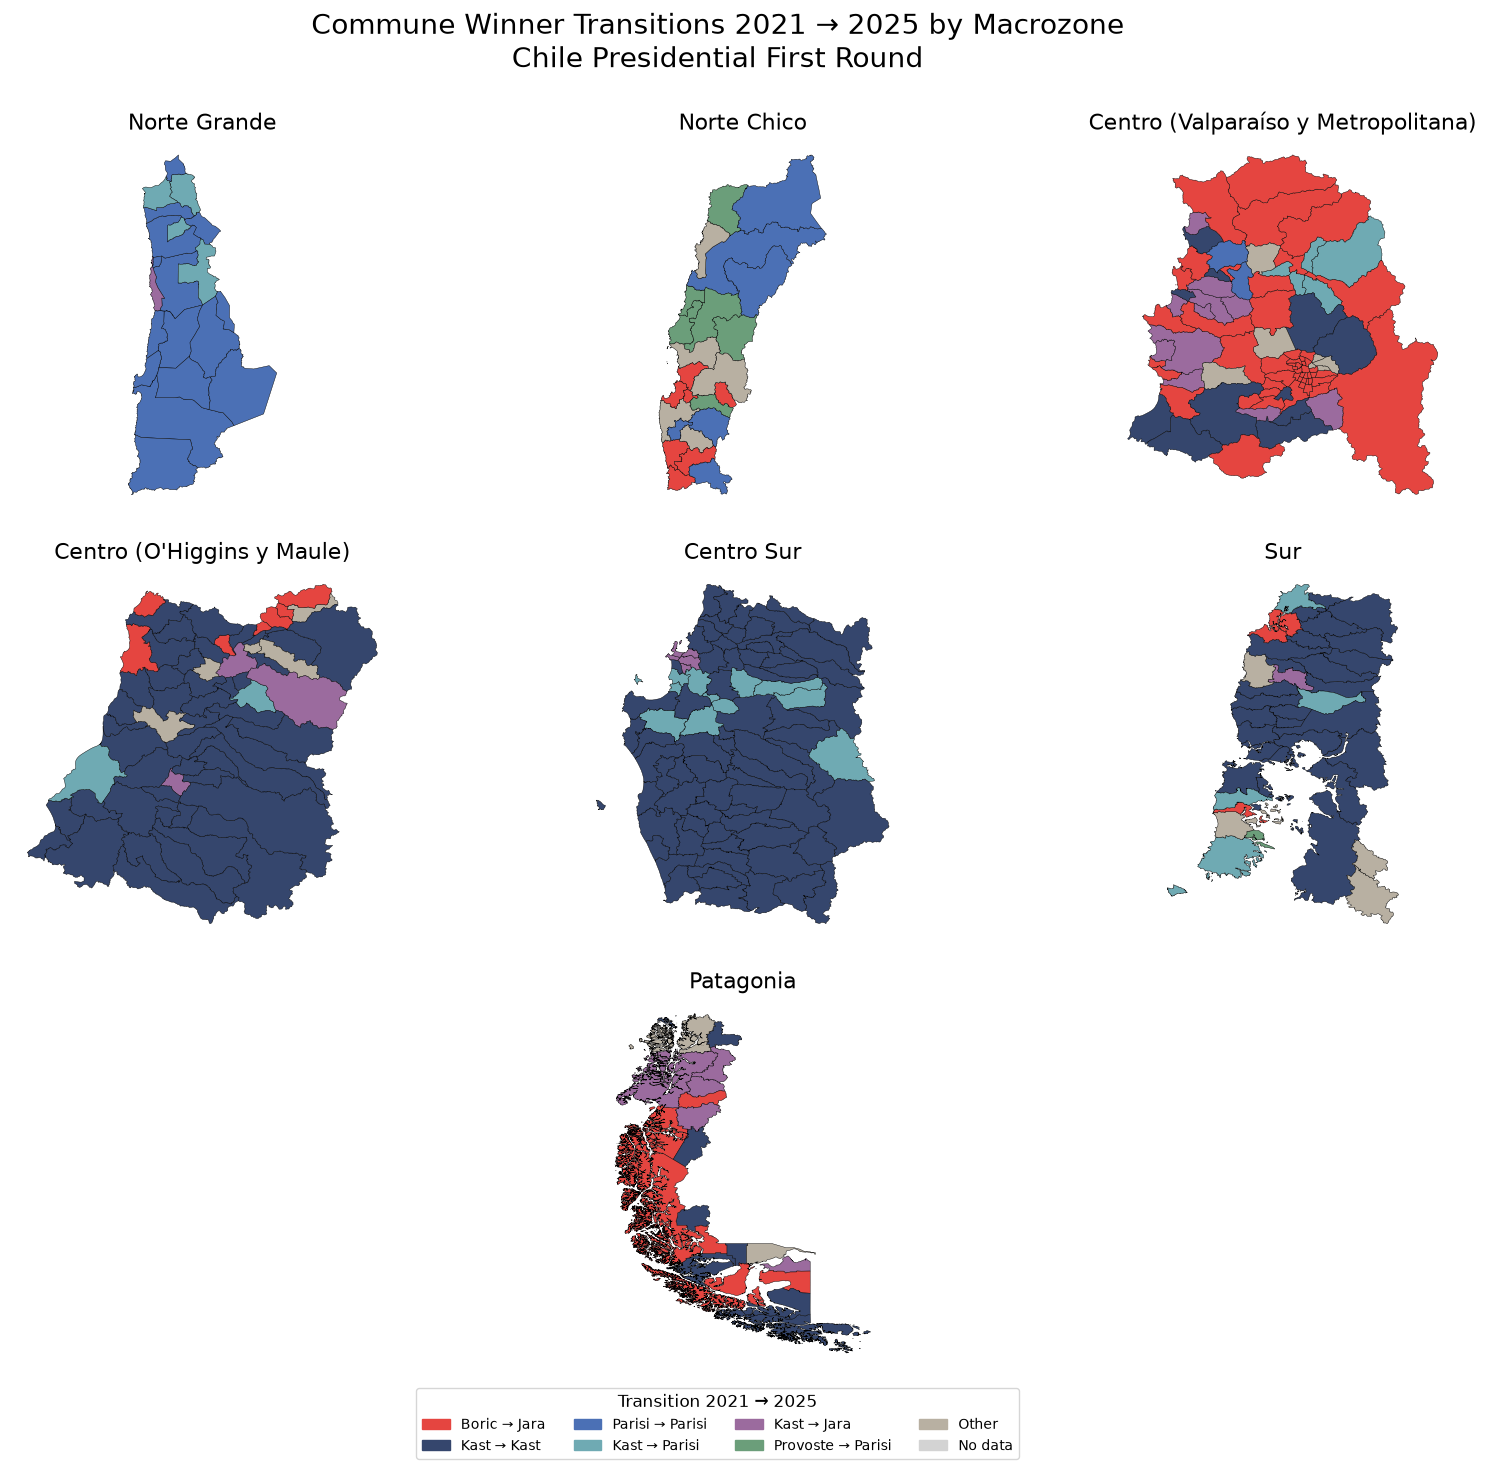

In [143]:
# ============================================================================
# TRANSITION MAP 2021 → 2025 — NATIONAL VIEW
# ============================================================================
# Generates a multi-panel choropleth map showing commune-level winner
# transitions between the 2021 and 2025 Chilean presidential first rounds,
# organized by macrozone with a shared legend.
# ============================================================================

# ---------------------------------------------------------------------------
# 0. DATA PREPARATION
# ---------------------------------------------------------------------------
# Normalize commune names for spatial join and prepare geometry data.

communes_map = communes.copy()
communes_map['NOM_COM_NORM'] = communes_map['NOM_COM'].apply(normalize_commune_name)
realignment_metrics['commune_norm'] = realignment_metrics['commune'].apply(normalize_commune_name)

# ---------------------------------------------------------------------------
# 1. TRANSITION COLOR PALETTE
# ---------------------------------------------------------------------------
# Define color mapping for each 2021→2025 winner transition pair.

TRANSITION_COLORS = {
    'Boric → Jara':       '#E54540',
    'Kast → Kast':        '#35466D',
    'Parisi → Parisi':    '#4B70B5',
    'Kast → Parisi':      '#6FAAB3',
    'Kast → Jara':        '#9B6B9E',
    'Provoste → Parisi':  '#6B9E7A',
    'Other':              '#B8B0A2',
}

def assign_transition_color(row: pd.Series) -> str:
    """Maps a 2021→2025 winner transition pair to its display color."""
    w21, w25 = row.get('winner_2021'), row.get('winner_2025')
    if w21 == 'Boric (Left)' and w25 == 'Jara (Left)':
        return TRANSITION_COLORS['Boric → Jara']
    if w21 == 'Kast (Right)' and w25 == 'Kast (Right)':
        return TRANSITION_COLORS['Kast → Kast']
    if w21 == 'Kast (Right)' and w25 == 'Parisi (Anti-system)':
        return TRANSITION_COLORS['Kast → Parisi']
    if w21 == 'Kast (Right)' and w25 == 'Jara (Left)':
        return TRANSITION_COLORS['Kast → Jara']
    if w21 == 'Parisi (Anti-system)' and w25 == 'Parisi (Anti-system)':
        return TRANSITION_COLORS['Parisi → Parisi']
    if w21 == 'Provoste (Center-Left)' and w25 == 'Parisi (Anti-system)':
        return TRANSITION_COLORS['Provoste → Parisi']
    return TRANSITION_COLORS['Other']

# ---------------------------------------------------------------------------
# 2. SPATIAL JOIN: MERGE GEOMETRIES WITH TRANSITION DATA
# ---------------------------------------------------------------------------
# Merge commune geometries with transition winners and assign colors.

map_data = communes_map.merge(
    realignment_metrics[['commune_norm', 'winner_2021', 'winner_2025']],
    left_on='NOM_COM_NORM',
    right_on='commune_norm',
    how='left',
)

map_data['color'] = map_data.apply(assign_transition_color, axis=1).fillna(TRANSITION_COLORS['Other'])

# Exclude island communes
map_data = map_data[~map_data['NOM_COM'].str.contains('Isla de Pascua|Juan Fernández', case=False, na=False)]

unmatched = map_data[map_data['winner_2021'].isna()]['NOM_COM'].tolist()
if unmatched:
    print(f"Communes with no transition data ({len(unmatched)}): {unmatched[:10]}")

# ---------------------------------------------------------------------------
# 3. MACROZONE ASSIGNMENT (7 ZONES)
# ---------------------------------------------------------------------------
# Assign each commune to one of seven macrozones based on region number.

MACROZONE_MAP = {
    15: 'Norte Grande',
    1:  'Norte Grande',
    2:  'Norte Grande',
    3:  'Norte Chico',
    4:  'Norte Chico',
    5:  'Centro (Valparaíso y Metropolitana)',
    13: 'Centro (Valparaíso y Metropolitana)',
    6:  "Centro (O'Higgins y Maule)",
    7:  "Centro (O'Higgins y Maule)",
    16: 'Centro Sur',
    8:  'Centro Sur',
    9:  'Centro Sur',
    14: 'Sur',
    10: 'Sur',
    11: 'Patagonia',
    12: 'Patagonia',
}

map_data['macrozone'] = map_data['REGION_NUM'].map(MACROZONE_MAP)

# ---------------------------------------------------------------------------
# 4. GRIDSPEC LAYOUT WITH SHARED LEGEND
# ---------------------------------------------------------------------------
# Create a 3x3 grid layout for the seven macrozone maps.

fig = plt.figure(figsize=(20, 16))
gs = GridSpec(3, 3, figure=fig, hspace=0.15, wspace=0.15)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[1, 2])
ax7 = fig.add_subplot(gs[2, 1])

zone_axes = [
    (ax1, 'Norte Grande'),
    (ax2, 'Norte Chico'),
    (ax3, 'Centro (Valparaíso y Metropolitana)'),
    (ax4, "Centro (O'Higgins y Maule)"),
    (ax5, 'Centro Sur'),
    (ax6, 'Sur'),
    (ax7, 'Patagonia'),
]

for ax, macro in zone_axes:
    macro_data = map_data[map_data['macrozone'] == macro].copy()
    if macro_data.empty:
        ax.text(0.5, 0.5, f'No data\n{macro}', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(macro, fontsize=14, fontweight='bold')
        ax.set_axis_off()
        continue

    macro_data.plot(ax=ax, color=macro_data['color'], edgecolor='black', linewidth=0.3)
    ax.set_title(macro, fontsize=16)
    ax.set_axis_off()
    ax.set_aspect('equal')

    if macro == 'Patagonia':
        bounds = macro_data.total_bounds
        margin_x = (bounds[2] - bounds[0]) * 0.05
        margin_y = (bounds[3] - bounds[1]) * 0.05
        ax.set_xlim(bounds[0] - margin_x, bounds[2] + margin_x)
        ax.set_ylim(bounds[1] - margin_y, bounds[3] + margin_y)

# Hide unused grid cells
ax_empty1 = fig.add_subplot(gs[2, 0])
ax_empty2 = fig.add_subplot(gs[2, 2])
ax_empty1.set_visible(False)
ax_empty2.set_visible(False)

fig.suptitle(
    'Commune Winner Transitions 2021 → 2025 by Macrozone\nChile Presidential First Round',
    fontsize=20, y=0.96,
)

# ---------------------------------------------------------------------------
# 5. SHARED LEGEND
# ---------------------------------------------------------------------------
# Create a shared legend for all transition types.

legend_handles = [mpatches.Patch(color=color, label=label) for label, color in TRANSITION_COLORS.items()]
legend_handles.append(mpatches.Patch(color='#D3D3D3', label='No data'))

fig.legend(
    handles=legend_handles, loc='lower center', ncol=4, fontsize=10,
    title='Transition 2021 → 2025', title_fontsize=12,
    bbox_to_anchor=(0.5, 0.05),
)

plt.tight_layout(rect=[0, 0.02, 1, 0.94])
plt.show()

#### 14.4.6. Map of Transitions in Metropolitan Areas and Conurbations


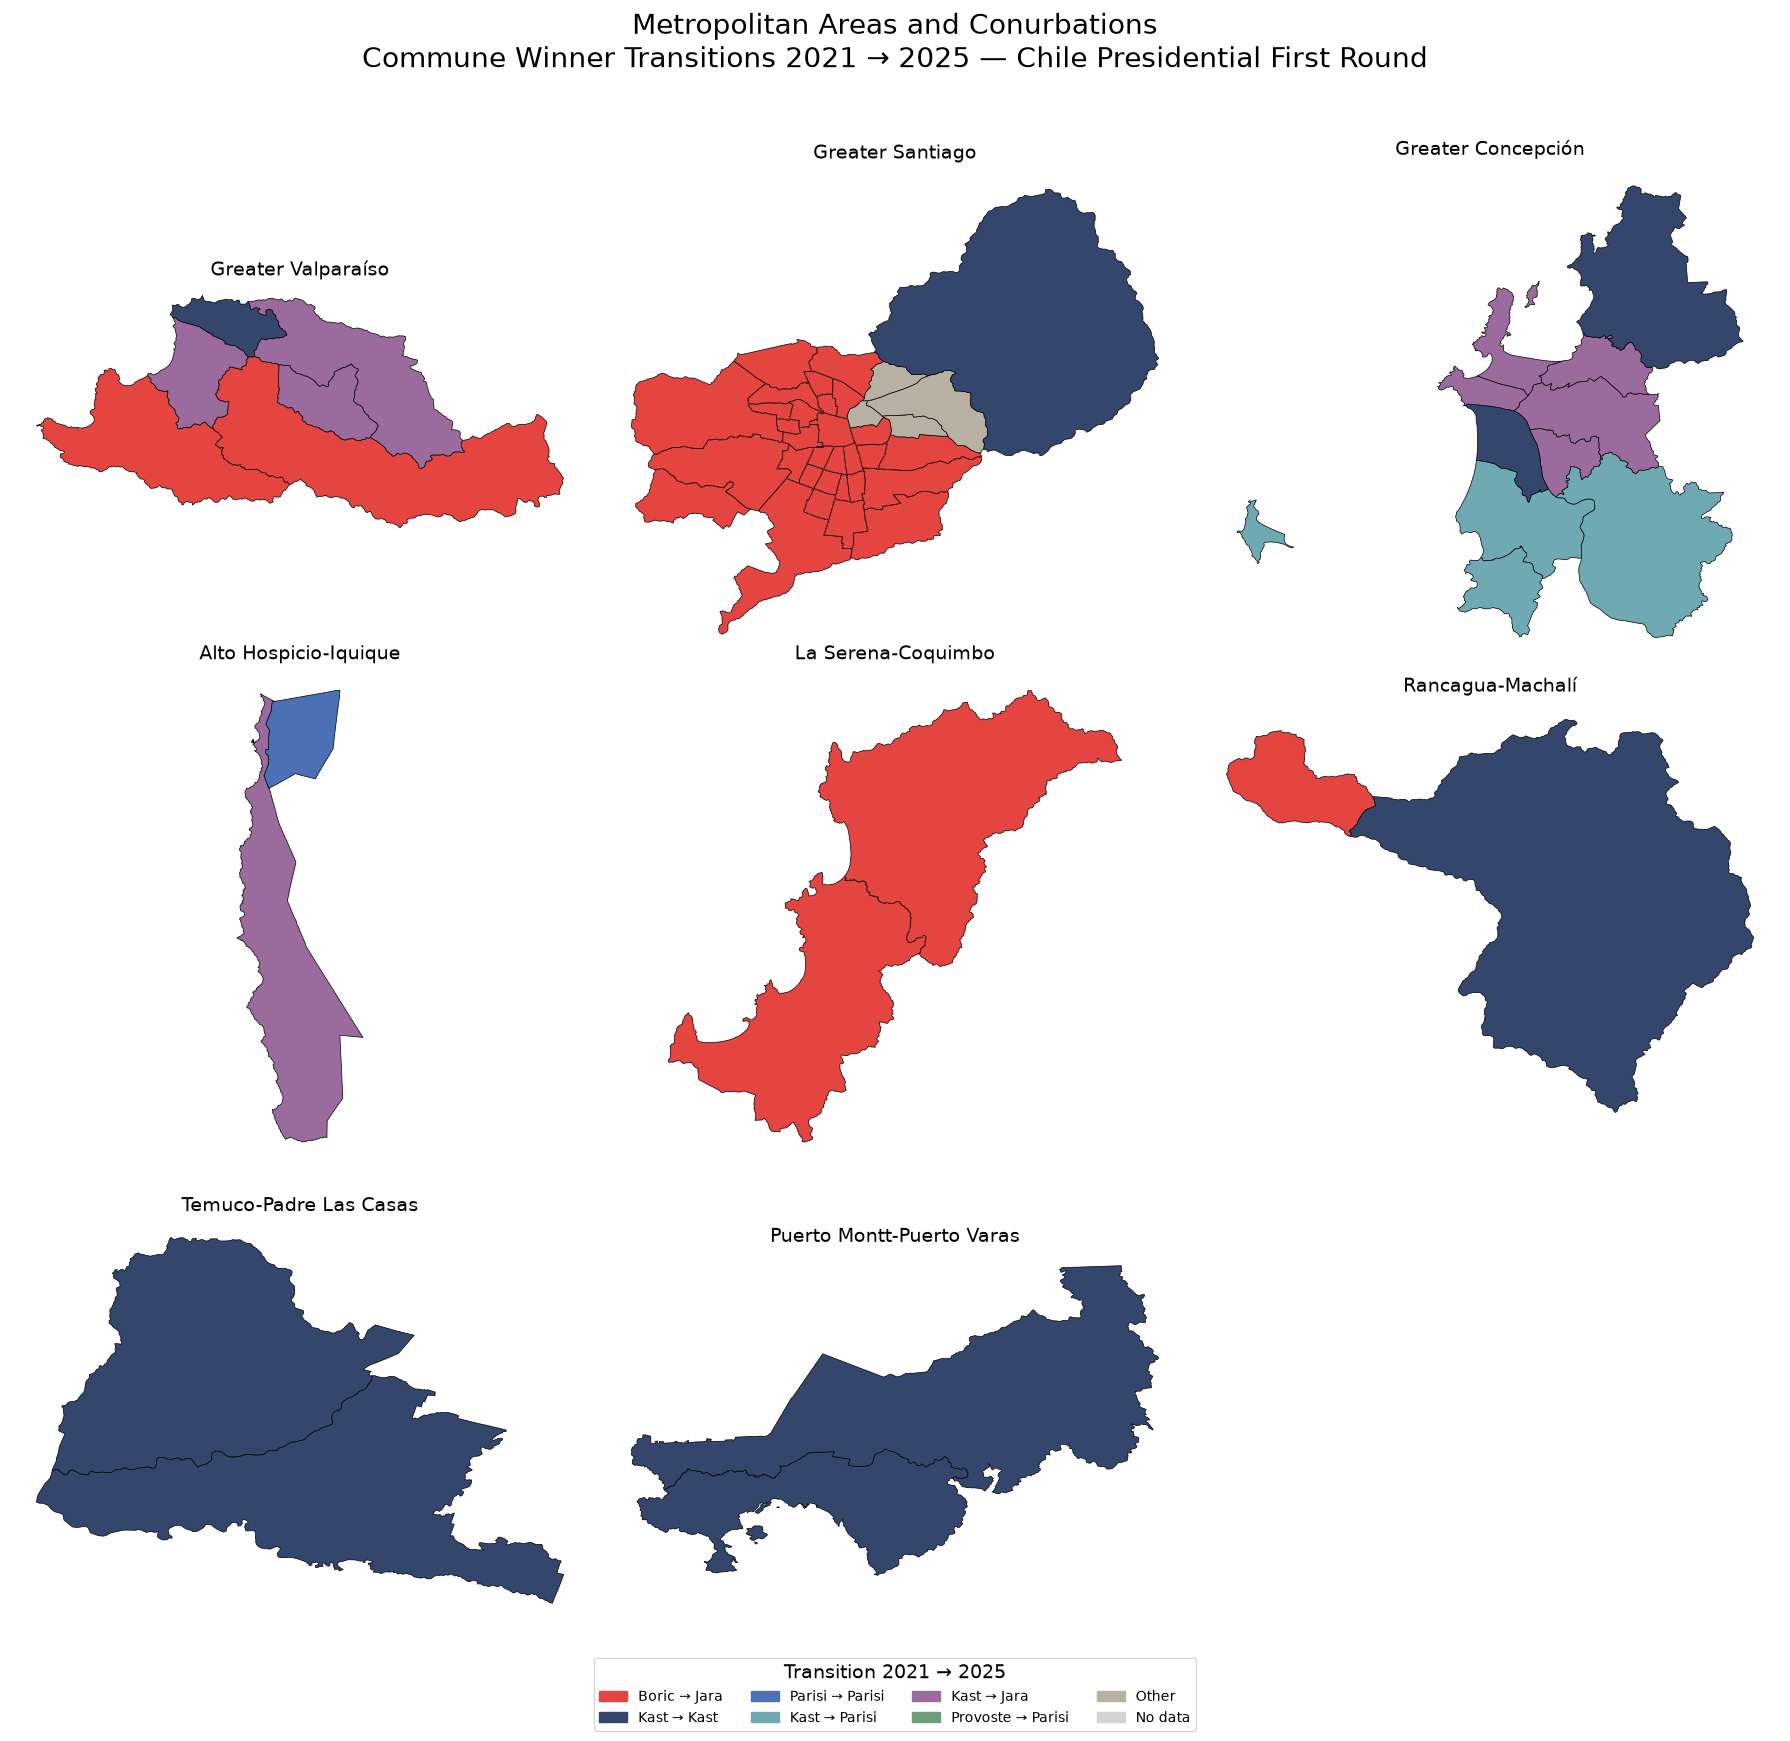

In [144]:
# ============================================================================
# METROPOLITAN AREAS AND CONURBATIONS — WINNER TRANSITION MAP 2021 → 2025
# ============================================================================
# Defines urban agglomerations and renders a 3×3 facet grid showing
# commune-level winner transitions between the 2021 and 2025 first rounds.
# ============================================================================

# ---------------------------------------------------------------------------
# 0. DATA PREPARATION
# ---------------------------------------------------------------------------
# Defines metropolitan area commune lists and pre-computes normalized keys
# for encoding-safe GeoJSON filtering.

METRO_AREAS_TRANS = {
    'Greater Valparaíso': [
        "Valparaíso", "Viña del Mar", "Concón", "Quilpué", "Villa Alemana", "Limache",
    ],
    'Greater Santiago': [
        "Cerrillos", "Cerro Navia", "Conchalí", "El Bosque", "Estación Central",
        "Huechuraba", "Independencia", "La Cisterna", "La Florida", "La Granja",
        "Providencia", "Las Condes", "La Reina", "Lo Espejo", "Lo Prado", "Macul",
        "Maipú", "Ñuñoa", "Padre Hurtado", "Pedro Aguirre Cerda", "Peñalolén",
        "Vitacura", "Pudahuel", "Puente Alto", "Quilicura", "Quinta Normal",
        "Recoleta", "Renca", "San Bernardo", "San Joaquín", "San Miguel",
        "San Ramón", "Santiago", "Lo Barnechea", "La Pintana",
    ],
    'Greater Concepción': [
        "Concepción", "Coronel", "Chiguayante", "Hualpén", "Hualqui", "Lota",
        "Penco", "San Pedro de la Paz", "Talcahuano", "Tomé",
    ],
    'Alto Hospicio-Iquique':    ["Alto Hospicio", "Iquique"],
    'La Serena-Coquimbo':       ["La Serena", "Coquimbo"],
    'Rancagua-Machalí':         ["Rancagua", "Machalí"],
    'Temuco-Padre Las Casas':   ["Temuco", "Padre Las Casas"],
    'Puerto Montt-Puerto Varas': ["Puerto Montt", "Puerto Varas"],
}

# Grid layout: (row, col) → area name  (cell (2,2) intentionally empty)
GRID_LAYOUT_TRANS = [
    (0, 0, 'Greater Valparaíso'),
    (0, 1, 'Greater Santiago'),
    (0, 2, 'Greater Concepción'),
    (1, 0, 'Alto Hospicio-Iquique'),
    (1, 1, 'La Serena-Coquimbo'),
    (1, 2, 'Rancagua-Machalí'),
    (2, 0, 'Temuco-Padre Las Casas'),
    (2, 1, 'Puerto Montt-Puerto Varas'),
]

# Pre-compute normalized key sets for encoding-safe GeoJSON filtering
area_norm_keys_trans = {
    area: {normalize_commune_name(c) for c in commune_list}
    for area, commune_list in METRO_AREAS_TRANS.items()
}

# ---------------------------------------------------------------------------
# 1. BUILD TRANSITION GEODATAFRAME
# ---------------------------------------------------------------------------
# Constructs a GeoDataFrame independent of the national map to ensure
# re-runnable isolation and immunity to upstream map_data mutations.

communes_trans = communes.copy()
communes_trans['NOM_COM_NORM'] = communes_trans['NOM_COM'].apply(normalize_commune_name)

df_change_local = realignment_metrics.copy()
df_change_local['commune_norm'] = df_change_local['commune'].apply(normalize_commune_name)

map_data_trans = communes_trans.merge(
    df_change_local[['commune_norm', 'winner_2021', 'winner_2025']],
    left_on='NOM_COM_NORM',
    right_on='commune_norm',
    how='left',
)
map_data_trans['color'] = (
    map_data_trans.apply(assign_transition_color, axis=1)
    .fillna(TRANSITION_COLORS['Other'])
)

# ---------------------------------------------------------------------------
# 2. RENDER 3×3 FACET GRID
# ---------------------------------------------------------------------------
# Creates a 3×3 subplot grid with each metropolitan area mapped to a cell.

fig, axes = plt.subplots(3, 3, figsize=(18, 18))
fig.suptitle(
    'Metropolitan Areas and Conurbations\n'
    'Commune Winner Transitions 2021 → 2025 — Chile Presidential First Round',
    fontsize=20, y=0.98,
)

for row, col, area_name in GRID_LAYOUT_TRANS:
    ax       = axes[row, col]
    norm_set = area_norm_keys_trans[area_name]

    # Encoding-safe filter: match on normalized key, not raw NOM_COM string
    area_data = map_data_trans[map_data_trans['NOM_COM_NORM'].isin(norm_set)].copy()

    if area_data.empty:
        ax.text(0.5, 0.5, f'No data\n{area_name}',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(area_name, fontsize=14)
        ax.set_axis_off()
        continue

    area_data.plot(ax=ax, color=area_data['color'], edgecolor='black', linewidth=0.5)
    ax.set_title(area_name, fontsize=14)
    ax.set_axis_off()
    ax.set_aspect('equal')

# Hide unused bottom-right cell
axes[2, 2].set_visible(False)

# ---------------------------------------------------------------------------
# 3. SHARED LEGEND
# ---------------------------------------------------------------------------
# Displays a single legend for all subplots with transition color mapping.

legend_handles = [
    mpatches.Patch(color=color, label=label)
    for label, color in TRANSITION_COLORS.items()
]
legend_handles.append(mpatches.Patch(color='#D3D3D3', label='No data'))

fig.legend(
    handles=legend_handles, loc='lower center', ncol=4, fontsize=10,
    title='Transition 2021 → 2025', title_fontsize=14,
    bbox_to_anchor=(0.5, 0.02),
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

#### Conclusion to Subchapter 14.4: Electoral Realignment 2021 → 2025


Electoral realignment between 2021 and 2025 confirms that the fragmentation of Chile's political system is not circumstantial, but structural. Parisi emerged as the great absorber of this process, consolidating a 95.8% retention rate —the highest of any bloc— and capturing 41 communes that were not his in 2021, of which **26 came from Kast**, **8 from Boric**, and **7 from Provoste**. Cannibalizing Kast's vote explains two-thirds of Parisi's territorial expansion, a politically significant finding: it was not discontent on the left that primarily fueled anti-establishment politics, but discontent on the right with the traditional right. The left transferred well from Boric to Jara (86.2% retention), but lost communes to Parisi in the North and Centro Sur, where wear on Gabriel Boric's government was most pronounced. The conservative right lost ground (70.6% retention), leaking votes both to Parisi (25 communes) and to Jara (23 communes), reflecting that part of the Kast vote in 2021 was not ideological but a vote against the governing coalition. The complete collapse of the traditional center-left (0% retention) confirms the disintegration of the center-left space as an autonomous electoral actor, with its electorate split between Jara and Parisi. The regional analysis, finally, confirms that volatility is not uniform: major cities —Valparaíso (87.1%), Metropolitana (81.6%), Coquimbo (75.0%)— underwent deeper transformations than rural areas —Antofagasta (0.0%), La Araucanía (0.0%), Ñuble (5.3%)— explained by the combined effect of compulsory voting and the crisis of institutional trust. Taken together, these findings confirm that Chile's political system is undergoing deep realignment, in which the political center has lost structural pull, the poles have strengthened, and anti-establishment politics has consolidated as a political space with territorial absorption capacity that neither duopoly candidate managed to neutralize.


### Conclusion to Chapter 14: Comparative Analysis: Evolution 2021-2025


The comparison between the 2021 and 2025 first-round elections confirms that the change in voting regime —from voluntary to compulsory voting— is the most important factor for interpreting the transformation of Chile's political system. Turnout multiplied by 89.1%, bringing in 5.1 million new voters who simply did not participate in 2021, and the protest vote surged: the null vote rose from 0.78% to 2.69% and the blank vote from 0.43% to 1.06%, with the null-to-blank ratio rising from 1.8:1 to 2.5:1, confirming that discontent became more confrontational.

The new electorate —citizens with low levels of political engagement and weak partisan identification— leaned mostly toward Parisi and the right-wing options, reshaping the political map. Parisi emerged as the great winner of compulsory voting (+184% in absolute votes), tripling his vote total and consolidating as the country's third political force, with a solid territorial base in the North and growing penetration in the Centro Sur and the Metropolitan Region. The right, as a whole, went from roughly 40% in 2021 to more than 50% in 2025, reflecting a genuine shift of the electorate toward more conservative positions, driven by wear on Gabriel Boric's government. The governing left, by contrast, grew far below the electoral roll's average rate (+32%) and lost 10.5 percentage points, confirming that the new voters were significantly less aligned with the governing coalition than those who already voted in 2021.

Territorial realignment confirms that volatility is not uniform: major cities —Valparaíso (87.1%), Metropolitana (81.6%), Coquimbo (75.0%)— underwent deeper transformations than rural areas —Antofagasta (0.0%), La Araucanía (0.0%), Ñuble (5.3%)— explained by the combined effect of compulsory voting and the crisis of institutional trust. Parisi consolidated the electoral map's most loyal base (95.8% retention) and captured 41 communes that were not his in 2021, of which **26 came from Kast**, **8 from Boric**, and **7 from Provoste**, confirming that cannibalizing Kast's vote explains two-thirds of his territorial expansion. The complete collapse of the traditional center-left (0% retention) confirms the disintegration of the center-left space as an autonomous electoral actor, with its electorate split between Jara and Parisi.

Taken together, these findings confirm that Chile's political system is undergoing deep realignment, in which the political center has lost structural pull, the poles have strengthened, and anti-establishment politics has consolidated as a political space with territorial absorption capacity that neither duopoly candidate managed to neutralize. Compulsory voting not only changed the scale of turnout, it qualitatively transformed the electorate's composition, bringing in millions of citizens whose electoral behavior responds more to situational incentives than to consolidated ideological alignments, redefining Chile's electoral map for the cycle ahead.


---

## Strategic Recommendations for the Runoff: Each Candidacy's Playbook


### 📌 For José Antonio Kast: Protect the Lead Without Losing the Center

**1. Capitalize on the unified right-wing base**
Kast starts with a structural advantage: the right-wing bloc (Kast + Kaiser + Matthei) already exceeded 50% of the valid vote in the first round, and the high ideological compatibility between Kaiser's libertarianism and Kast's republicanism —agreement on migration, security, and reducing the state— makes a majority transfer from that sector plausible, as the base scenario in Chapter 12 suggests. The focus should be on mobilizing that electorate and minimizing leakage into abstention, especially within the Matthei sector, where a meaningful share could opt for the blank vote rather than actively backing him.

**2. Contest the anti-establishment vote in the North**
Parisi's electorate, concentrated in peripheral, mining, and border communes of the North, shares with Kast demands around order, security, and migration control that —per the analysis in Chapters 7 and 13— could generate greater affinity than exists with Jara's offer. This is, however, an electorate that already showed a high propensity toward active protest in the first round (Chapter 4), so its transfer should not be taken for granted: Kast should reinforce a message tailored to these communes, taking care that distrust of the political system as a whole —of which he is also part, as a traditional-system candidacy— does not end up channeled into rejection rather than support for him.

**3. Manage the relationship with the traditional right**
Matthei's collapse (12.44%) left a share of the Chile Vamos electorate without a clear identification with Kast's project, particularly on values-based issues and campaign style. Although the base transfer scenario (12.1) projects that a majority of that electorate would lean his way, the model itself reserves 25% for abstention. A message emphasizing programmatic certainty and governability, rather than confrontation, could help reduce that drift toward electoral passivity.

### 📌 For Jeannette Jara: Break Through the Ceiling of Continuity

**1. Break with "continuity"**
Jara carries the wear of the Boric government: presidential approval fell to historic lows, the constitutional process failed, and the perception of ineffectiveness on security and migration was one of the campaign's central themes. Her challenge heading into the runoff is to project herself as a figure of "transformation born of discontent" rather than simple continuity with the outgoing government, emphasizing that real change rests on her own platform and management record, not on the current administration's legacy.

**2. Connect with the pragmatic voter**
The new electorate brought in by compulsory voting —younger, less politically engaged, and with weaker partisan identification, as documented in Chapters 3 and 14— demands, above all, concrete solutions to material problems: security, cost of living, pensions, and the quality of public services. Jara has, in that sense, greater room to maneuver if she avoids ideological rhetoric and prioritizes short-term proposals that speak to this pragmatic electorate.

**3. Try to capture a share of the Parisi vote**
As the scenarios in Chapter 12 show, Jara's position improves substantially to the extent she manages to attract a significant share of the Parisi electorate, especially in the North and Centro Sur communes where he came second. This is, however, the most demanding scenario to build: it would require a narrative capable of positioning her as a genuine alternative for change —rather than part of the system that electorate rejects— along with a possible signal of openness from the Partido de la Gente itself, whose official position heading into the runoff had not been defined as of this analysis's close.

### 📌 For Franco Parisi and the PDG: The Power of Not Deciding

Without directly contesting the runoff, Parisi holds what is likely the key to its magnitude. Unlike other third-place finishers in Chilean electoral history, he did not negotiate explicit endorsements during the first-round campaign, leaving a range of possible positions open for the runoff: from an explicit call for one of the two finalists, to promoting the null or blank vote, to simply leaving his voters free to decide. Which of these paths the PDG takes —and how much it manages to discipline an electorate that, as Chapter 4 shows, already displayed a high propensity toward active protest in the first round— is one of the main open questions this election leaves behind.

**1. The value of autonomy as a political asset**
Parisi has built his identity around simultaneous rejection of "the traditional left and right." Preserving that autonomy —whatever position he ultimately takes on the runoff— seems more consistent with that identity than an explicit, sustained alignment with either bloc, and it fits with the reading that much of his electorate defines itself, above all, by rejection of the system as a whole (Chapters 4 and 13).

**2. Building political capital toward 2029**
Regardless of the runoff's outcome, Parisi consolidated a loyal electoral base in 2025 (95.7% retention between 2021 and 2025) and a significant parliamentary bloc, elected the same day as the first round. If the next government —whatever its political color— fails to resolve the demands around security, migration, and territorial development that fueled his rise, the Partido de la Gente starts the next cycle from a favorable position to contest an even larger space within Chile's political system.

### Strategic Summary

| Candidate  | Advantage                                                                                                   | Risk                                                                                                    | Key                                                                                                    |
| ----------- | --------------------------------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------- |
| **Kast**    | Unified right-wing base (>50% in the first round). High ideological compatibility with Kaiser's electorate and thematic affinity with part of Parisi's northern electorate | Leakage of the Matthei sector into abstention or the blank vote. Risk of excessive polarization           | Consolidate the conservative vote, contest anti-establishment politics in the North, moderate rhetoric on values-based issues |
| **Jara**    | Cohesion of the progressive bloc (86% retention from Boric). Opportunity to capture the Parisi vote in the North and Centro Sur | Wear from the Boric government. Perception of continuity. The null vote as an outlet for her own discontented electorate | Break with continuity, connect with the pragmatic voter, focus on concrete solutions                       |
| **Parisi**  | Loyal base (95.7% retention). 64 communes won. Own parliamentary bloc                                            | Where his electorate ultimately leans remains uncertain, between Kast, Jara, and active protest            | Preserve anti-establishment autonomy. Consolidate territorial structure heading into 2029                  |


---


## Summary

The November 2025 presidential first round consolidated a scenario of **advanced fragmentation and structural realignment** within the Chilean electorate. No candidate exceeded 27% of the valid vote, but the resulting map is not simply a reflection of political division: it is the diagnosis of a country undergoing a deep reconfiguration of its political cleavages, shifting the traditional left-right axis toward a more complex three-pole geometry —urban progressivism, rural conservatism, and peripheral anti-establishment politics— each with its own territorial, demographic, and cultural logic.

### 1. Key National Findings

- **Historic turnout and robust legitimacy:** with roughly 85.4% of the electoral roll mobilized under compulsory voting, the election reached turnout levels unseen since the 1990s. The 96.25% valid-vote rate confirms the system's technical maturity.
- **A rising protest vote:** the null vote (2.69%) nearly tripled relative to 2021, with a null-to-blank ratio of 2.5:1 indicating discontent that became more confrontational and less passive. A share of the electorate brought in by compulsory voting expressed active rejection rather than indifference.
- **Unprecedented fragmentation:** no candidate exceeded 27%. The combined right reached 50.34%, but with three double-digit candidates competing against each other in the first round. The governing left (Jara) won 26.75% —that bloc's lowest first-round share since the return to democracy— and Franco Parisi consolidated 19.80%, nearly tripling his 2021 absolute vote total (+184%).

### 2. The Territorial Three-Way Split: The Three Chiles

| Chile                    | Reference   | Main characteristic                                  | Regions controlled |
| --------------------------- | ------------ | -------------------------------------------------------- | ---------------------- |
| **Northern**                 | **Parisi**    | Anti-establishment, migration crisis, mining, neglect       | 4 of 4 regions          |
| **Urban Central**            | **Jara**      | Institutional left, high density, services                 | 5 of 16                 |
| **Rural Centro-Sur**         | **Kast**      | Conservative right, rurality, anti-centralism                | 7 of 16                 |

The result's central paradox: Kast won more regions (7) and more communes (169), but Jara led the first round by controlling the most densely populated areas. Parisi dominated the North with unprecedented intensity, but remained, in a sense, "trapped" by that regional monopoly, lacking effective penetration into urban and semi-rural Chile in the center and south.

### 3. Candidate Profiles

- **Jeannette Jara:** the candidate of urban, working-class Chile. She dominated cities with more than 200,000 residents (76.9% of the segment's population) and won 10 of 16 regional capitals. High loyalty within the progressive bloc in the transfer from Boric (86% territorial retention). Structurally vulnerable outside major cities.

- **José Antonio Kast:** the candidate of rural, peripheral Chile. First in territorial coverage (169 communes), with dominance that grows as commune size shrinks. He grew 58% in absolute votes relative to 2021, consolidating a broad right-wing bloc. Per the projection exercise in Chapter 12, his structural position heading into the runoff was more favorable than the first-round result alone would suggest.

- **Franco Parisi:** the cycle's great relative winner. A 95.7% territorial retention rate, expansion from 23 to 64 communes won, and growth in 15 of 16 regions. His northern base is structural, not circumstantial. He emerged as the runoff's most significant arbiter and the clearest signal of the period's political realignment.

- **Evelyn Matthei:** represents the traditional right's electoral collapse. Reduced to high-income enclaves on Santiago's east side, with Chile Vamos's worst historical result in a competitive first round. Her electorate migrated mainly toward Kast between 2021 and 2025.

- **Johannes Kaiser:** opened up a libertarian niche in Chile with potential for future consolidation, but without the critical territorial mass to act as an autonomous force in 2025. His role was more about defining the political field than genuinely competing for leadership of the right.

### 4. The Urban-Rural Gradient: The Analysis's Most Consistent Structural Finding

The correlation between commune size and political preference was the analysis's most regular, consistent pattern:

| Commune Size              | Dominant Candidate    | % Population Controlled  |
| ---------------------------- | ------------------------ | ---------------------------- |
| > 200,000 res.                | **Jara**                  | **76.9%**                      |
| 100,000 – 199,999 res.        | Jara                      | 59.5%                           |
| 50,000 – 99,999 res.          | Jara                      | 61.5%                           |
| 10,000 – 49,999 res.          | **Kast**                  | **57.9%**                       |
| < 10,000 res.                 | **Kast**                  | **~60%**                        |

The breaking point occurs around **50,000 people**: above it, Jara is the systematic leading force; below it, Kast dominates with growing intensity. This demographic-functional boundary explains both Jara's first-round victory —through concentrated votes in a handful of very dense communes— and the structural advantage that, per Chapter 12, Kast would carry into the runoff, given that the zones of greatest relative competitiveness sat in intermediate Chile (50,000-200,000 residents), where neither candidate dominated comfortably and where the transfer of the Parisi vote was most uncertain and impactful.

### 5. Realignment 2021 → 2025: Signals of Transformation

- **Parisi nearly tripled his votes (+184%)** and grew in 15 of 16 regions, with the largest expansion in the Centro Sur (+10.5 pp on average) and the Norte Chico (+7.2 pp). His growth outpaced the electoral roll's in every macrozone.
- **Kast lost 53 communes** (29.4% of his 2021 territorial base): 25 to Parisi and 23 to Jara, showing that part of his 2021 vote was an anti-governing-coalition vote rather than an ideological hard-right vote.
- **The center-left's territorial collapse is complete:** Provoste retained none of her 11 communes; 70% of her electorate migrated to Parisi. The disintegration of the center-left space as an autonomous actor is one of the cycle's deepest structural shifts.
- **The left-wing bloc transferred efficiently** (86% retention from Boric to Jara), but without expanding its base. Jara's first round rested on the floor inherited from 2021, without managing to attract the discontented electorate that migrated toward anti-establishment politics.

---

### Final Conclusion

The 2025 first round was not simply a contest between platforms: it was a **territorial referendum on the model of the state and the distribution of political power in Chile**. Jara won the Chile that trusts the state as a provider of welfare; Kast won the Chile that distrusts the state and demands order and security; Parisi won the Chile that rejects both duopoly options because neither has addressed its specific demands for decades.

The resulting map shows a country in which traditional electoral loyalties still operate —the South votes conservative, major cities vote progressive— but where the margin of volatility has grown significantly. Compulsory voting amplified that volatility by bringing in a more heterogeneous electorate less tied to classic partisan identities.

For the political cycle now opening, the challenges are familiar but no less urgent: **public safety, migration, economic growth, and the persistent perceived neglect by the state in peripheral territories**. The 2025 election did not resolve these challenges; it left them as an open inheritance for whoever wins the runoff. The territorial realignment observed —more fragmented, more fluid, with structural anti-establishment politics in the North and a sharply defined urban-rural gradient— suggests that Chilean politics has entered a phase of greater uncertainty and lower predictability, one in which building majorities will require broader coalitions and more concrete commitments to citizen demands that cut across traditional ideological lines.